In [57]:
import os
import sys
from tqdm import tqdm
import numpy as np
import random
import yaml
import torch
import itertools
import torch.nn.functional as F
import torch.nn as nn
import pandas as pd
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [58]:
torch.cuda.is_available()

True

In [59]:
base_url = os.getcwd()
sys.path.append(base_url + '/Util')

In [60]:
# # from model import *
# import utils
# # from models import *
# # from data_preprocess import *
# from visualization import *

# Network

In [61]:
import torch
import torch.nn as nn
from torch.autograd import Function, Variable

CUDA = True if torch.cuda.is_available() else False


'''
MODELS
'''


def CORAL(source, target):
    d = source.data.shape[1]

    # source covariance
    xm = torch.mean(source, 0, keepdim=True) - source
    xc = xm.t() @ xm

    # target covariance
    xmt = torch.mean(target, 0, keepdim=True) - target
    xct = xmt.t() @ xmt

    # frobenius norm between source and target
    loss = torch.mean(torch.mul((xc - xct), (xc - xct)))
    loss = loss/(4*d*d)

    return loss


class DeepCORAL(nn.Module):
    def __init__(self, num_classes=1000):
        super(DeepCORAL, self).__init__()
        self.sharedNet = FeatureExtractor()
        self.fc = nn.Linear(1024, num_classes)

        # initialize according to CORAL paper experiment
        self.fc.weight.data.normal_(0, 0.005)

    def forward(self, source, target):
        source = self.sharedNet(source)
        source = self.fc(source)

        target = self.sharedNet(target)
        target = self.fc(target)
        return source, target


class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
            
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(1, 9))
        self.relu1 = nn.ReLU(inplace=True)
        self.maxpool1 = nn.MaxPool2d(kernel_size=(1, 2), stride=2, return_indices = False)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(1, 9))
        self.relu2 = nn.ReLU(inplace=True)
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=2, return_indices = False)

        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(1, 9))
        self.relu3 = nn.ReLU(inplace=True)
    
        self.classifier = nn.Sequential(
            nn.Dropout(),
            # nn.Linear(256 * 6 * 6, 4096),
            nn.Linear(256 * 18, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            # nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        shape1 = x.shape
        # print(x.shape)
        x = self.maxpool1(x)
        x = self.relu2(self.conv2(x))
        shape2 = x.shape
        # print(x.shape)
        x = self.maxpool2(x)
        x = self.relu3(self.conv3(x))
        # print(x.shape)
        
        # x = x.view(x.size(0), 256 * 6 * 6)
        x = x.view(x.size(0), 256*18)
        x = self.classifier(x)
        return x

# Necessary Functions

In [62]:
def get_dataset_mean_and_std(directory):
    dataset = datasets.ImageFolder(
        directory,
        transform=transforms.Compose([
            transforms.ToTensor()
        ])
    )

    data_loader = data.DataLoader(dataset)

    mean = [0, 0, 0]
    std = [0, 0, 0]
    for channel in range(3):
        _mean = 0
        _std = 0
        for _, (xs, _) in enumerate(data_loader):
            img = xs[0][channel].numpy()
            _mean += img.mean()
            _std += img.std()

        mean[channel] = _mean/len(dataset)
        std[channel] = _std/len(dataset)

    return mean, std


def save(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        yaml.dump(obj, f, allow_unicode=True)
        print('[INFO] Object saved to {}'.format(path))


def save_net(model, path):
    torch.save(model.state_dict(), path)
    print('[INFO] Checkpoint saved to {}'.format(path))


def load_net(model, path):
    model.load_state_dict(torch.load(path))
    print('[INFO] Checkpoint {} loaded'.format(path))
    
    
    
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', plot_save_path='', cmap=plt.cm.Blues, show=False):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    Saves the plot to the provided directory
    """
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='none', cmap=cmap)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 verticalalignment="center", fontsize=20, 
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(plot_save_path + title, format="png")
    if show:
        plt.show()
    plt.close()

# Sliding Window & DataLoader

In [63]:
def calculate_window(dataframe, data, data_gt, win_size, step_size, start_col, end_col, gt_start_col, gt_end_col, axis_no):
    len_df = dataframe.shape[0]
    narray = dataframe.to_numpy()
    for i in range(0, len_df, step_size):
        window = narray[i:i+win_size, start_col:end_col]

        if window.shape[0] != win_size:
            continue
        else:
            reshaped_window = window.reshape(1, win_size, 1, axis_no)
            gt = np.bincount(narray[i:i+win_size,gt_start_col:gt_end_col].astype(int).ravel()).argmax()
            
            data.append(reshaped_window)
            data_gt.append(gt)


class custom_data_loader(Dataset):
    def __init__(self, samples, labels, transform=None):
        self.samples = samples
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        return self.samples[index], self.labels[index]

    def __len__(self):
        return len(self.samples)
    
    
def load_train_valid_test(train_x, train_y, valid_x, valid_y, test_x, test_y, batch_size=64, drop_last=True):
    train_x_swap = np.swapaxes(train_x,1,3)
    valid_x_swap = np.swapaxes(valid_x,1,3)
    test_x_swap = np.swapaxes(test_x,1,3)
    
    train_set = custom_data_loader(train_x_swap, train_y)
    valid_set = custom_data_loader(valid_x_swap, valid_y)
    test_set = custom_data_loader(test_x_swap, test_y)
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=True, drop_last=drop_last)
    return train_loader, valid_loader, test_loader

# Intended Task

In [64]:
TASKS = ["Cross-Position", "Cross-Person", "Cross-Device"]
task = None
while True:
    print("1. Cross-Position\n2. Cross-Person\n3. Cross-Device")
    user_input = input("Please enter your task: ")
    if user_input == "1":
        task = "Cross-Position"
    elif user_input == "2":
        task = "Cross-Person"
    elif user_input == "3":
        task = "Cross-Device"
    if task in TASKS:
        break
    else:
        print("Invalid task. Please choose a valid task.")
print(f"Chosen task: {task}")

1. Cross-Position
2. Cross-Person
3. Cross-Device
Please enter your task: 1
Chosen task: Cross-Position


# Dataset

In [65]:
DATASETS = ["OPP", "DSADS", "PAMAP", "WISDM", "HHAR"]
dataset = None
if task == 'Cross-Position':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
elif task == 'Cross-Person':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n4. WISDM\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        elif user_input == "4":
            dataset = "WISDM"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
print(f"Chosen dataset: {dataset}")

1. OPP
2. DSADS
3. PAMAP

Please enter your dataset: 2
Chosen dataset: DSADS


# Reproduciblitiy (Must Change Before Each Experiment)

In [66]:
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

def set_seed(seed=42, loader=None):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    try:
        loader.sampler.generator.manual_seed(seed)
    except AttributeError:
        pass

seeds = [0, 42, 123]
seed = seeds[0] # Change this
set_seed(seed=seed)

# Experiment Setup

In [67]:
# All of these have to taken input from shell script
win_size = 128
overlap = 0.1

if task == "Cross-Position":
    if dataset == "DSADS":
        domains = {0:"TORSO", 1:"RA", 2:"LA", 3:"RL", 4:"LL"}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = 4
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["User1","User2","User3","User4", "User5","User6","User7","User8"]
        position_array = ["TORSO","RA","LA","RL","LL"]
    elif dataset == "OPP":
        domains = {0:"BACK", 1:"RUA", 2:"RLA", 3:"LUA", 4:"LLA"}
        sources = [1, 2, 3, 4]
        nsources = len(sources)
        target = 0
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4"]
        position_array = ["BACK", "RUA", "RLA", "LUA","LLA"]
    elif dataset == "PAMAP":
        domains = {0:"Wrist", 1:"Chest", 2:"Ankle"}
        sources = [0, 2]
        nsources = len(sources)
        target = 1
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4","U5","U6","U7","U8"]
        position_array = ['Wrist', 'Chest', 'Ankle']
        
elif task == "Cross-Person":
    if dataset == "DSADS":
        domains = {0:"User1", 1:"User2", 2:"User3", 3:"User4", 4:"User5", 5:"User6", 6:"User7", 7:"User8"}
        sources = [4, 5, 6, 7]
        target = [0, 1, 2, 3]
        nsources = len(sources)
        position_list = ["TORSO", "RA", "LA", "RL", "LL"]
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["User1","User2","User3","User4","User5","User6","User7","User8"]
    elif dataset == "OPP":
        domains = {0:"U1", 1:"U2", 2:"U3", 3:"U4"}
        sources = [0, 1]
        target = [2, 3]
        nsources = len(sources)
        position_list = ["BACK", "RUA", "RLA", "LUA","LLA"]
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["U1","U2","U3","U4"]
    elif dataset == "PAMAP":
        domains = {0:'U1', 1:'U2', 2:'U3', 3:'U4', 4:'U5', 5:'U6', 6:'U7', 7:'U8'}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = [4, 5, 6, 7]
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        position_list = ['Wrist', 'Chest', 'Ankle']
        person_array = ["U1","U2","U3","U4","U5","U6","U7","U8"]
elif task == "Cross-Device":
    pass

print(activity_num)

10


In [68]:
step_size = int(win_size * (1 - overlap))
gpu_id = 0
DEVICE = torch.device('cuda:'+str(gpu_id) if torch.cuda.is_available() else 'cpu')

In [69]:
if dataset == "DSADS":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5
elif dataset == "OPP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 3
    END = 4
elif dataset == "PAMAP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5

In [70]:
if task == "Cross-Position":
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "DSADS-AllPerson-DifferentPosition"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "OPP-AllPerson-DifferentPosition"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPosition"
        
elif task == "Cross-Person":
    target_string = "_".join([domains[i] for i in target])
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "DSADS-SamePosition-DifferentPerson"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "OPP-SamePosition-DifferentPerson"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPerson"

if not os.path.exists(save_path):
    os.makedirs(save_path)

In [71]:
s_train = []
t_train = []

s_gt_train = []
t_gt_train = []

#===================================================#

s_valid = []
t_valid = []

s_gt_valid = []
t_gt_valid = []

#===================================================#

s_test = []
t_test = []

s_gt_test = []
t_gt_test = []

In [72]:
# sources can be [0, 1, 3, 4], and target = 2
if task == 'Cross-Position':
    print('Source')
    # Create an empty DataFrame to hold the aggregated data for this source position
    df_aggregated_train = pd.DataFrame()
    df_aggregated_valid = pd.DataFrame()
    df_aggregated_test = pd.DataFrame()
    for i in range(len(sources)):
        # Combine data from all users for the current source position
        for person in person_list:
            for split_index in range(0, 3):
                file_name = person + "_" + position_array[sources[i]] + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
    calculate_window(df_aggregated_train, s_train, s_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid, s_valid, s_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test, s_test, s_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    print('Target')
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    for person in person_list:
        for split_index in range(0, 3):
            file_name = person + "_" + position_array[target] + '_' + item[split_index]
            print(f"Processing: {file_name}")
            df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
            
            if split_index == 0:
                df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
            elif split_index == 1:
                df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
            elif split_index == 2:
                df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)
    
elif task == 'Cross-Person':
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[sources[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    
    # For the target position, similarly aggregate data across all users
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    for i in range(len(target)):
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[target[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")

                if split_index == 0:
                    df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

elif task == "Cross-Device":
    pass

Source
Processing: User1_TORSO_train
Processing: User1_TORSO_valid
Processing: User1_TORSO_test
Processing: User2_TORSO_train
Processing: User2_TORSO_valid
Processing: User2_TORSO_test
Processing: User3_TORSO_train
Processing: User3_TORSO_valid
Processing: User3_TORSO_test
Processing: User4_TORSO_train
Processing: User4_TORSO_valid
Processing: User4_TORSO_test
Processing: User5_TORSO_train
Processing: User5_TORSO_valid
Processing: User5_TORSO_test
Processing: User6_TORSO_train
Processing: User6_TORSO_valid
Processing: User6_TORSO_test
Processing: User7_TORSO_train
Processing: User7_TORSO_valid
Processing: User7_TORSO_test
Processing: User8_TORSO_train
Processing: User8_TORSO_valid
Processing: User8_TORSO_test
Processing: User1_RA_train
Processing: User1_RA_valid
Processing: User1_RA_test
Processing: User2_RA_train
Processing: User2_RA_valid
Processing: User2_RA_test
Processing: User3_RA_train
Processing: User3_RA_valid
Processing: User3_RA_test
Processing: User4_RA_train
Processing: Us

In [73]:
# Converting data list to numpy data

# Source
s_train = np.concatenate(s_train, axis=0).astype(np.float32)
s_gt_train = np.array(s_gt_train).astype(np.float32)
s_valid = np.concatenate(s_valid, axis=0).astype(np.float32)
s_gt_valid = np.array(s_gt_valid).astype(np.float32)
s_test = np.concatenate(s_test, axis=0).astype(np.float32)
s_gt_test = np.array(s_gt_test).astype(np.float32)

#======================================================================

# Target:
t_train = np.concatenate(t_train, axis=0).astype(np.float32)
t_gt_train = np.array(t_gt_train).astype(np.float32)
t_valid = np.concatenate(t_valid, axis=0).astype(np.float32)
t_gt_valid = np.array(t_gt_valid).astype(np.float32)
t_test = np.concatenate(t_test, axis=0).astype(np.float32)
t_gt_test = np.array(t_gt_test).astype(np.float32)

In [74]:
print(s_train.shape)
print(t_train.shape)

(12521, 128, 1, 3)
(3130, 128, 1, 3)


# Hyperparameter

In [75]:
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
MOMENTUM      = 0.9
EPOCHS        = 20

# Loading Data

In [76]:
drop_last = True
S_train, S_valid, S_test = load_train_valid_test(s_train, s_gt_train, s_valid, s_gt_valid, s_test, s_gt_test, BATCH_SIZE, drop_last)
T_train, T_valid, T_test = load_train_valid_test(t_train, t_gt_train, t_valid, t_gt_valid, t_test, t_gt_test, BATCH_SIZE, drop_last)

# Training & Testing

In [77]:
def train(model, optimizer, epoch, _lambda, source, target, DEVICE):
    result = []

    # declaring iterators
    target_itr = iter(target)
    source_itr = iter(source)
    train_steps = min(len(source), len(target))

    for batch_idx in range(train_steps):
        source_data, source_label = next(source_itr)
        source_data, source_label = source_data.to(DEVICE).float(), source_label.to(DEVICE).long()
        
        target_data, _ = next(target_itr)
        target_data = target_data.to(DEVICE).float()

        optimizer.zero_grad()
        out1, out2 = model(source_data, target_data)

        classification_loss = torch.nn.functional.cross_entropy(out1, source_label)
        # CORAL is in ./Util/model.py
        coral_loss = CORAL(out1, out2)

        sum_loss = _lambda*coral_loss + classification_loss
        sum_loss.backward()

        optimizer.step()

        result.append({
            'epoch': epoch,
            'step': batch_idx + 1,
            'total_steps': train_steps,
            'lambda': _lambda,
            'coral_loss': coral_loss.item(),
            'classification_loss': classification_loss.item(),
            'total_loss': sum_loss.data.item()
        })

        print('Train Epoch: {:2d} [{:2d}/{:2d}]\t'
              'Lambda: {:.4f}, Class: {:.6f}, CORAL: {:.6f}, Total_Loss: {:.6f}'.format(
                  epoch,
                  batch_idx + 1,
                  train_steps,
                  _lambda,
                  classification_loss.item(),
                  coral_loss.item(),
                  sum_loss.item()
              ))

    return result



# In[]
def test(model, dataset_loader, e, DEVICE, save_path):
    model.eval()

    all_preds = []
    all_labels = []

    test_loss = 0
    correct = 0
    for indx, (data, label) in enumerate(dataset_loader):
        data, target = data.to(DEVICE).float(), label.to(DEVICE).long()

        # data, target = Variable(data, volatile=True), Variable(target)
        out, _ = model(data, data)

        # sum up batch loss
        t_loss = torch.nn.functional.cross_entropy(out, target)
        test_loss += t_loss.item()

        # get the index of the max log-probability
        pred = out.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

    test_loss /= len(dataset_loader.dataset)
    plt.figure(figsize=(20, 20))
    plot_cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(plot_cm, classes=activities, title='Confusion_Matrix', plot_save_path=save_path, show=True)

    return {
        'epoch': e,
        'average_loss': test_loss,
        'correct': correct.item(),
        'total': len(dataset_loader.dataset),
        'accuracy': (100. * correct / len(dataset_loader.dataset)).item()
    }

# Main

Train Epoch:  1 [ 1/97]	Lambda: 0.0500, Class: 2.301011, CORAL: 0.000000, Total_Loss: 2.301011
Train Epoch:  1 [ 2/97]	Lambda: 0.0500, Class: 2.298244, CORAL: 0.000000, Total_Loss: 2.298244
Train Epoch:  1 [ 3/97]	Lambda: 0.0500, Class: 2.302842, CORAL: 0.000000, Total_Loss: 2.302842
Train Epoch:  1 [ 4/97]	Lambda: 0.0500, Class: 2.299672, CORAL: 0.000000, Total_Loss: 2.299672
Train Epoch:  1 [ 5/97]	Lambda: 0.0500, Class: 2.302103, CORAL: 0.000000, Total_Loss: 2.302103
Train Epoch:  1 [ 6/97]	Lambda: 0.0500, Class: 2.304520, CORAL: 0.000000, Total_Loss: 2.304520
Train Epoch:  1 [ 7/97]	Lambda: 0.0500, Class: 2.301782, CORAL: 0.000000, Total_Loss: 2.301782
Train Epoch:  1 [ 8/97]	Lambda: 0.0500, Class: 2.308803, CORAL: 0.000000, Total_Loss: 2.308803
Train Epoch:  1 [ 9/97]	Lambda: 0.0500, Class: 2.297513, CORAL: 0.000000, Total_Loss: 2.297513
Train Epoch:  1 [10/97]	Lambda: 0.0500, Class: 2.297048, CORAL: 0.000000, Total_Loss: 2.297048
Train Epoch:  1 [11/97]	Lambda: 0.0500, Class: 2.3

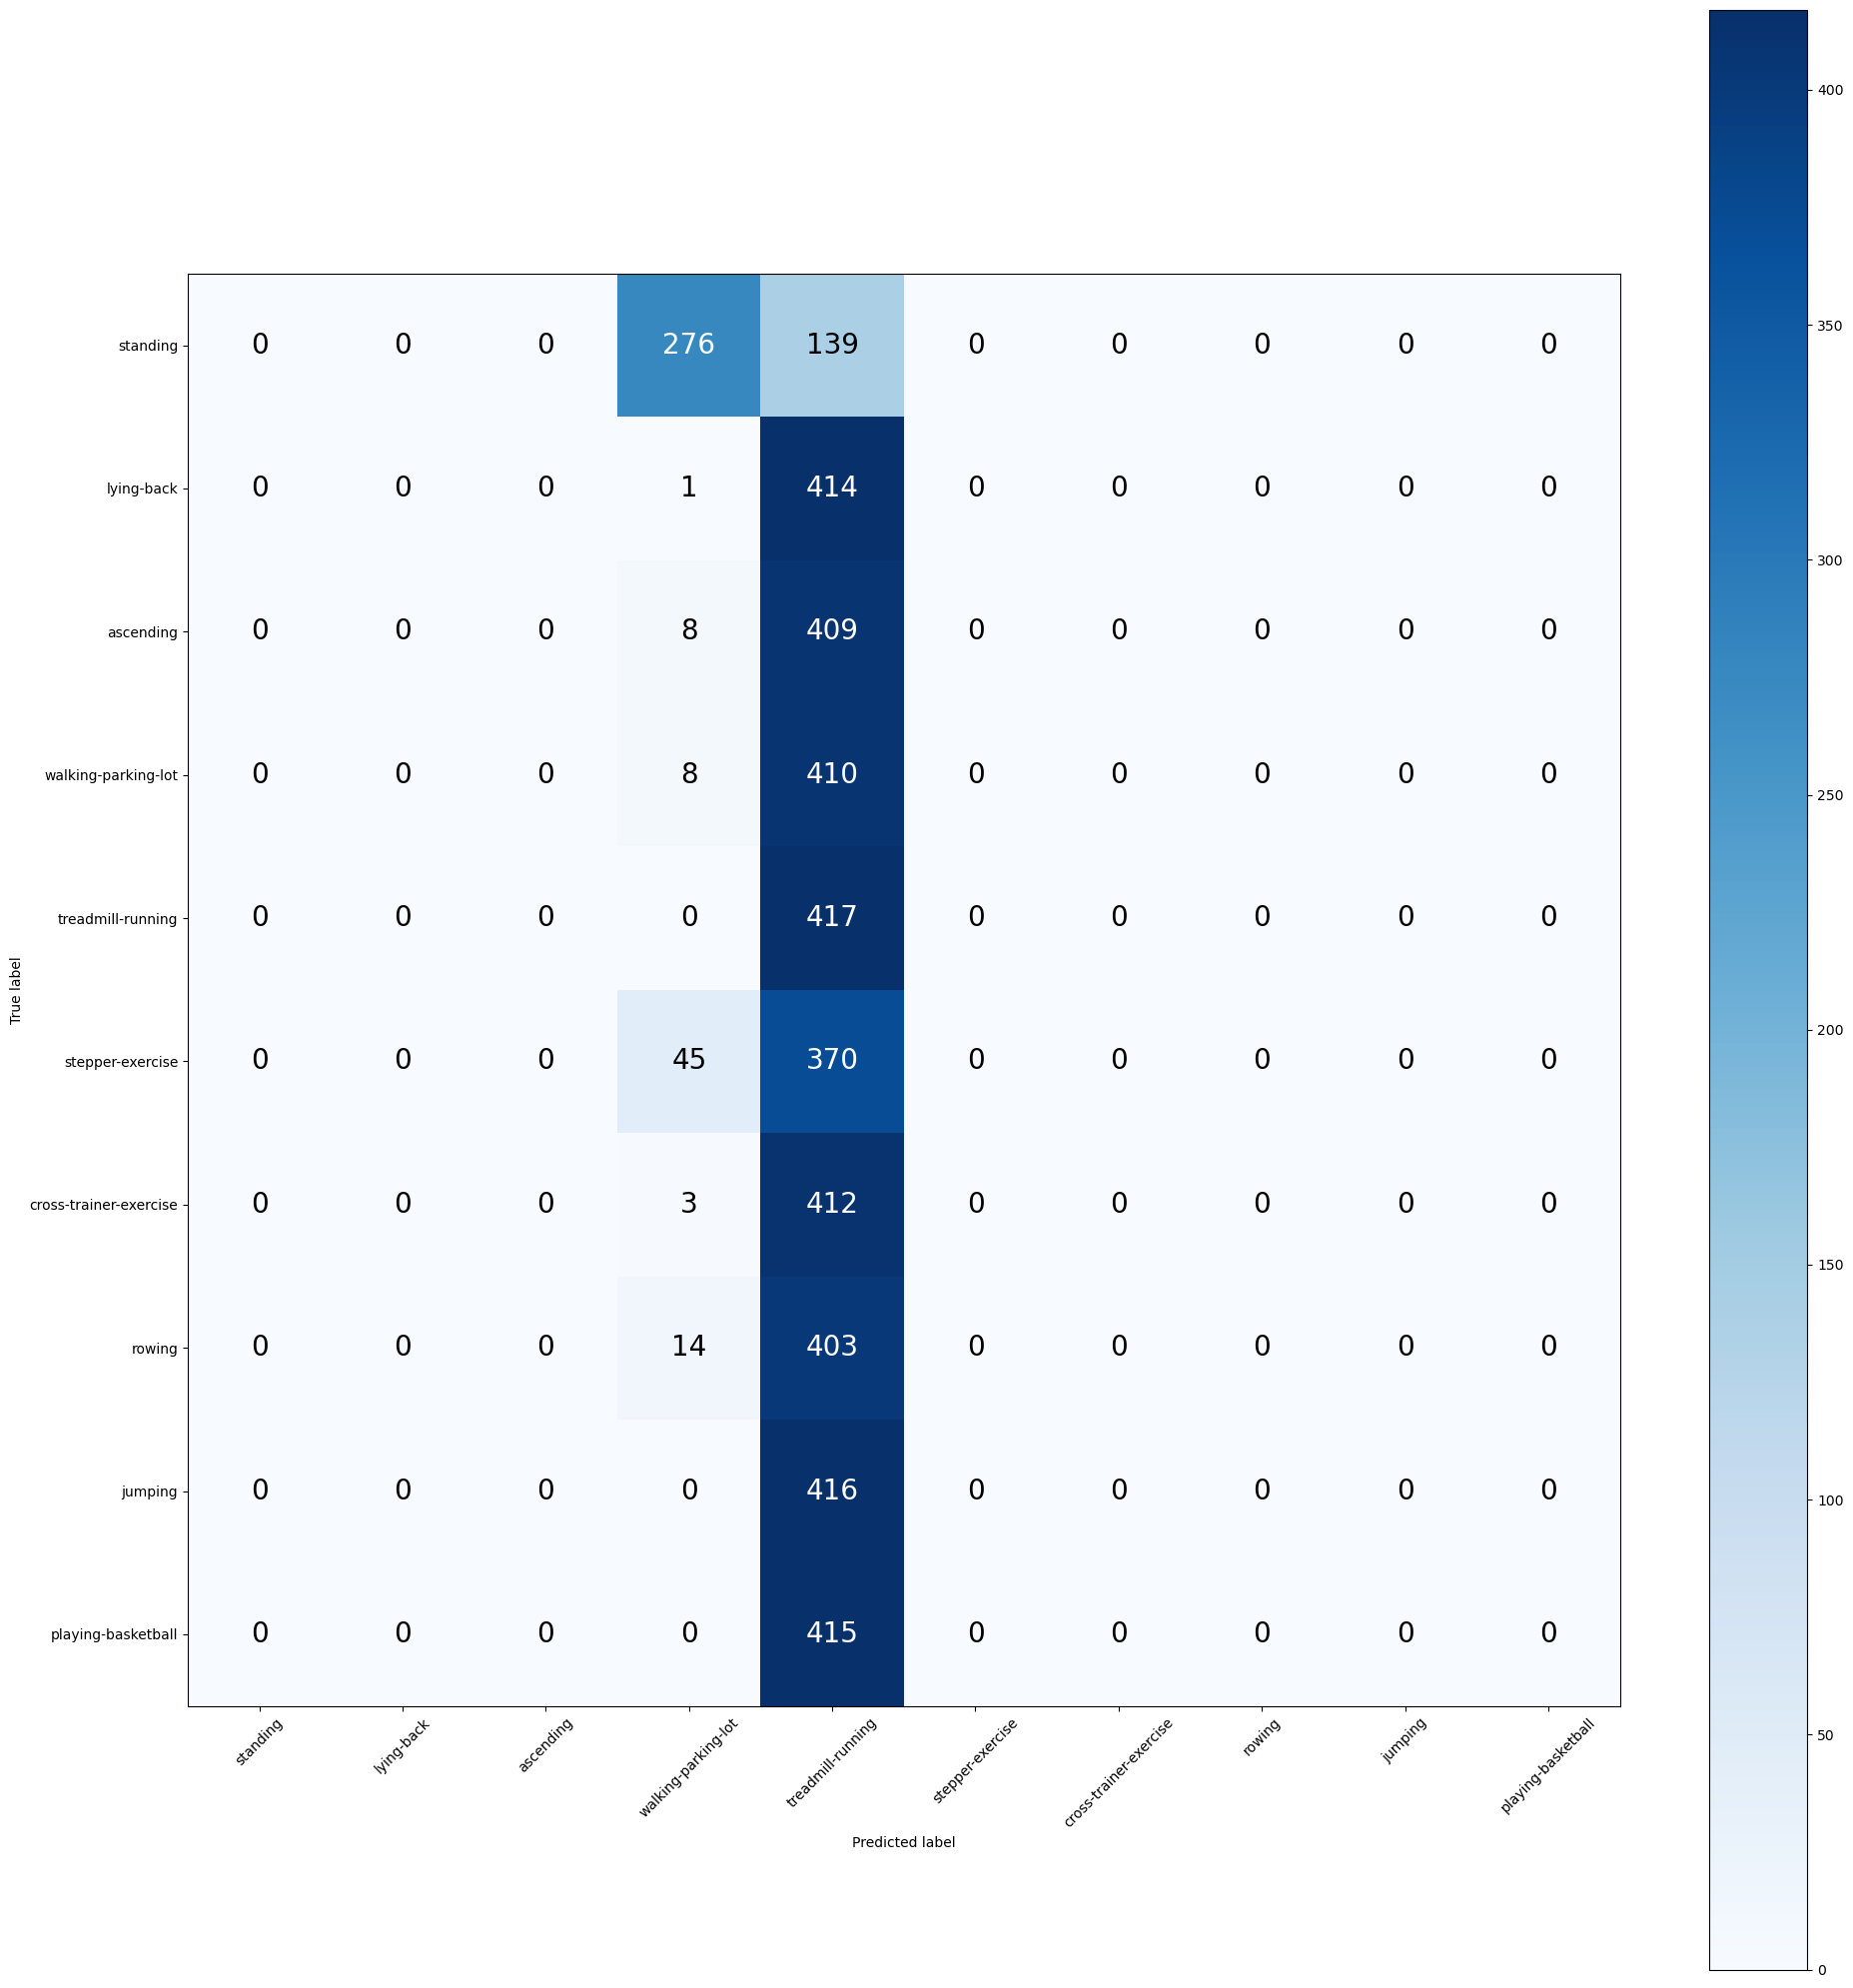

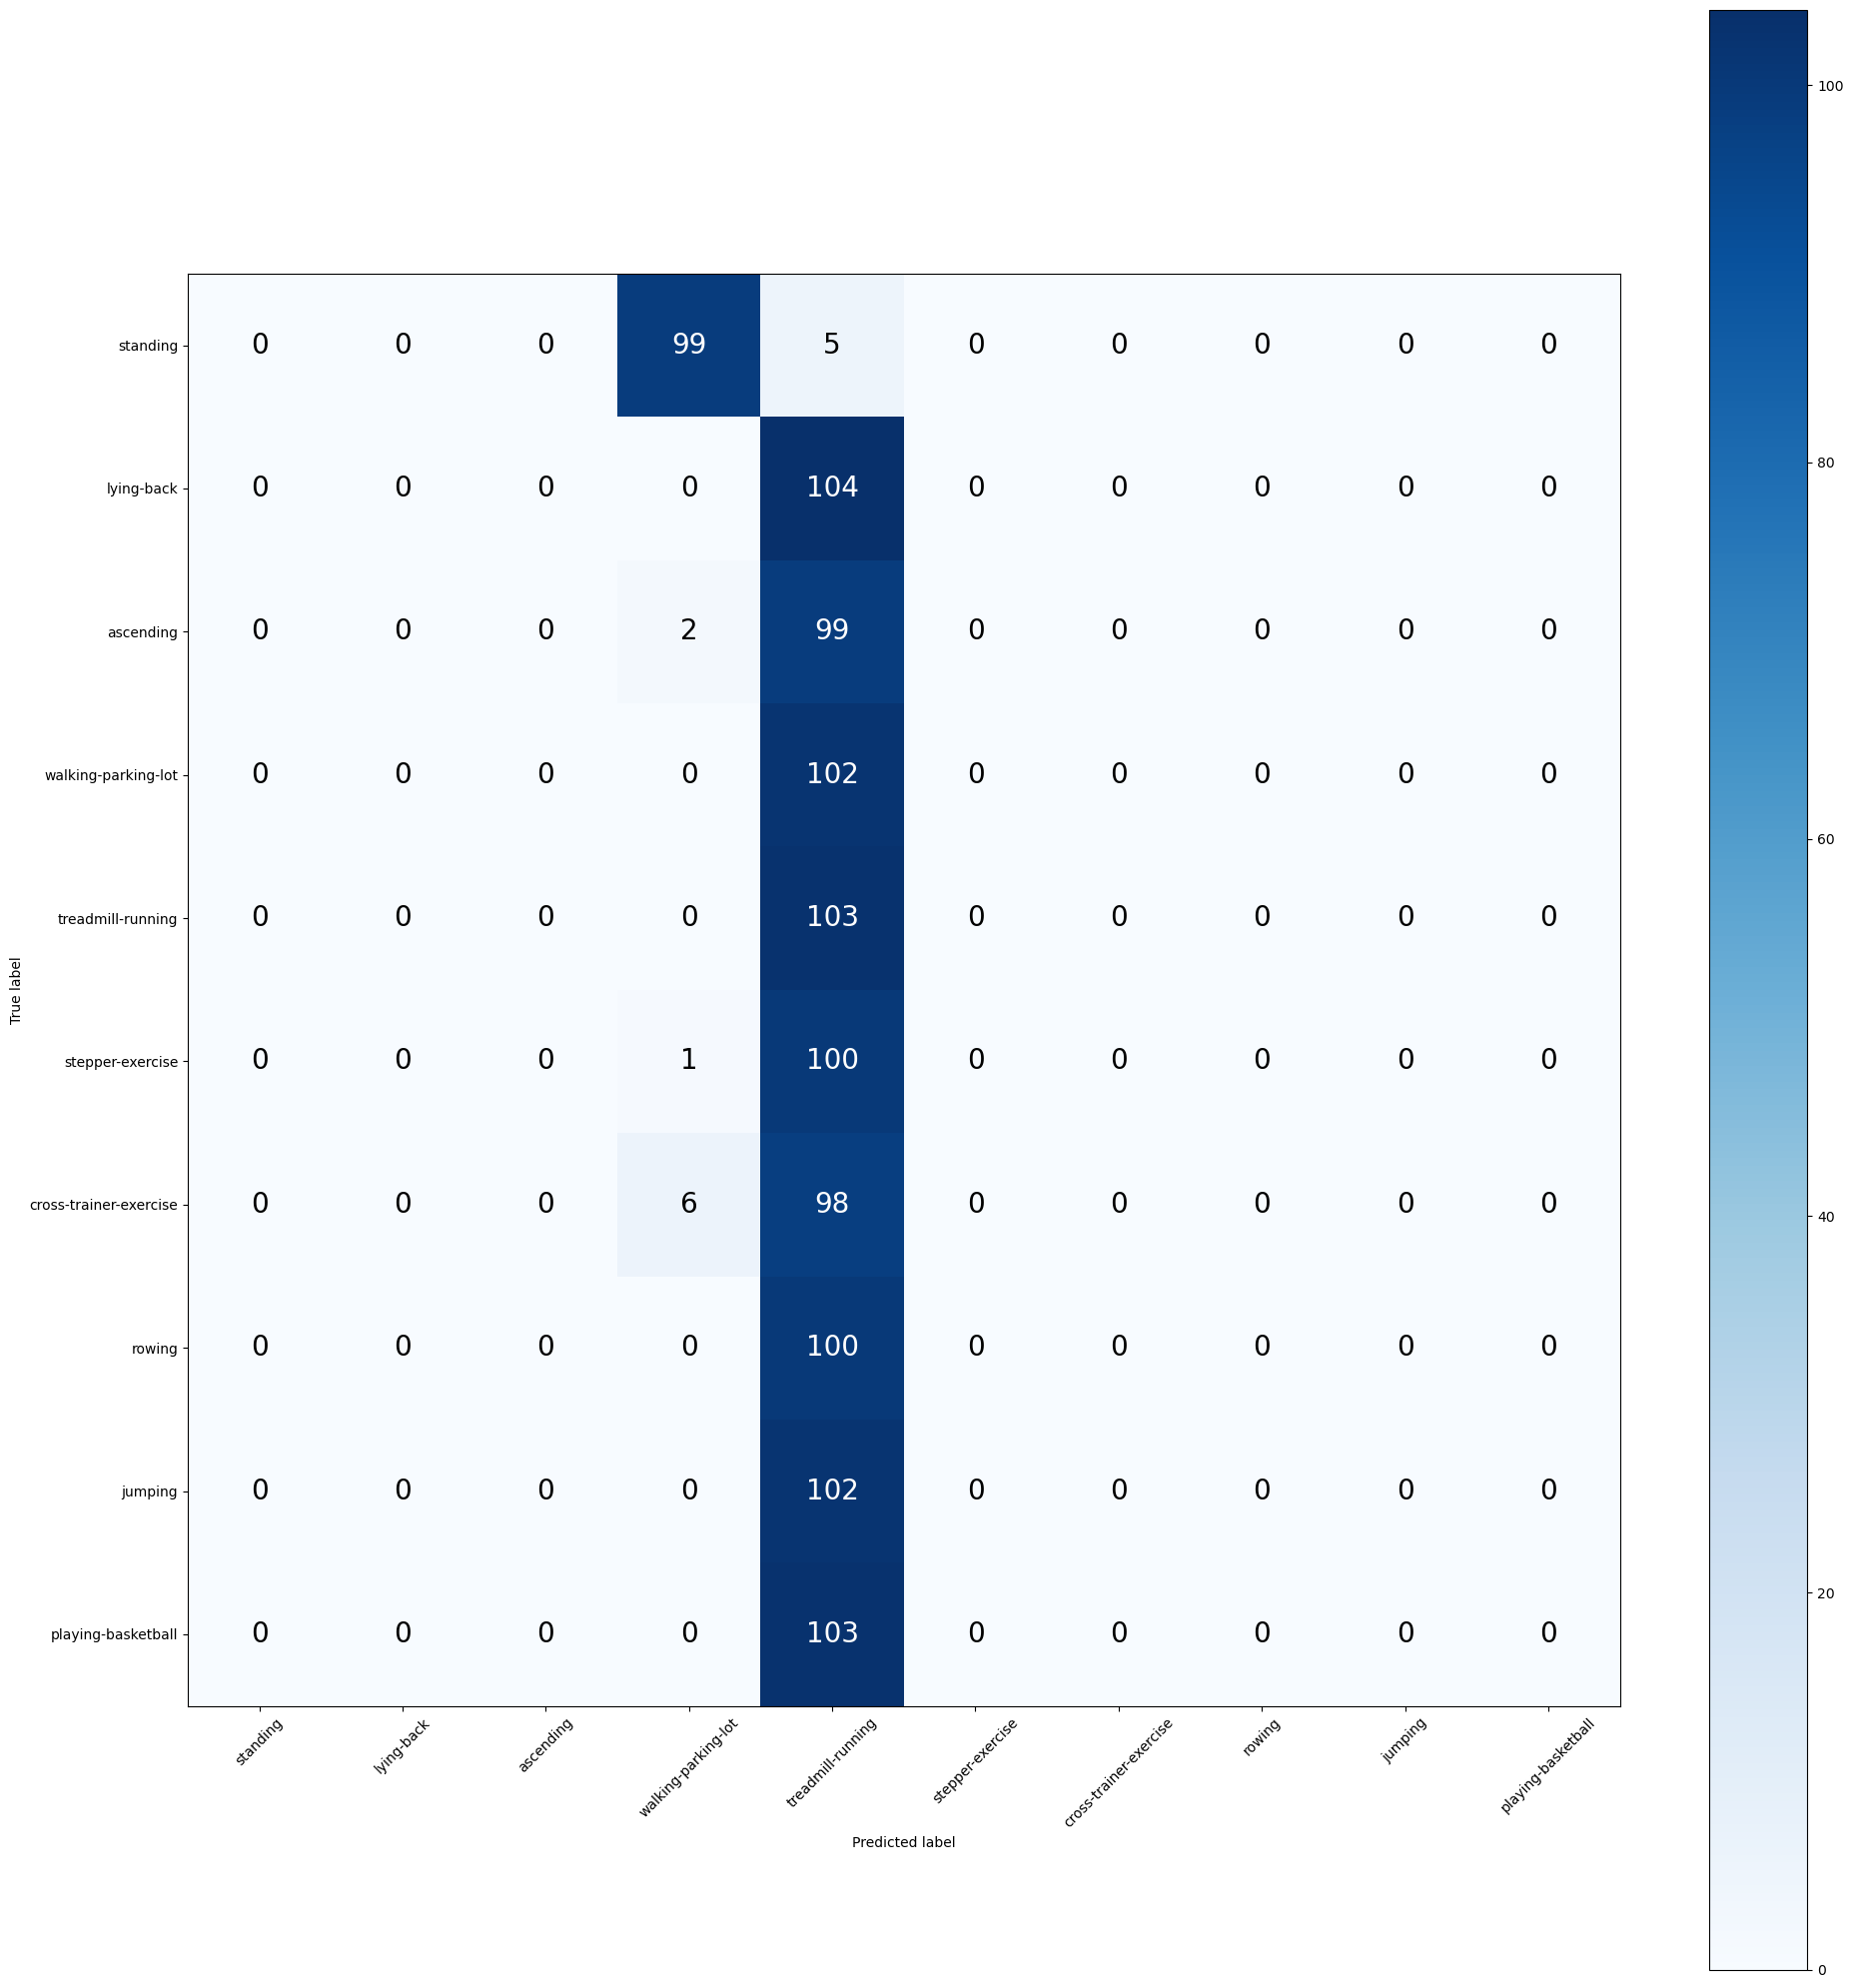

###Valid Source: Epoch: 1, avg_loss: 0.0690, Accuracy: 425/4171 (10.19%)
###Valid Target: Epoch: 1, avg_loss: 0.0675, Accuracy: 103/1042 (9.88%)


Train Epoch:  2 [ 1/97]	Lambda: 0.1000, Class: 2.211668, CORAL: 0.000386, Total_Loss: 2.211706
Train Epoch:  2 [ 2/97]	Lambda: 0.1000, Class: 2.177684, CORAL: 0.000001, Total_Loss: 2.177684
Train Epoch:  2 [ 3/97]	Lambda: 0.1000, Class: 2.271169, CORAL: 0.000088, Total_Loss: 2.271178
Train Epoch:  2 [ 4/97]	Lambda: 0.1000, Class: 2.167588, CORAL: 0.001078, Total_Loss: 2.167696
Train Epoch:  2 [ 5/97]	Lambda: 0.1000, Class: 2.225577, CORAL: 0.001102, Total_Loss: 2.225687
Train Epoch:  2 [ 6/97]	Lambda: 0.1000, Class: 2.150598, CORAL: 0.000045, Total_Loss: 2.150602
Train Epoch:  2 [ 7/97]	Lambda: 0.1000, Class: 2.187310, CORAL: 0.000302, Total_Loss: 2.187341
Train Epoch:  2 [ 8/97]	Lambda: 0.1000, Class: 2.147516, CORAL: 0.000151, Total_Loss: 2.147532
Train Epoch:  2 [ 9/97]	Lambda: 0.1000, Class: 2.074402, CORAL: 0.000124, Total_Loss: 2.07441

Train Epoch:  2 [87/97]	Lambda: 0.1000, Class: 1.864513, CORAL: 0.006237, Total_Loss: 1.865136
Train Epoch:  2 [88/97]	Lambda: 0.1000, Class: 2.039743, CORAL: 0.015077, Total_Loss: 2.041251
Train Epoch:  2 [89/97]	Lambda: 0.1000, Class: 2.071177, CORAL: 0.000714, Total_Loss: 2.071249
Train Epoch:  2 [90/97]	Lambda: 0.1000, Class: 1.942965, CORAL: 0.064925, Total_Loss: 1.949457
Train Epoch:  2 [91/97]	Lambda: 0.1000, Class: 2.102544, CORAL: 0.011237, Total_Loss: 2.103668
Train Epoch:  2 [92/97]	Lambda: 0.1000, Class: 2.028853, CORAL: 0.022069, Total_Loss: 2.031060
Train Epoch:  2 [93/97]	Lambda: 0.1000, Class: 1.892061, CORAL: 0.098839, Total_Loss: 1.901945
Train Epoch:  2 [94/97]	Lambda: 0.1000, Class: 2.012960, CORAL: 0.004690, Total_Loss: 2.013429
Train Epoch:  2 [95/97]	Lambda: 0.1000, Class: 1.969280, CORAL: 0.025533, Total_Loss: 1.971833
Train Epoch:  2 [96/97]	Lambda: 0.1000, Class: 2.060450, CORAL: 0.138393, Total_Loss: 2.074289
Train Epoch:  2 [97/97]	Lambda: 0.1000, Class: 2.0

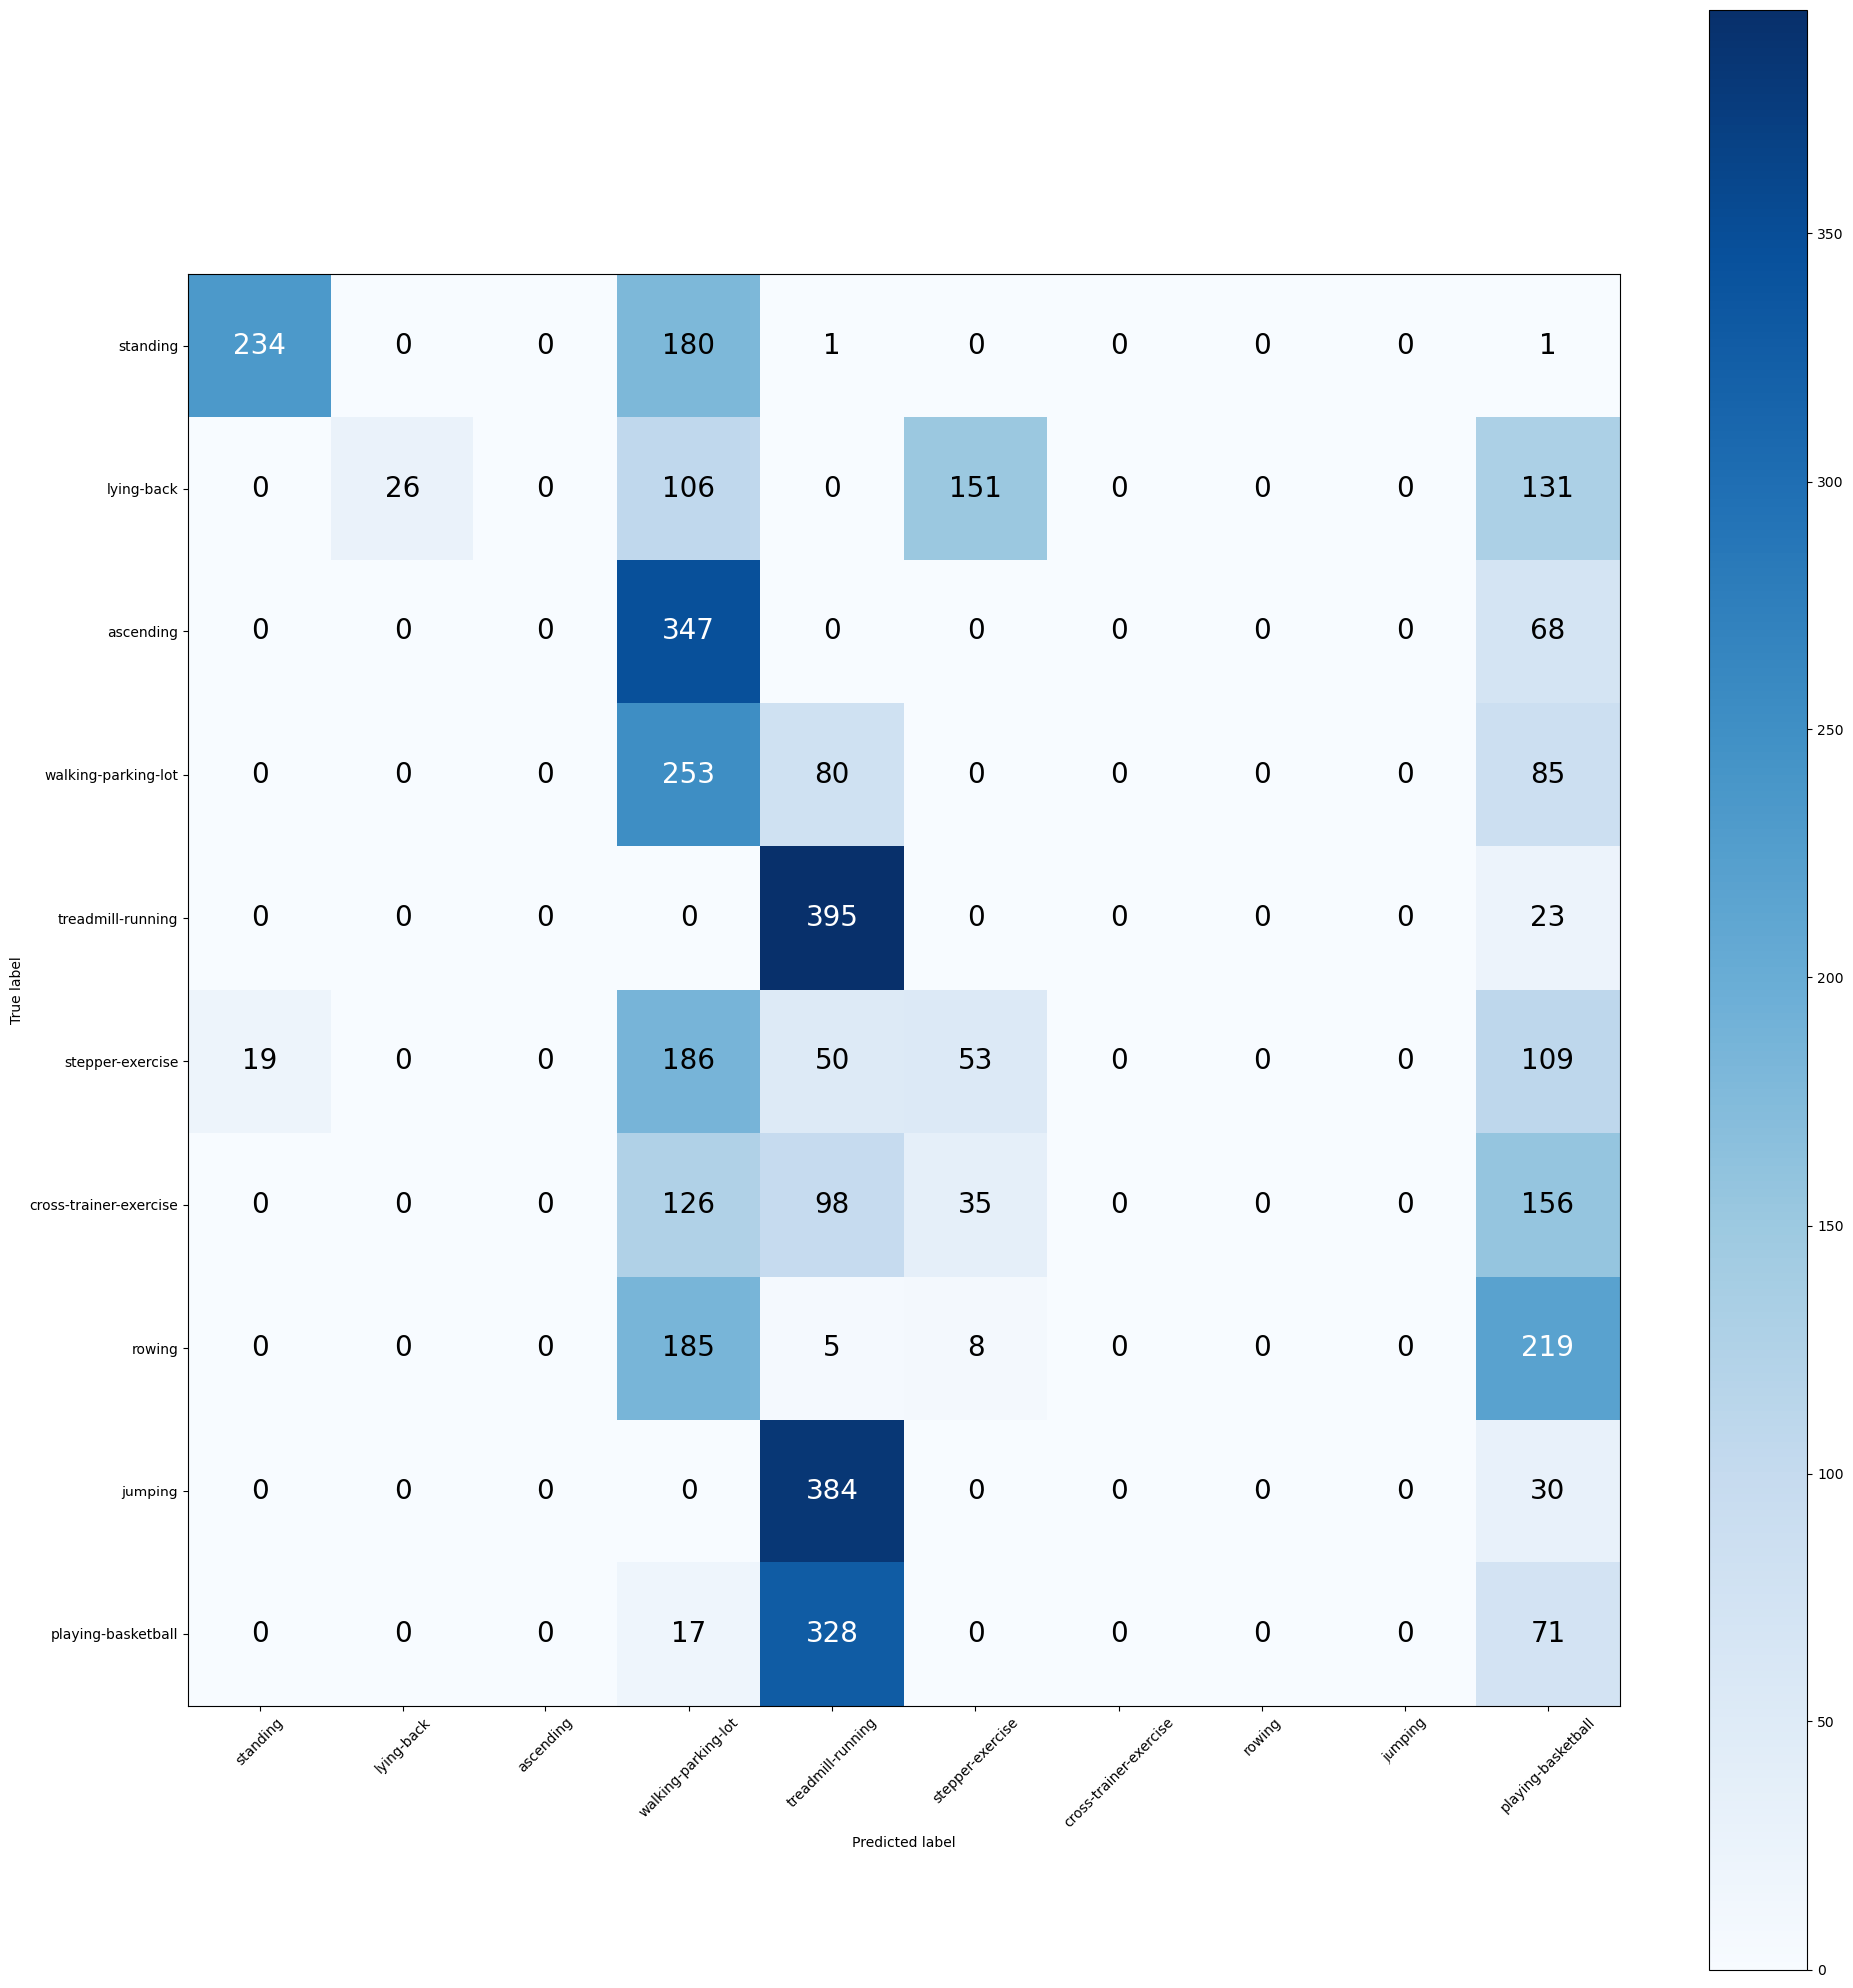

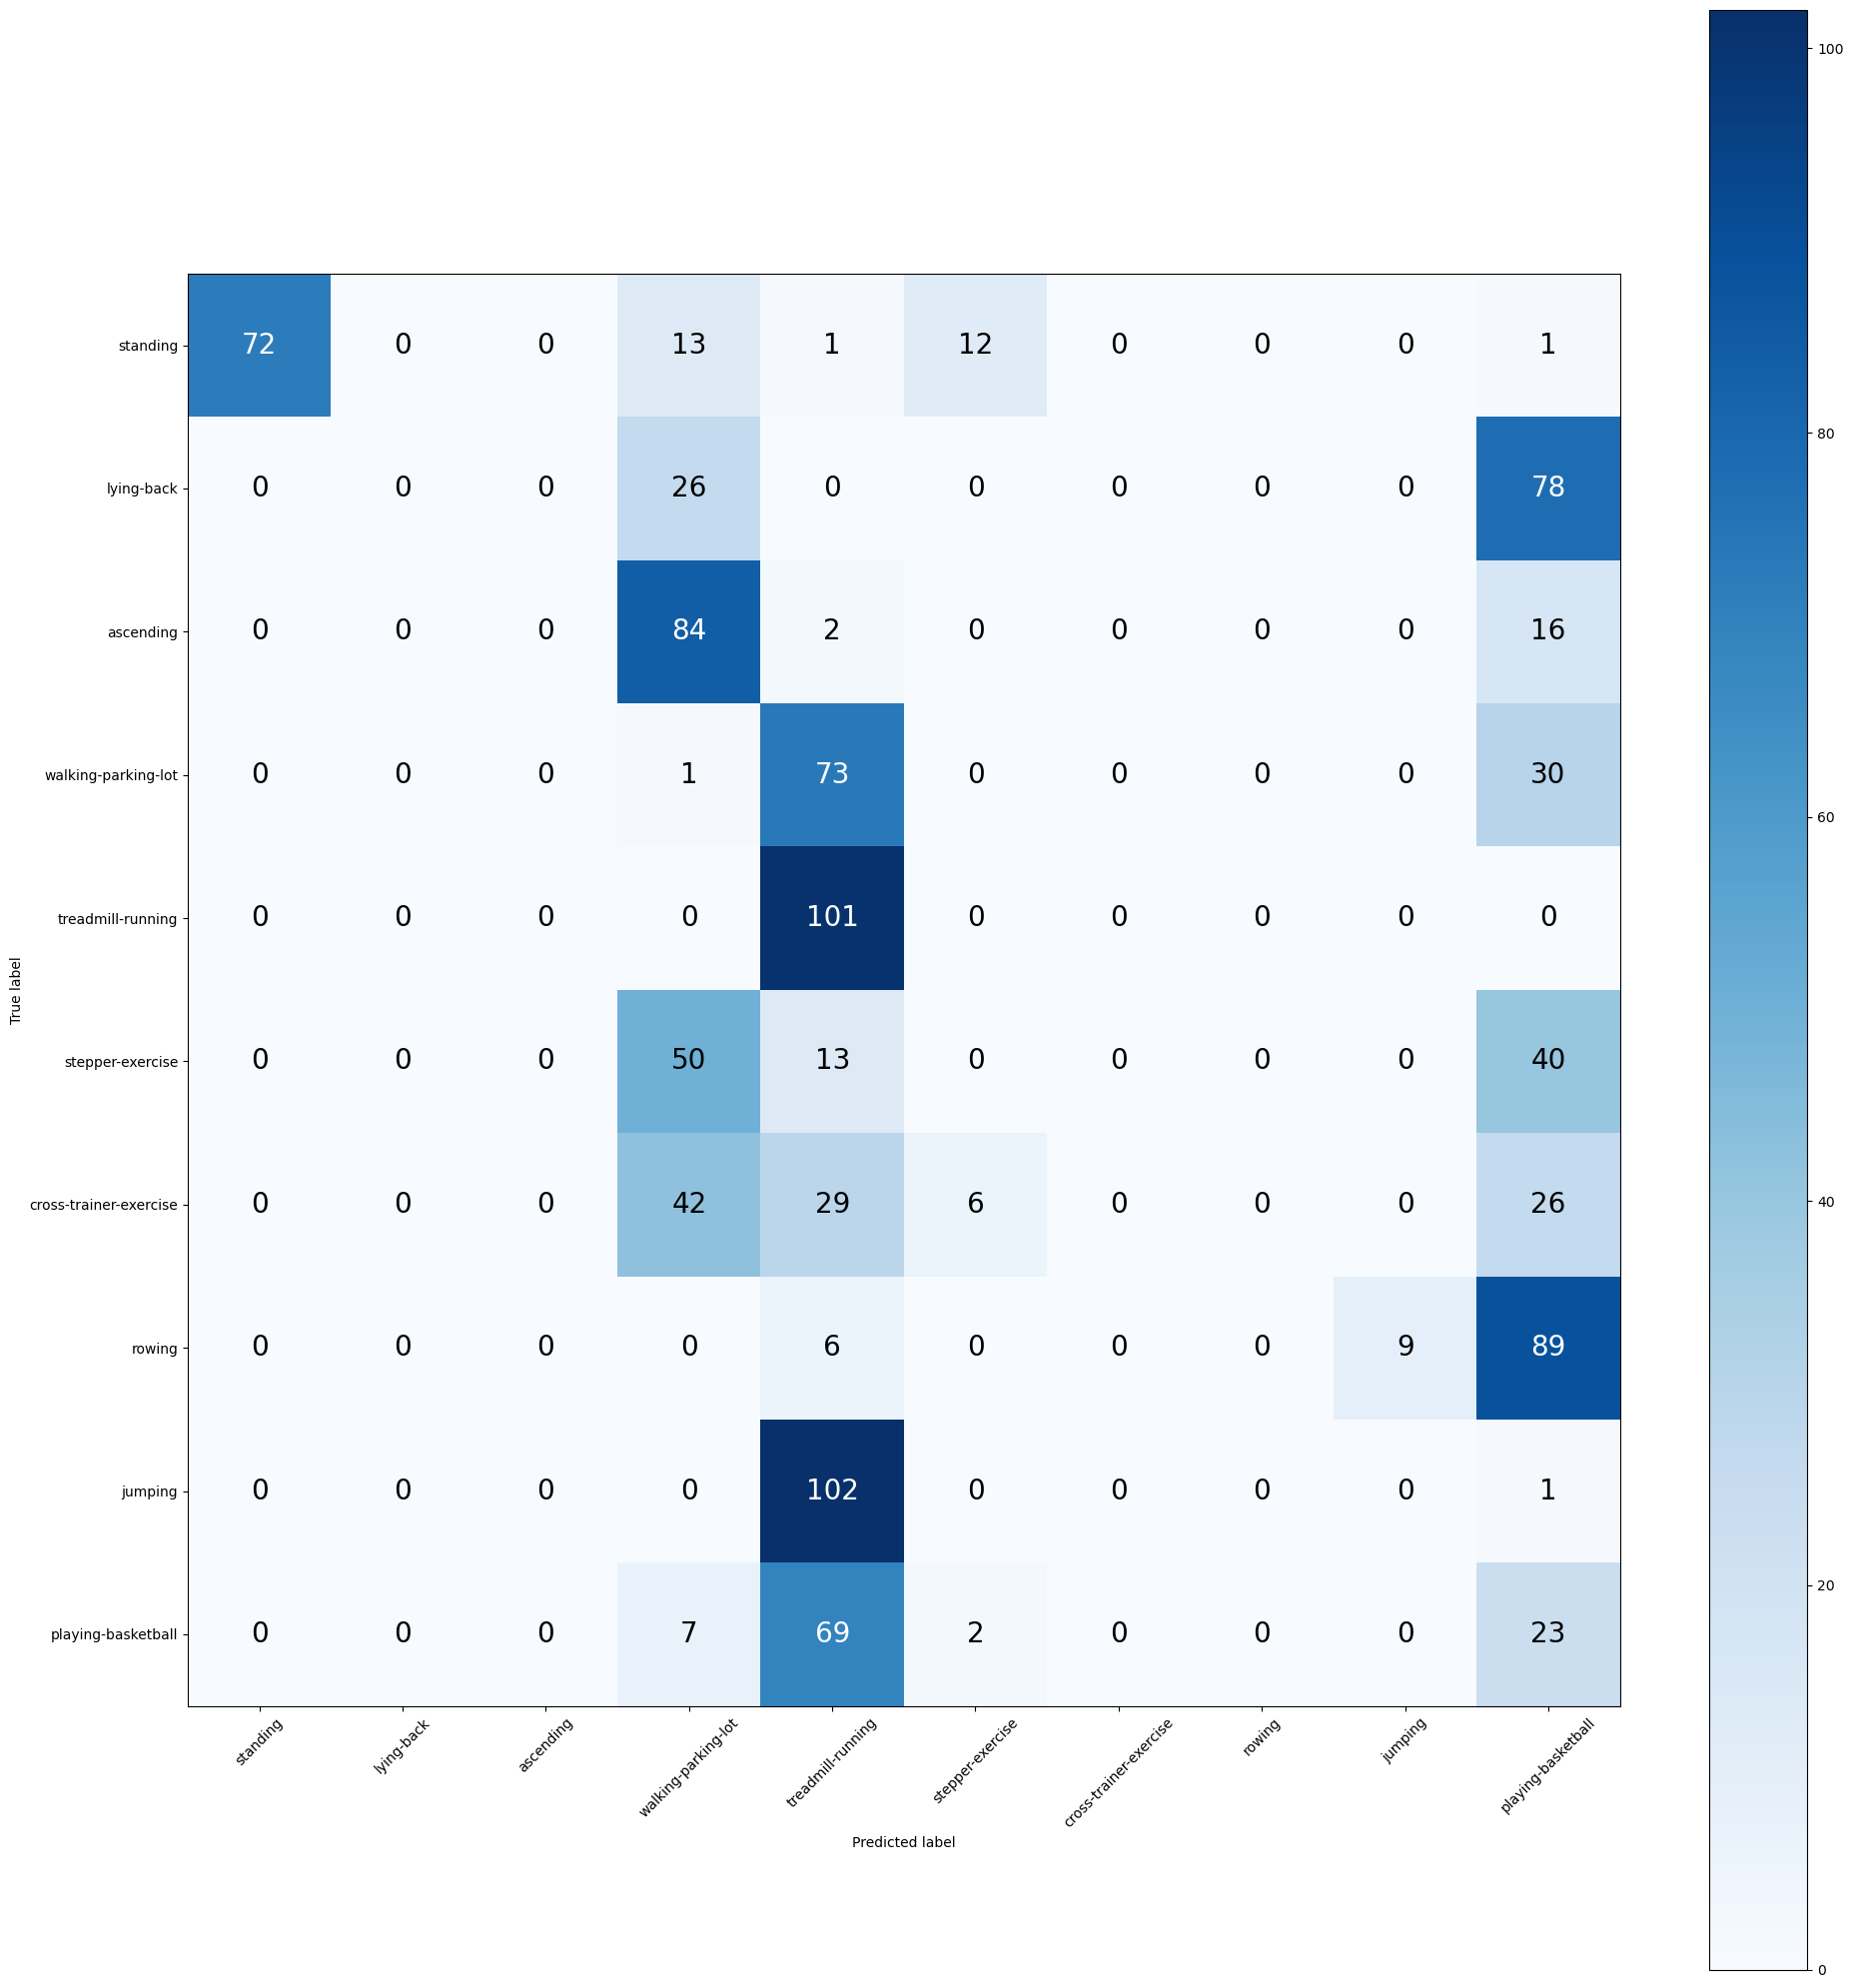

###Valid Source: Epoch: 2, avg_loss: 0.0633, Accuracy: 1032/4171 (24.74%)
###Valid Target: Epoch: 2, avg_loss: 0.0628, Accuracy: 197/1042 (18.91%)


Train Epoch:  3 [ 1/97]	Lambda: 0.1500, Class: 2.008048, CORAL: 0.073688, Total_Loss: 2.019101
Train Epoch:  3 [ 2/97]	Lambda: 0.1500, Class: 2.141117, CORAL: 0.365903, Total_Loss: 2.196002
Train Epoch:  3 [ 3/97]	Lambda: 0.1500, Class: 1.960311, CORAL: 0.364441, Total_Loss: 2.014977
Train Epoch:  3 [ 4/97]	Lambda: 0.1500, Class: 2.077498, CORAL: 0.052541, Total_Loss: 2.085380
Train Epoch:  3 [ 5/97]	Lambda: 0.1500, Class: 2.145352, CORAL: 0.003020, Total_Loss: 2.145805
Train Epoch:  3 [ 6/97]	Lambda: 0.1500, Class: 2.132849, CORAL: 0.063139, Total_Loss: 2.142319
Train Epoch:  3 [ 7/97]	Lambda: 0.1500, Class: 1.880212, CORAL: 0.152274, Total_Loss: 1.903053
Train Epoch:  3 [ 8/97]	Lambda: 0.1500, Class: 2.011861, CORAL: 0.068068, Total_Loss: 2.022072
Train Epoch:  3 [ 9/97]	Lambda: 0.1500, Class: 1.971741, CORAL: 0.003722, Total_Loss: 1.972

Train Epoch:  3 [87/97]	Lambda: 0.1500, Class: 1.920336, CORAL: 0.000966, Total_Loss: 1.920481
Train Epoch:  3 [88/97]	Lambda: 0.1500, Class: 1.910178, CORAL: 0.332815, Total_Loss: 1.960100
Train Epoch:  3 [89/97]	Lambda: 0.1500, Class: 1.954954, CORAL: 0.104040, Total_Loss: 1.970560
Train Epoch:  3 [90/97]	Lambda: 0.1500, Class: 1.797031, CORAL: 0.040199, Total_Loss: 1.803060
Train Epoch:  3 [91/97]	Lambda: 0.1500, Class: 1.912956, CORAL: 0.007292, Total_Loss: 1.914050
Train Epoch:  3 [92/97]	Lambda: 0.1500, Class: 1.802104, CORAL: 0.040086, Total_Loss: 1.808117
Train Epoch:  3 [93/97]	Lambda: 0.1500, Class: 1.791829, CORAL: 0.017530, Total_Loss: 1.794459
Train Epoch:  3 [94/97]	Lambda: 0.1500, Class: 1.827840, CORAL: 0.361738, Total_Loss: 1.882101
Train Epoch:  3 [95/97]	Lambda: 0.1500, Class: 1.724357, CORAL: 0.130397, Total_Loss: 1.743916
Train Epoch:  3 [96/97]	Lambda: 0.1500, Class: 1.865278, CORAL: 0.008949, Total_Loss: 1.866620
Train Epoch:  3 [97/97]	Lambda: 0.1500, Class: 1.9

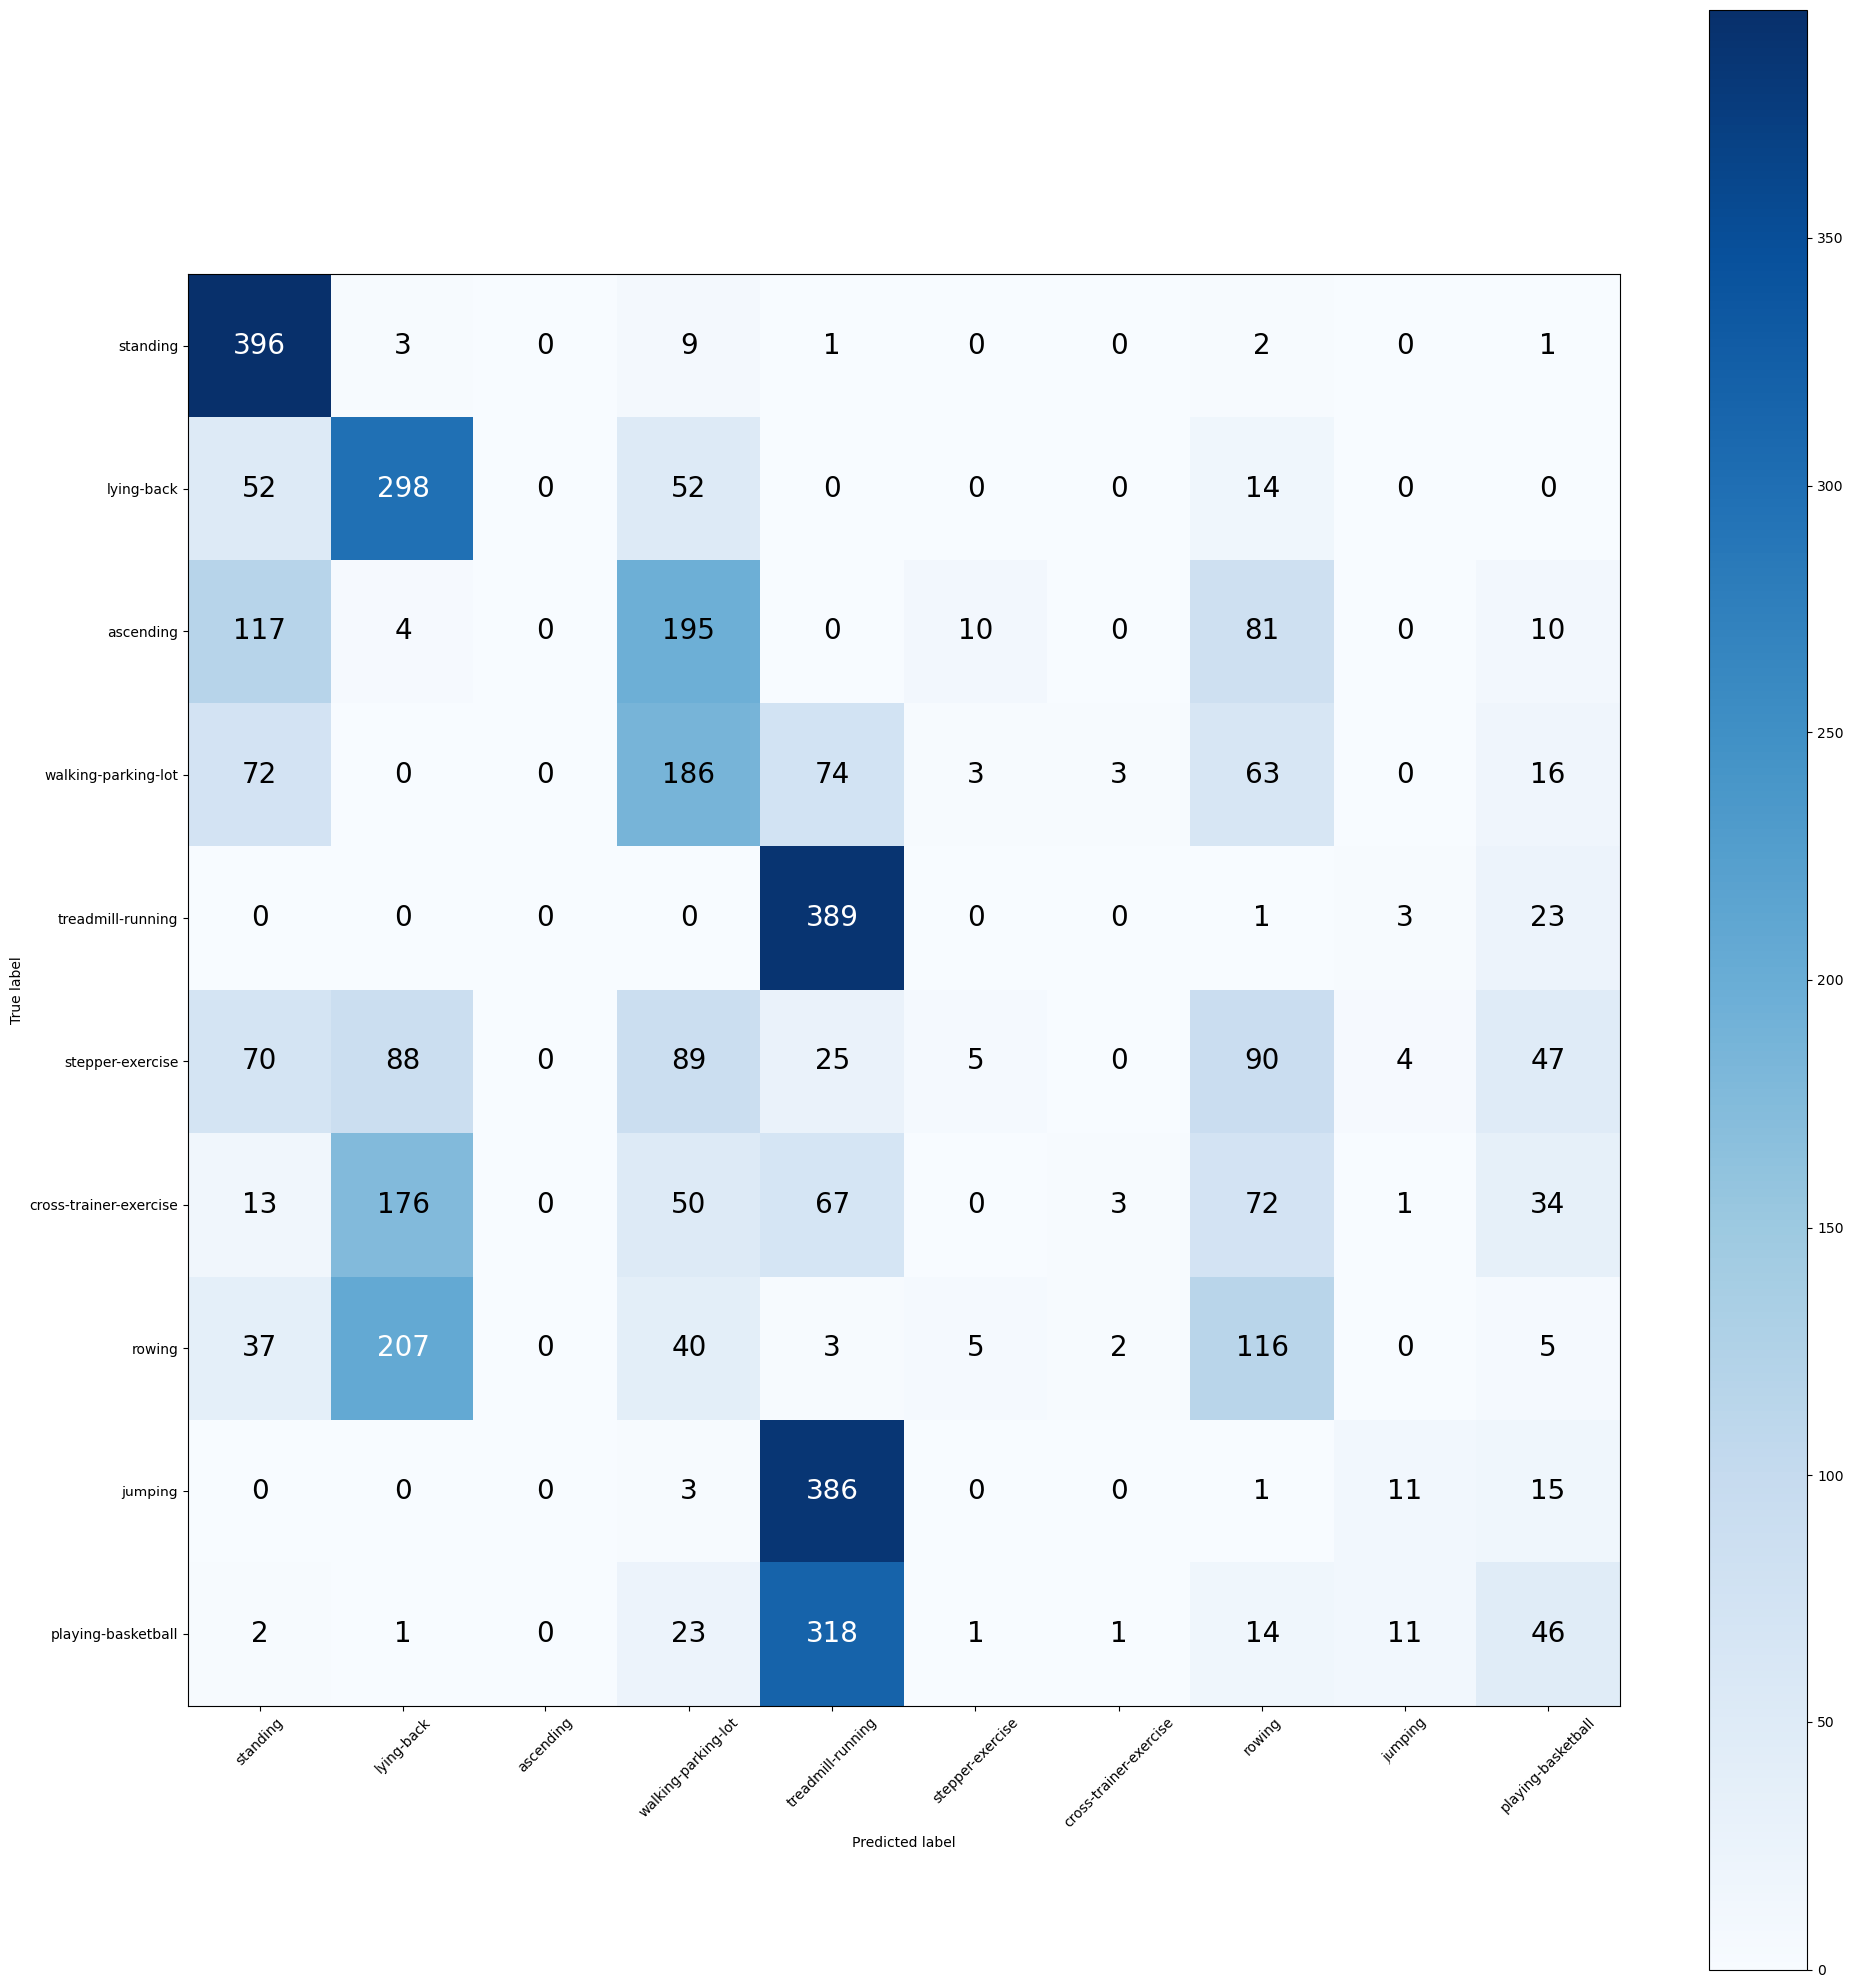

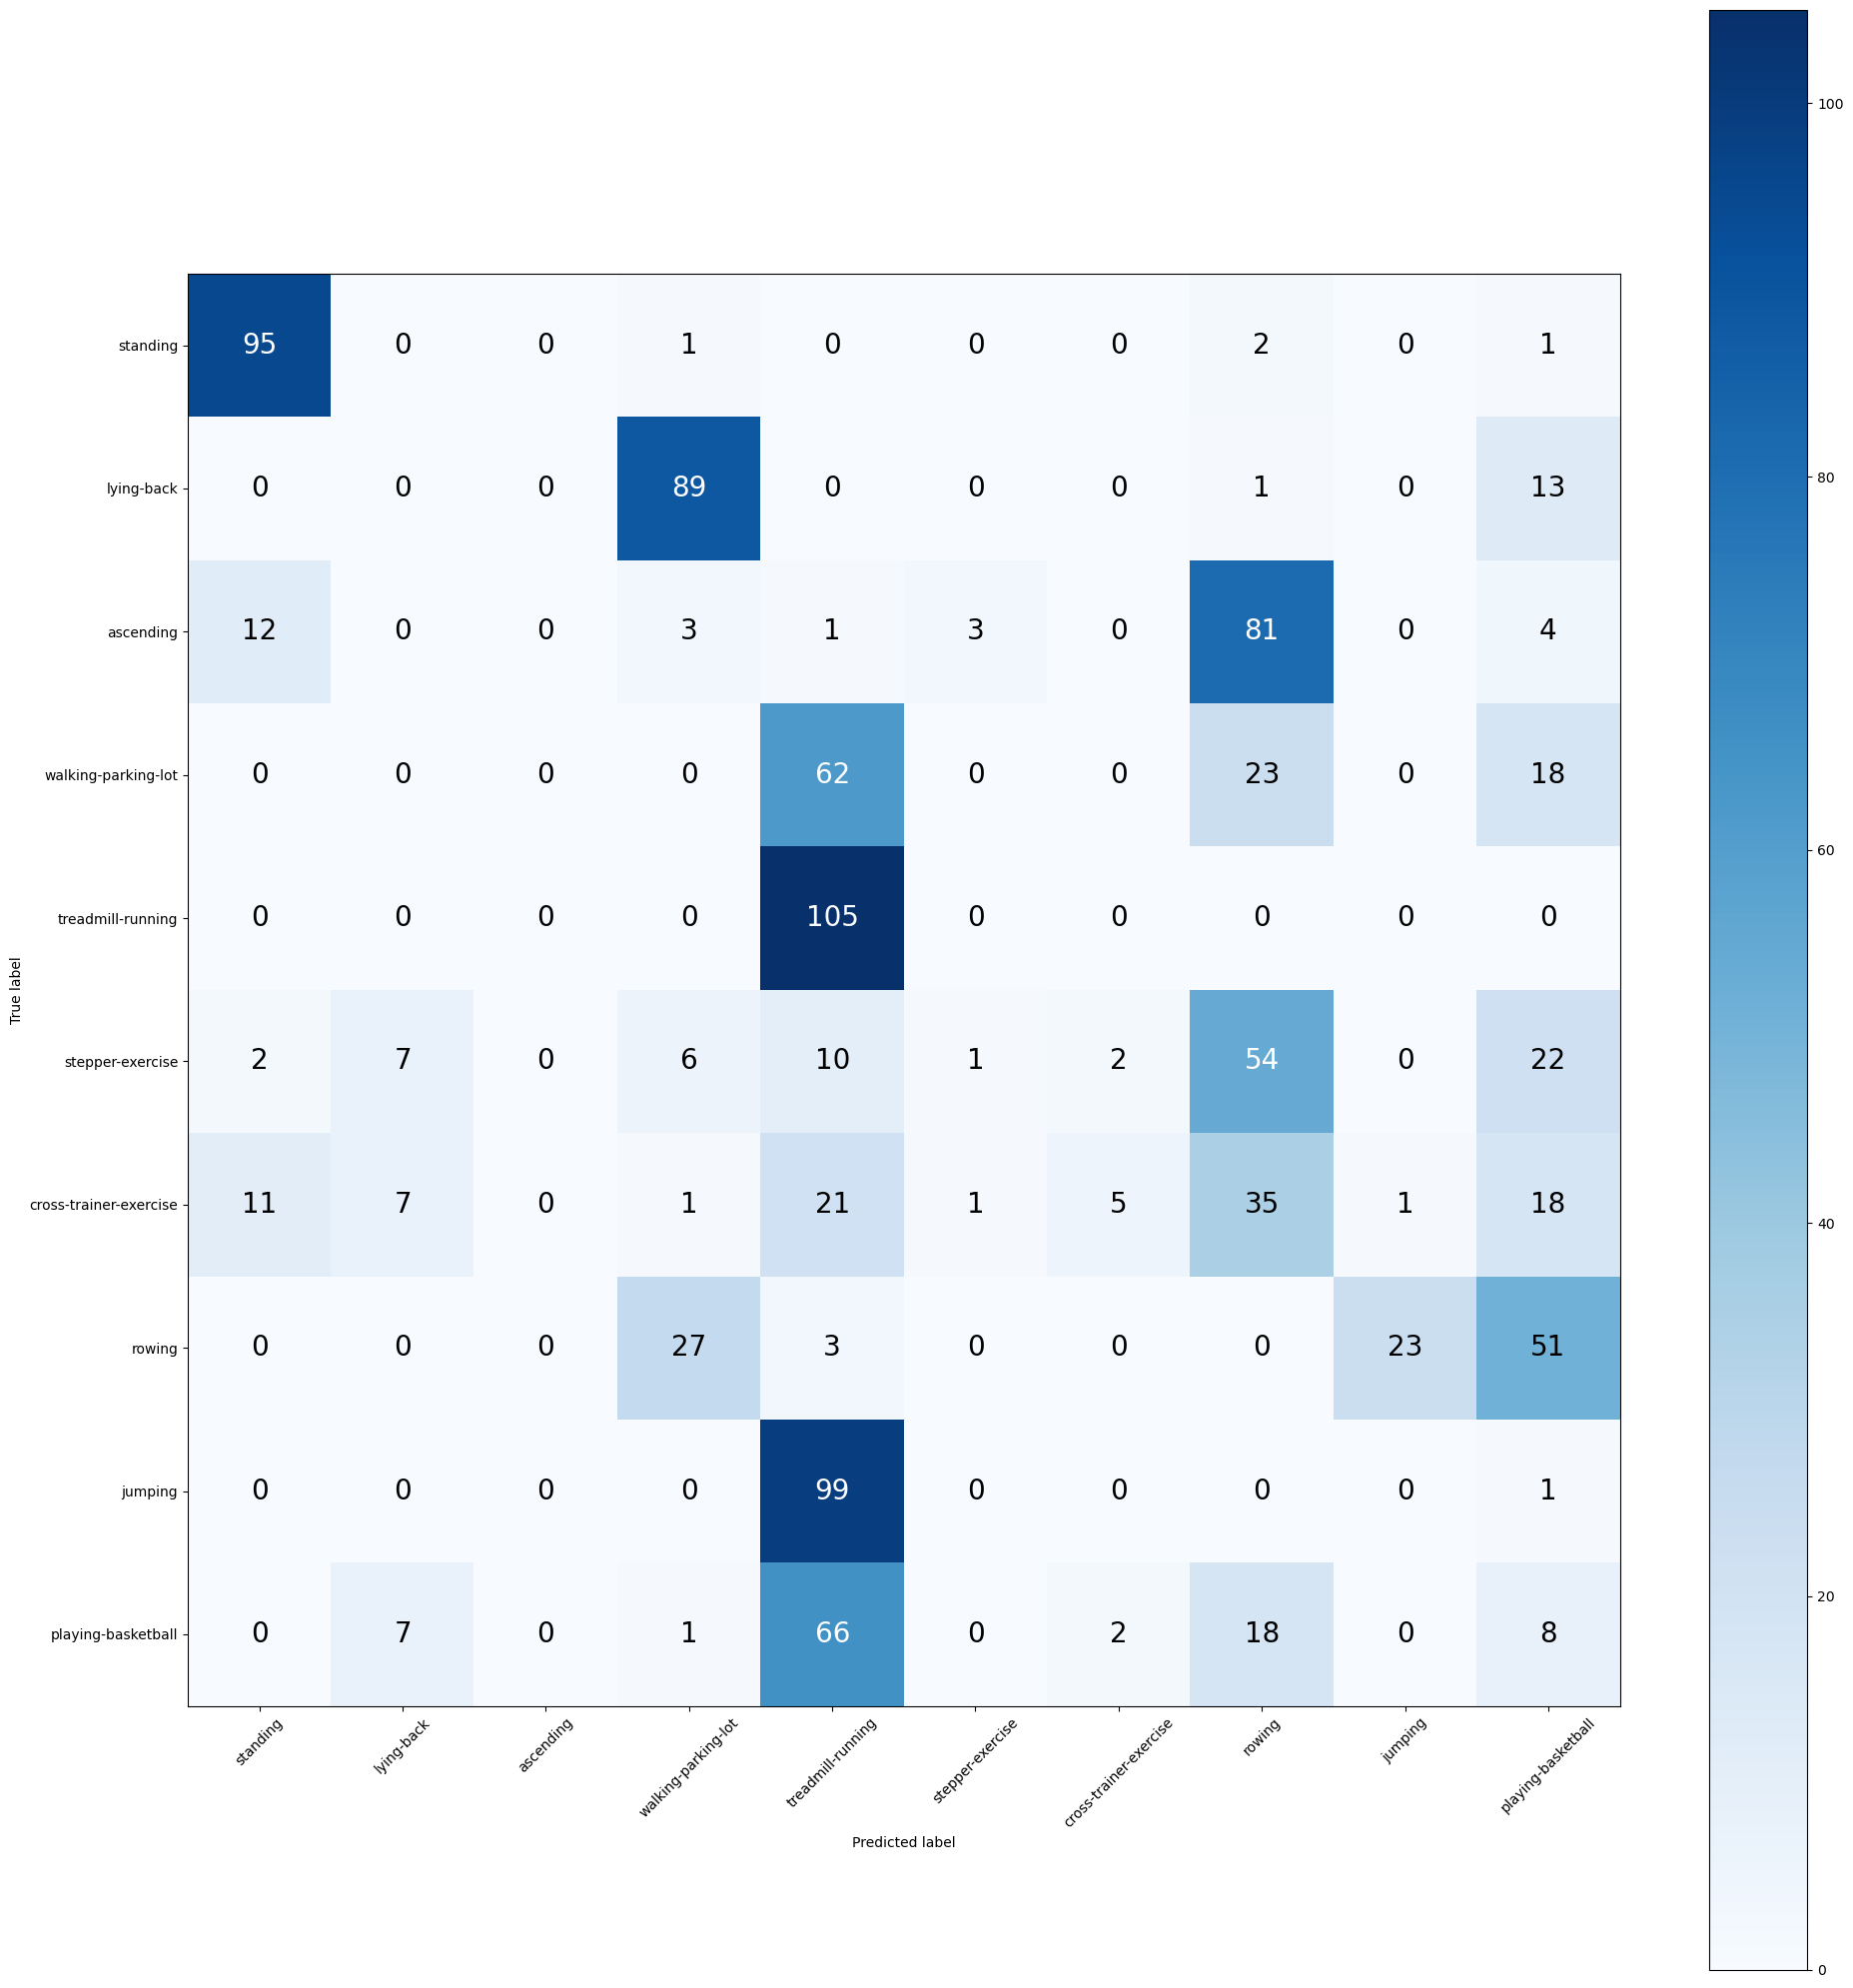

###Valid Source: Epoch: 3, avg_loss: 0.0589, Accuracy: 1450/4171 (34.76%)
###Valid Target: Epoch: 3, avg_loss: 0.0611, Accuracy: 214/1042 (20.54%)


Train Epoch:  4 [ 1/97]	Lambda: 0.2000, Class: 1.934854, CORAL: 0.005200, Total_Loss: 1.935894
Train Epoch:  4 [ 2/97]	Lambda: 0.2000, Class: 2.010968, CORAL: 0.099927, Total_Loss: 2.030954
Train Epoch:  4 [ 3/97]	Lambda: 0.2000, Class: 1.969568, CORAL: 0.079614, Total_Loss: 1.985491
Train Epoch:  4 [ 4/97]	Lambda: 0.2000, Class: 1.848325, CORAL: 0.076863, Total_Loss: 1.863698
Train Epoch:  4 [ 5/97]	Lambda: 0.2000, Class: 1.929639, CORAL: 0.469966, Total_Loss: 2.023632
Train Epoch:  4 [ 6/97]	Lambda: 0.2000, Class: 1.843668, CORAL: 0.273279, Total_Loss: 1.898324
Train Epoch:  4 [ 7/97]	Lambda: 0.2000, Class: 1.976800, CORAL: 0.337407, Total_Loss: 2.044281
Train Epoch:  4 [ 8/97]	Lambda: 0.2000, Class: 1.886270, CORAL: 0.109960, Total_Loss: 1.908262
Train Epoch:  4 [ 9/97]	Lambda: 0.2000, Class: 1.857127, CORAL: 0.039549, Total_Loss: 1.865

Train Epoch:  4 [90/97]	Lambda: 0.2000, Class: 1.721993, CORAL: 0.066891, Total_Loss: 1.735372
Train Epoch:  4 [91/97]	Lambda: 0.2000, Class: 1.799921, CORAL: 0.118807, Total_Loss: 1.823683
Train Epoch:  4 [92/97]	Lambda: 0.2000, Class: 1.830390, CORAL: 0.066177, Total_Loss: 1.843626
Train Epoch:  4 [93/97]	Lambda: 0.2000, Class: 1.874710, CORAL: 0.140316, Total_Loss: 1.902773
Train Epoch:  4 [94/97]	Lambda: 0.2000, Class: 1.832714, CORAL: 0.191974, Total_Loss: 1.871108
Train Epoch:  4 [95/97]	Lambda: 0.2000, Class: 1.895948, CORAL: 0.716006, Total_Loss: 2.039149
Train Epoch:  4 [96/97]	Lambda: 0.2000, Class: 1.762100, CORAL: 0.626943, Total_Loss: 1.887489
Train Epoch:  4 [97/97]	Lambda: 0.2000, Class: 1.842994, CORAL: 0.086408, Total_Loss: 1.860276
###EPOCH 4: Class: 1.838377, CORAL: 0.210848, Total_Loss: 1.880547


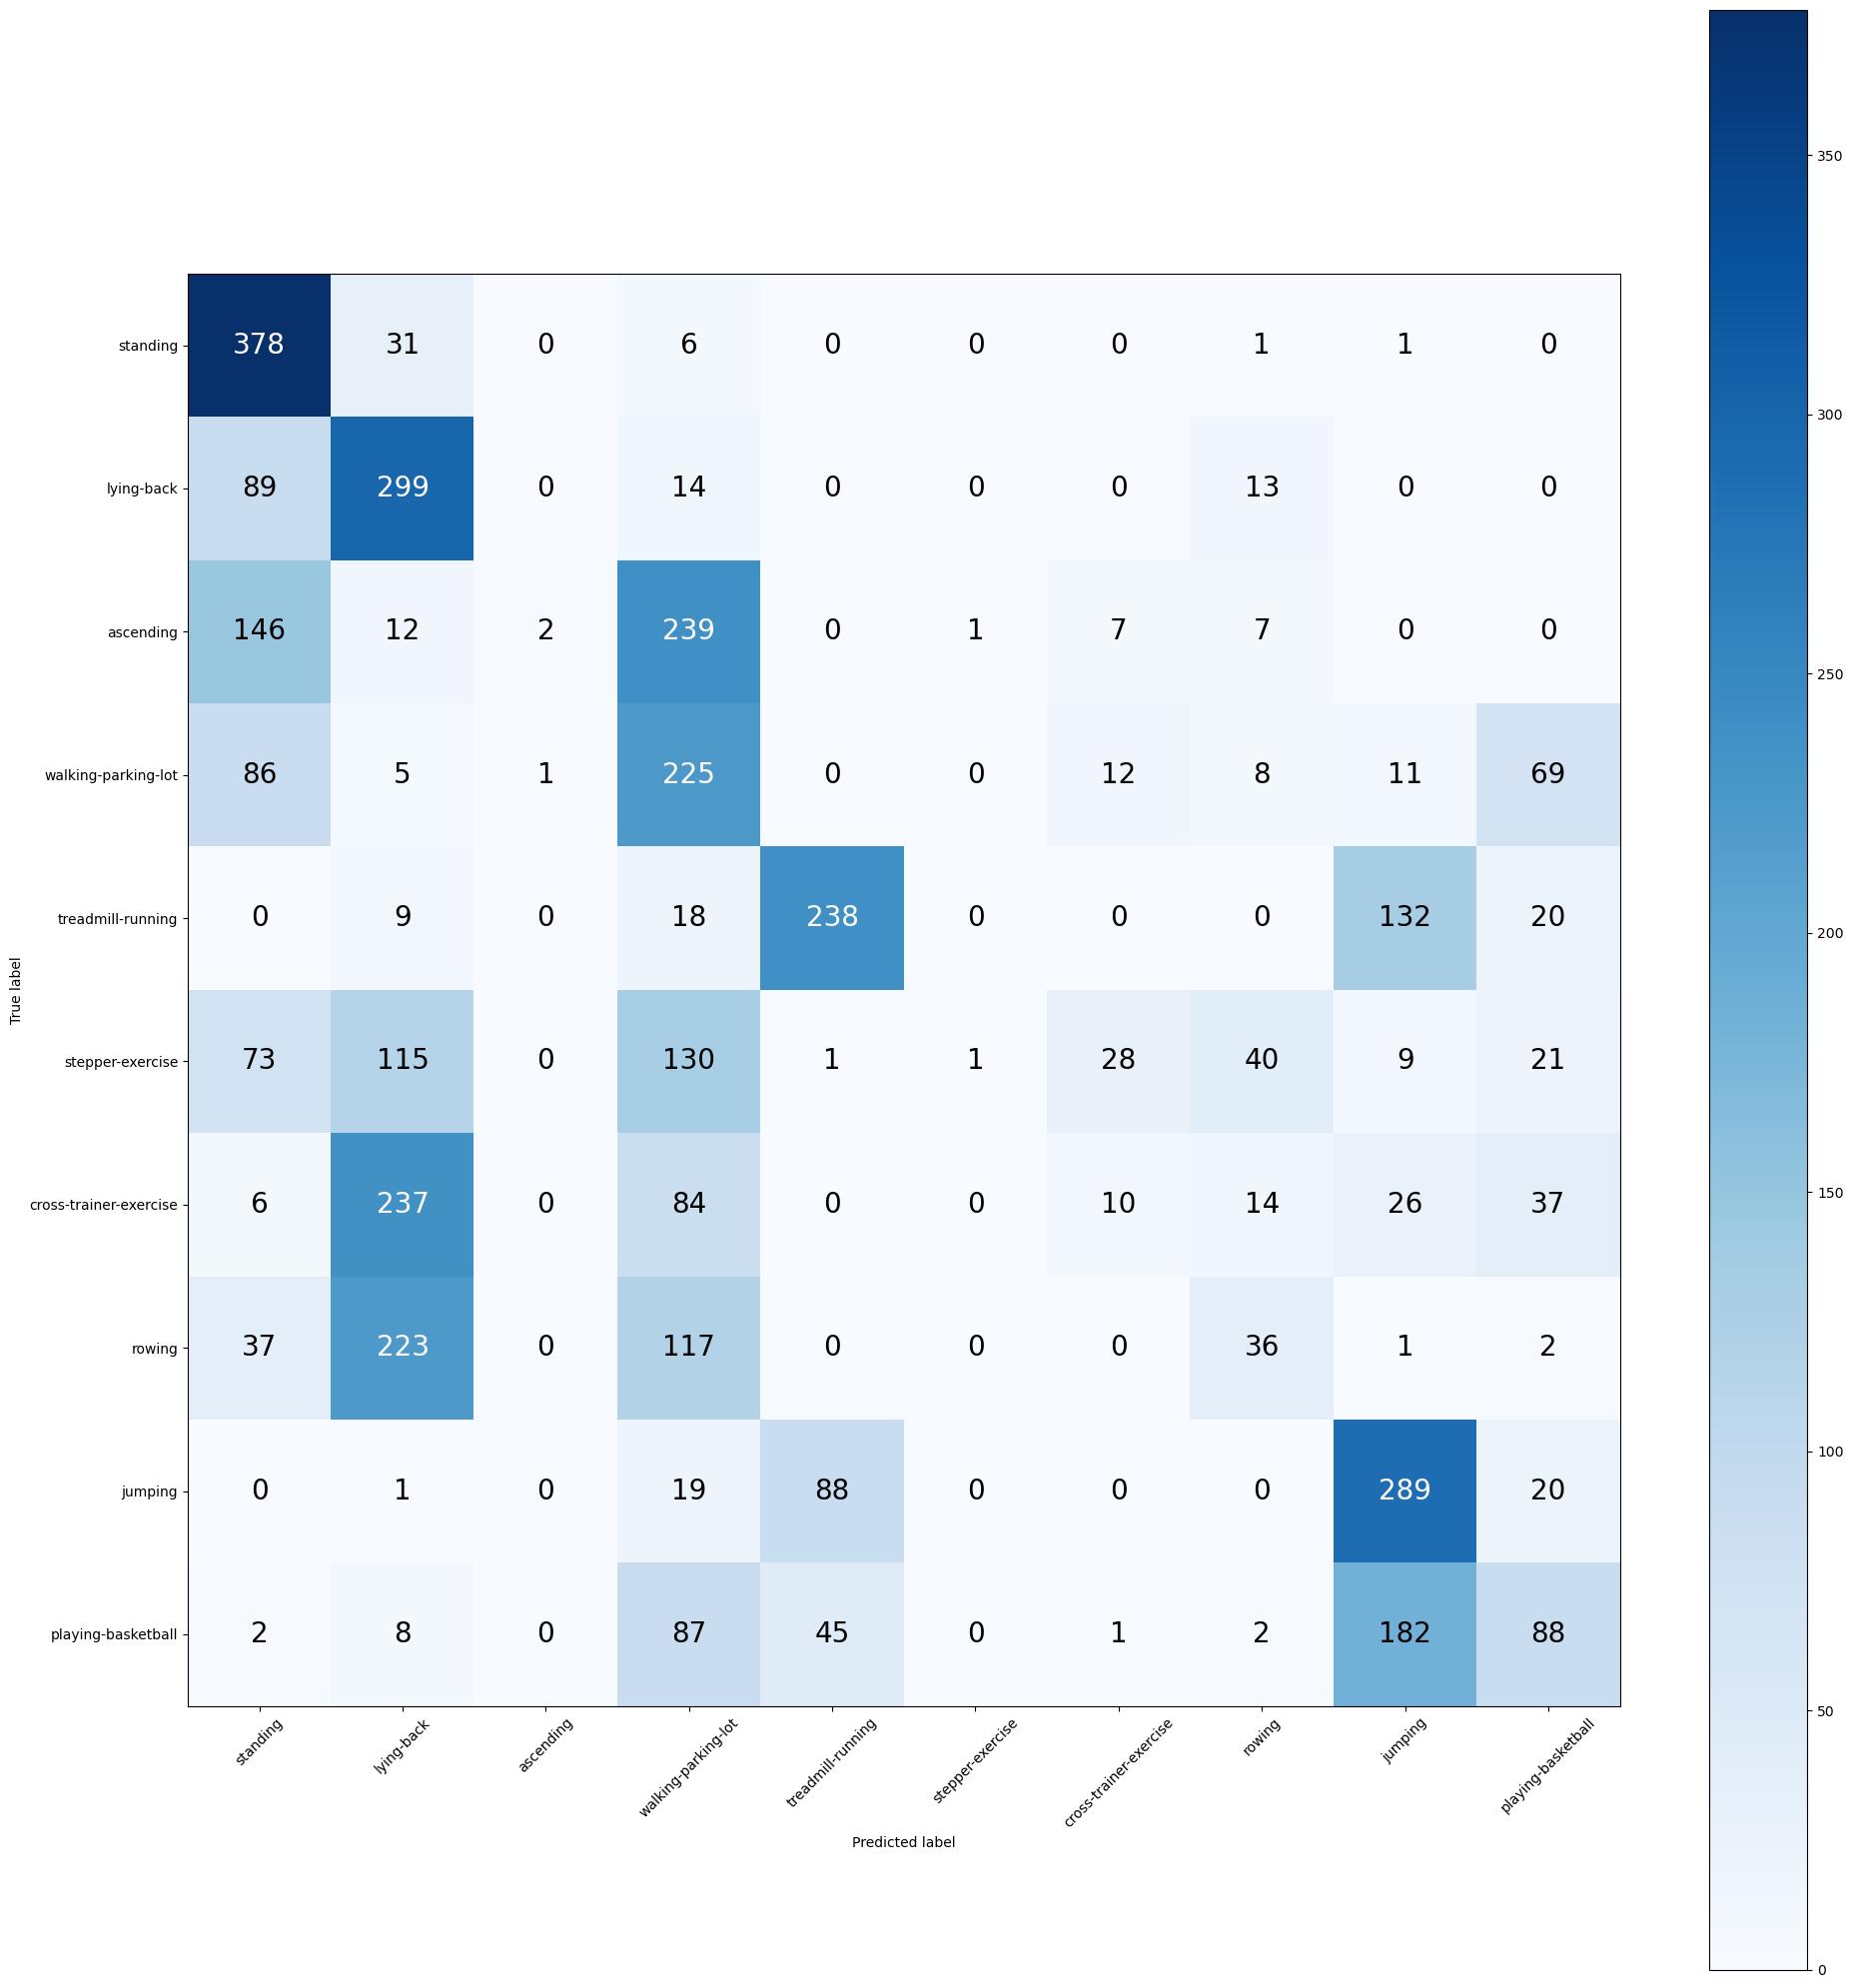

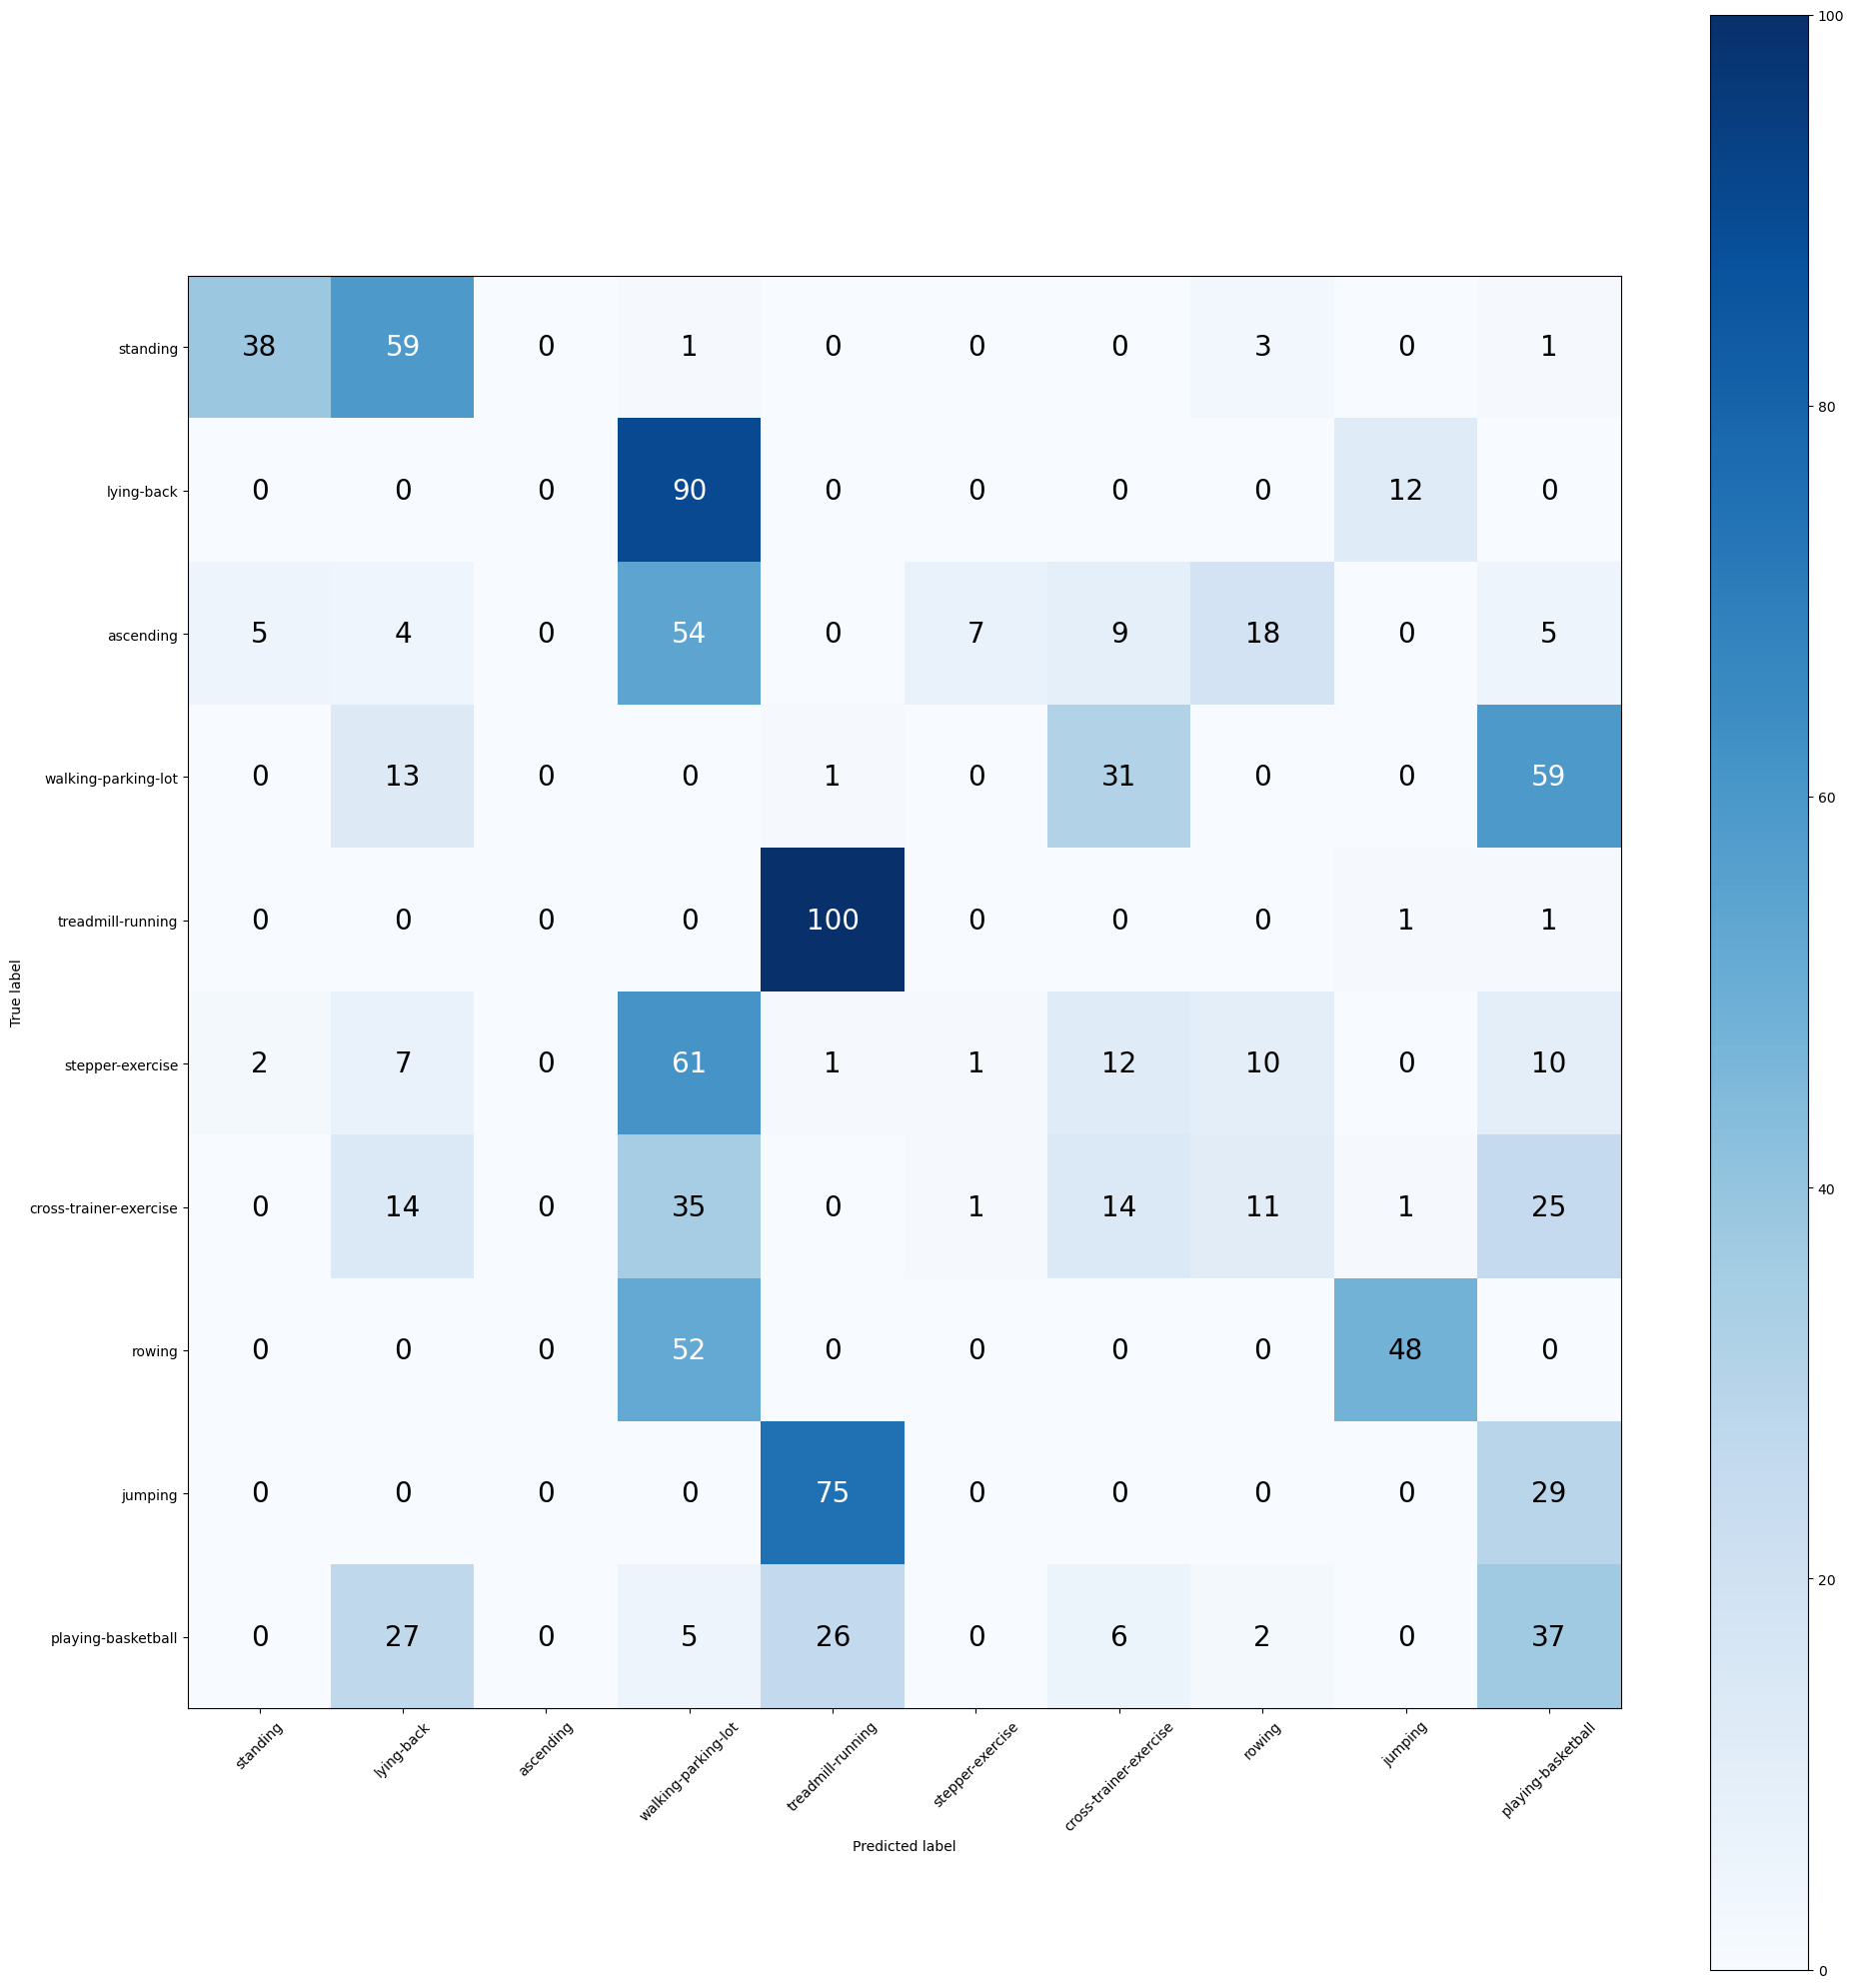

###Valid Source: Epoch: 4, avg_loss: 0.0551, Accuracy: 1566/4171 (37.54%)
###Valid Target: Epoch: 4, avg_loss: 0.0631, Accuracy: 190/1042 (18.23%)


Train Epoch:  5 [ 1/97]	Lambda: 0.2500, Class: 1.655669, CORAL: 0.185919, Total_Loss: 1.702149
Train Epoch:  5 [ 2/97]	Lambda: 0.2500, Class: 1.946965, CORAL: 0.215072, Total_Loss: 2.000733
Train Epoch:  5 [ 3/97]	Lambda: 0.2500, Class: 1.715557, CORAL: 0.030484, Total_Loss: 1.723178
Train Epoch:  5 [ 4/97]	Lambda: 0.2500, Class: 1.629570, CORAL: 0.269832, Total_Loss: 1.697028
Train Epoch:  5 [ 5/97]	Lambda: 0.2500, Class: 1.829917, CORAL: 0.342115, Total_Loss: 1.915446
Train Epoch:  5 [ 6/97]	Lambda: 0.2500, Class: 1.634062, CORAL: 0.265004, Total_Loss: 1.700313
Train Epoch:  5 [ 7/97]	Lambda: 0.2500, Class: 1.691825, CORAL: 0.201591, Total_Loss: 1.742222
Train Epoch:  5 [ 8/97]	Lambda: 0.2500, Class: 1.712364, CORAL: 0.169812, Total_Loss: 1.754817
Train Epoch:  5 [ 9/97]	Lambda: 0.2500, Class: 1.854786, CORAL: 0.073884, Total_Loss: 1.873

Train Epoch:  5 [89/97]	Lambda: 0.2500, Class: 1.678238, CORAL: 0.110182, Total_Loss: 1.705784
Train Epoch:  5 [90/97]	Lambda: 0.2500, Class: 1.775239, CORAL: 0.217197, Total_Loss: 1.829538
Train Epoch:  5 [91/97]	Lambda: 0.2500, Class: 1.680092, CORAL: 0.291639, Total_Loss: 1.753002
Train Epoch:  5 [92/97]	Lambda: 0.2500, Class: 1.751173, CORAL: 0.151526, Total_Loss: 1.789054
Train Epoch:  5 [93/97]	Lambda: 0.2500, Class: 1.786165, CORAL: 0.024324, Total_Loss: 1.792246
Train Epoch:  5 [94/97]	Lambda: 0.2500, Class: 1.639421, CORAL: 0.260492, Total_Loss: 1.704544
Train Epoch:  5 [95/97]	Lambda: 0.2500, Class: 1.695970, CORAL: 0.046496, Total_Loss: 1.707594
Train Epoch:  5 [96/97]	Lambda: 0.2500, Class: 1.692426, CORAL: 0.263882, Total_Loss: 1.758396
Train Epoch:  5 [97/97]	Lambda: 0.2500, Class: 1.654577, CORAL: 0.039875, Total_Loss: 1.664546
###EPOCH 5: Class: 1.748769, CORAL: 0.208529, Total_Loss: 1.800901


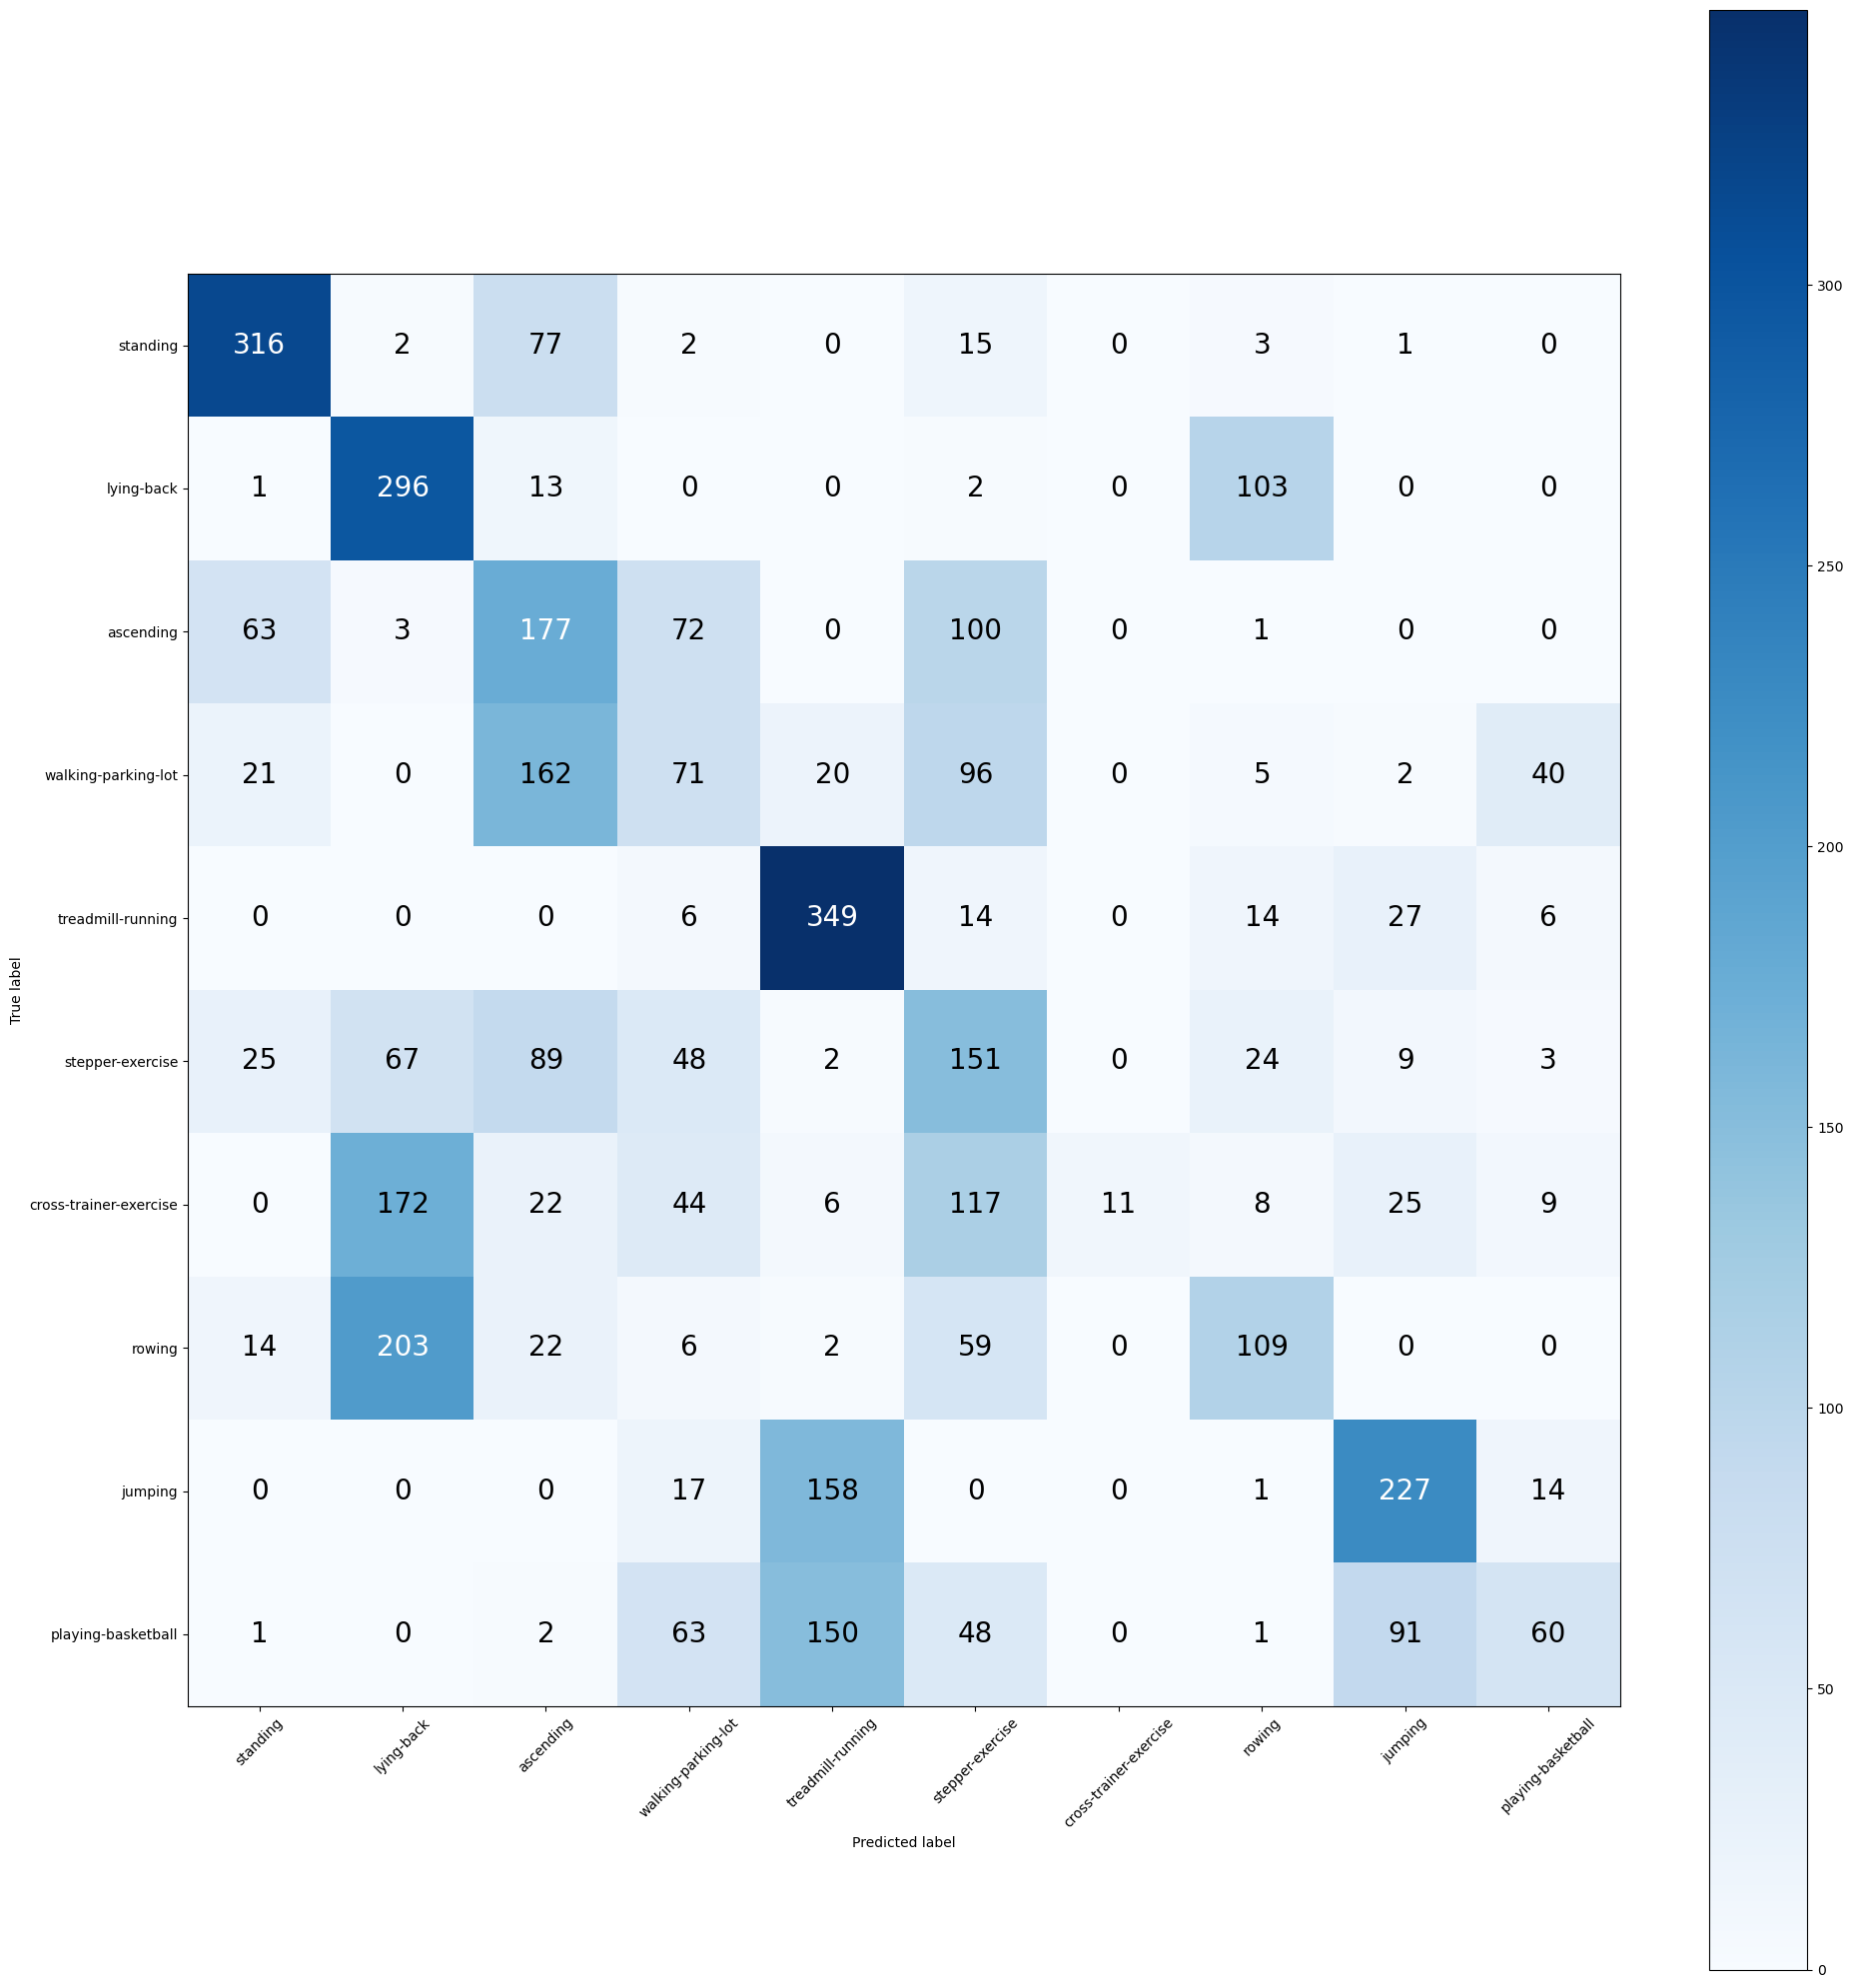

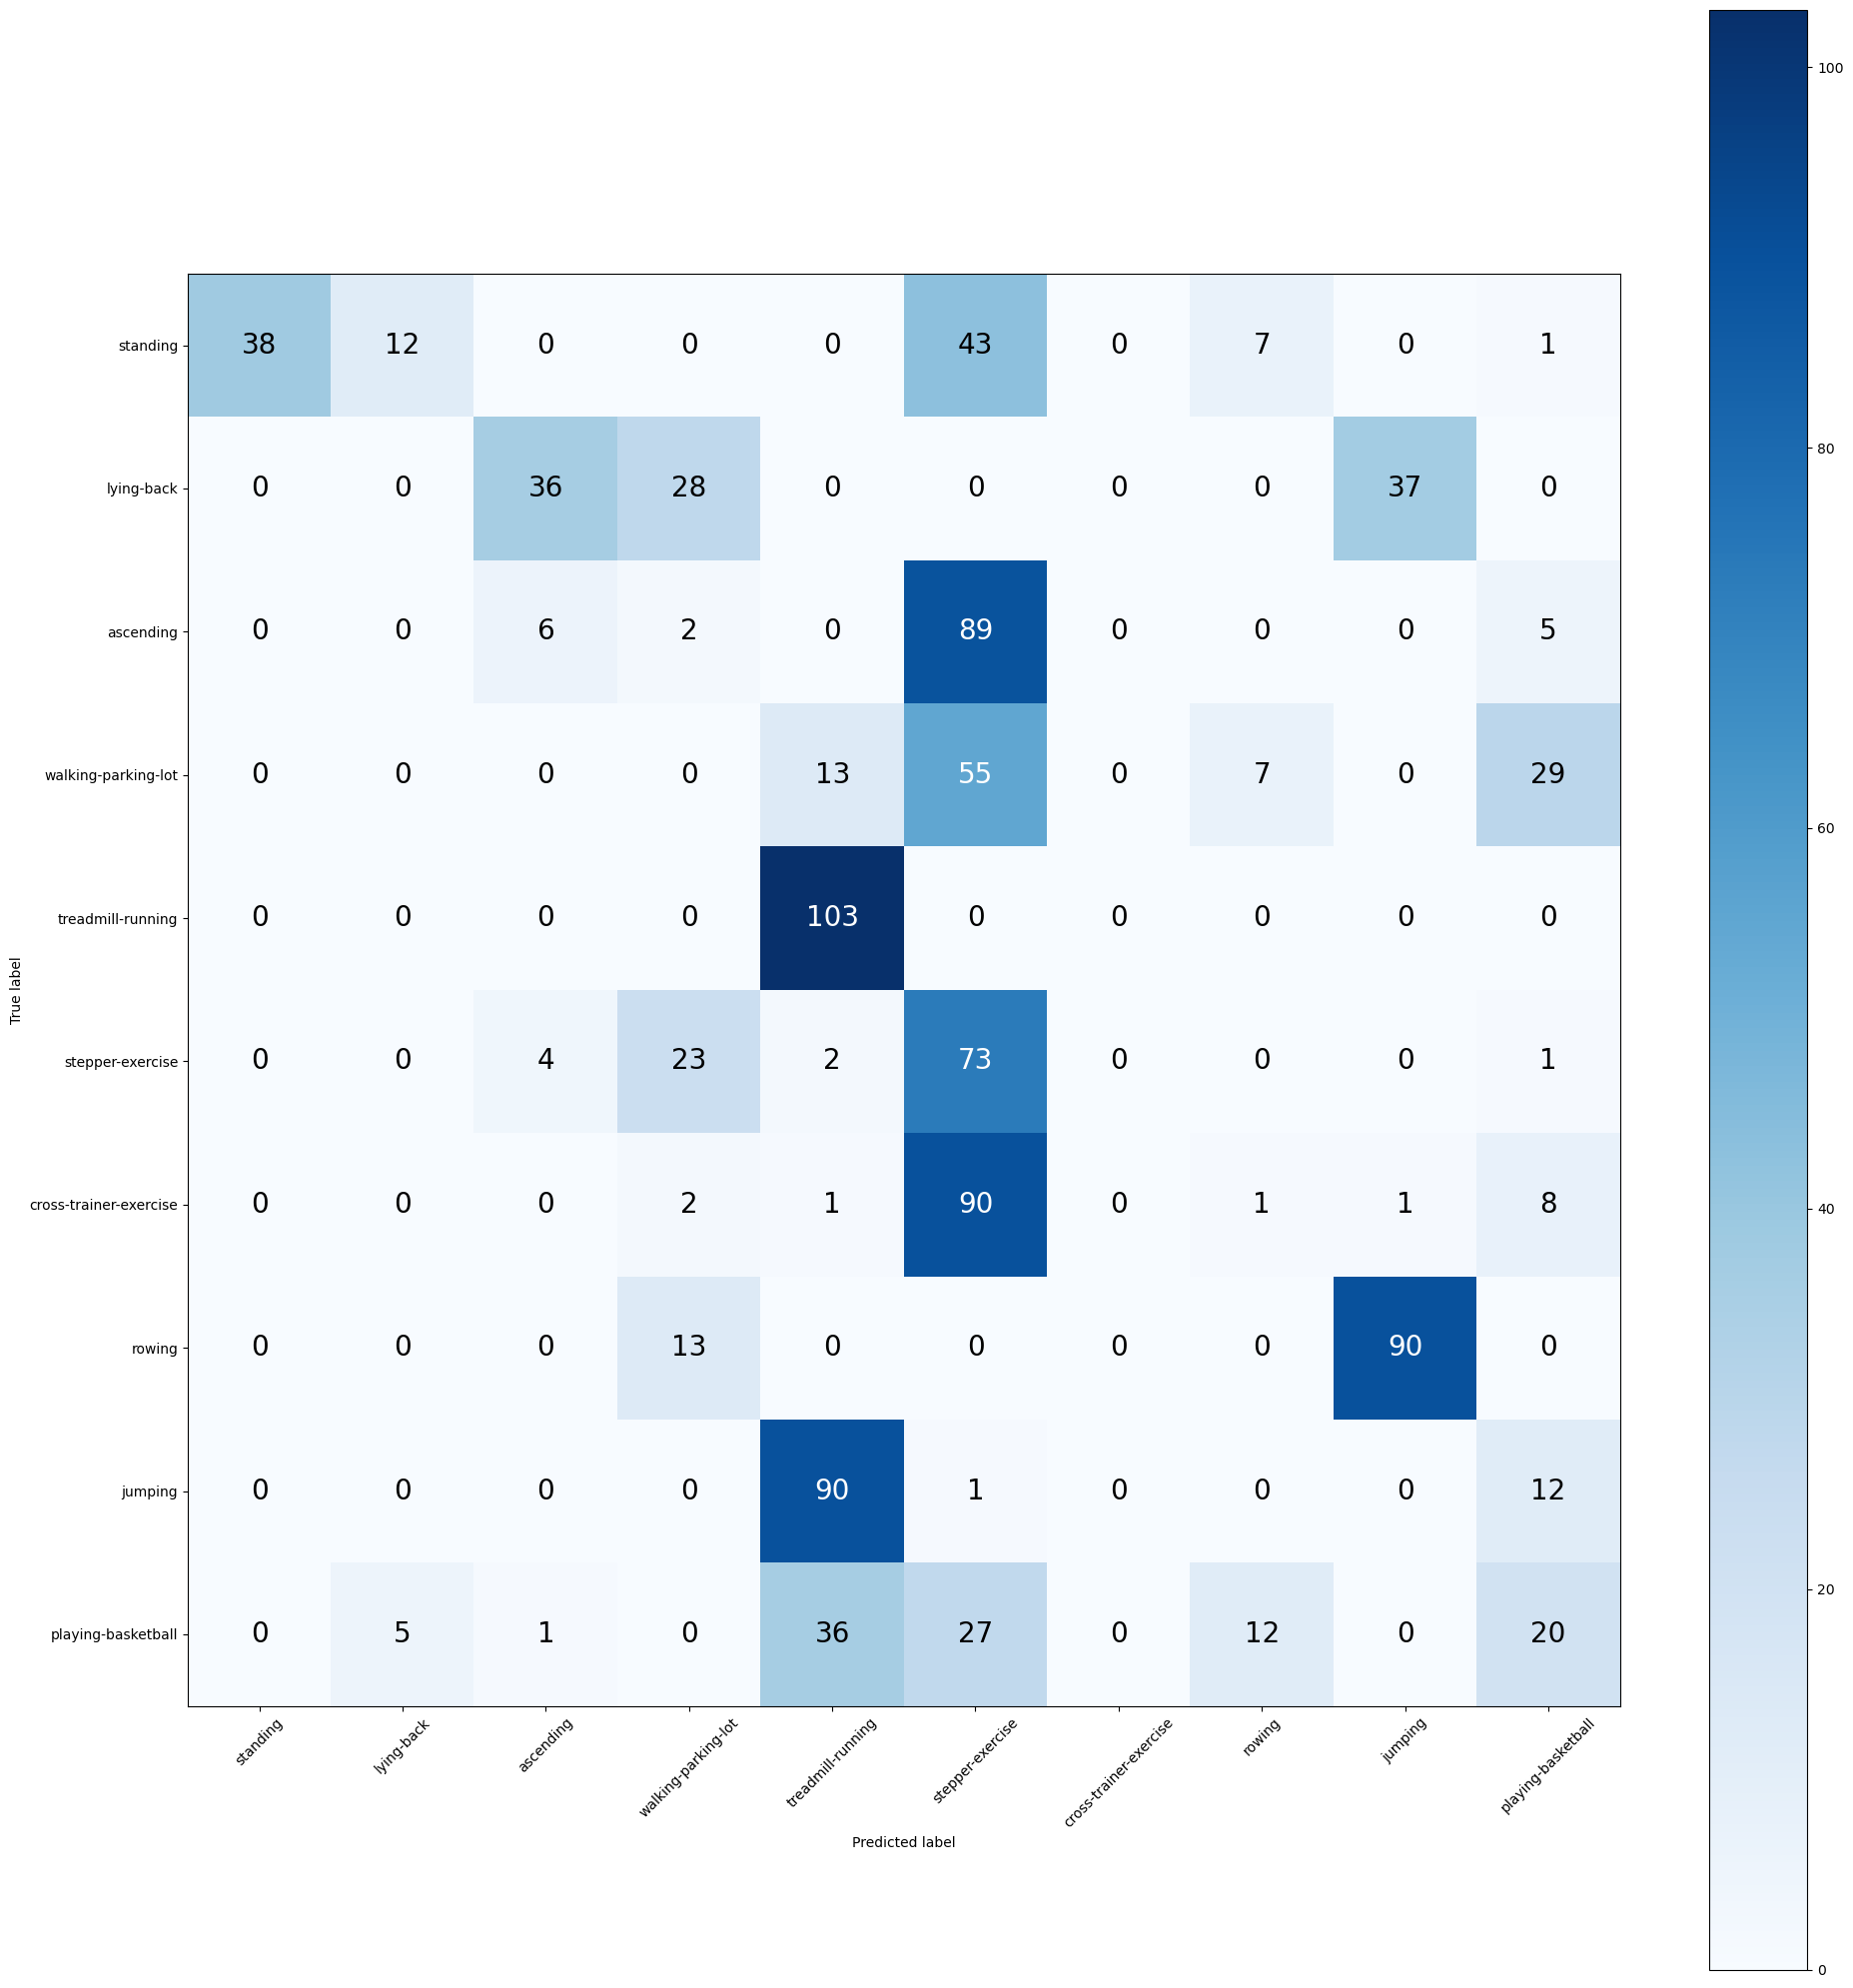

###Valid Source: Epoch: 5, avg_loss: 0.0532, Accuracy: 1767/4171 (42.36%)
###Valid Target: Epoch: 5, avg_loss: 0.0647, Accuracy: 240/1042 (23.03%)


Train Epoch:  6 [ 1/97]	Lambda: 0.3000, Class: 1.676678, CORAL: 0.540294, Total_Loss: 1.838766
Train Epoch:  6 [ 2/97]	Lambda: 0.3000, Class: 1.650559, CORAL: 0.253832, Total_Loss: 1.726708
Train Epoch:  6 [ 3/97]	Lambda: 0.3000, Class: 1.760605, CORAL: 0.097738, Total_Loss: 1.789926
Train Epoch:  6 [ 4/97]	Lambda: 0.3000, Class: 1.684844, CORAL: 0.113411, Total_Loss: 1.718867
Train Epoch:  6 [ 5/97]	Lambda: 0.3000, Class: 1.872909, CORAL: 0.051027, Total_Loss: 1.888217
Train Epoch:  6 [ 6/97]	Lambda: 0.3000, Class: 1.636451, CORAL: 0.288415, Total_Loss: 1.722976
Train Epoch:  6 [ 7/97]	Lambda: 0.3000, Class: 1.685797, CORAL: 0.082348, Total_Loss: 1.710501
Train Epoch:  6 [ 8/97]	Lambda: 0.3000, Class: 1.789433, CORAL: 0.080962, Total_Loss: 1.813721
Train Epoch:  6 [ 9/97]	Lambda: 0.3000, Class: 1.791420, CORAL: 0.042482, Total_Loss: 1.804

Train Epoch:  6 [90/97]	Lambda: 0.3000, Class: 1.689017, CORAL: 0.099755, Total_Loss: 1.718943
Train Epoch:  6 [91/97]	Lambda: 0.3000, Class: 1.568756, CORAL: 0.149231, Total_Loss: 1.613526
Train Epoch:  6 [92/97]	Lambda: 0.3000, Class: 1.743925, CORAL: 0.052009, Total_Loss: 1.759527
Train Epoch:  6 [93/97]	Lambda: 0.3000, Class: 1.448883, CORAL: 0.387194, Total_Loss: 1.565041
Train Epoch:  6 [94/97]	Lambda: 0.3000, Class: 1.628609, CORAL: 0.075305, Total_Loss: 1.651201
Train Epoch:  6 [95/97]	Lambda: 0.3000, Class: 1.596680, CORAL: 0.198949, Total_Loss: 1.656365
Train Epoch:  6 [96/97]	Lambda: 0.3000, Class: 1.719923, CORAL: 0.238836, Total_Loss: 1.791574
Train Epoch:  6 [97/97]	Lambda: 0.3000, Class: 1.752048, CORAL: 0.050202, Total_Loss: 1.767109
###EPOCH 6: Class: 1.670746, CORAL: 0.183107, Total_Loss: 1.725678


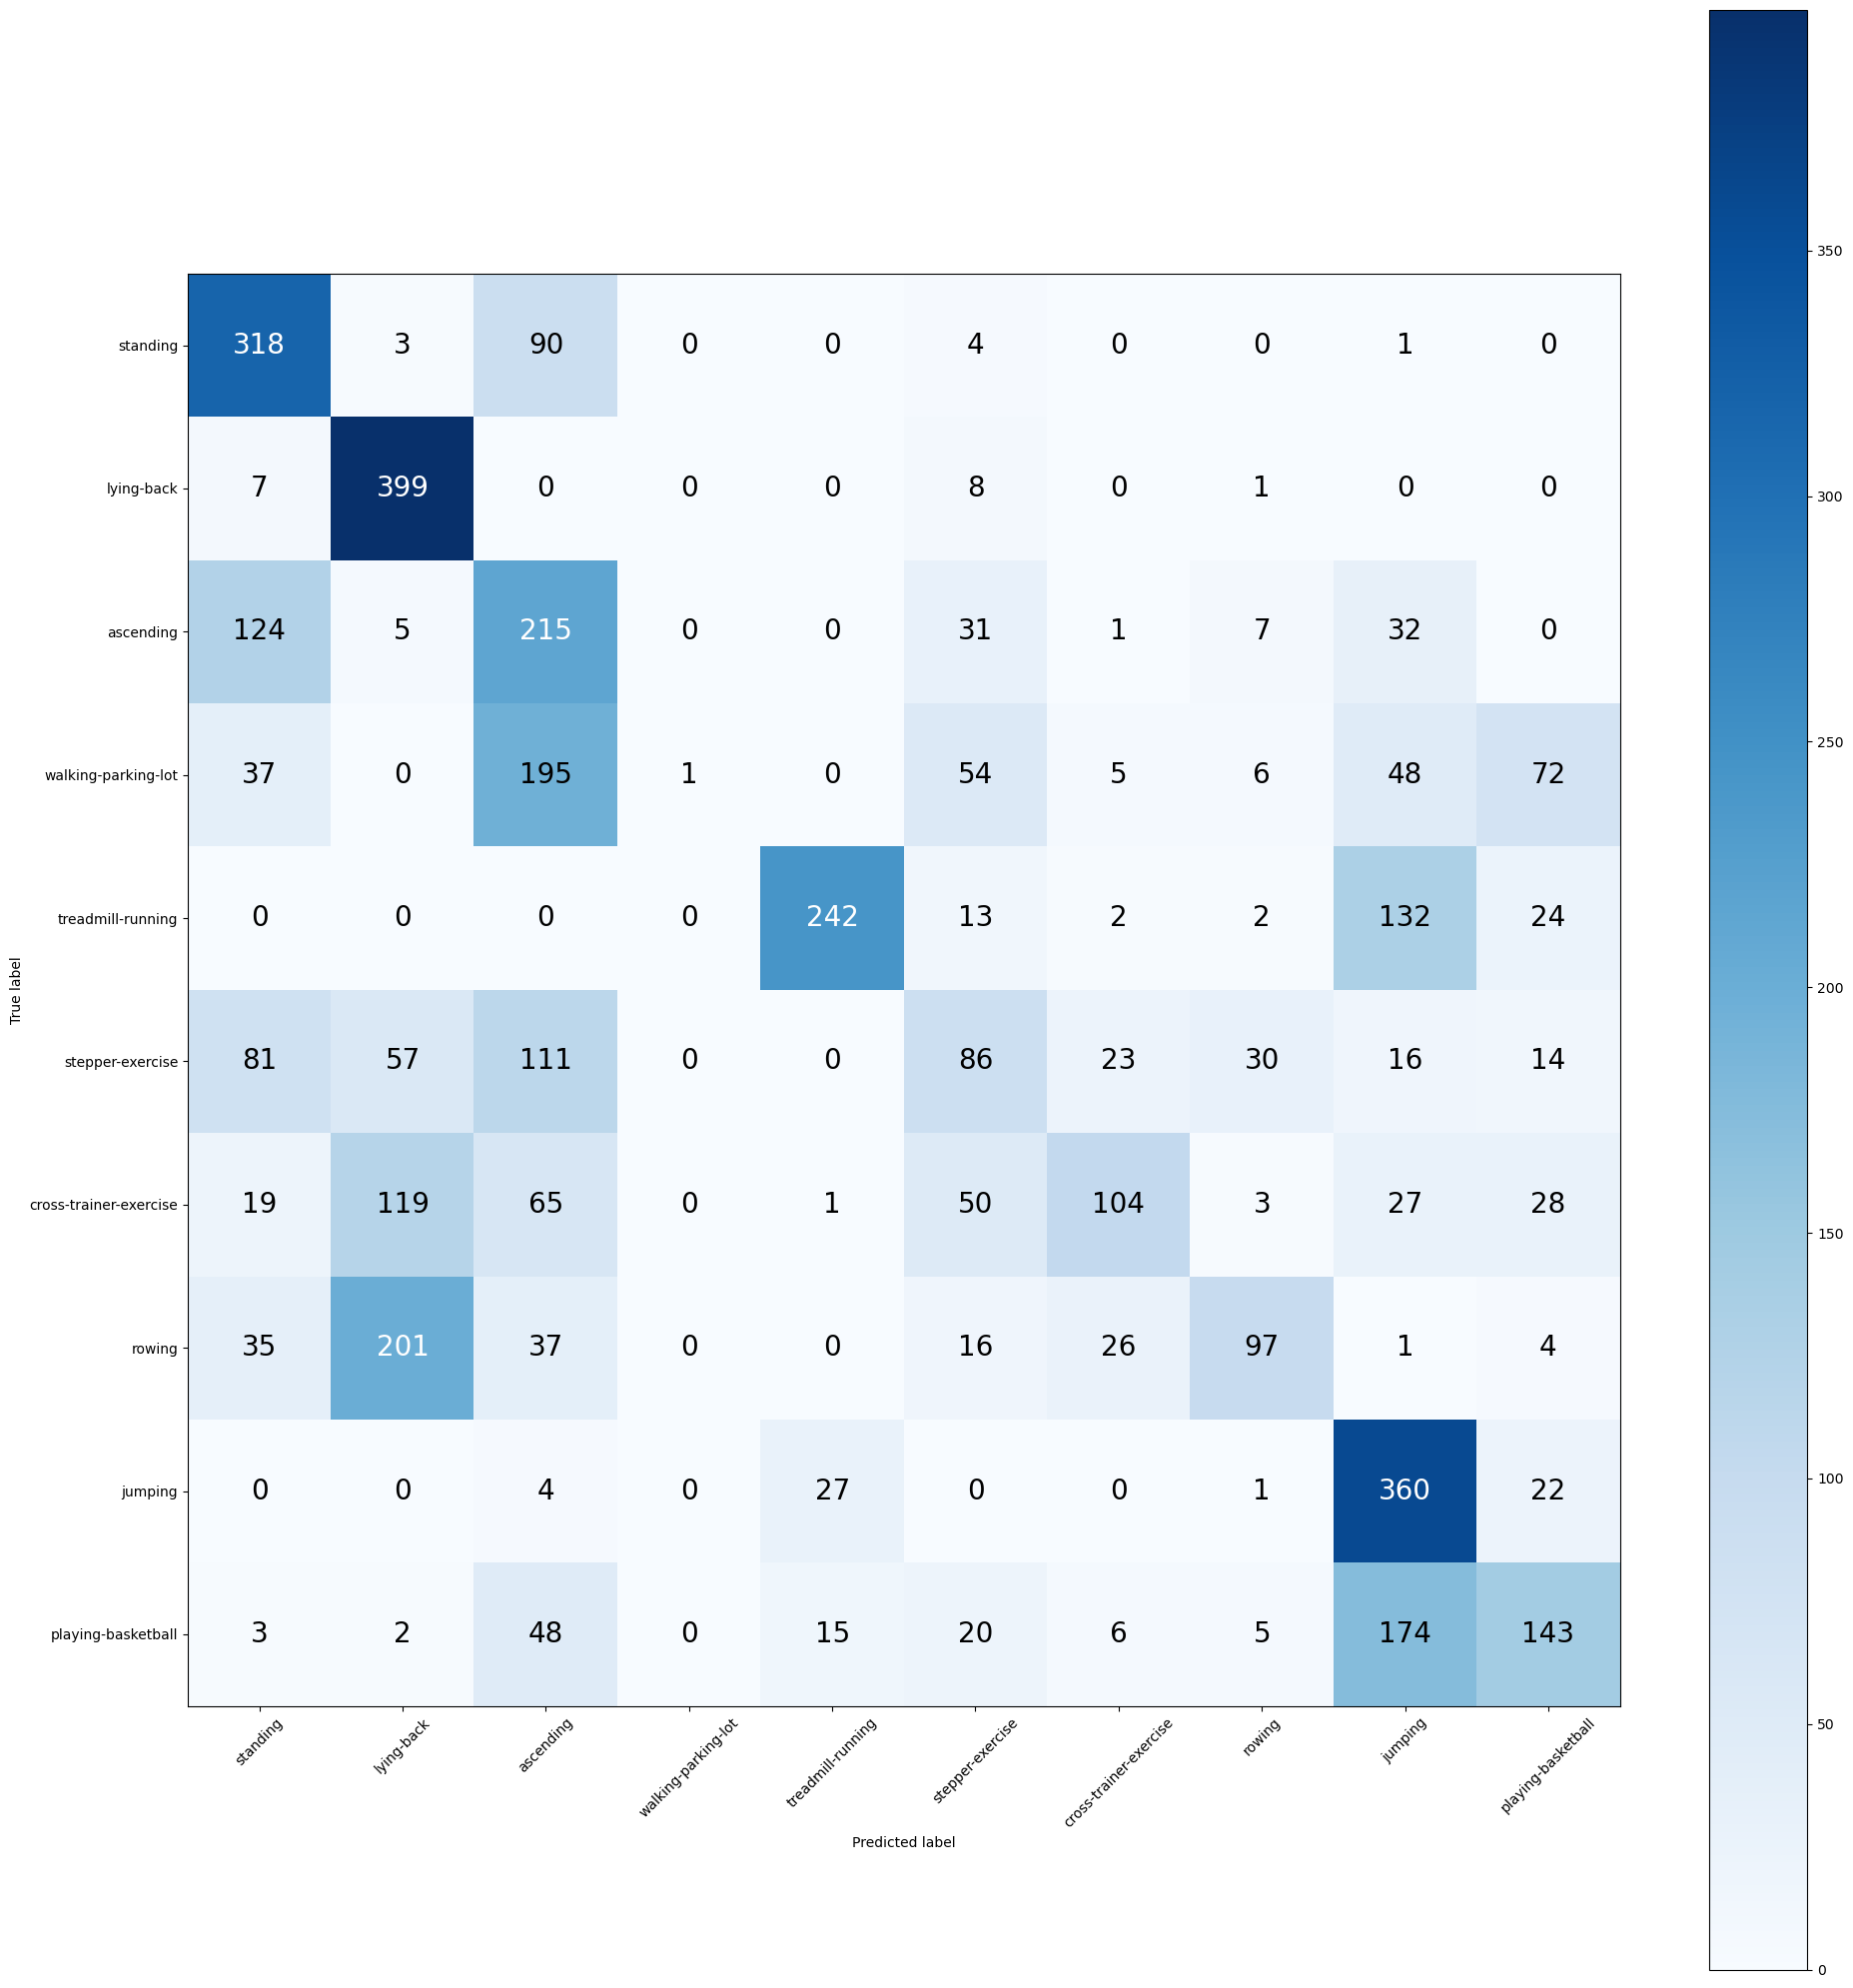

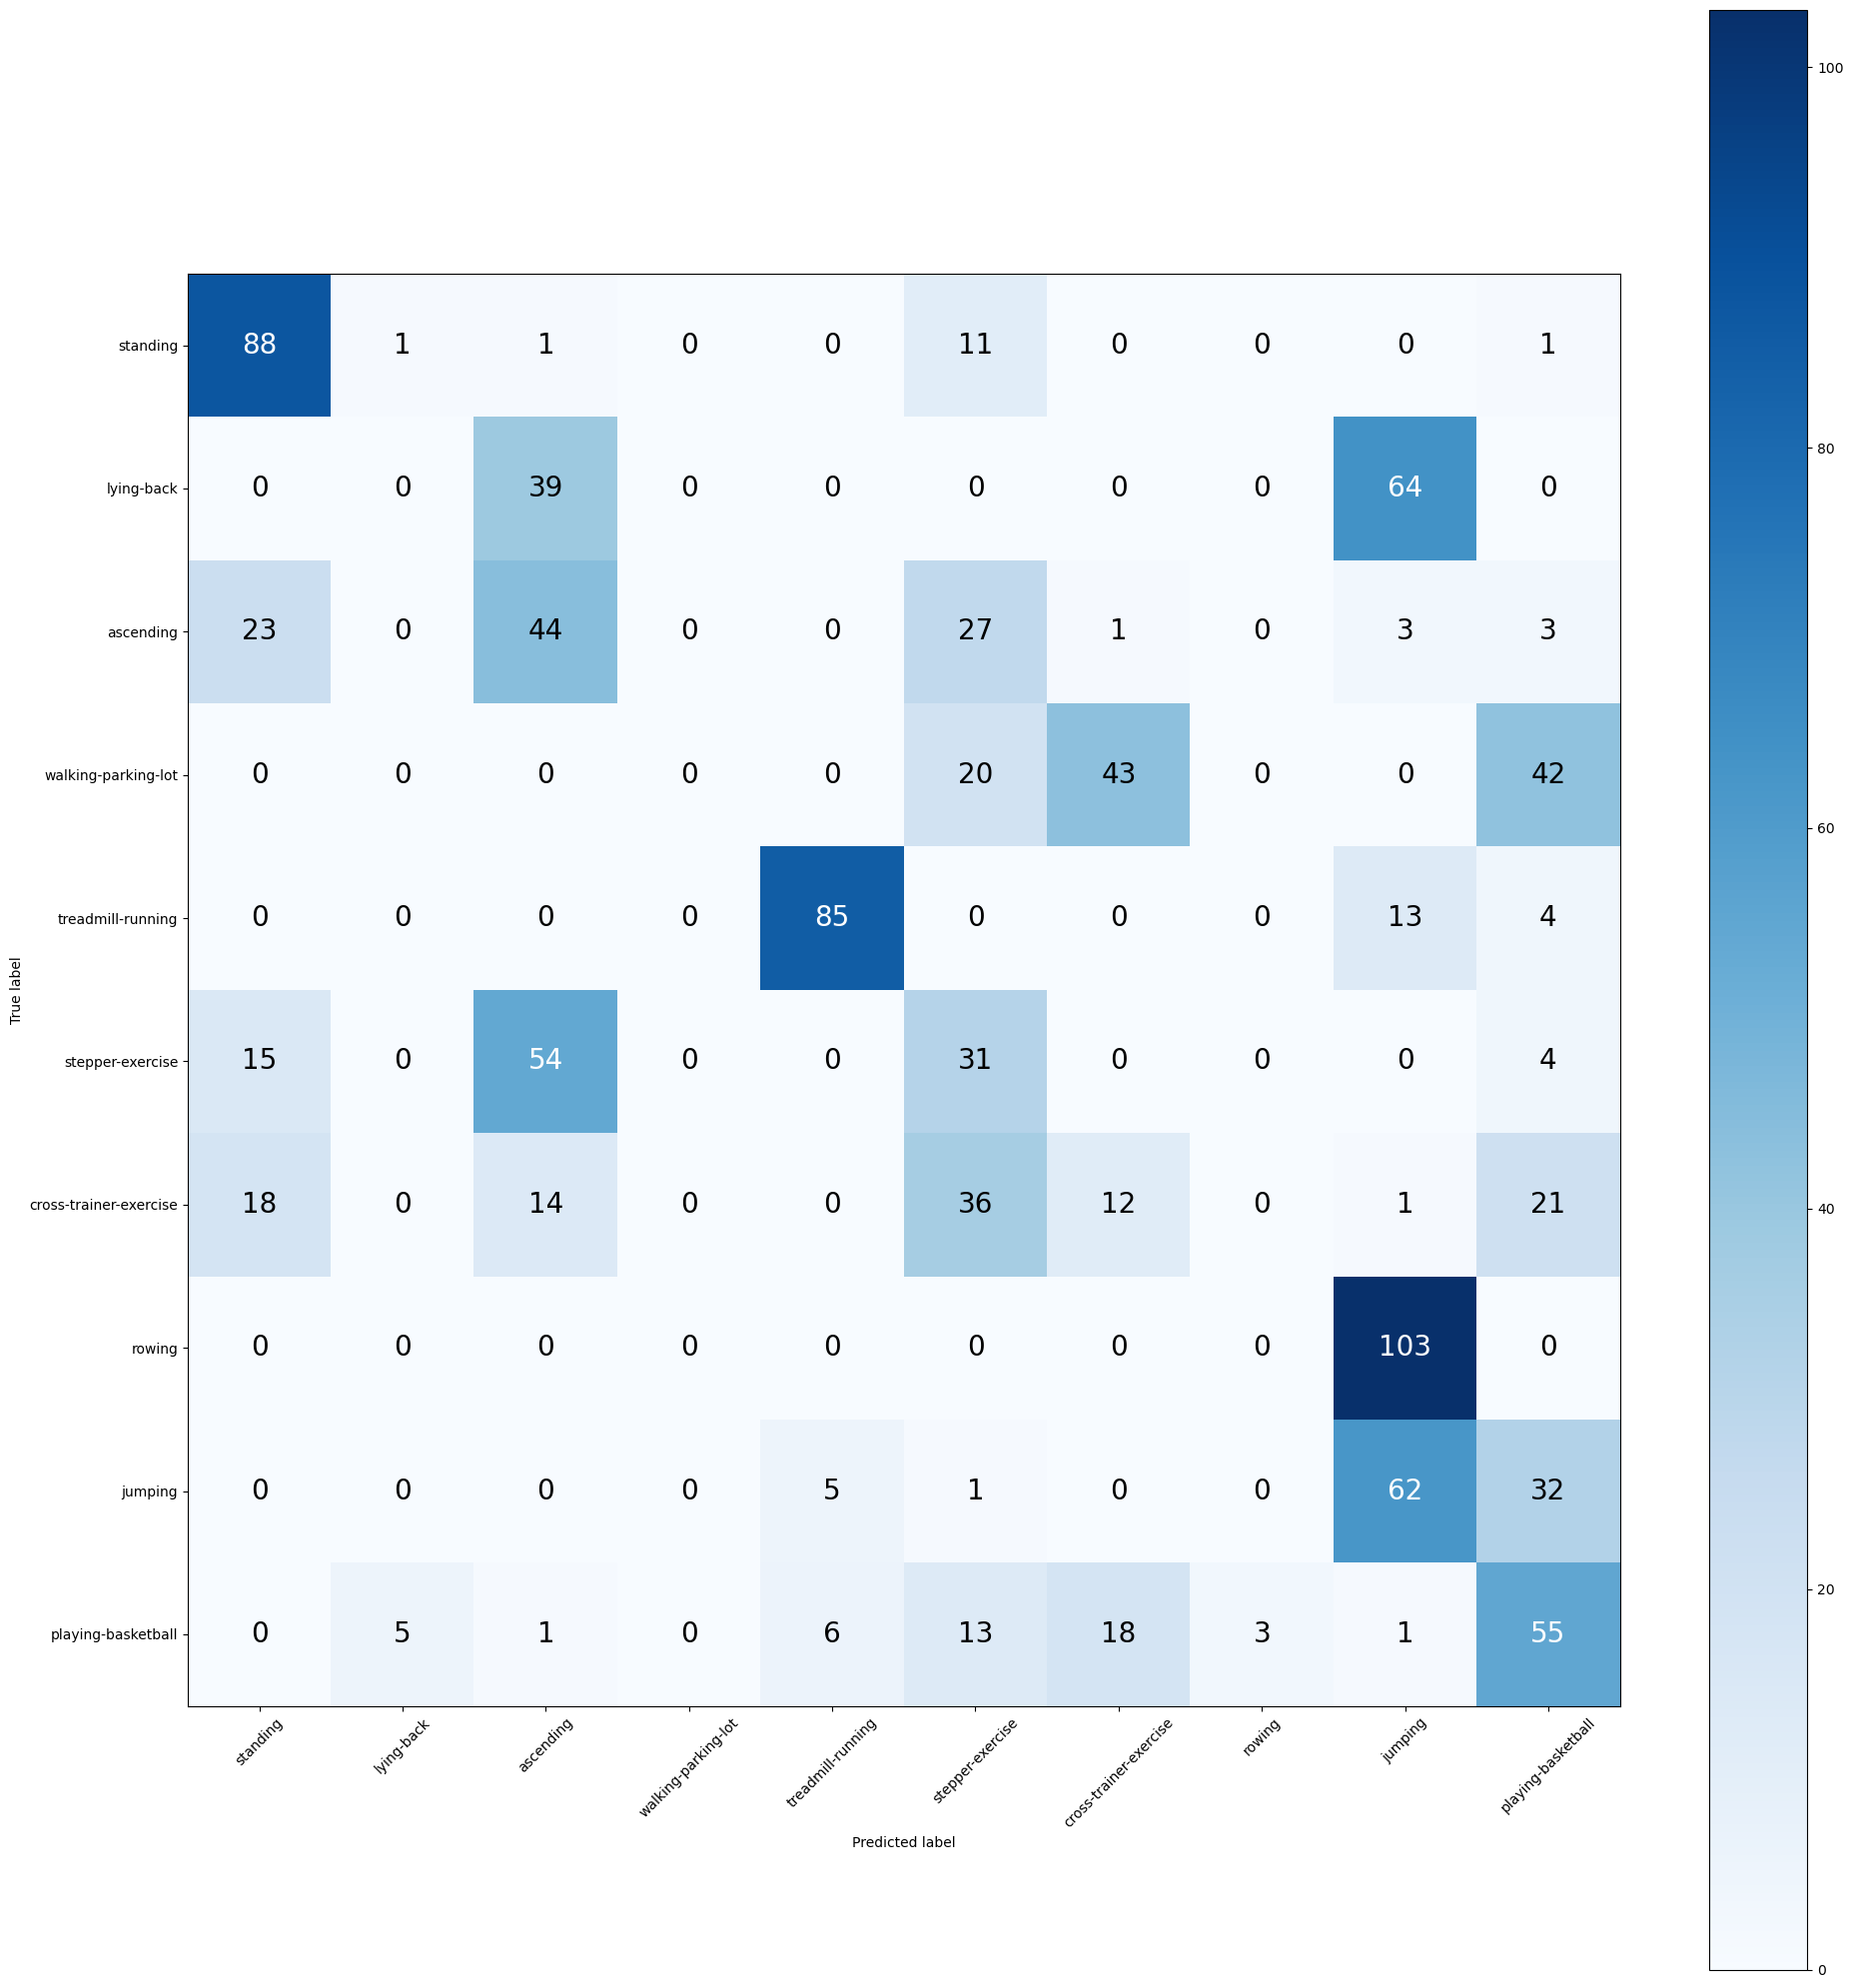

###Valid Source: Epoch: 6, avg_loss: 0.0508, Accuracy: 1965/4171 (47.11%)
###Valid Target: Epoch: 6, avg_loss: 0.0726, Accuracy: 377/1042 (36.18%)


Train Epoch:  7 [ 1/97]	Lambda: 0.3500, Class: 1.516809, CORAL: 0.195557, Total_Loss: 1.585254
Train Epoch:  7 [ 2/97]	Lambda: 0.3500, Class: 1.639844, CORAL: 0.132429, Total_Loss: 1.686194
Train Epoch:  7 [ 3/97]	Lambda: 0.3500, Class: 1.691757, CORAL: 0.233029, Total_Loss: 1.773317
Train Epoch:  7 [ 4/97]	Lambda: 0.3500, Class: 1.541096, CORAL: 0.151015, Total_Loss: 1.593951
Train Epoch:  7 [ 5/97]	Lambda: 0.3500, Class: 1.795839, CORAL: 0.072879, Total_Loss: 1.821346
Train Epoch:  7 [ 6/97]	Lambda: 0.3500, Class: 1.405433, CORAL: 0.243855, Total_Loss: 1.490782
Train Epoch:  7 [ 7/97]	Lambda: 0.3500, Class: 1.734619, CORAL: 0.260652, Total_Loss: 1.825847
Train Epoch:  7 [ 8/97]	Lambda: 0.3500, Class: 1.707952, CORAL: 0.062307, Total_Loss: 1.729759
Train Epoch:  7 [ 9/97]	Lambda: 0.3500, Class: 1.459971, CORAL: 0.206316, Total_Loss: 1.532

Train Epoch:  7 [89/97]	Lambda: 0.3500, Class: 1.508337, CORAL: 0.243791, Total_Loss: 1.593664
Train Epoch:  7 [90/97]	Lambda: 0.3500, Class: 1.423509, CORAL: 0.311834, Total_Loss: 1.532651
Train Epoch:  7 [91/97]	Lambda: 0.3500, Class: 1.492092, CORAL: 0.206409, Total_Loss: 1.564335
Train Epoch:  7 [92/97]	Lambda: 0.3500, Class: 1.464119, CORAL: 0.284085, Total_Loss: 1.563549
Train Epoch:  7 [93/97]	Lambda: 0.3500, Class: 1.703995, CORAL: 0.185596, Total_Loss: 1.768953
Train Epoch:  7 [94/97]	Lambda: 0.3500, Class: 1.651620, CORAL: 0.094891, Total_Loss: 1.684832
Train Epoch:  7 [95/97]	Lambda: 0.3500, Class: 1.420778, CORAL: 0.301437, Total_Loss: 1.526281
Train Epoch:  7 [96/97]	Lambda: 0.3500, Class: 1.409223, CORAL: 0.234753, Total_Loss: 1.491387
Train Epoch:  7 [97/97]	Lambda: 0.3500, Class: 1.547081, CORAL: 0.264213, Total_Loss: 1.639556
###EPOCH 7: Class: 1.581296, CORAL: 0.206048, Total_Loss: 1.653412


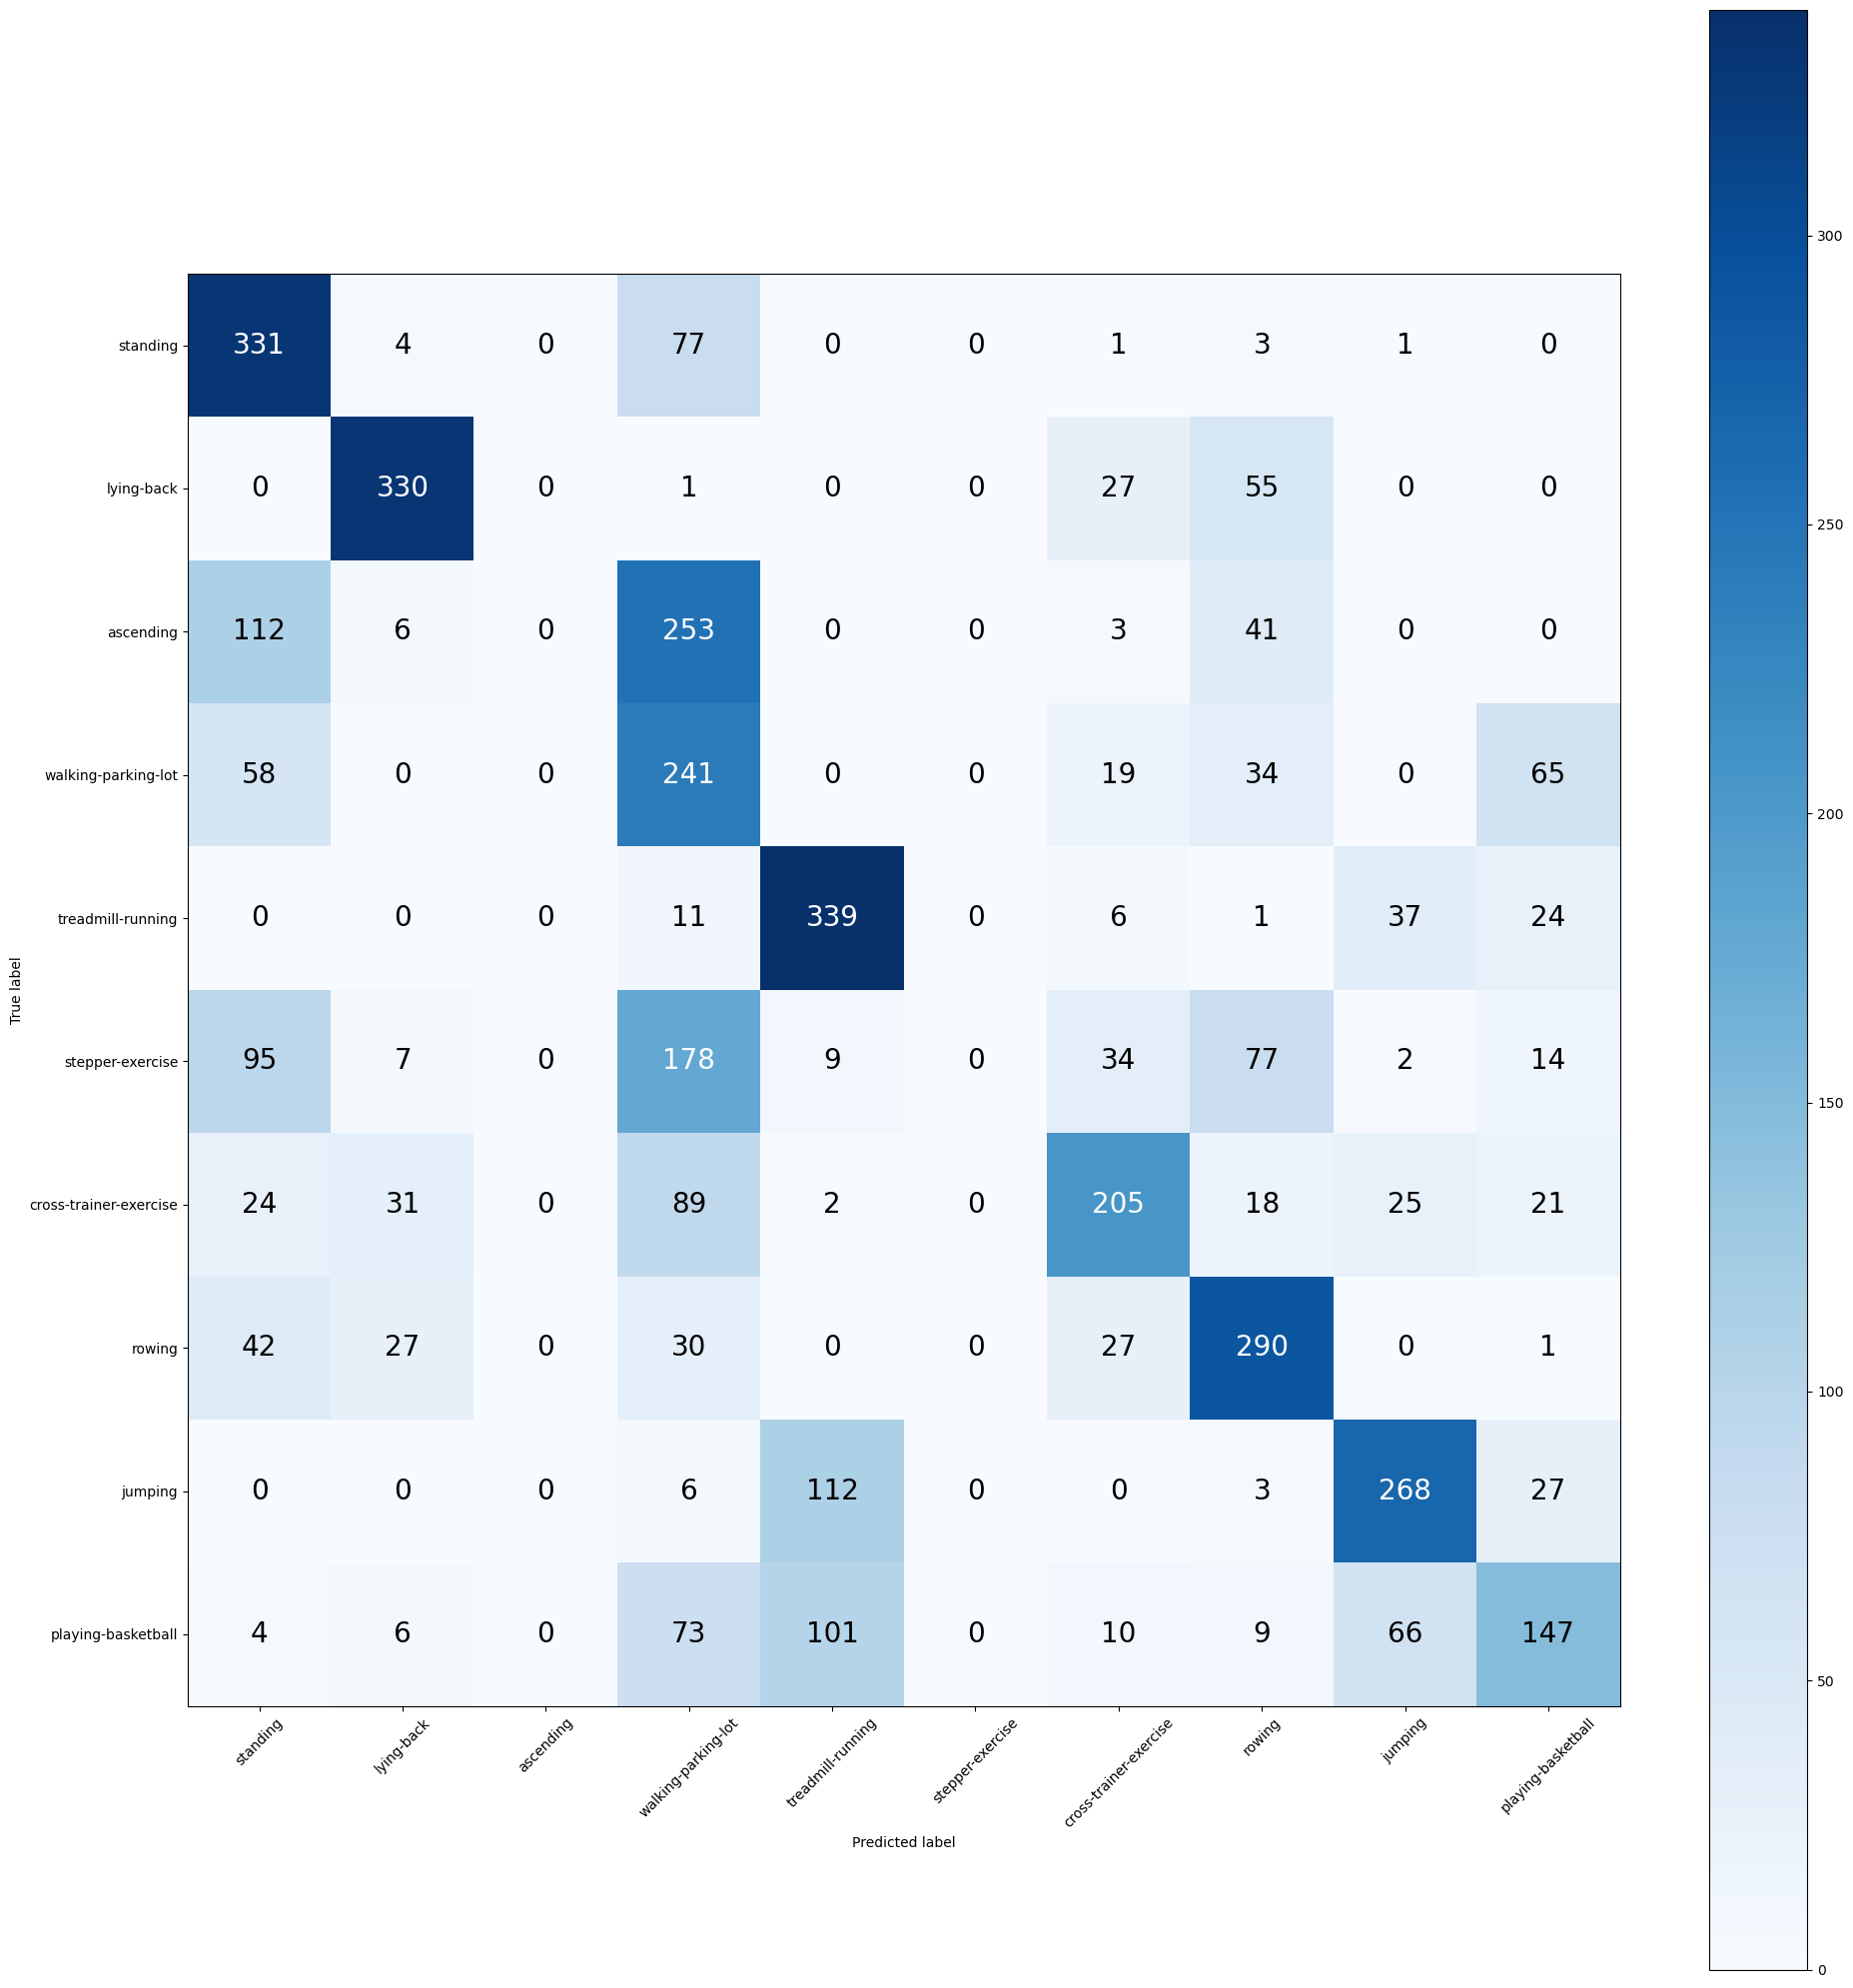

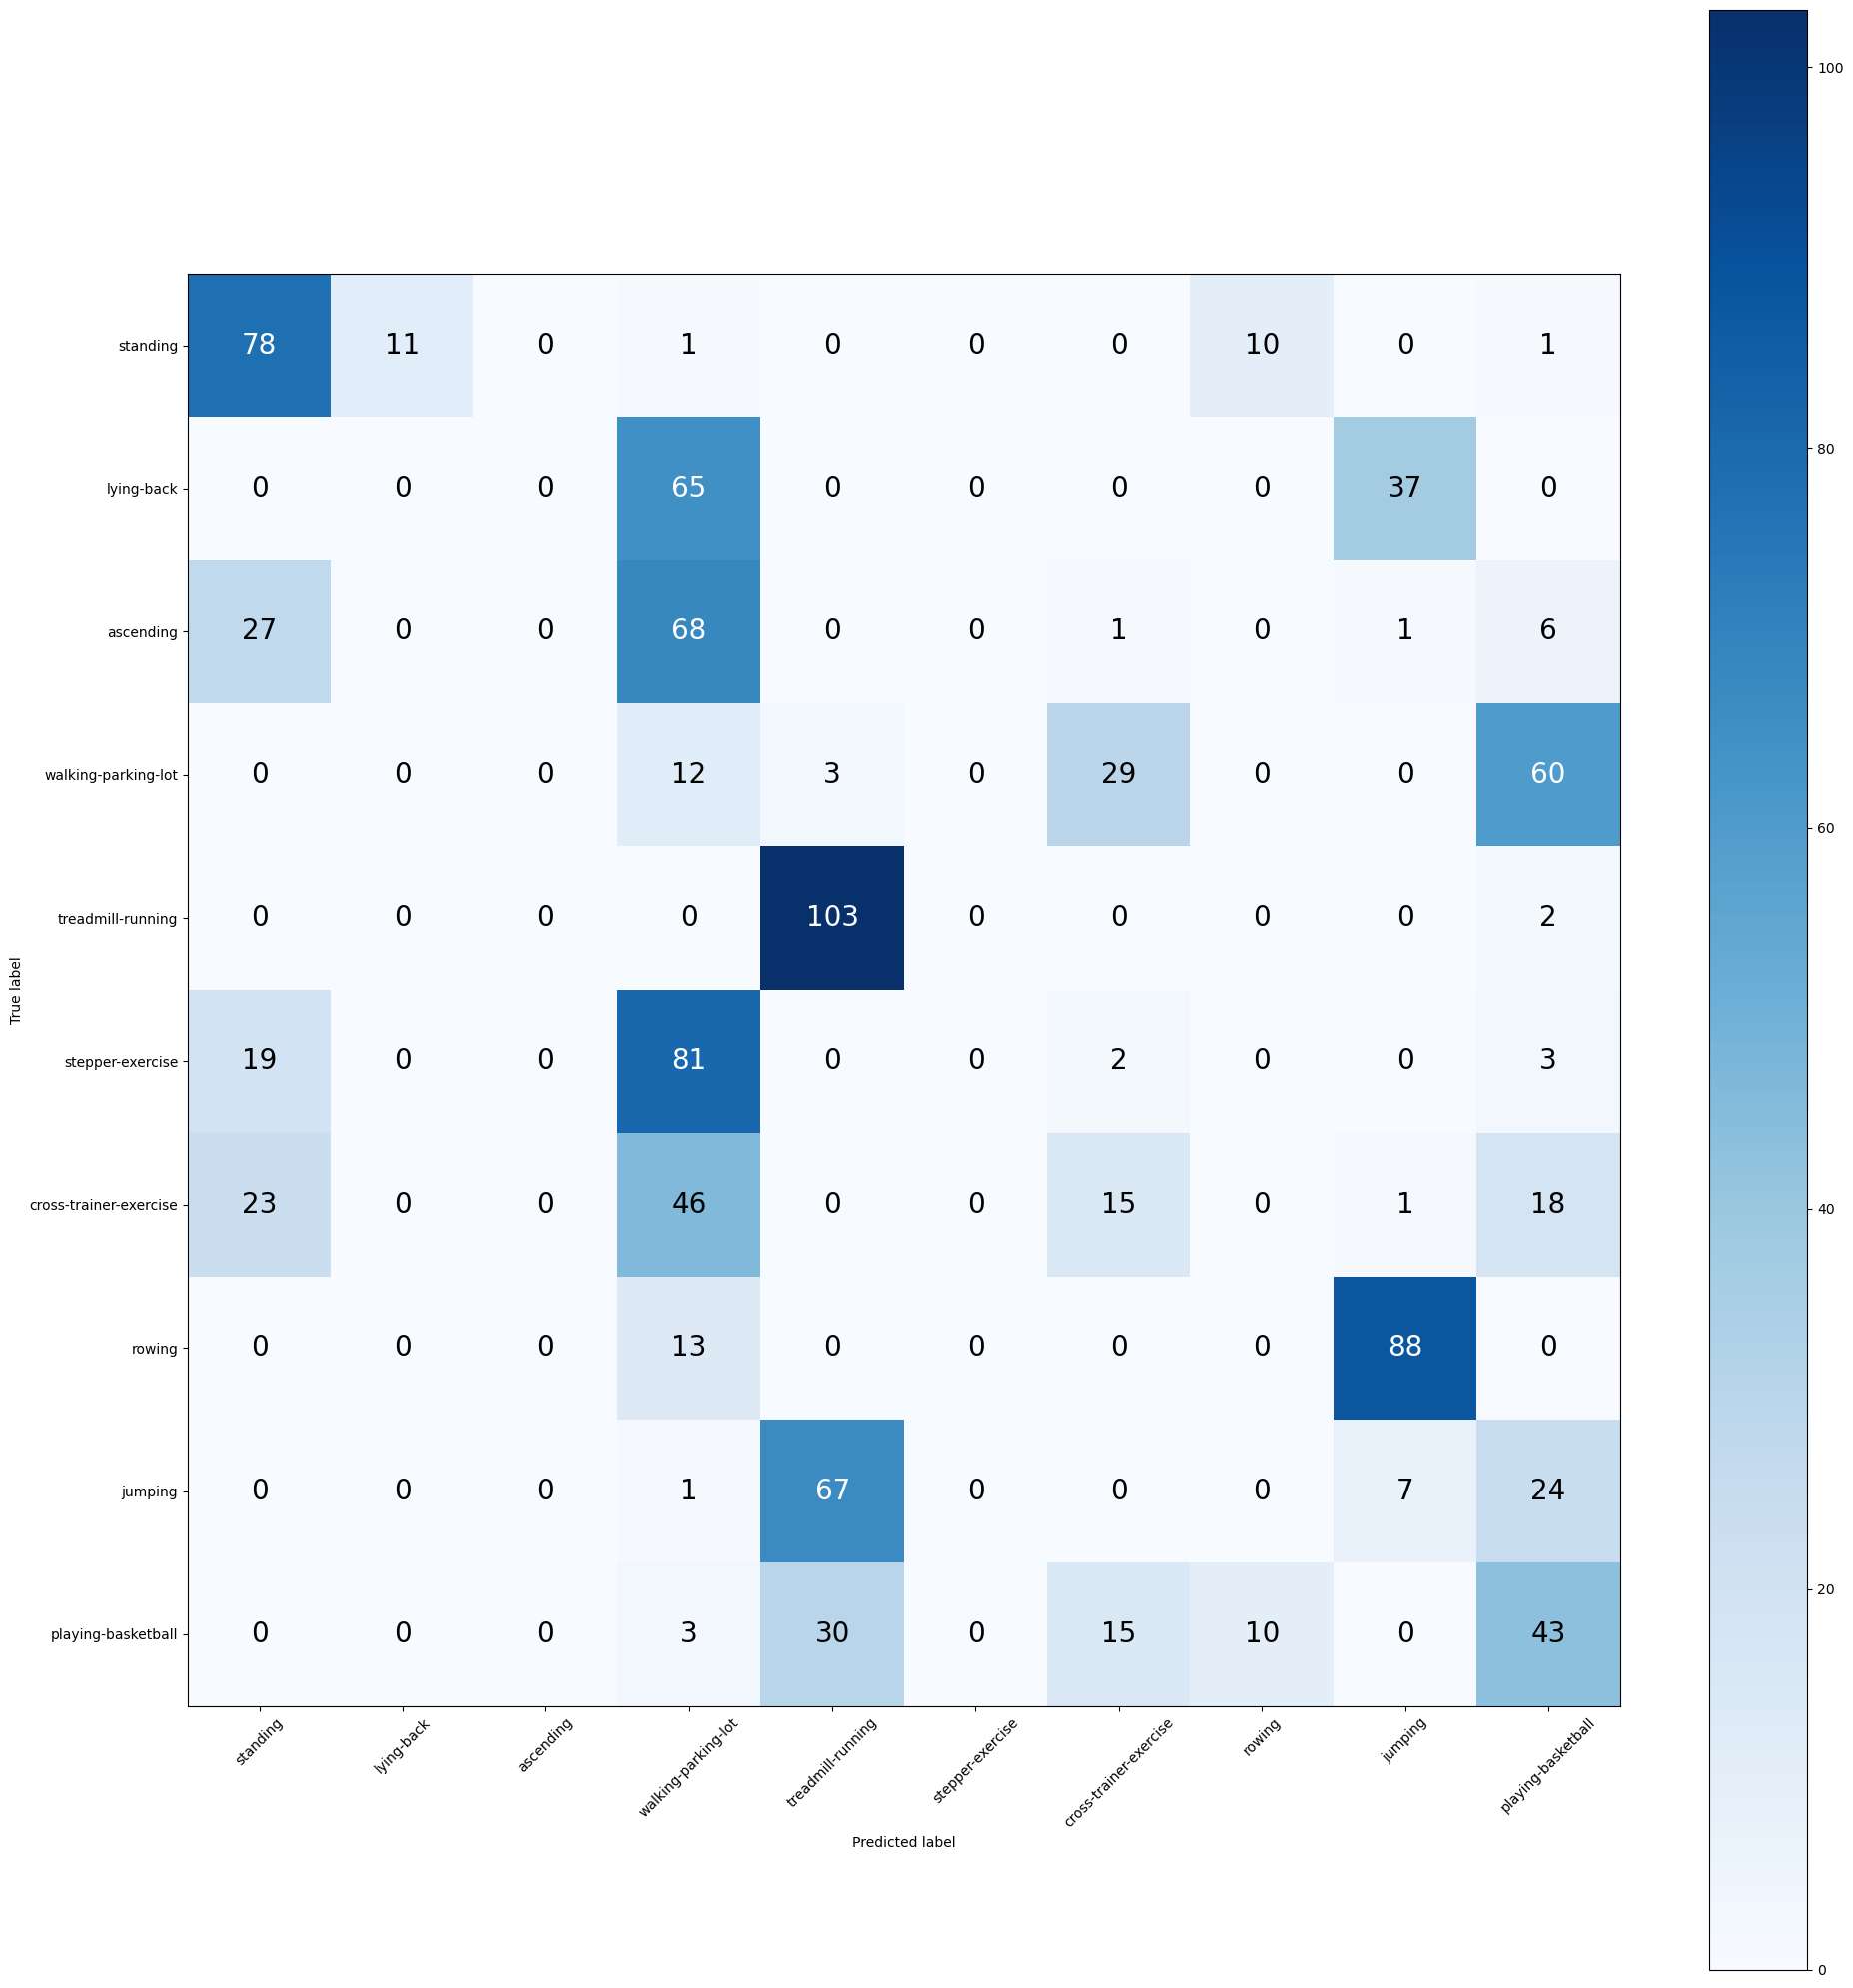

###Valid Source: Epoch: 7, avg_loss: 0.0482, Accuracy: 2151/4171 (51.57%)
###Valid Target: Epoch: 7, avg_loss: 0.0751, Accuracy: 258/1042 (24.76%)


Train Epoch:  8 [ 1/97]	Lambda: 0.4000, Class: 1.423936, CORAL: 0.092274, Total_Loss: 1.460845
Train Epoch:  8 [ 2/97]	Lambda: 0.4000, Class: 1.420039, CORAL: 0.147328, Total_Loss: 1.478970
Train Epoch:  8 [ 3/97]	Lambda: 0.4000, Class: 1.699104, CORAL: 0.210197, Total_Loss: 1.783183
Train Epoch:  8 [ 4/97]	Lambda: 0.4000, Class: 1.533332, CORAL: 0.010229, Total_Loss: 1.537423
Train Epoch:  8 [ 5/97]	Lambda: 0.4000, Class: 1.442677, CORAL: 0.115057, Total_Loss: 1.488700
Train Epoch:  8 [ 6/97]	Lambda: 0.4000, Class: 1.711837, CORAL: 0.421571, Total_Loss: 1.880465
Train Epoch:  8 [ 7/97]	Lambda: 0.4000, Class: 1.597510, CORAL: 0.399578, Total_Loss: 1.757341
Train Epoch:  8 [ 8/97]	Lambda: 0.4000, Class: 1.544889, CORAL: 0.064256, Total_Loss: 1.570591
Train Epoch:  8 [ 9/97]	Lambda: 0.4000, Class: 1.426619, CORAL: 0.164219, Total_Loss: 1.492

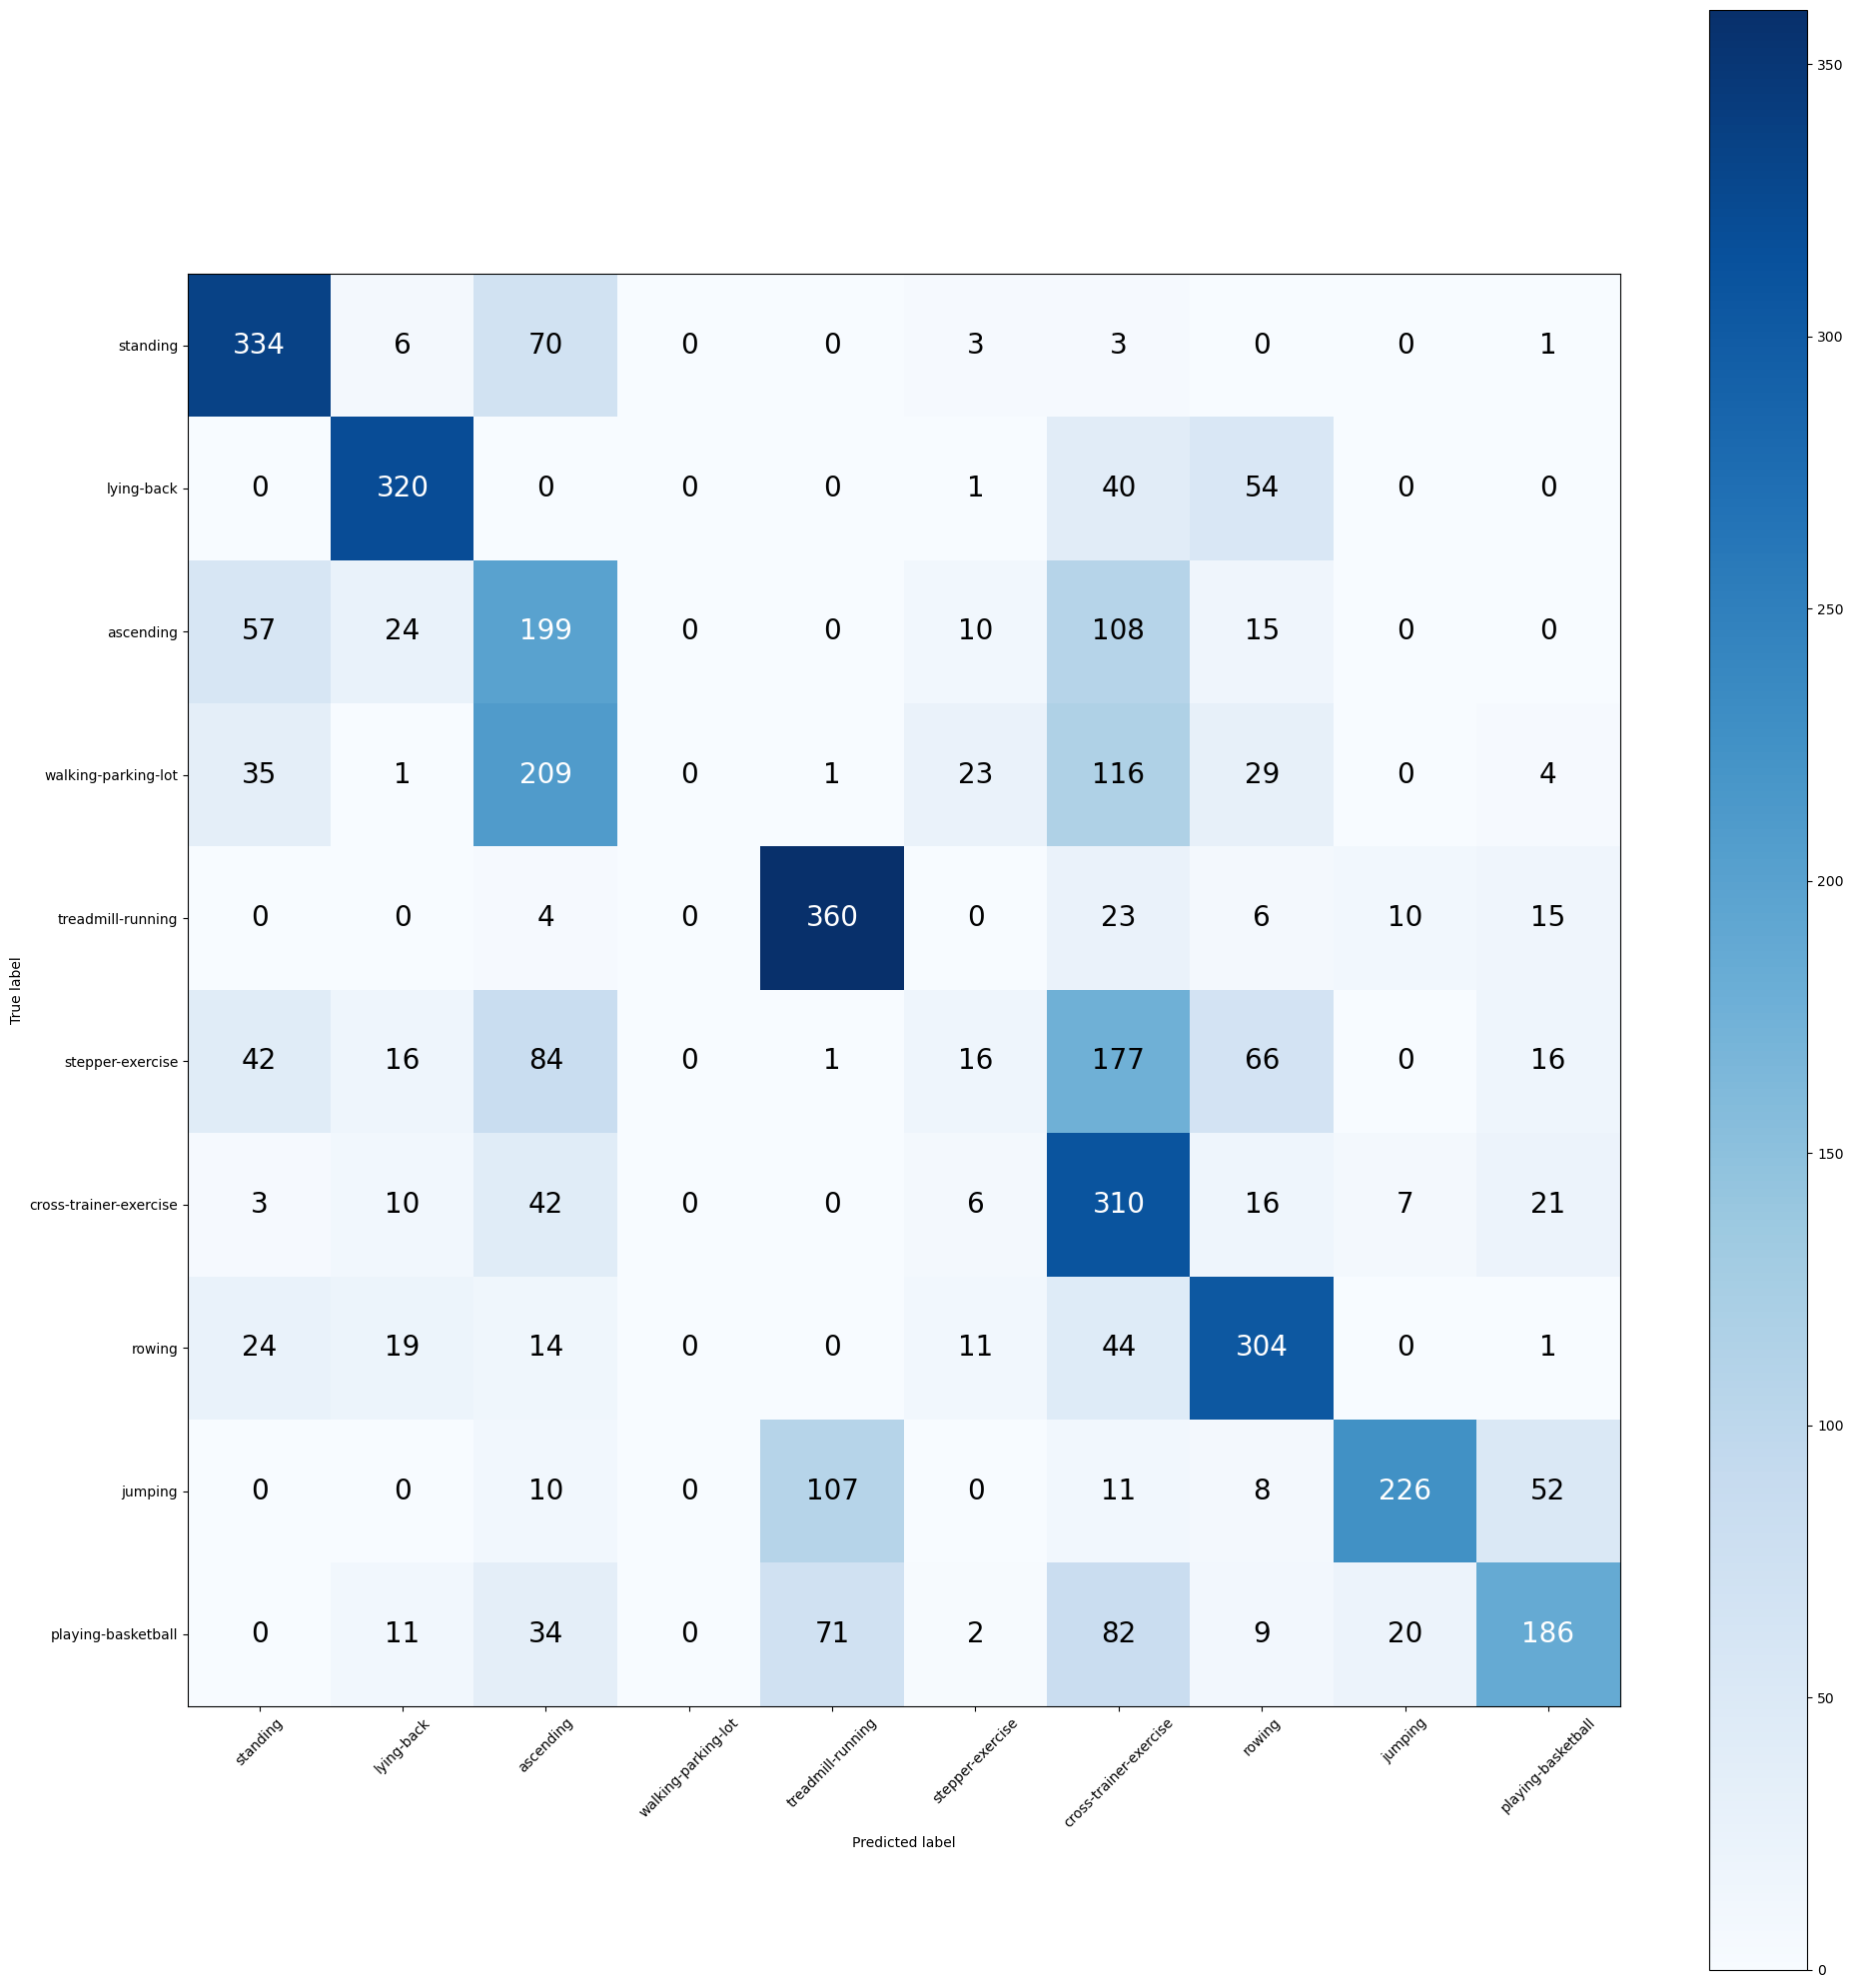

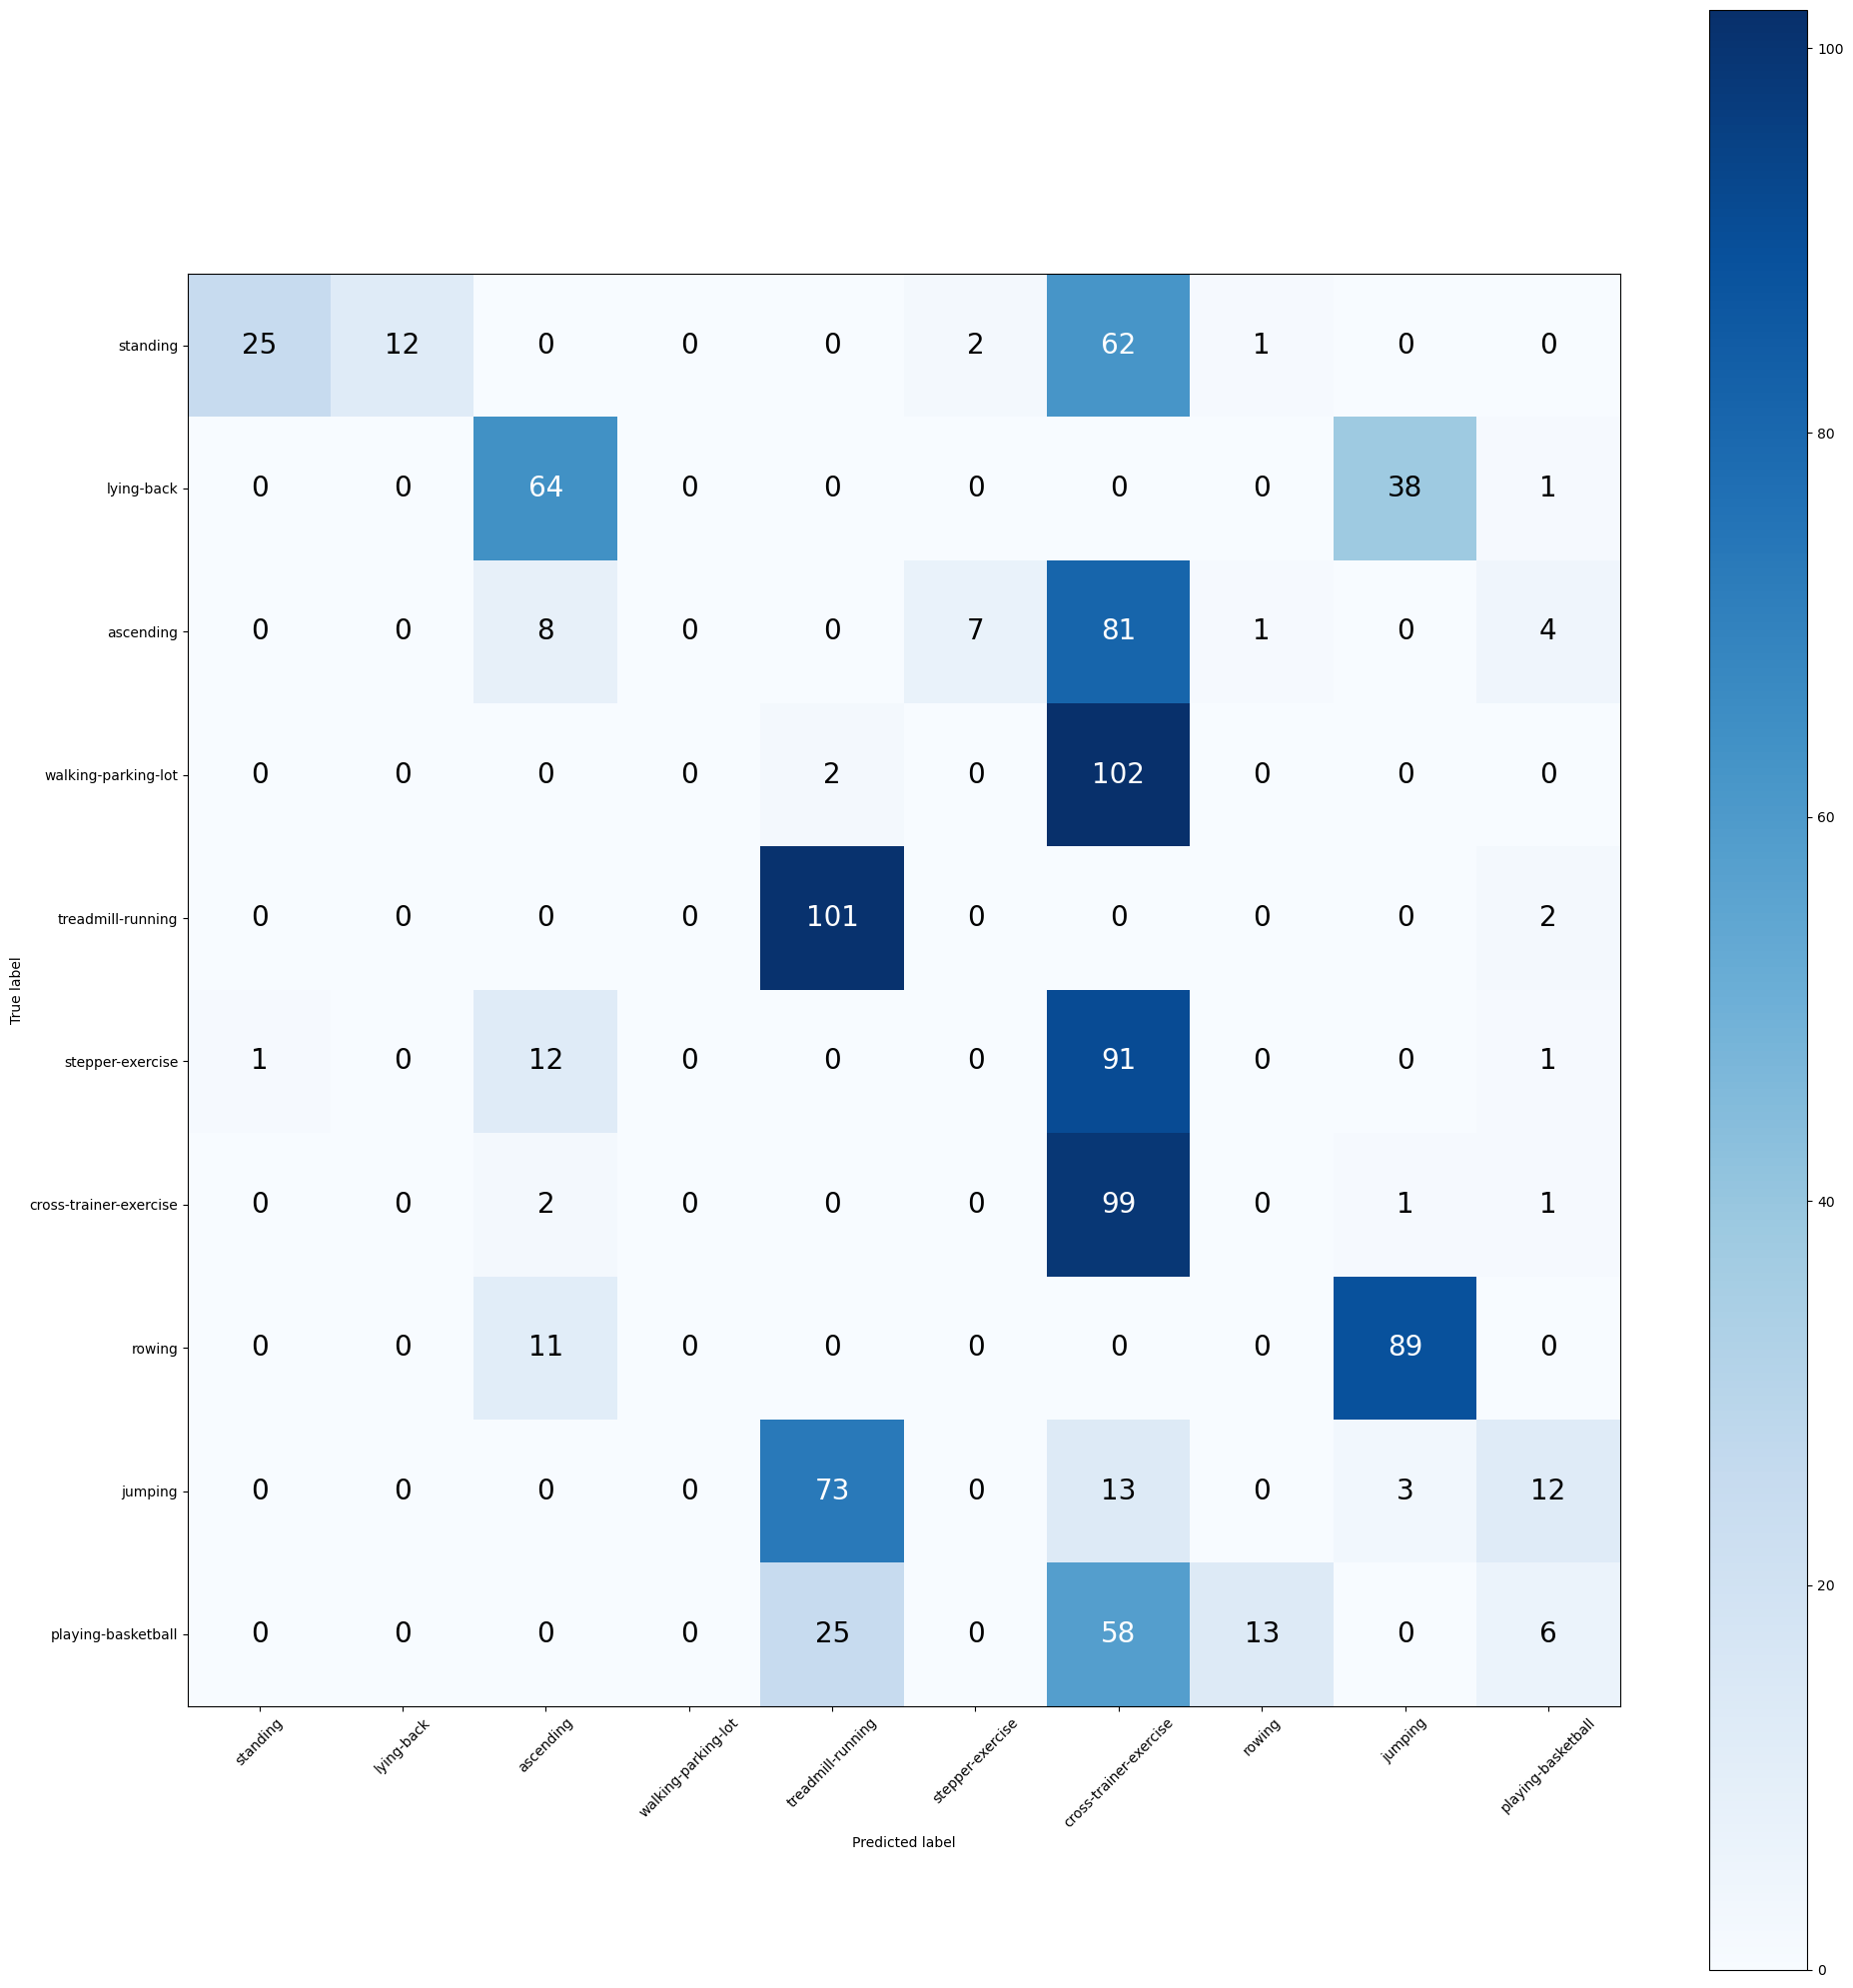

###Valid Source: Epoch: 8, avg_loss: 0.0471, Accuracy: 2255/4171 (54.06%)
###Valid Target: Epoch: 8, avg_loss: 0.0752, Accuracy: 242/1042 (23.22%)


Train Epoch:  9 [ 1/97]	Lambda: 0.4500, Class: 1.514606, CORAL: 0.185381, Total_Loss: 1.598027
Train Epoch:  9 [ 2/97]	Lambda: 0.4500, Class: 1.694566, CORAL: 0.394094, Total_Loss: 1.871908
Train Epoch:  9 [ 3/97]	Lambda: 0.4500, Class: 1.572947, CORAL: 0.263676, Total_Loss: 1.691601
Train Epoch:  9 [ 4/97]	Lambda: 0.4500, Class: 1.535395, CORAL: 0.083761, Total_Loss: 1.573088
Train Epoch:  9 [ 5/97]	Lambda: 0.4500, Class: 1.606133, CORAL: 0.205622, Total_Loss: 1.698663
Train Epoch:  9 [ 6/97]	Lambda: 0.4500, Class: 1.443053, CORAL: 0.055078, Total_Loss: 1.467839
Train Epoch:  9 [ 7/97]	Lambda: 0.4500, Class: 1.371392, CORAL: 0.206941, Total_Loss: 1.464516
Train Epoch:  9 [ 8/97]	Lambda: 0.4500, Class: 1.291034, CORAL: 0.360785, Total_Loss: 1.453387
Train Epoch:  9 [ 9/97]	Lambda: 0.4500, Class: 1.372510, CORAL: 0.156170, Total_Loss: 1.442

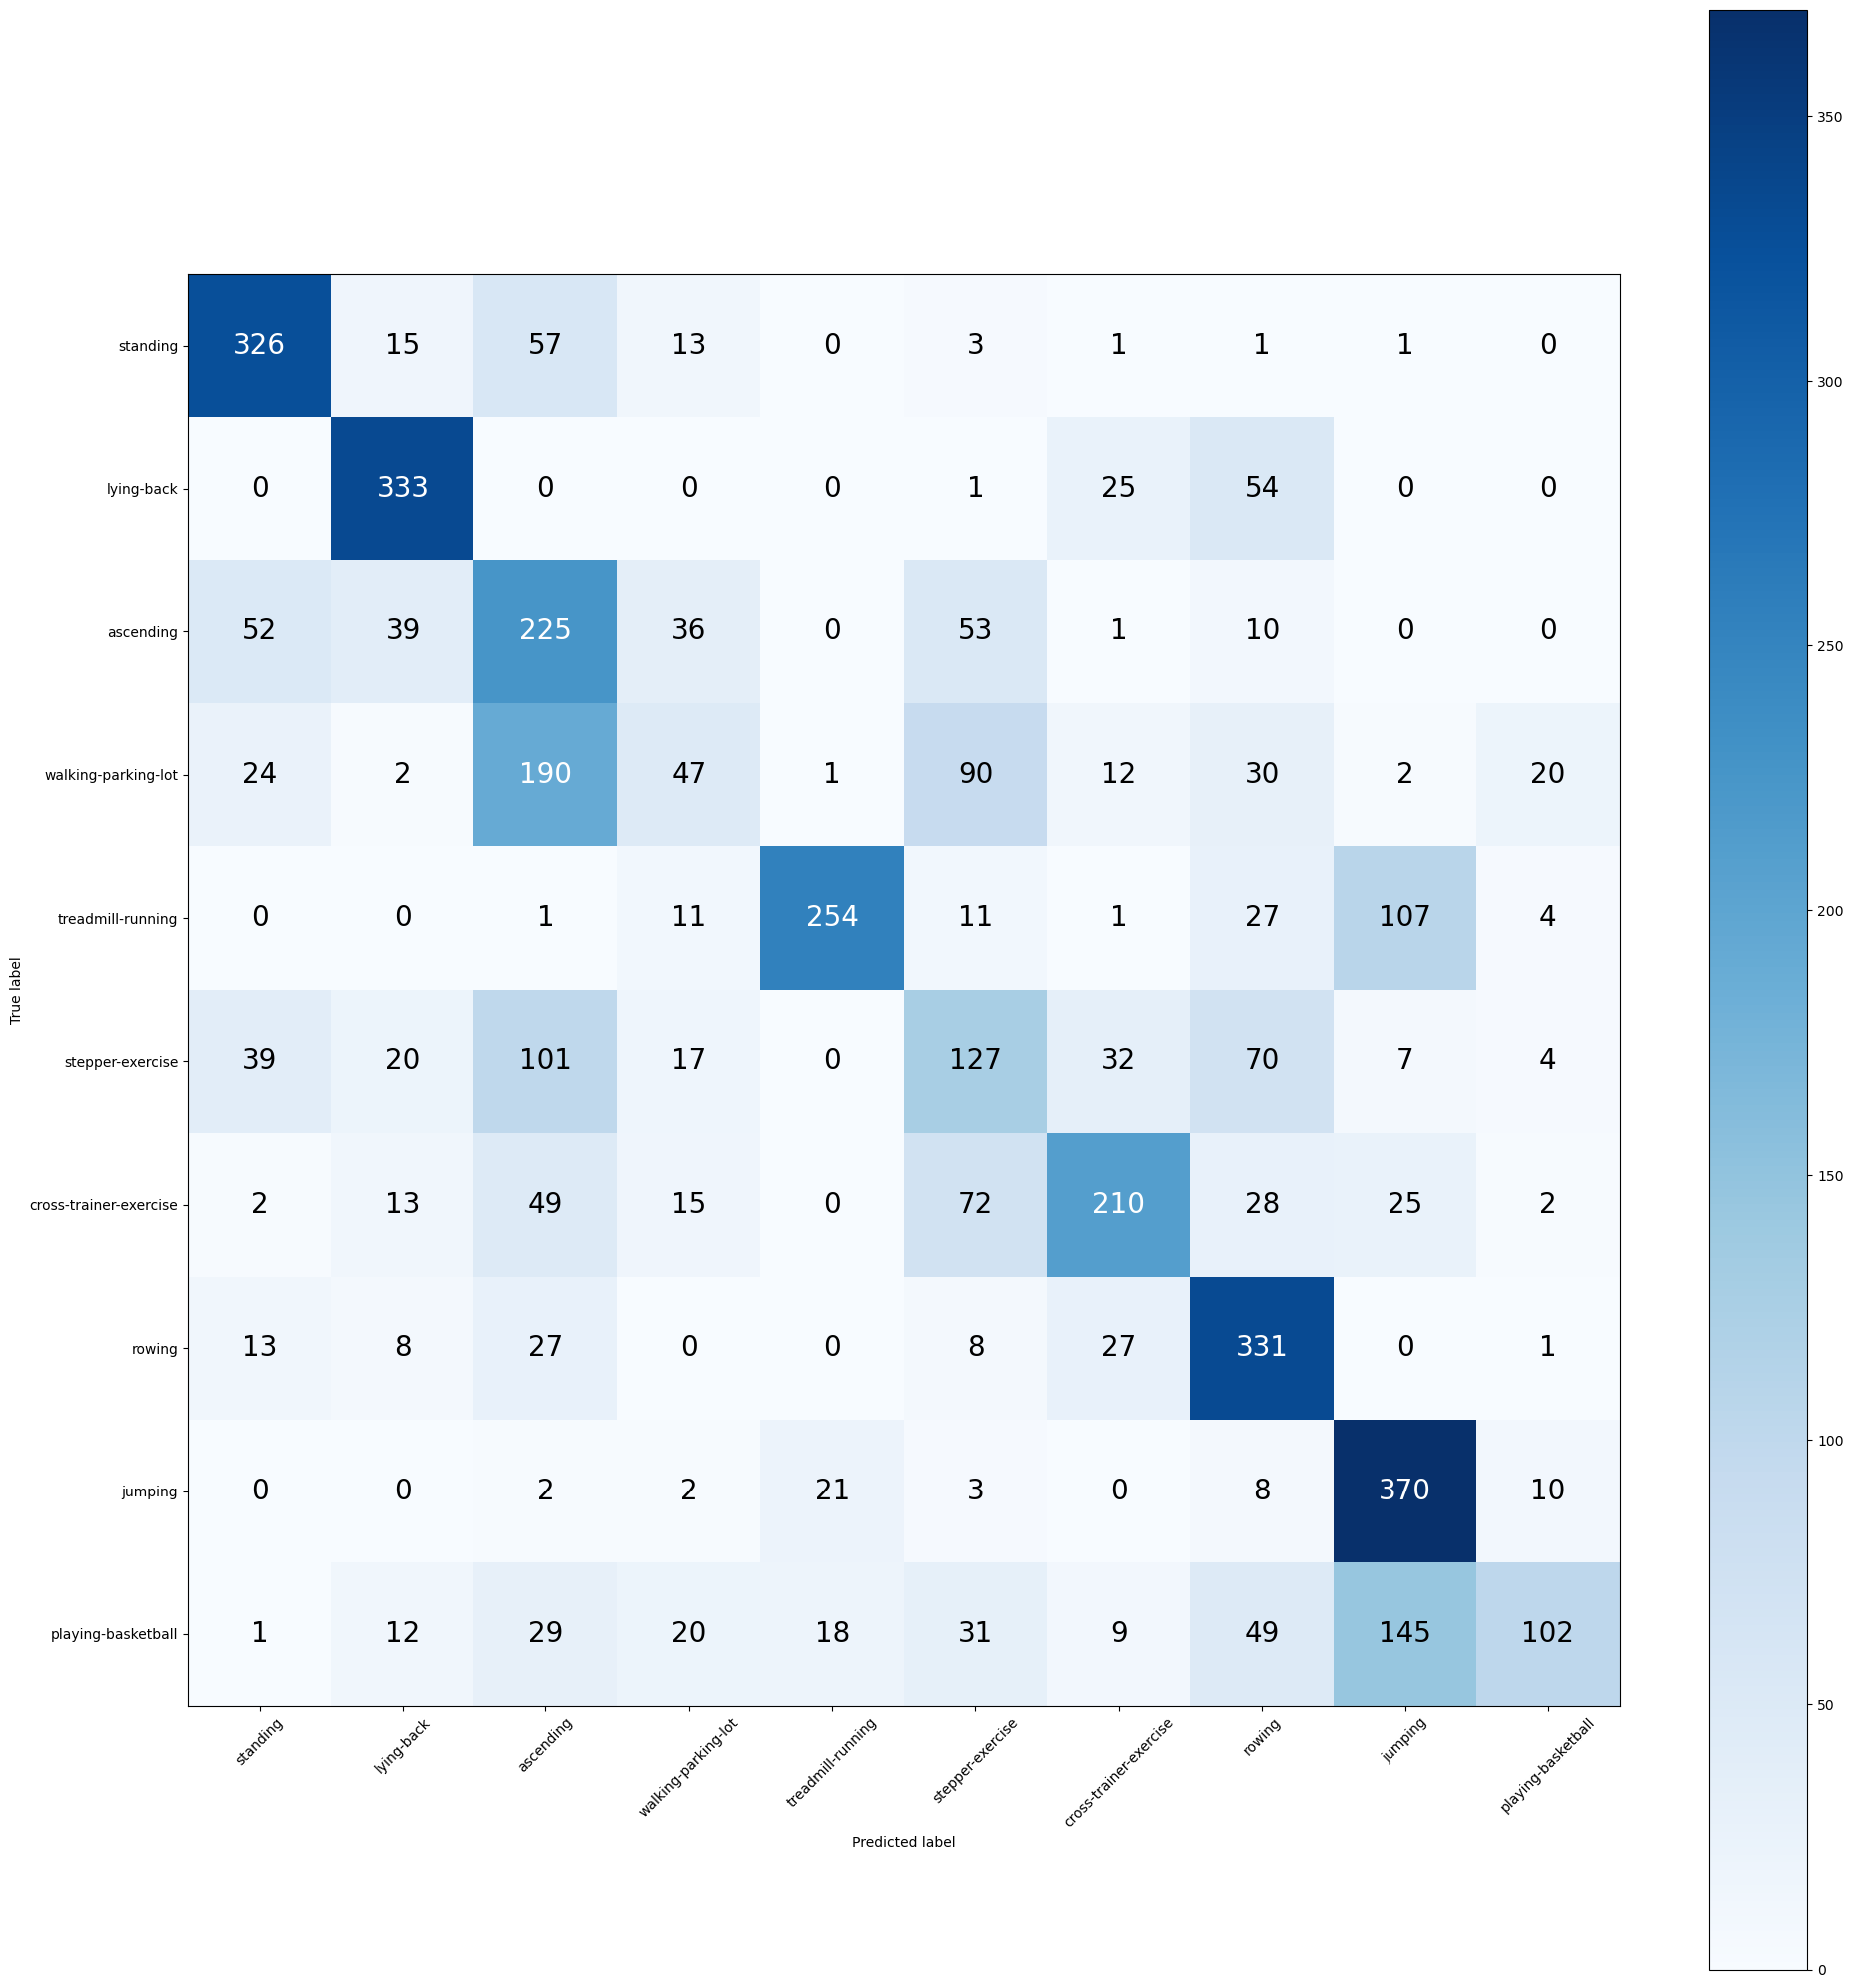

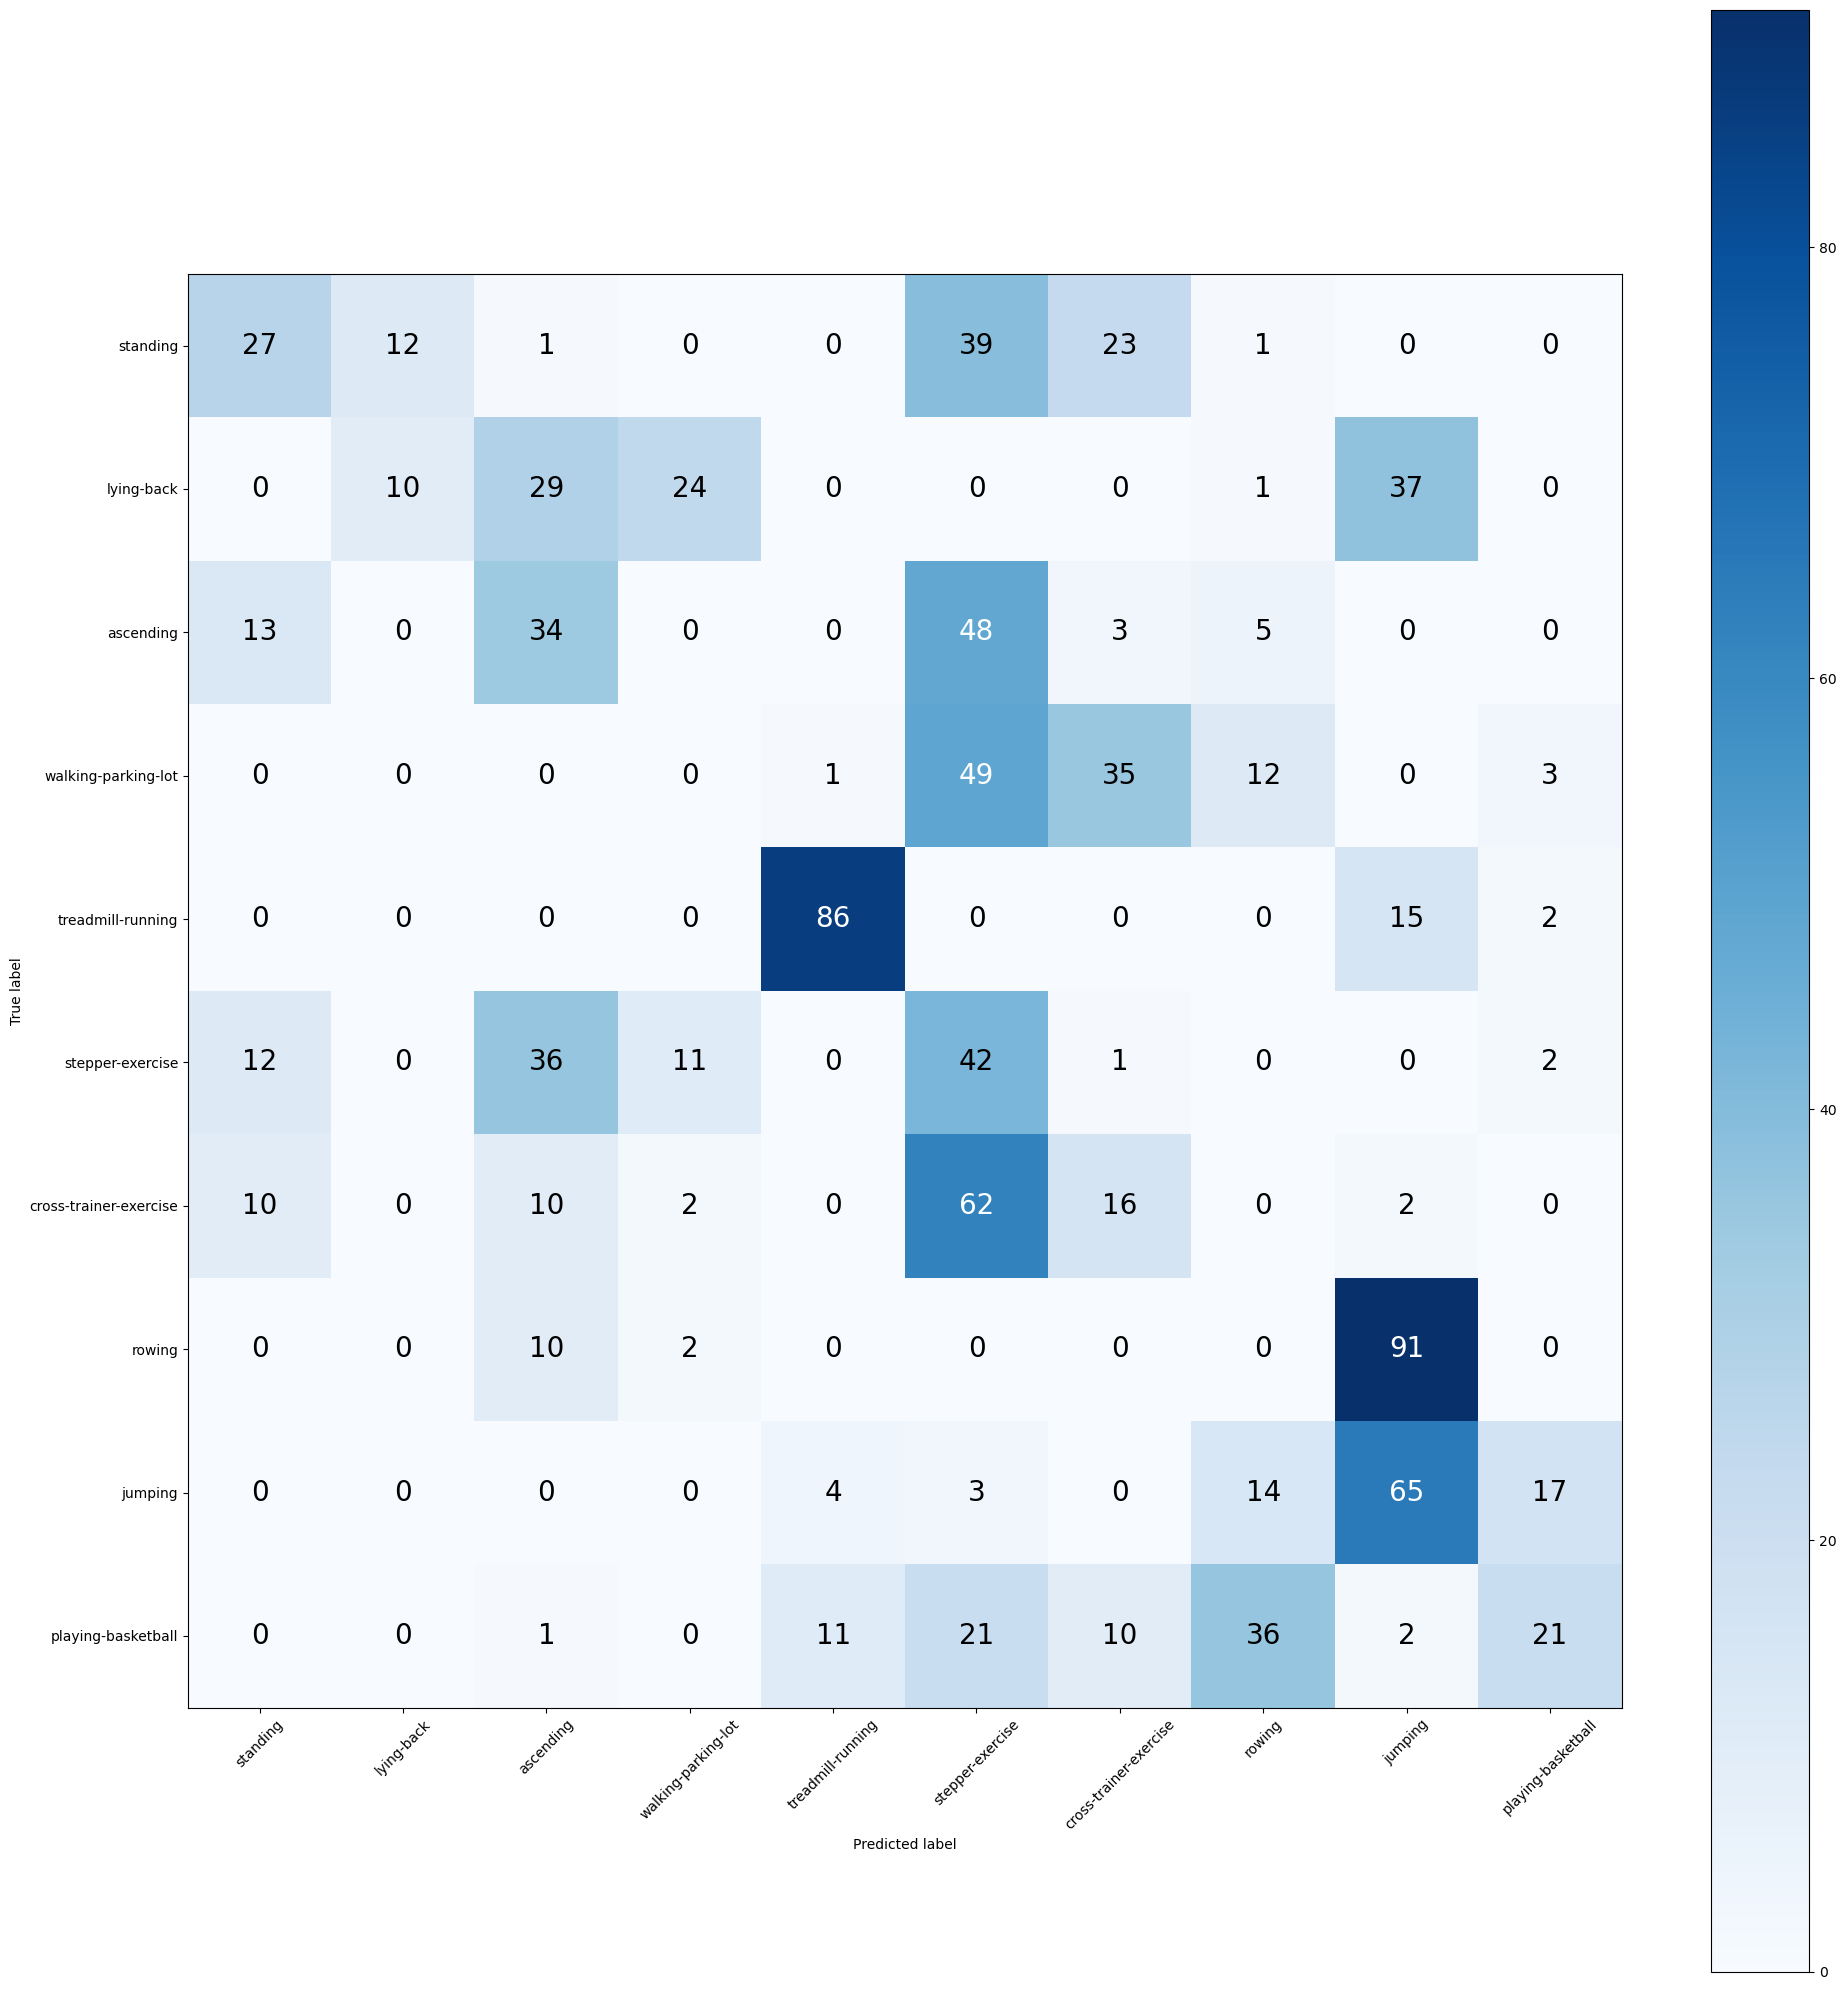

###Valid Source: Epoch: 9, avg_loss: 0.0456, Accuracy: 2325/4171 (55.74%)
###Valid Target: Epoch: 9, avg_loss: 0.0722, Accuracy: 301/1042 (28.89%)


Train Epoch: 10 [ 1/97]	Lambda: 0.5000, Class: 1.366470, CORAL: 0.033745, Total_Loss: 1.383343
Train Epoch: 10 [ 2/97]	Lambda: 0.5000, Class: 1.602665, CORAL: 0.062851, Total_Loss: 1.634091
Train Epoch: 10 [ 3/97]	Lambda: 0.5000, Class: 1.212806, CORAL: 0.305914, Total_Loss: 1.365763
Train Epoch: 10 [ 4/97]	Lambda: 0.5000, Class: 1.513500, CORAL: 0.101459, Total_Loss: 1.564230
Train Epoch: 10 [ 5/97]	Lambda: 0.5000, Class: 1.448376, CORAL: 0.250010, Total_Loss: 1.573381
Train Epoch: 10 [ 6/97]	Lambda: 0.5000, Class: 1.473683, CORAL: 0.035567, Total_Loss: 1.491467
Train Epoch: 10 [ 7/97]	Lambda: 0.5000, Class: 1.554704, CORAL: 0.114196, Total_Loss: 1.611802
Train Epoch: 10 [ 8/97]	Lambda: 0.5000, Class: 1.352901, CORAL: 0.028859, Total_Loss: 1.367330
Train Epoch: 10 [ 9/97]	Lambda: 0.5000, Class: 1.242693, CORAL: 0.120213, Total_Loss: 1.302

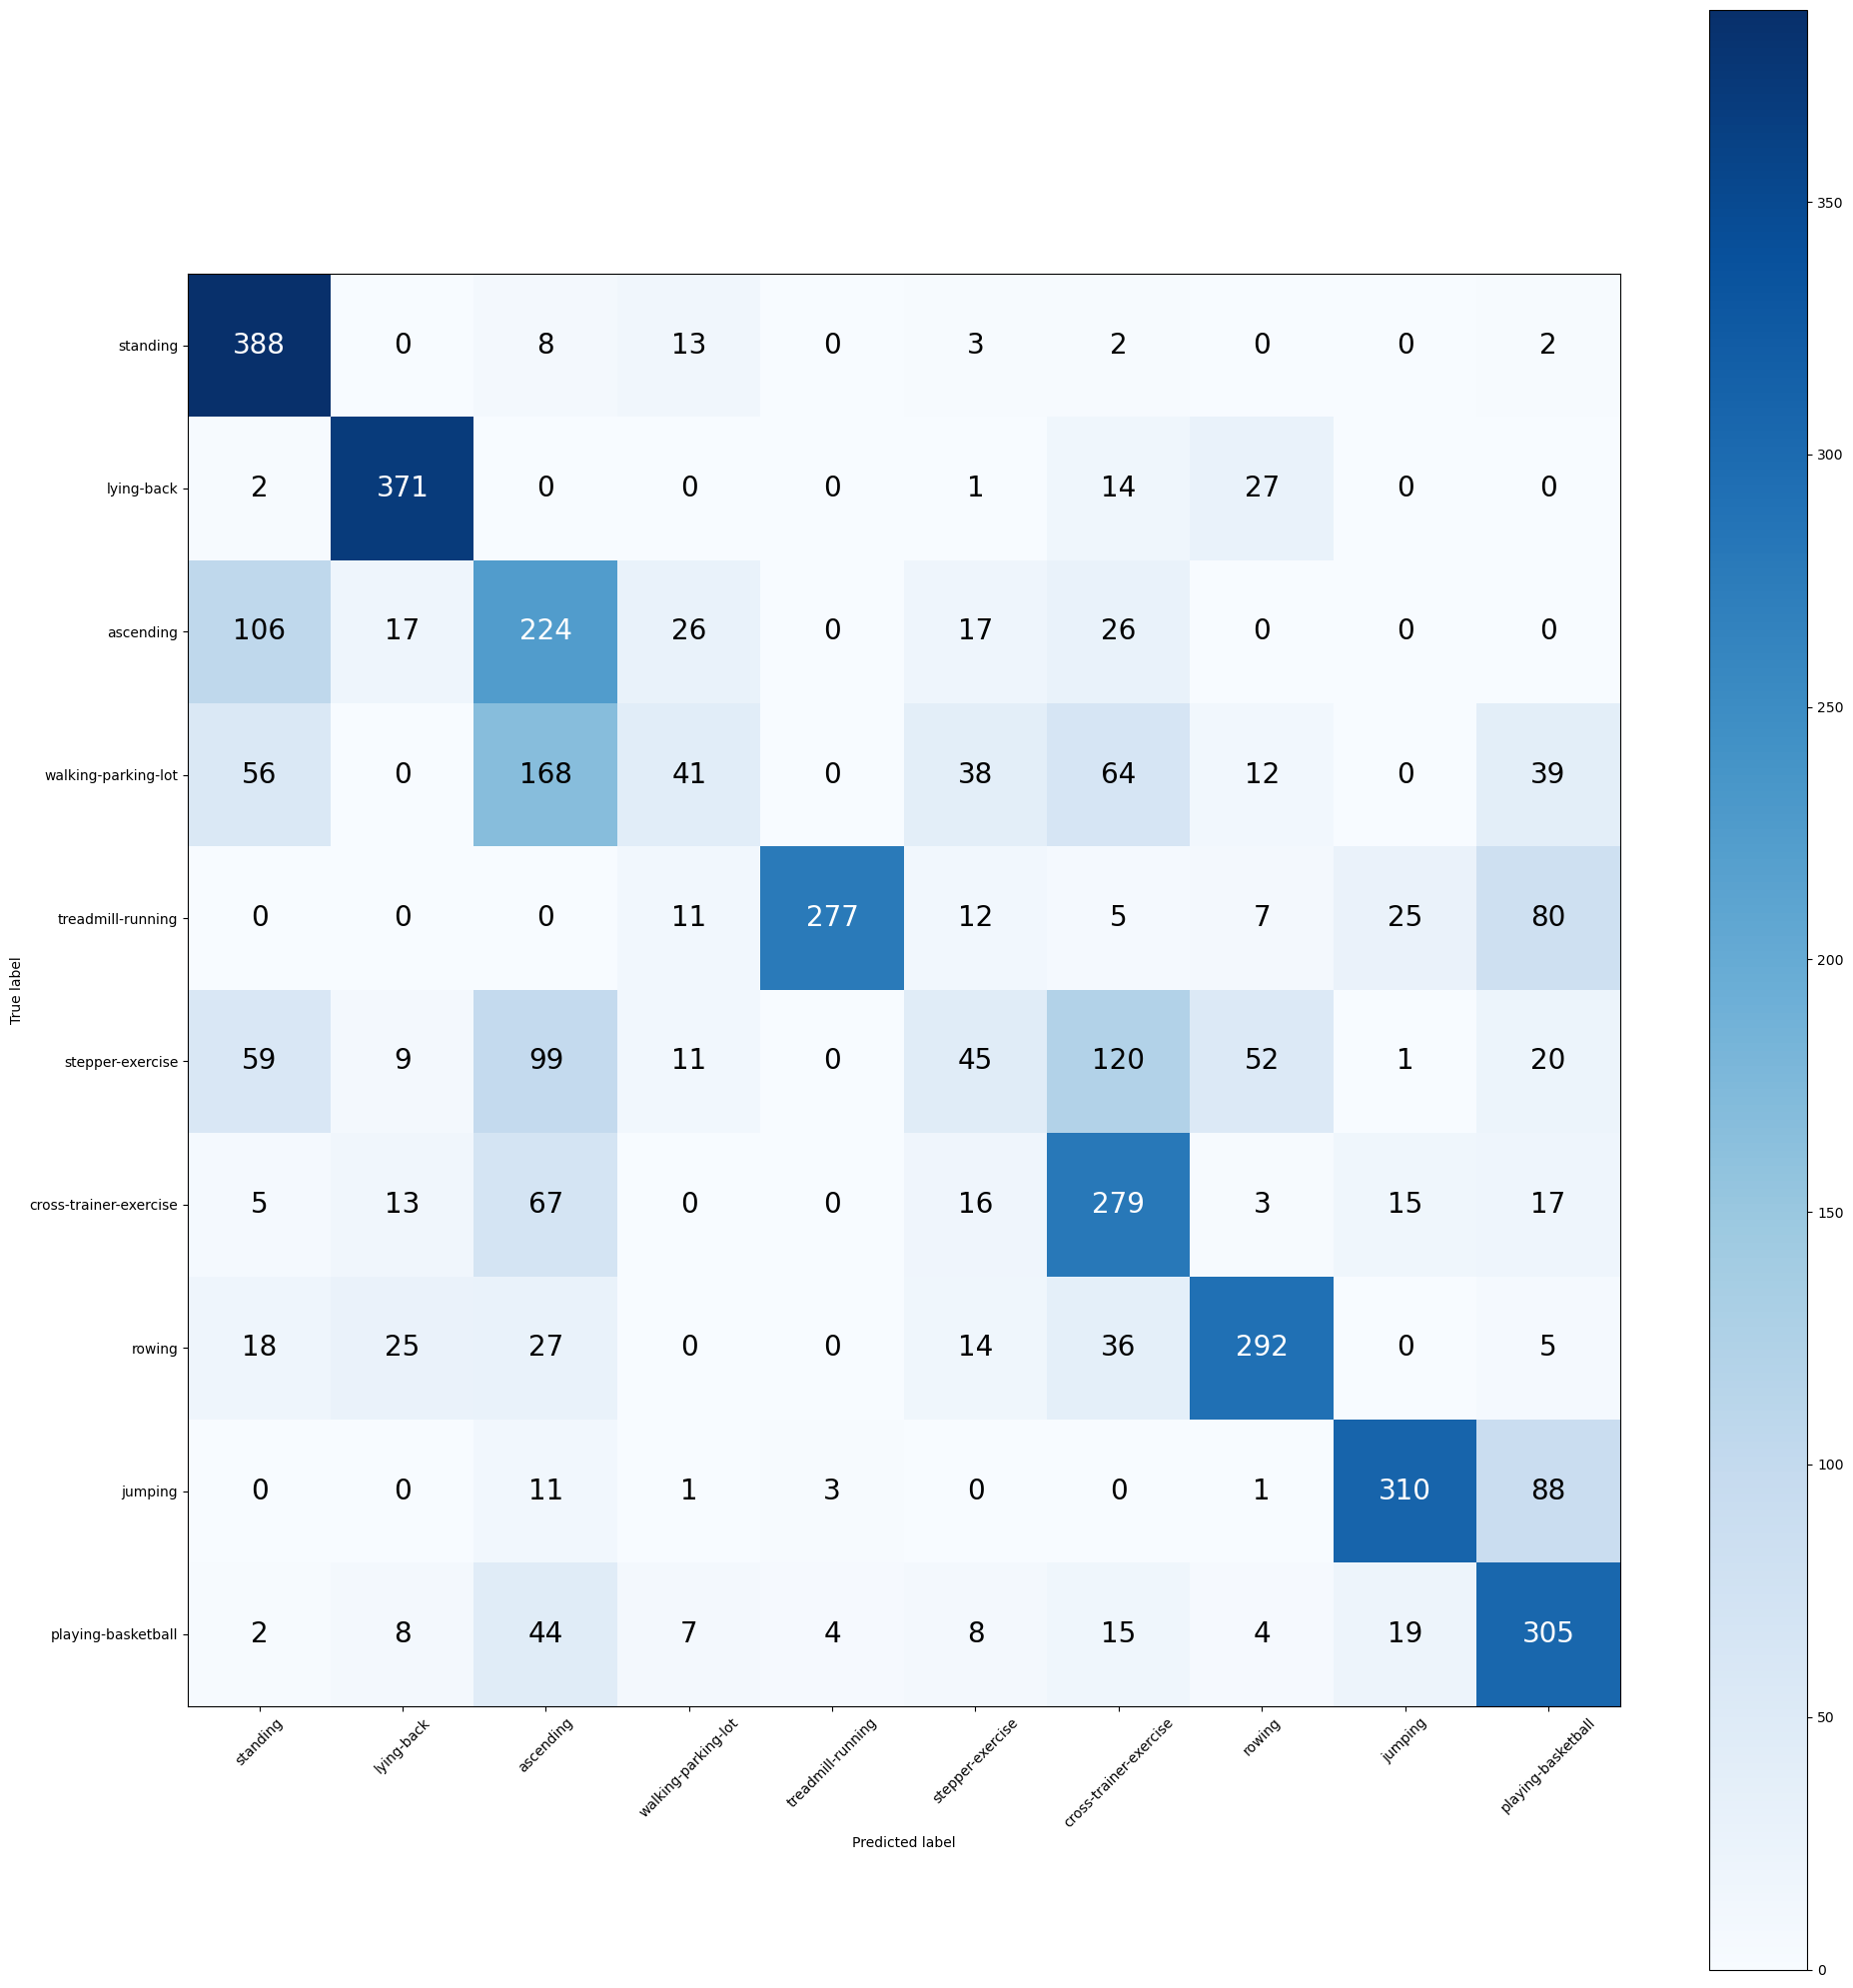

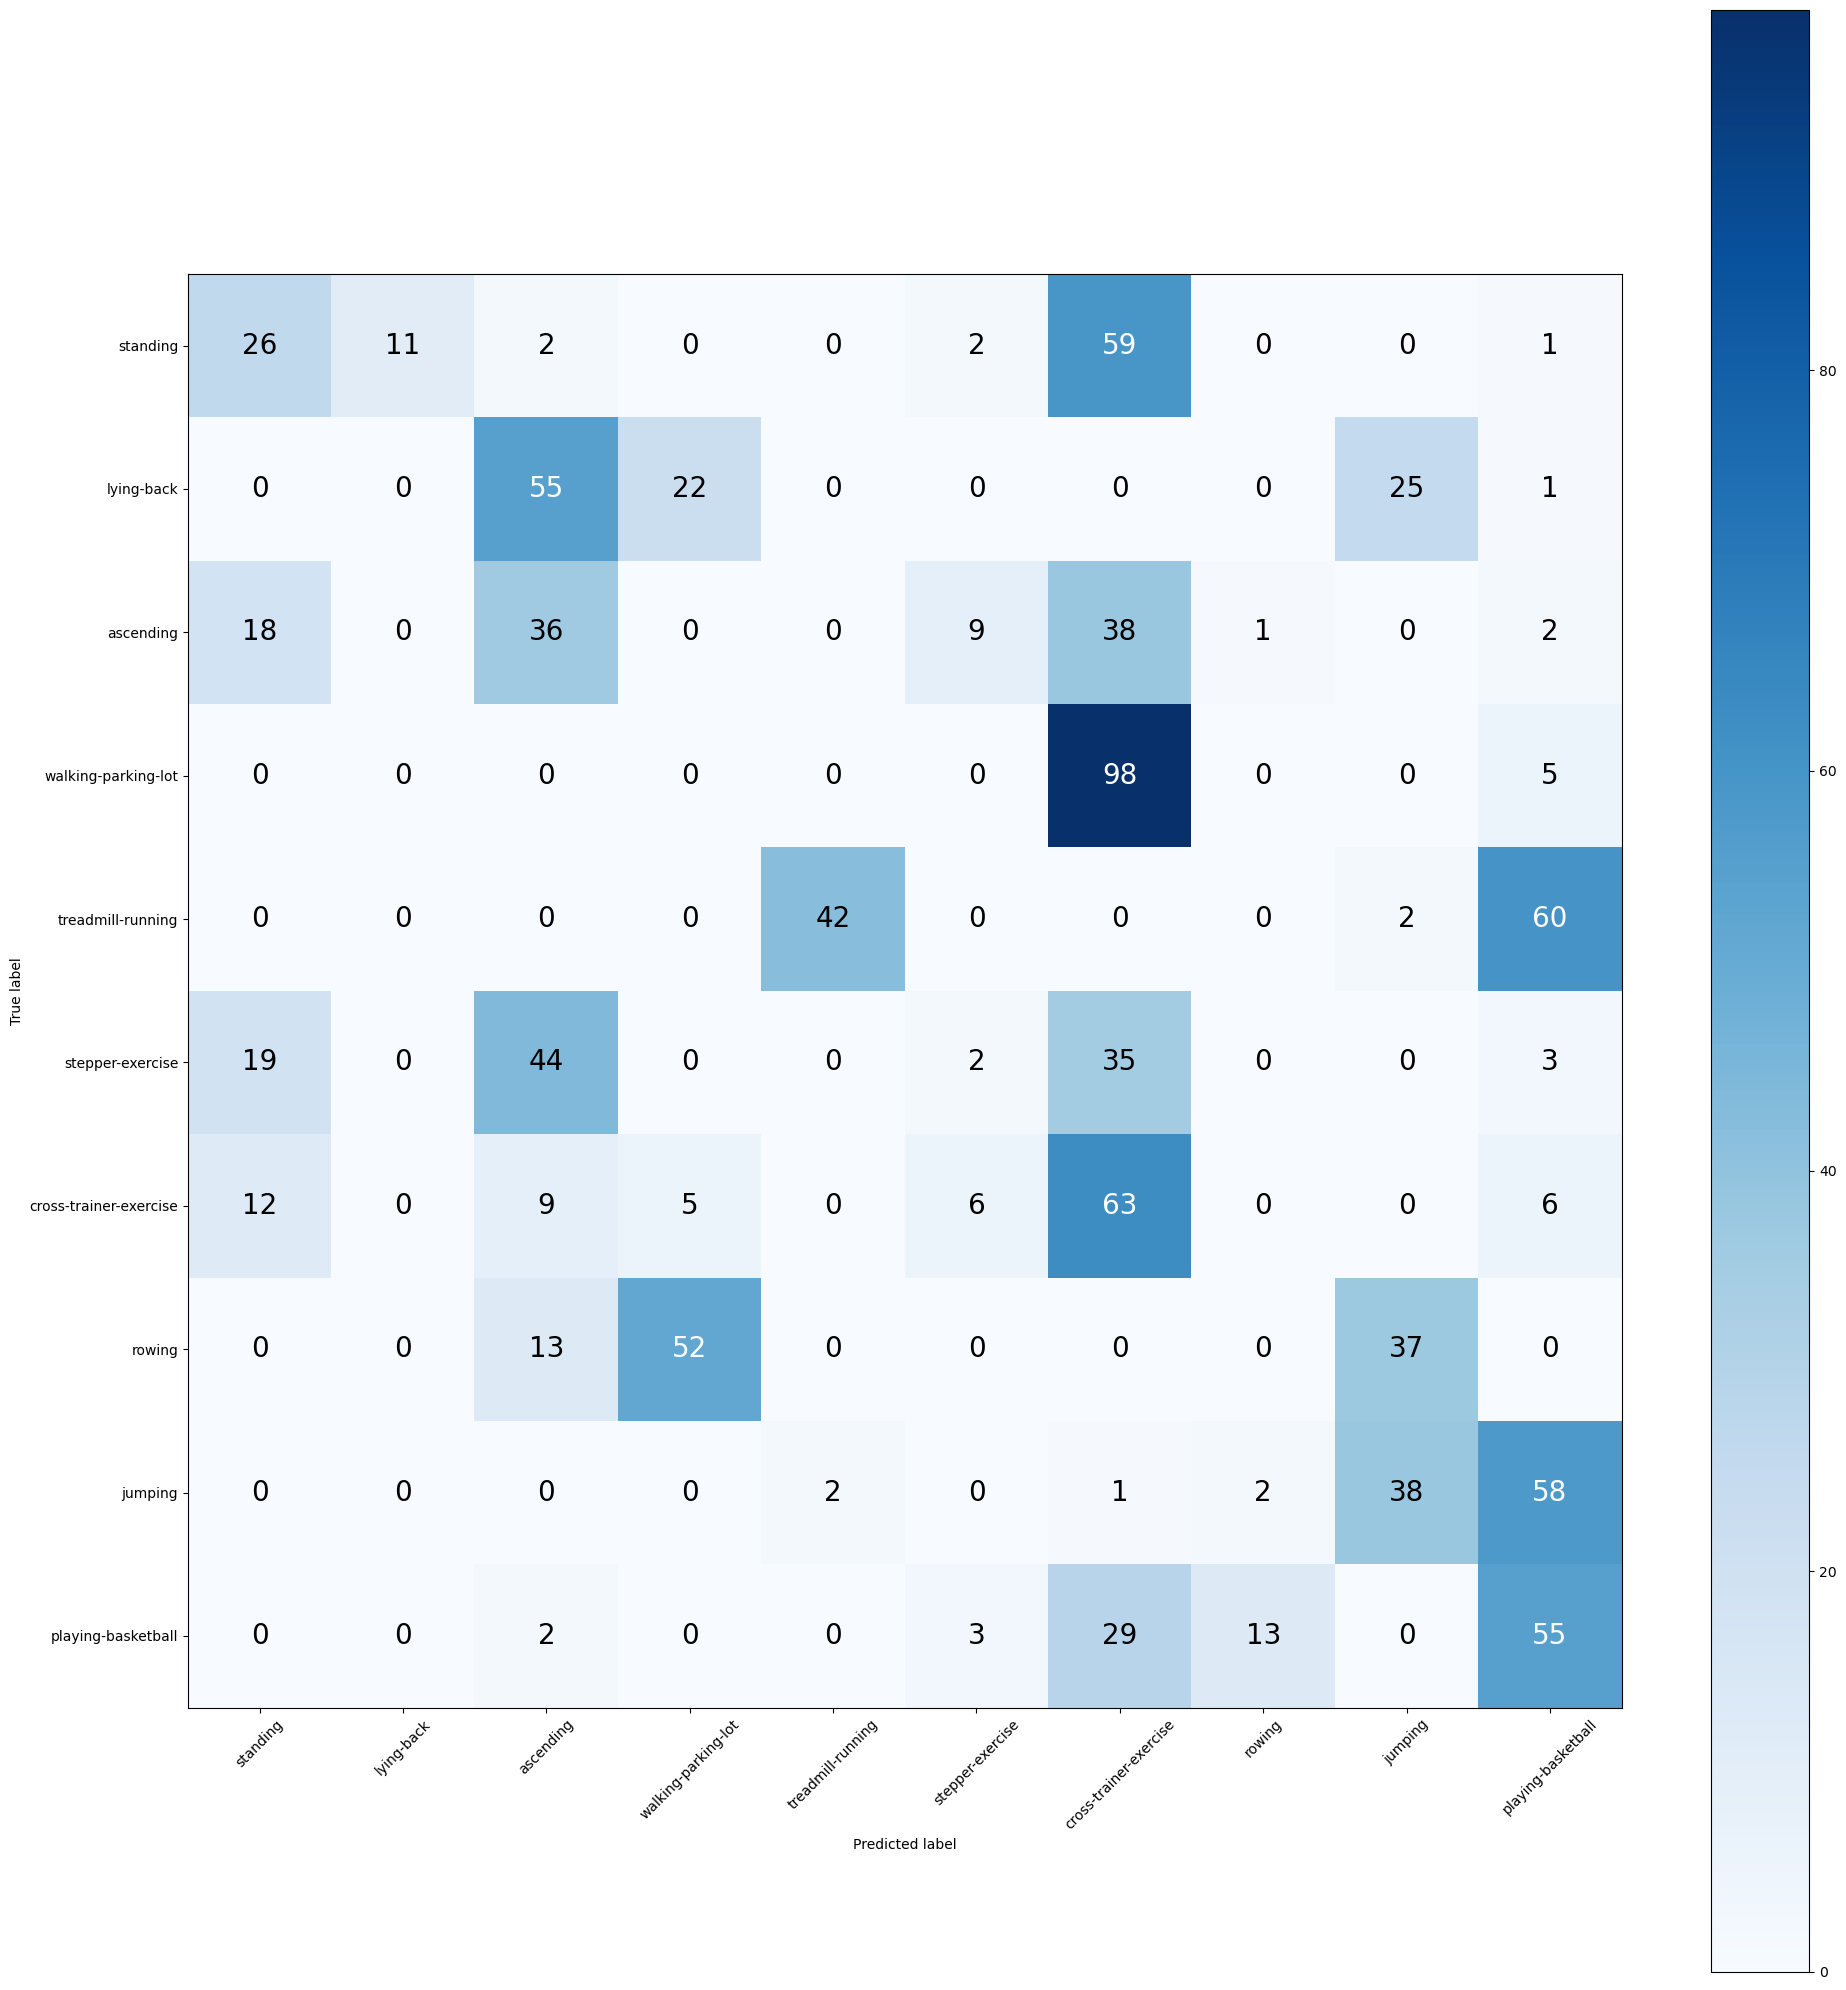

###Valid Source: Epoch: 10, avg_loss: 0.0433, Accuracy: 2532/4171 (60.70%)
###Valid Target: Epoch: 10, avg_loss: 0.0768, Accuracy: 262/1042 (25.14%)


Train Epoch: 11 [ 1/97]	Lambda: 0.5500, Class: 1.421055, CORAL: 0.158847, Total_Loss: 1.508421
Train Epoch: 11 [ 2/97]	Lambda: 0.5500, Class: 1.279646, CORAL: 0.137448, Total_Loss: 1.355242
Train Epoch: 11 [ 3/97]	Lambda: 0.5500, Class: 1.605583, CORAL: 0.154938, Total_Loss: 1.690799
Train Epoch: 11 [ 4/97]	Lambda: 0.5500, Class: 1.358216, CORAL: 0.442928, Total_Loss: 1.601826
Train Epoch: 11 [ 5/97]	Lambda: 0.5500, Class: 1.433603, CORAL: 0.122928, Total_Loss: 1.501213
Train Epoch: 11 [ 6/97]	Lambda: 0.5500, Class: 1.360789, CORAL: 0.130849, Total_Loss: 1.432756
Train Epoch: 11 [ 7/97]	Lambda: 0.5500, Class: 1.493387, CORAL: 0.188513, Total_Loss: 1.597069
Train Epoch: 11 [ 8/97]	Lambda: 0.5500, Class: 1.484375, CORAL: 0.214371, Total_Loss: 1.602280
Train Epoch: 11 [ 9/97]	Lambda: 0.5500, Class: 1.531520, CORAL: 0.104846, Total_Loss: 1.5

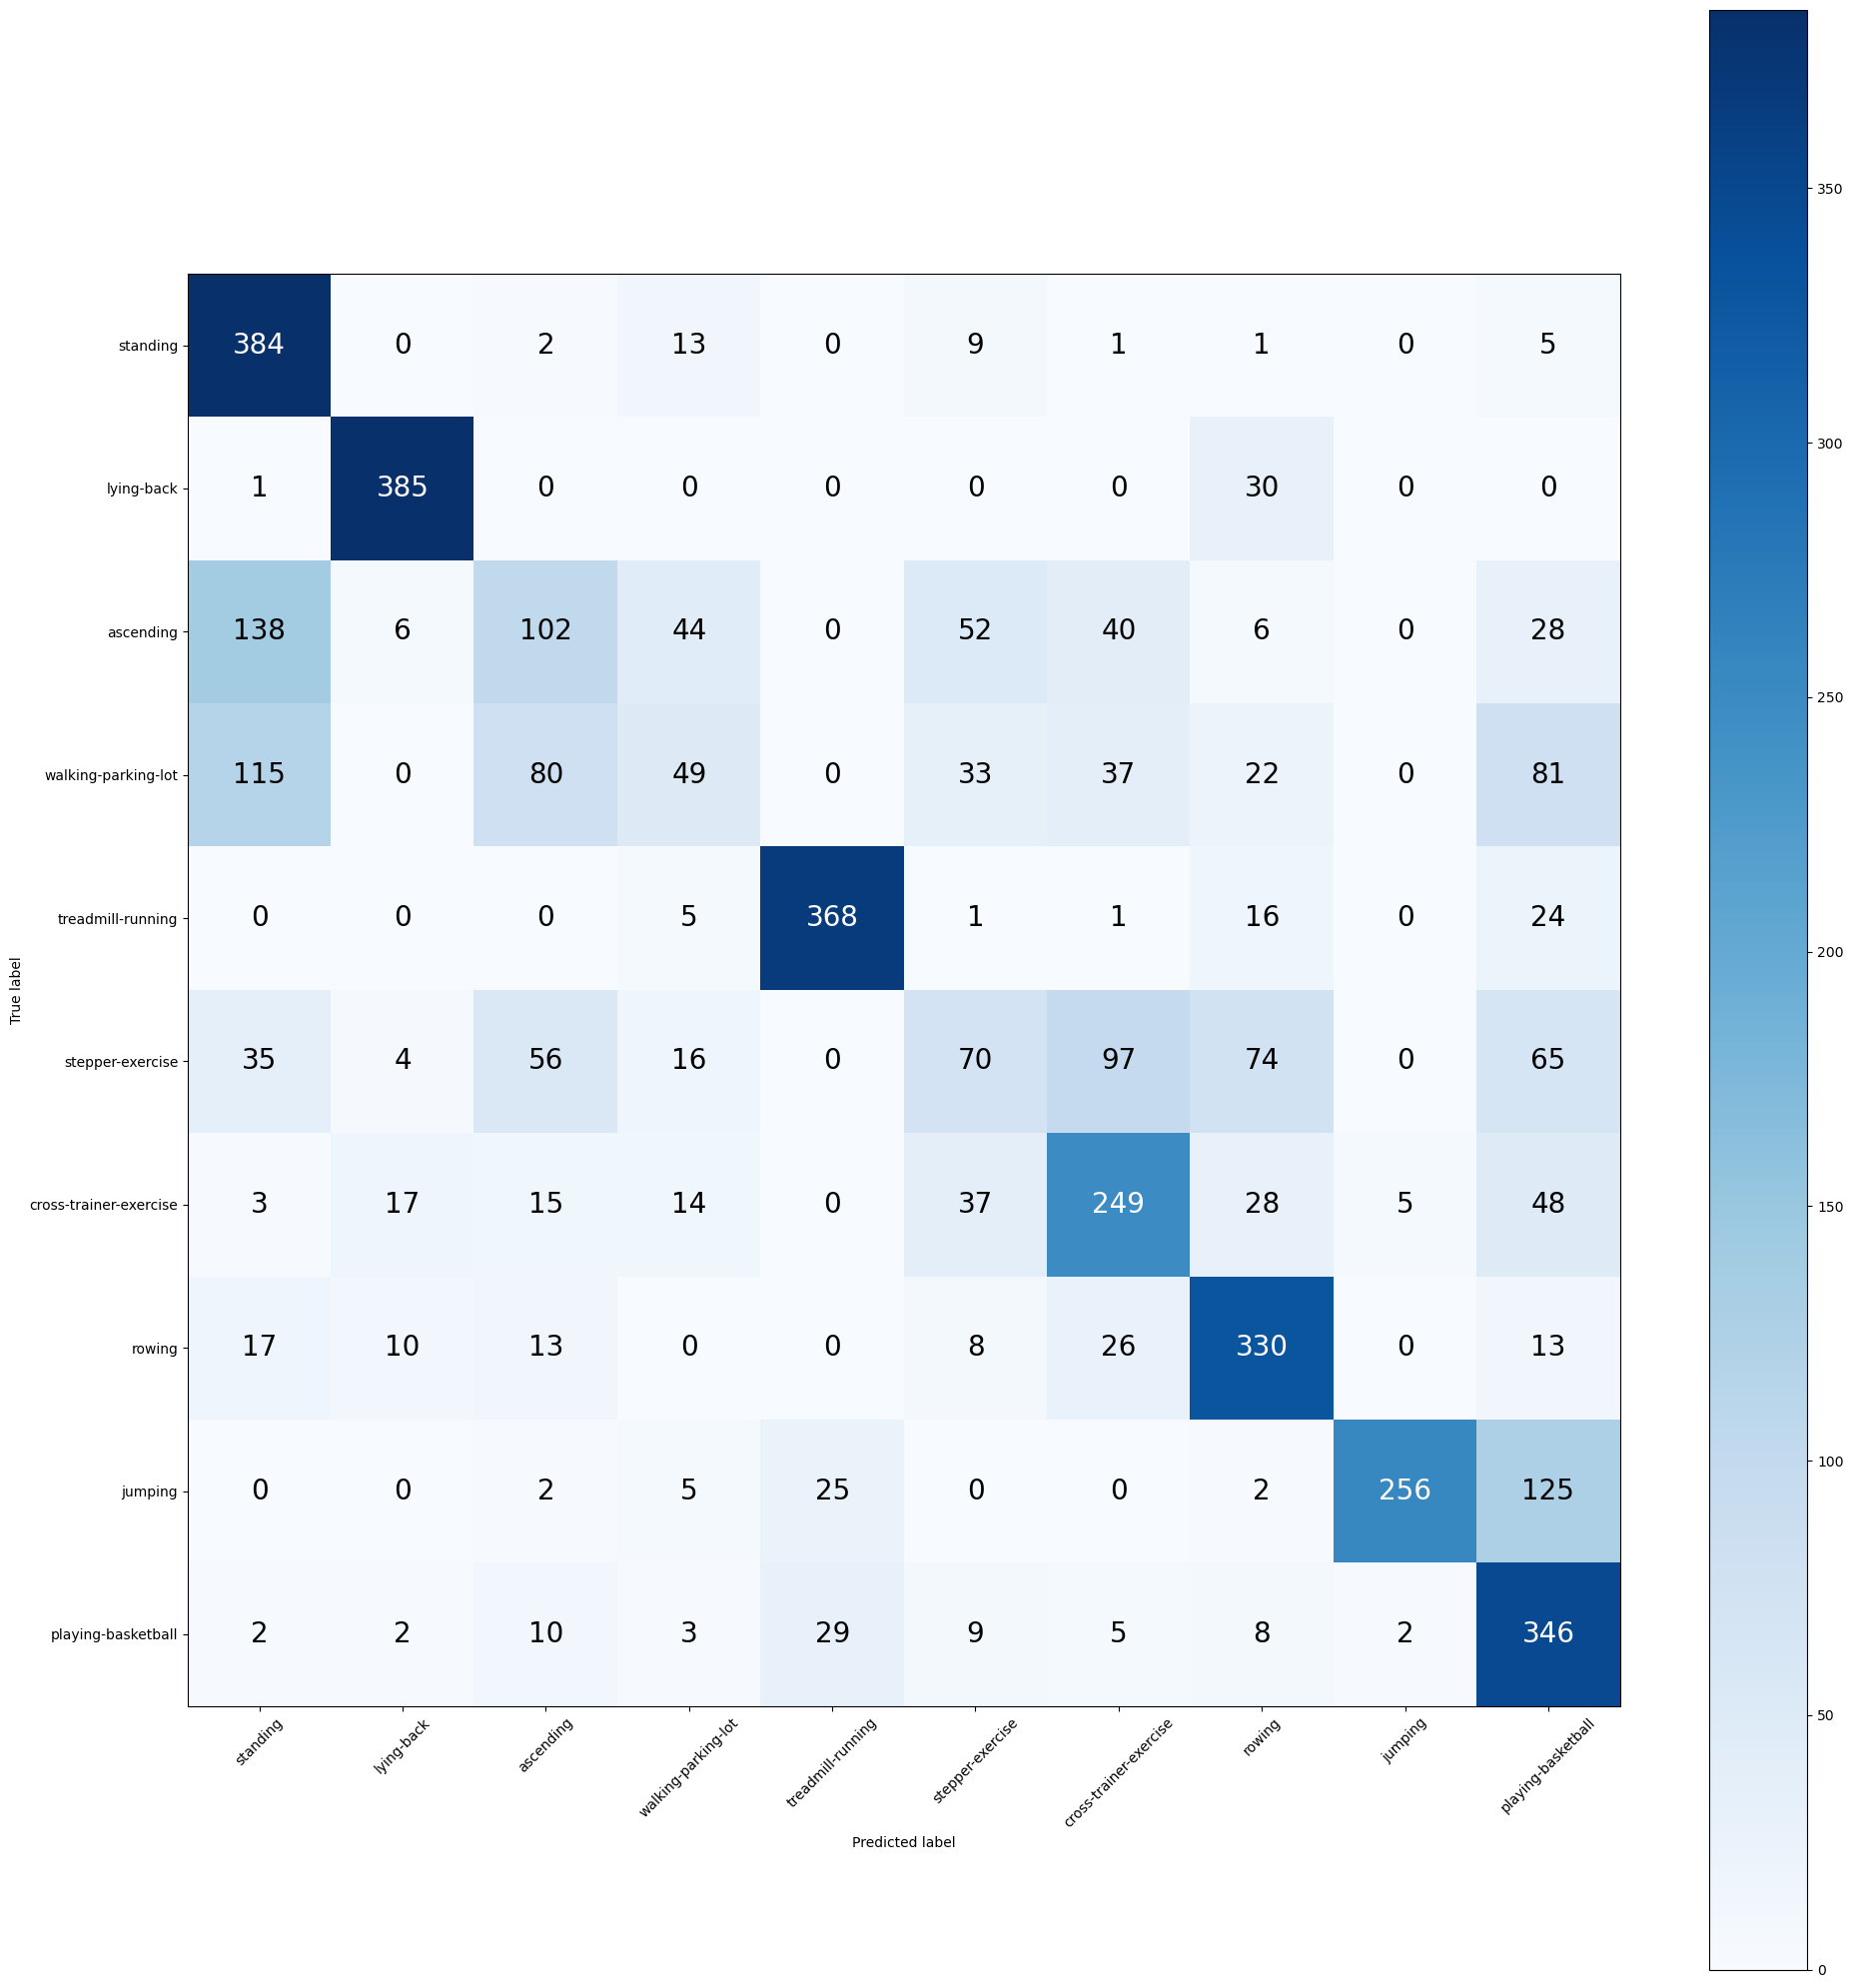

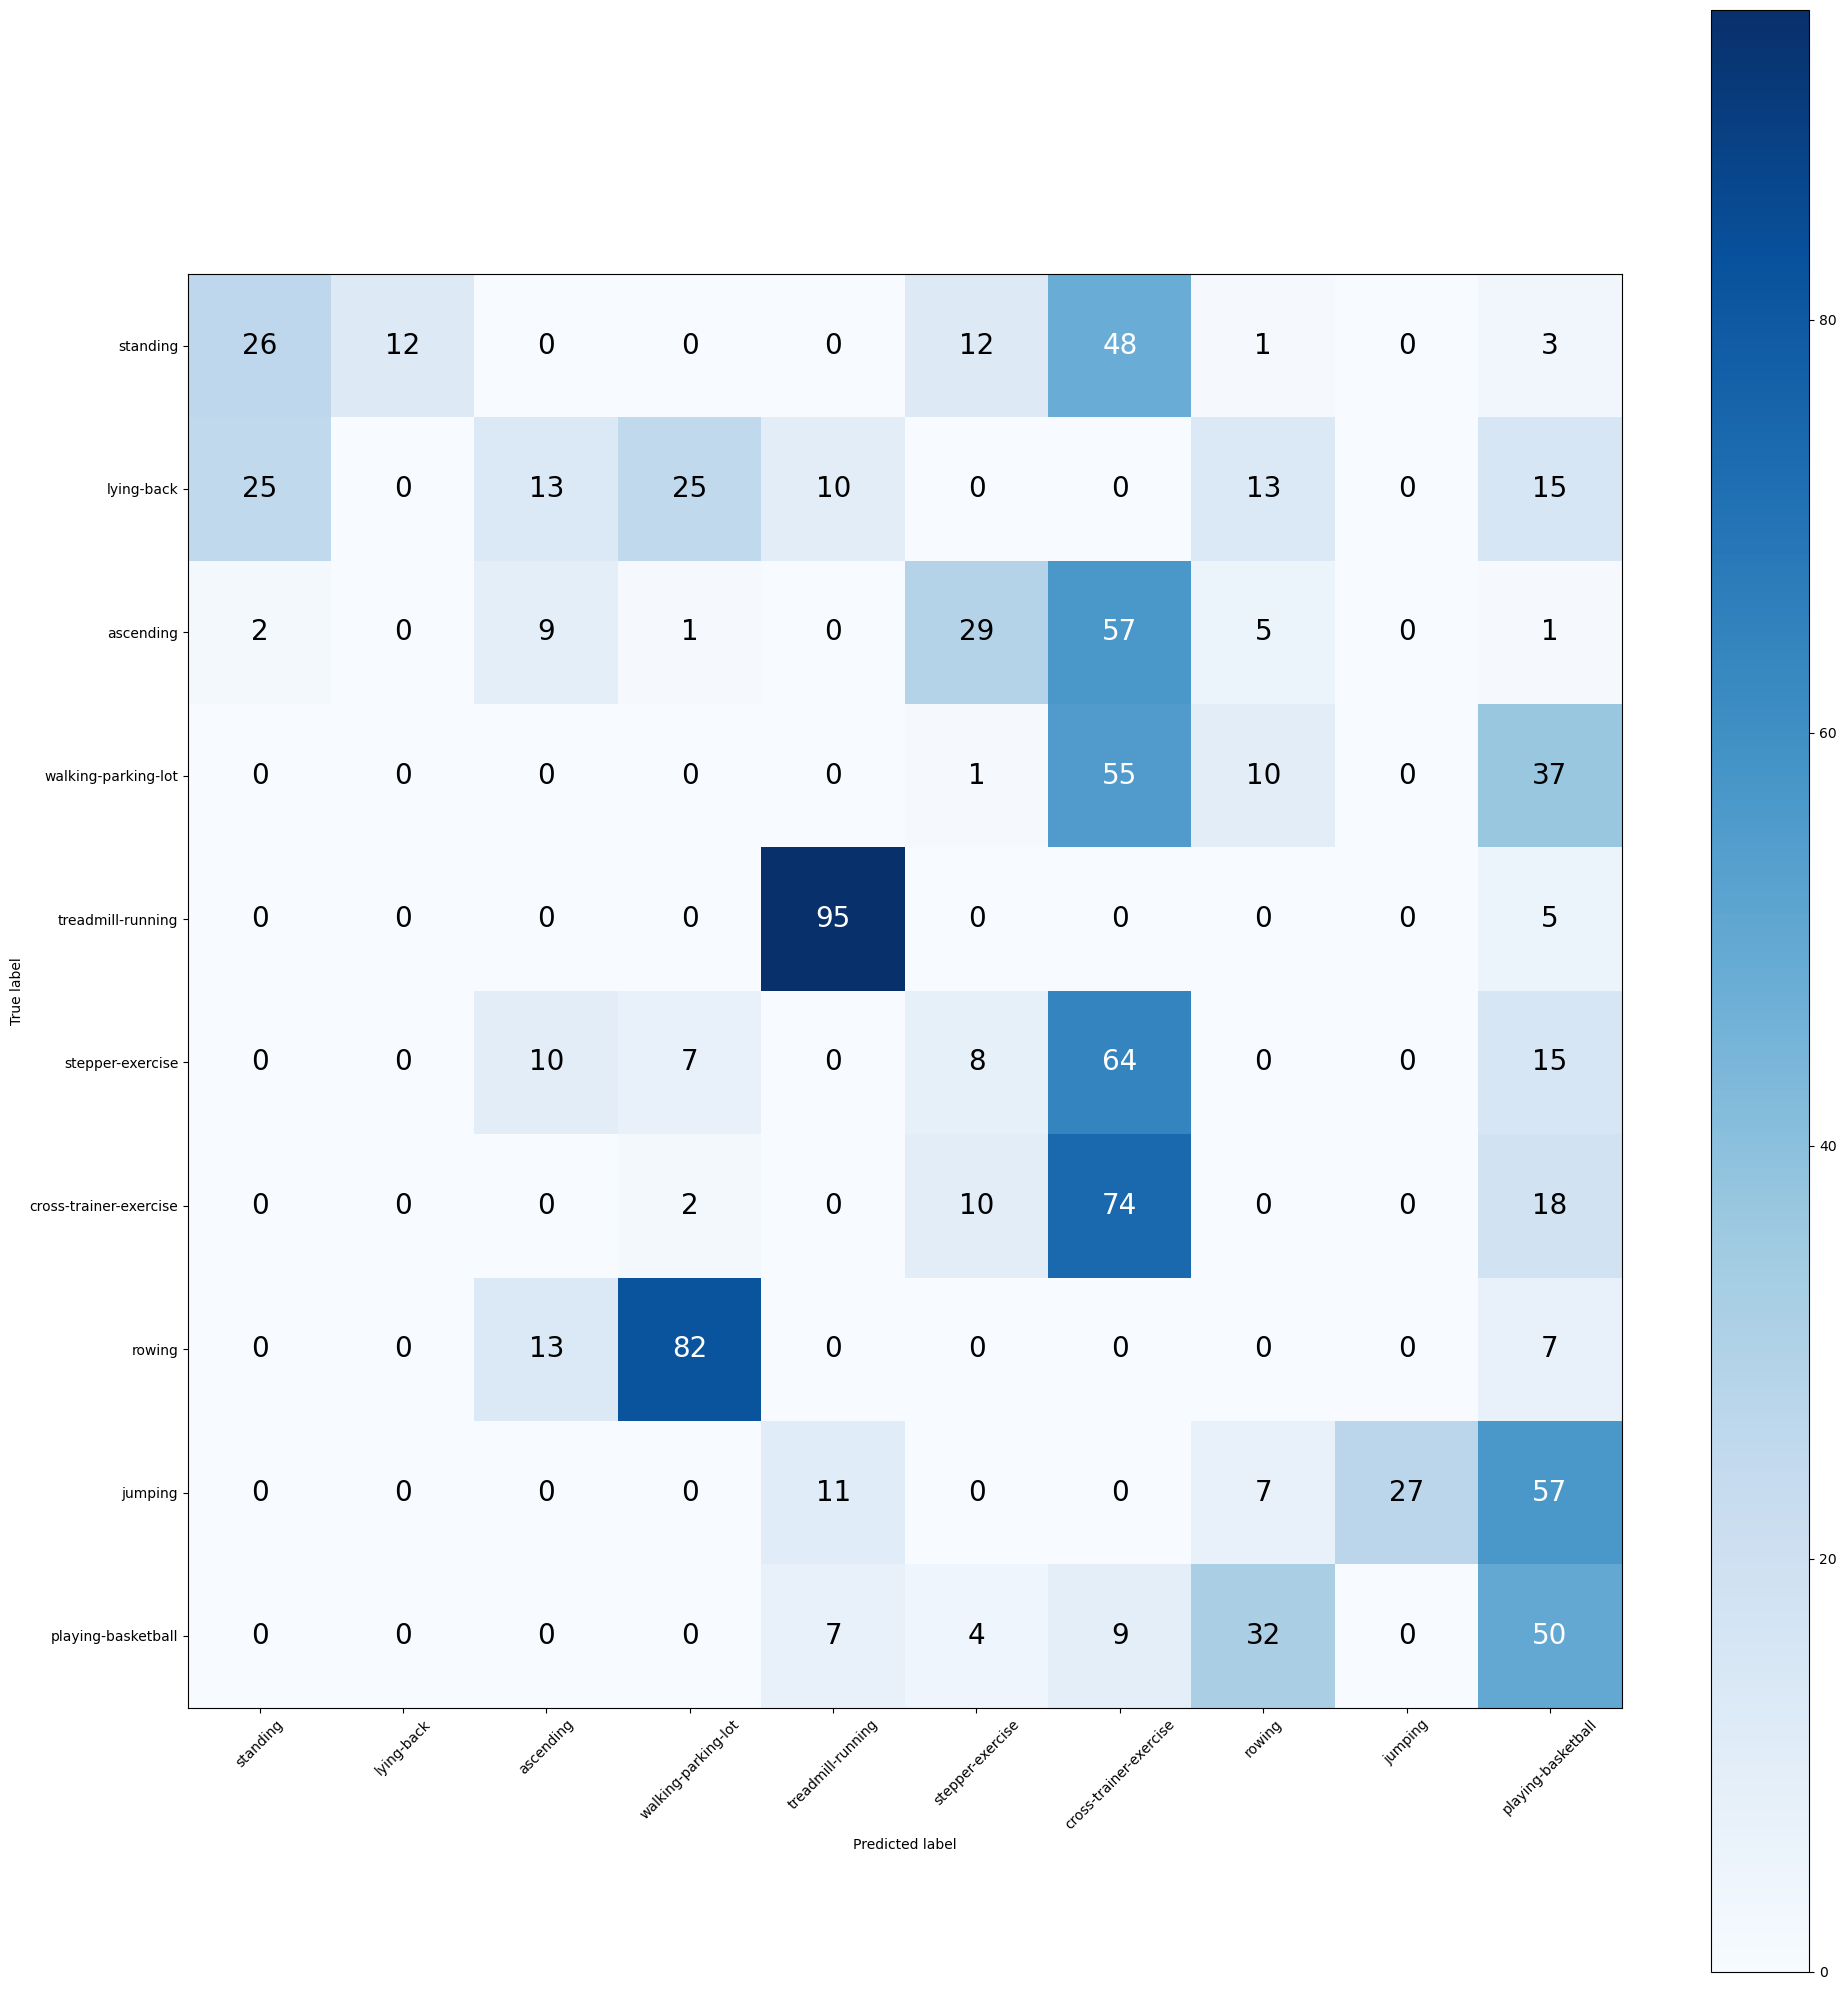

###Valid Source: Epoch: 11, avg_loss: 0.0402, Accuracy: 2539/4171 (60.87%)
###Valid Target: Epoch: 11, avg_loss: 0.0752, Accuracy: 289/1042 (27.74%)


Train Epoch: 12 [ 1/97]	Lambda: 0.6000, Class: 1.280935, CORAL: 0.155561, Total_Loss: 1.374272
Train Epoch: 12 [ 2/97]	Lambda: 0.6000, Class: 1.214304, CORAL: 0.133735, Total_Loss: 1.294545
Train Epoch: 12 [ 3/97]	Lambda: 0.6000, Class: 1.242243, CORAL: 0.116727, Total_Loss: 1.312279
Train Epoch: 12 [ 4/97]	Lambda: 0.6000, Class: 1.206463, CORAL: 0.100992, Total_Loss: 1.267058
Train Epoch: 12 [ 5/97]	Lambda: 0.6000, Class: 1.427667, CORAL: 0.149151, Total_Loss: 1.517158
Train Epoch: 12 [ 6/97]	Lambda: 0.6000, Class: 1.095052, CORAL: 0.089017, Total_Loss: 1.148462
Train Epoch: 12 [ 7/97]	Lambda: 0.6000, Class: 1.436347, CORAL: 0.085242, Total_Loss: 1.487493
Train Epoch: 12 [ 8/97]	Lambda: 0.6000, Class: 1.022331, CORAL: 0.273982, Total_Loss: 1.186720
Train Epoch: 12 [ 9/97]	Lambda: 0.6000, Class: 1.207499, CORAL: 0.115273, Total_Loss: 1.2

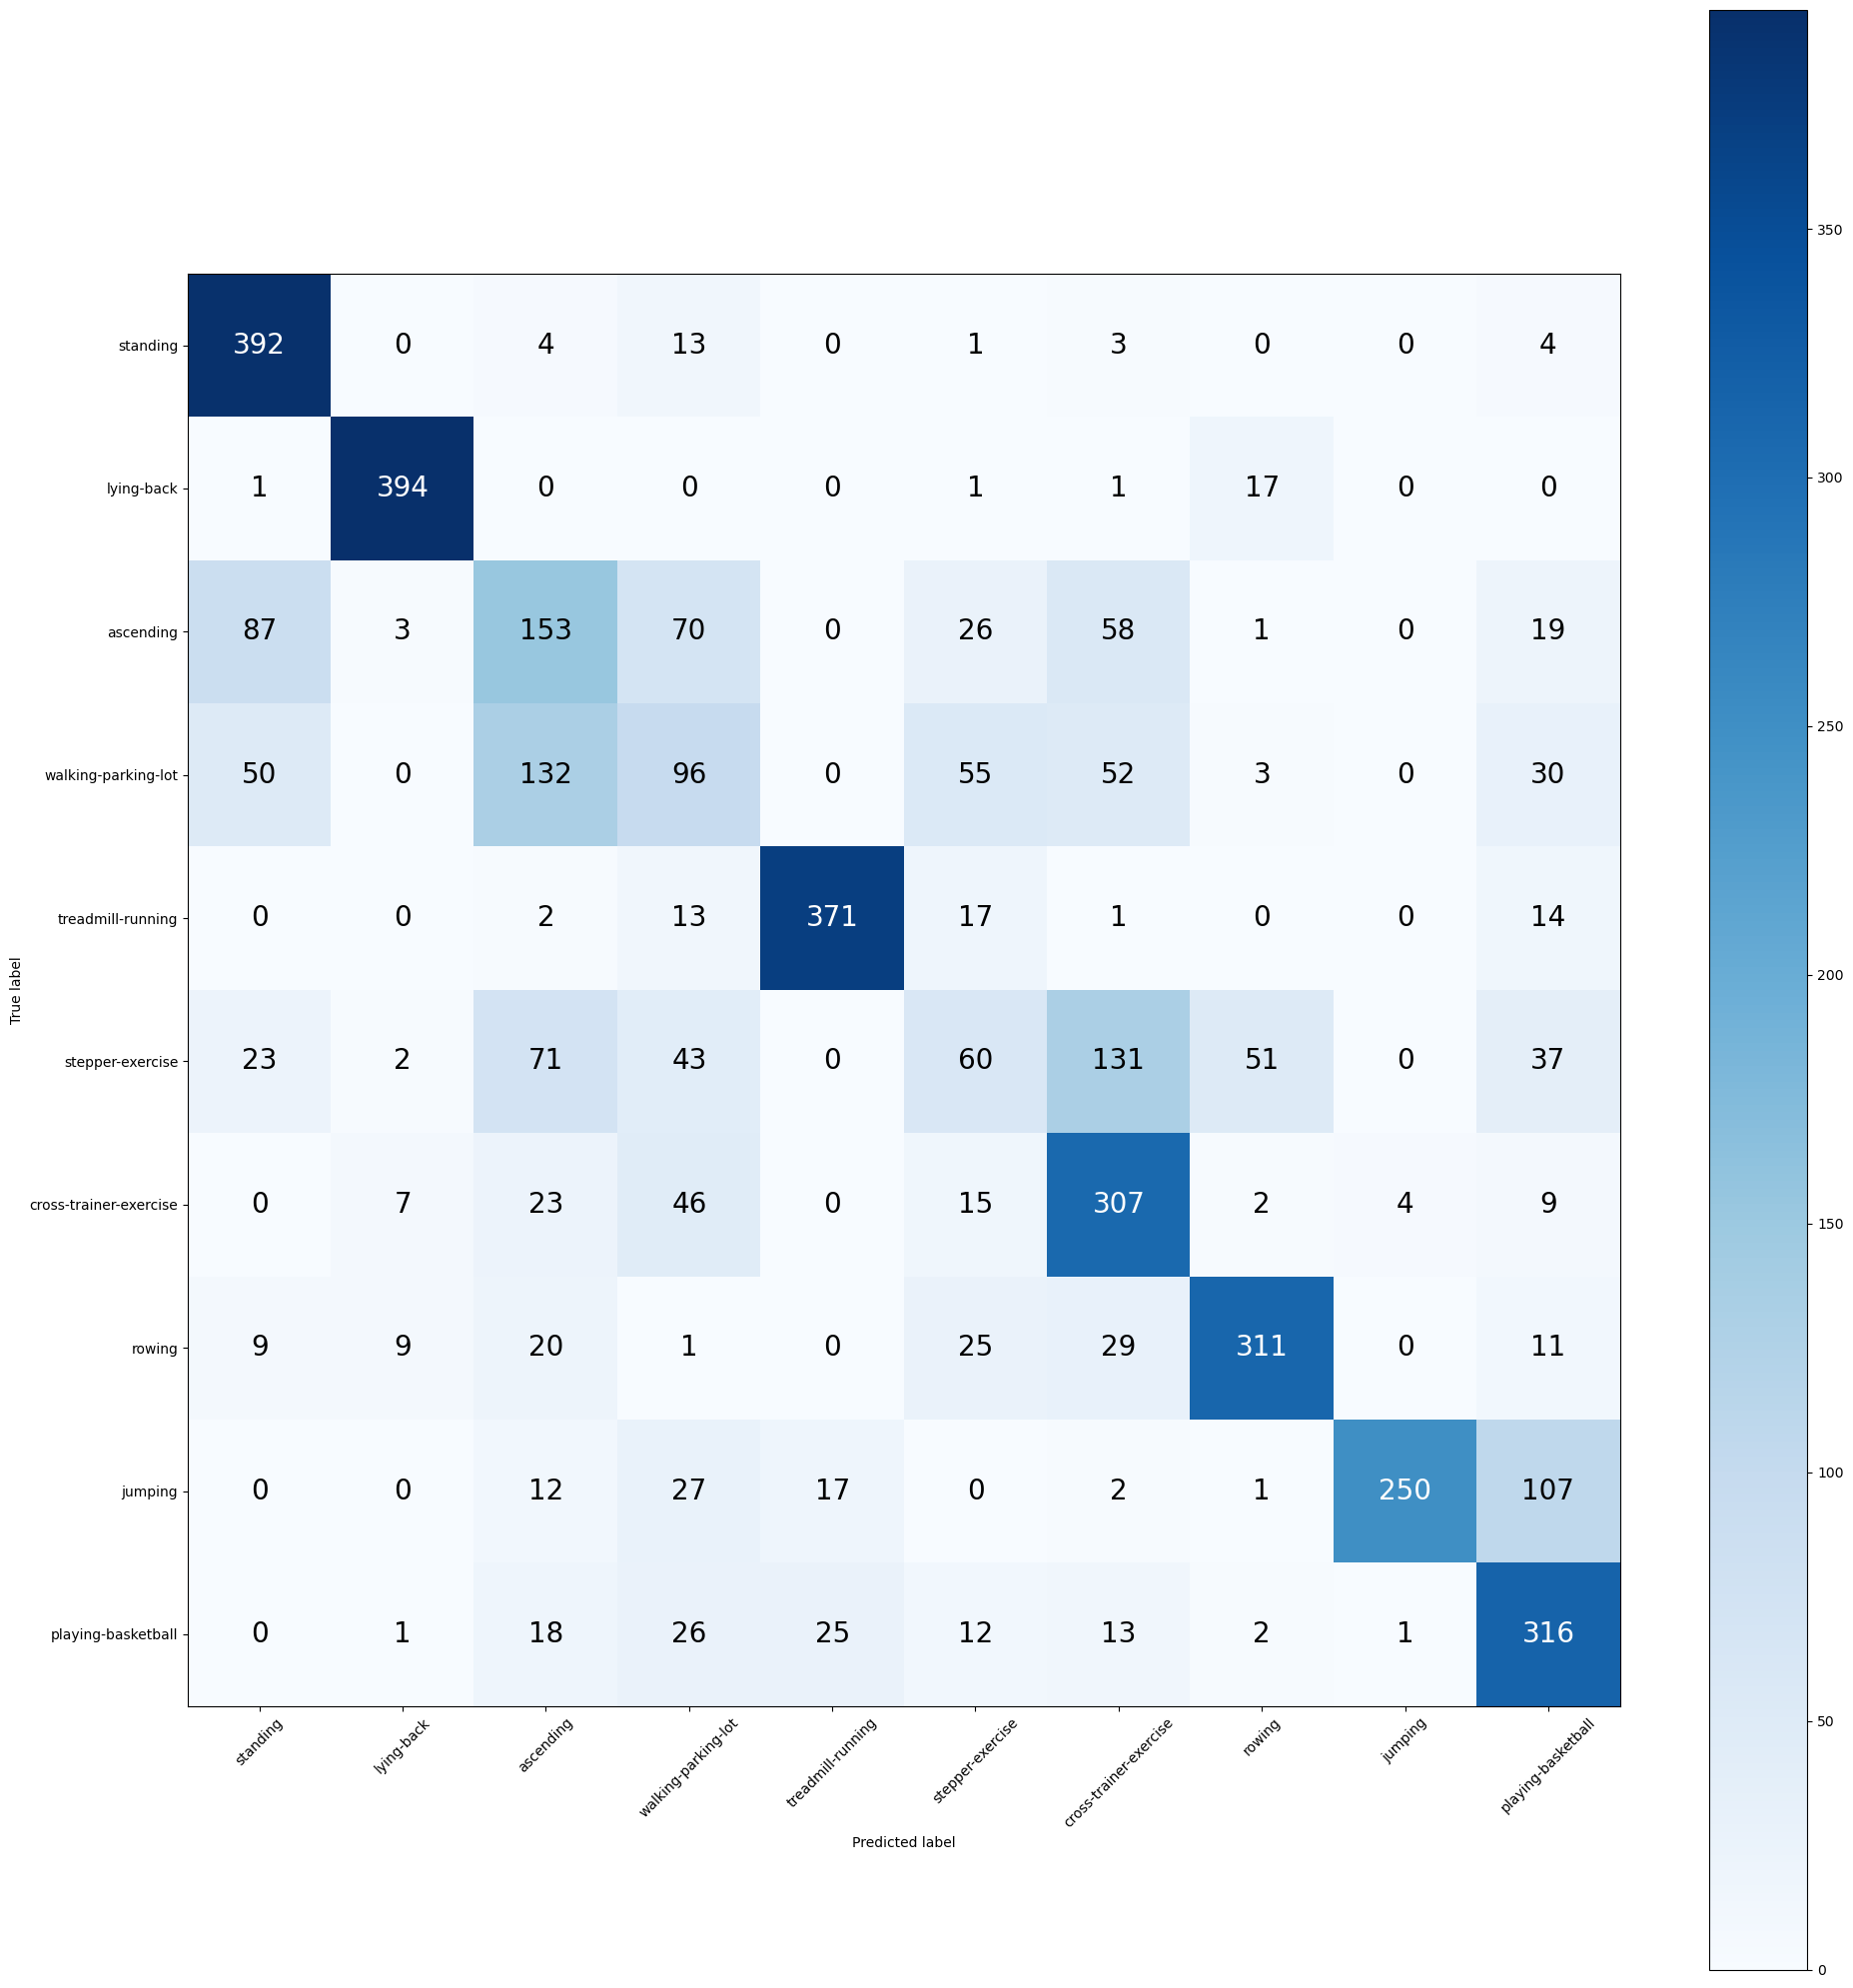

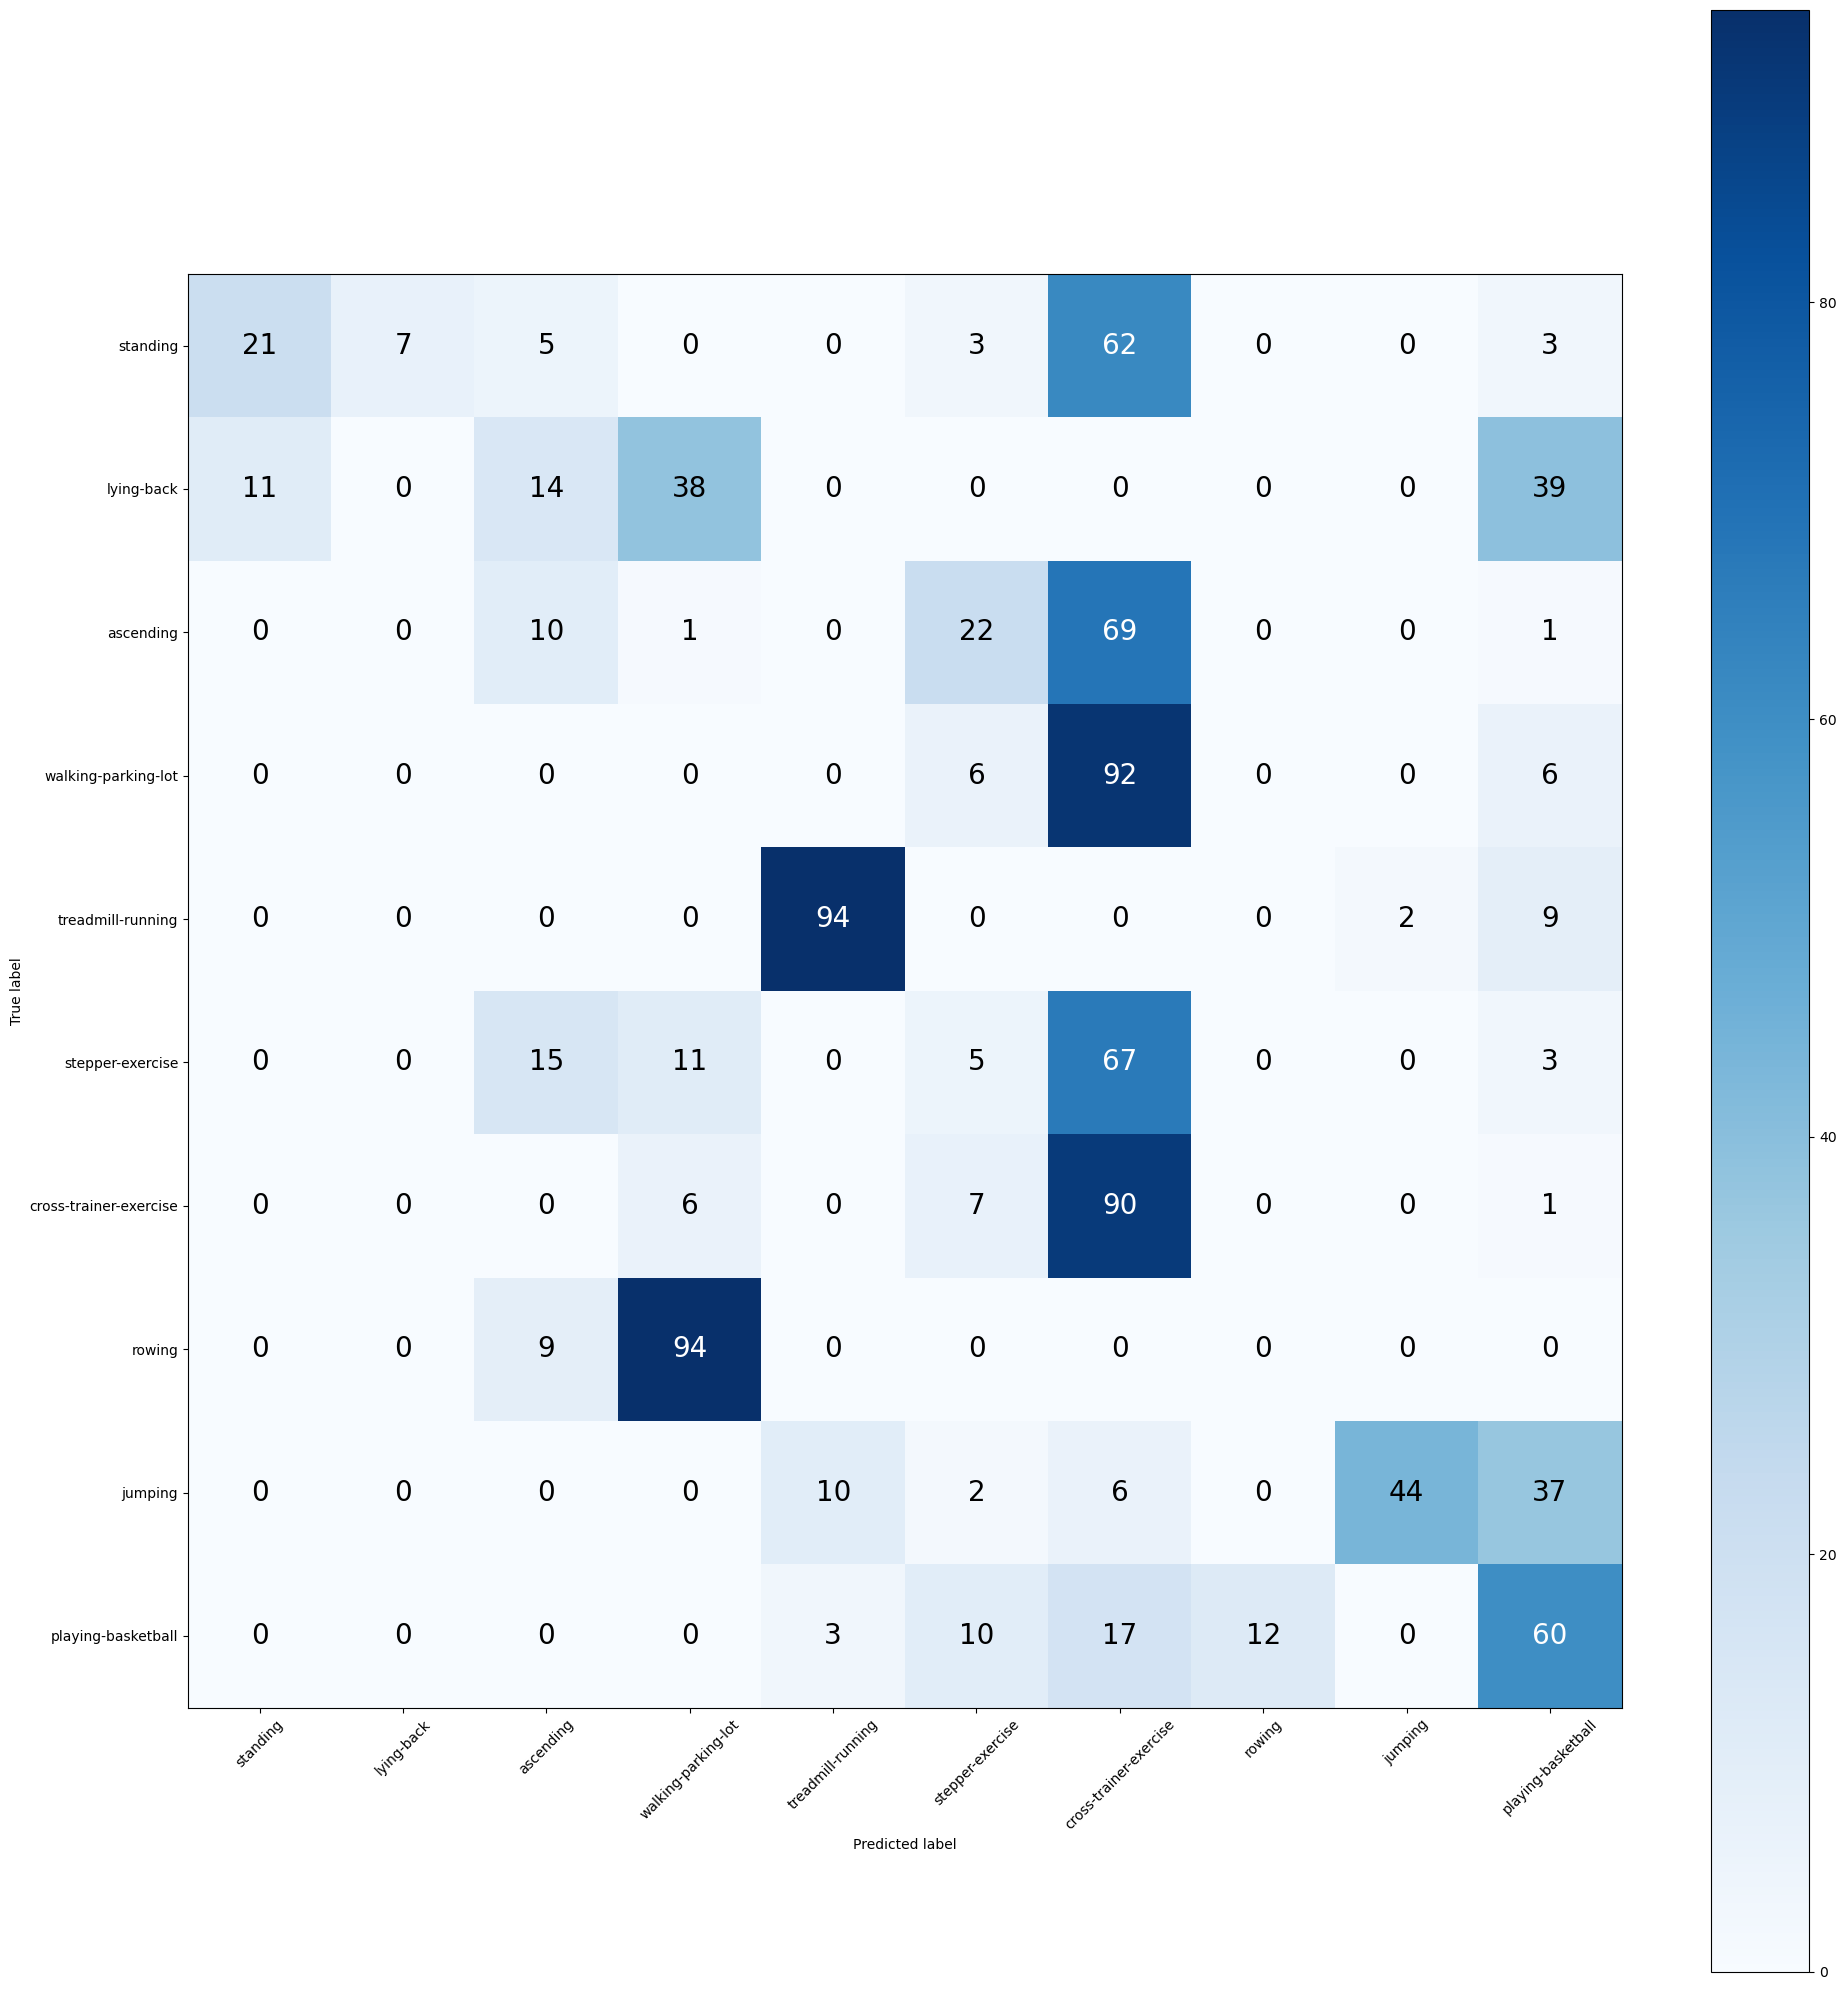

###Valid Source: Epoch: 12, avg_loss: 0.0389, Accuracy: 2650/4171 (63.53%)
###Valid Target: Epoch: 12, avg_loss: 0.0728, Accuracy: 324/1042 (31.09%)


Train Epoch: 13 [ 1/97]	Lambda: 0.6500, Class: 1.195146, CORAL: 0.160576, Total_Loss: 1.299521
Train Epoch: 13 [ 2/97]	Lambda: 0.6500, Class: 1.290200, CORAL: 0.164323, Total_Loss: 1.397009
Train Epoch: 13 [ 3/97]	Lambda: 0.6500, Class: 1.274571, CORAL: 0.081736, Total_Loss: 1.327699
Train Epoch: 13 [ 4/97]	Lambda: 0.6500, Class: 1.149975, CORAL: 0.328985, Total_Loss: 1.363815
Train Epoch: 13 [ 5/97]	Lambda: 0.6500, Class: 1.265665, CORAL: 0.146251, Total_Loss: 1.360728
Train Epoch: 13 [ 6/97]	Lambda: 0.6500, Class: 1.201823, CORAL: 0.083966, Total_Loss: 1.256401
Train Epoch: 13 [ 7/97]	Lambda: 0.6500, Class: 1.182549, CORAL: 0.164207, Total_Loss: 1.289284
Train Epoch: 13 [ 8/97]	Lambda: 0.6500, Class: 1.188296, CORAL: 0.225175, Total_Loss: 1.334659
Train Epoch: 13 [ 9/97]	Lambda: 0.6500, Class: 1.384423, CORAL: 0.173936, Total_Loss: 1.4

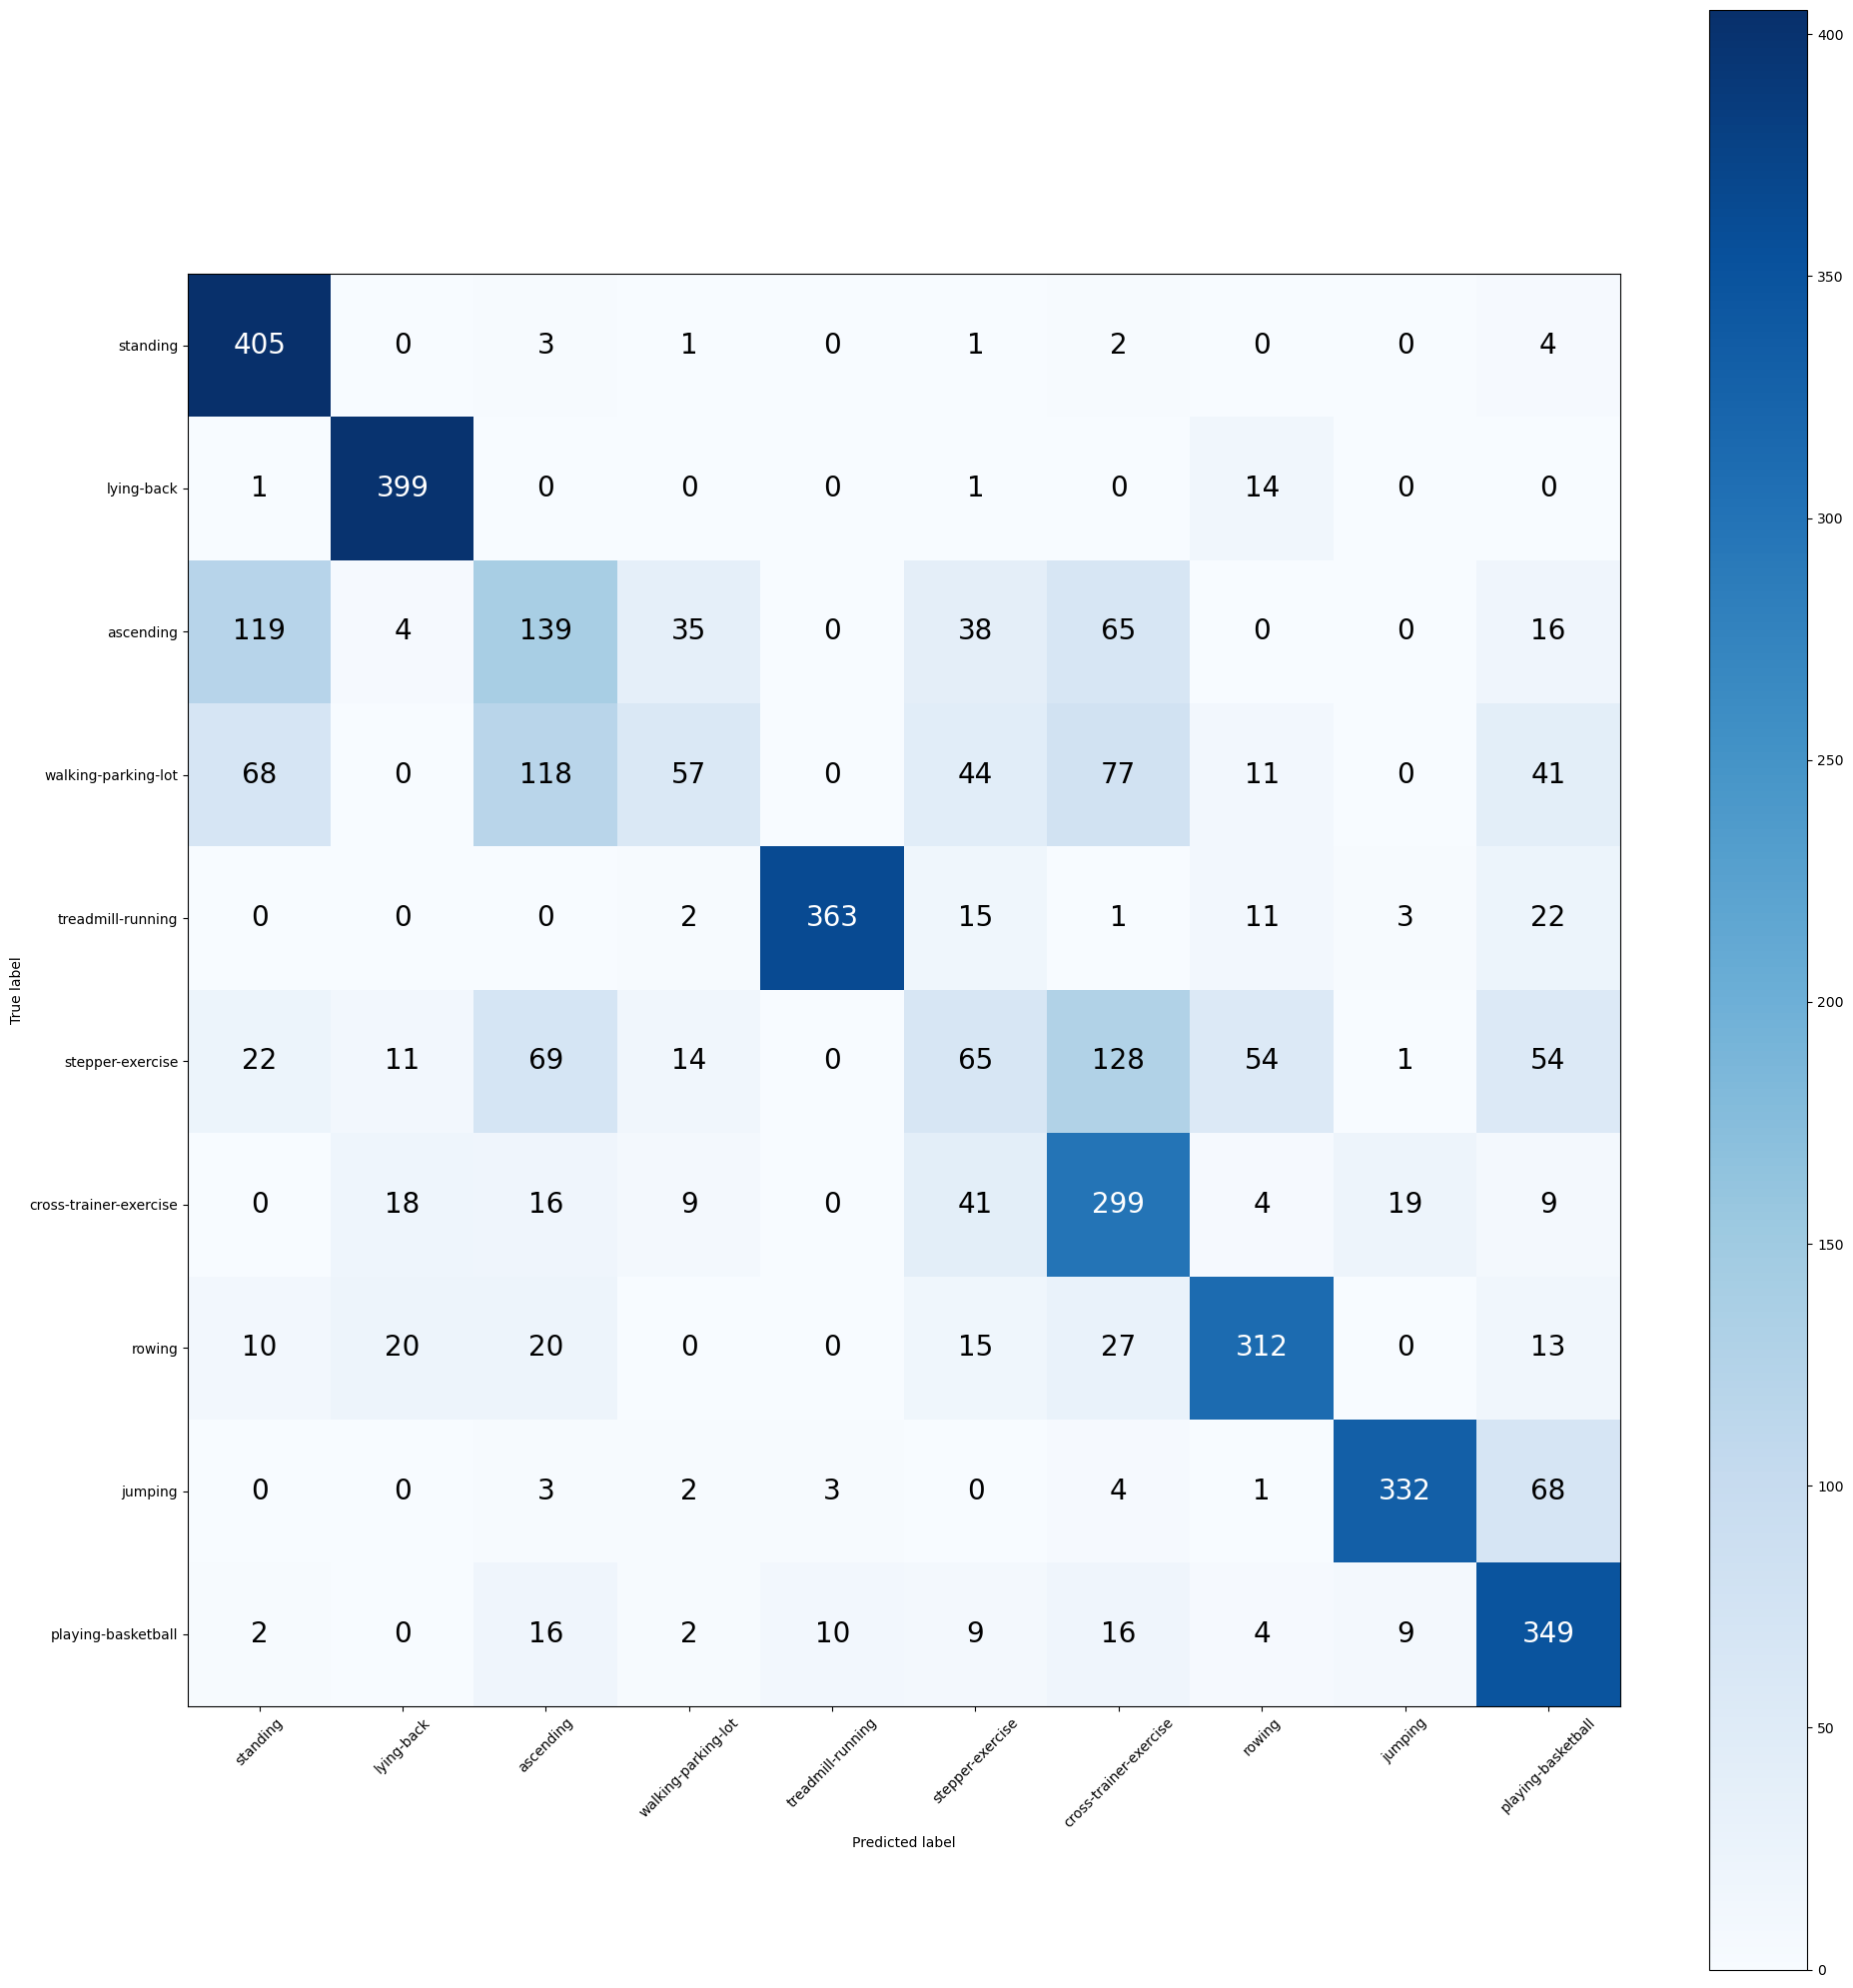

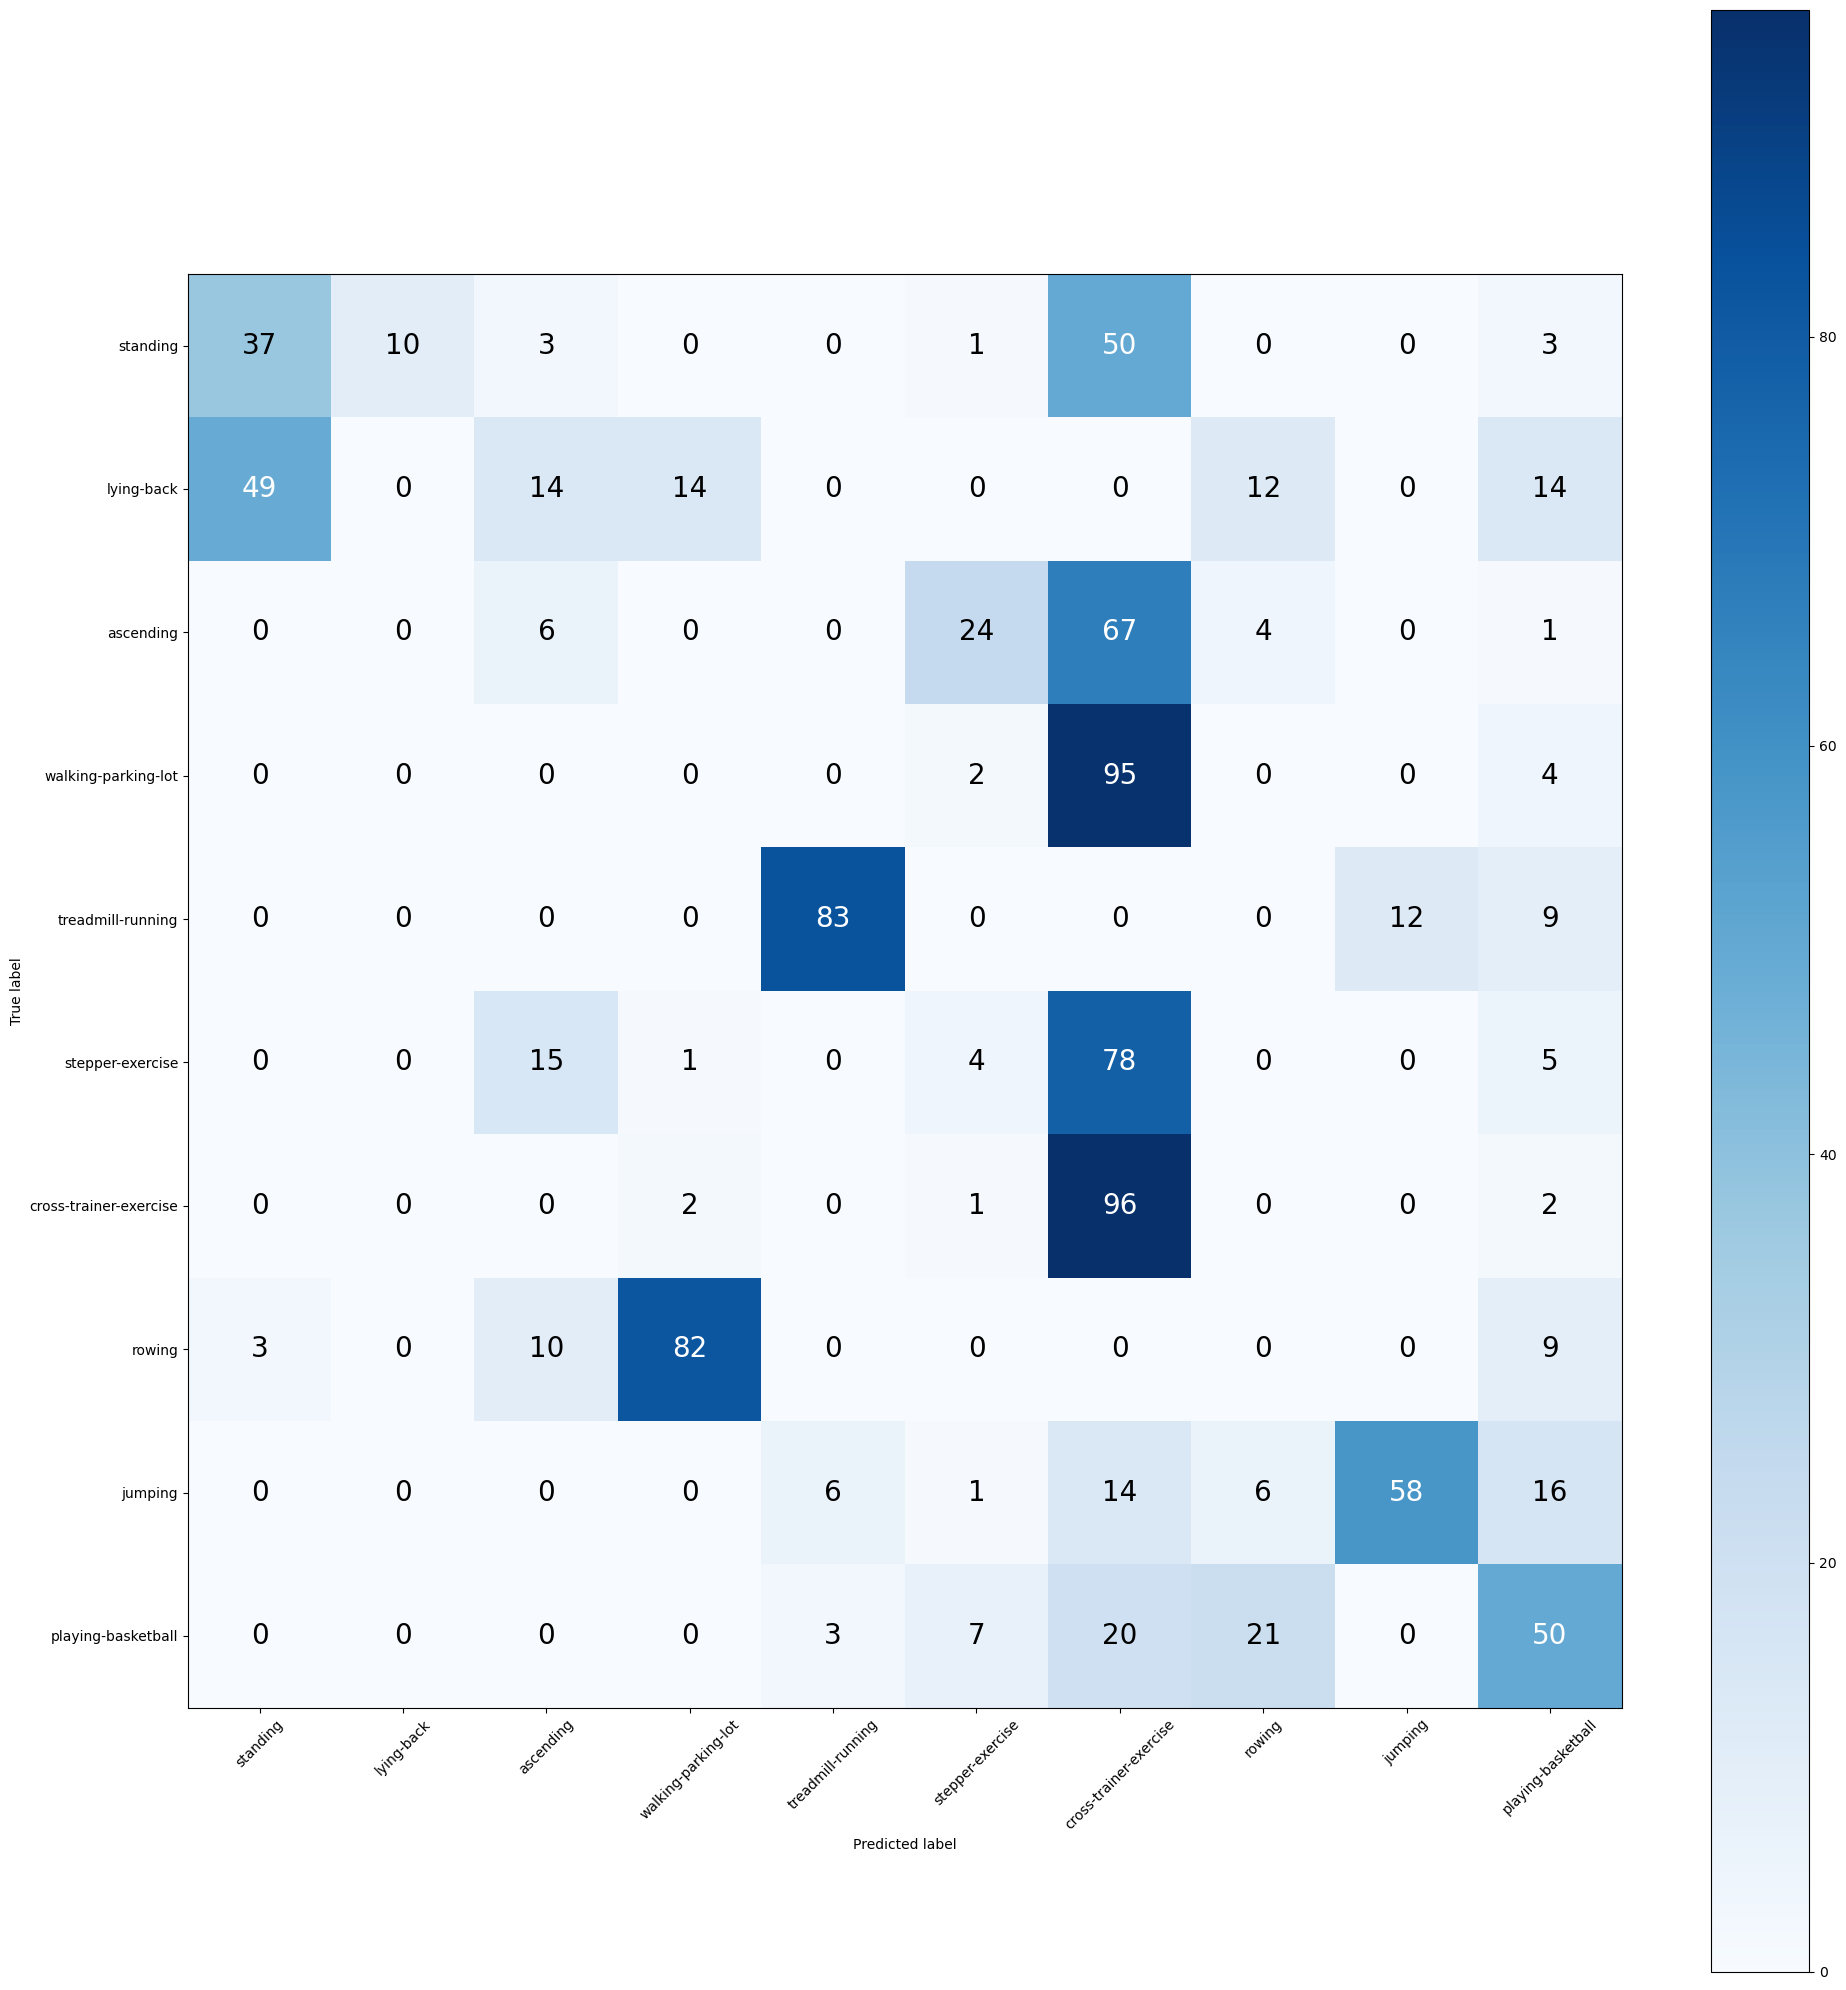

###Valid Source: Epoch: 13, avg_loss: 0.0365, Accuracy: 2720/4171 (65.21%)
###Valid Target: Epoch: 13, avg_loss: 0.0716, Accuracy: 334/1042 (32.05%)


Train Epoch: 14 [ 1/97]	Lambda: 0.7000, Class: 1.071534, CORAL: 0.073622, Total_Loss: 1.123070
Train Epoch: 14 [ 2/97]	Lambda: 0.7000, Class: 1.361204, CORAL: 0.163671, Total_Loss: 1.475773
Train Epoch: 14 [ 3/97]	Lambda: 0.7000, Class: 1.078644, CORAL: 0.325942, Total_Loss: 1.306804
Train Epoch: 14 [ 4/97]	Lambda: 0.7000, Class: 1.313037, CORAL: 0.043308, Total_Loss: 1.343352
Train Epoch: 14 [ 5/97]	Lambda: 0.7000, Class: 1.009869, CORAL: 0.120498, Total_Loss: 1.094218
Train Epoch: 14 [ 6/97]	Lambda: 0.7000, Class: 1.196557, CORAL: 0.104888, Total_Loss: 1.269979
Train Epoch: 14 [ 7/97]	Lambda: 0.7000, Class: 1.113994, CORAL: 0.157571, Total_Loss: 1.224294
Train Epoch: 14 [ 8/97]	Lambda: 0.7000, Class: 1.124819, CORAL: 0.201075, Total_Loss: 1.265571
Train Epoch: 14 [ 9/97]	Lambda: 0.7000, Class: 1.100538, CORAL: 0.132951, Total_Loss: 1.1

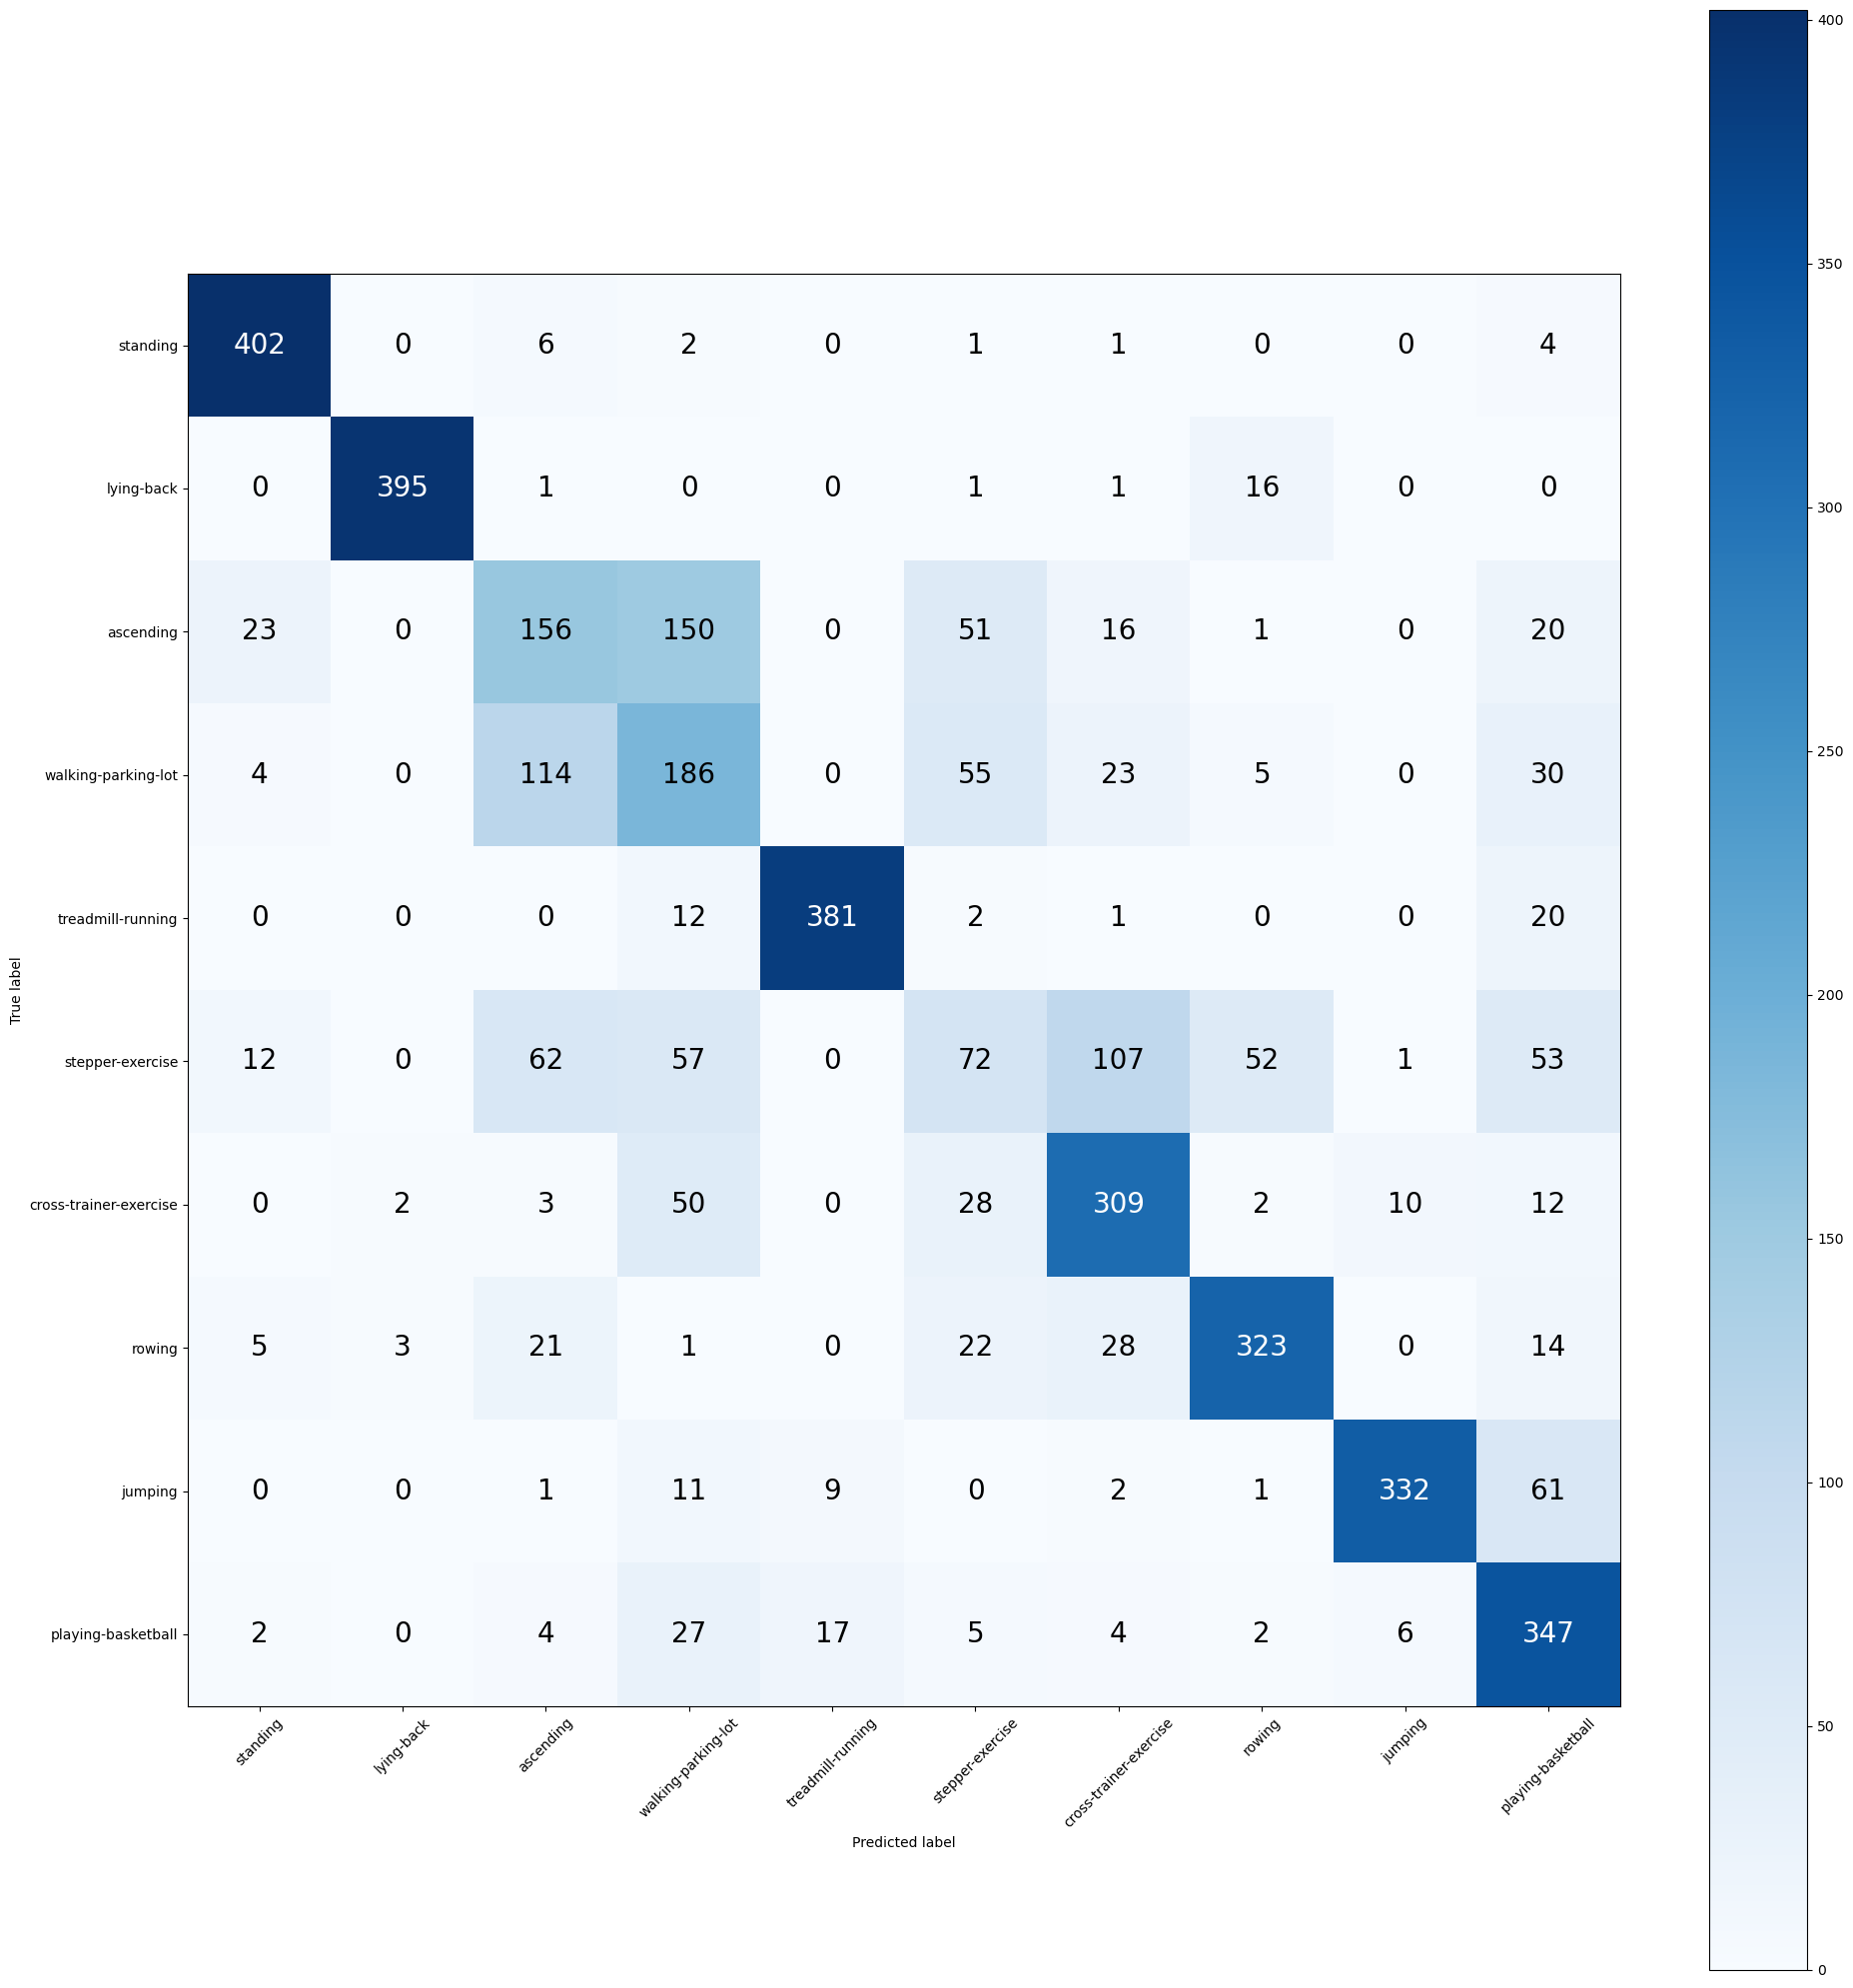

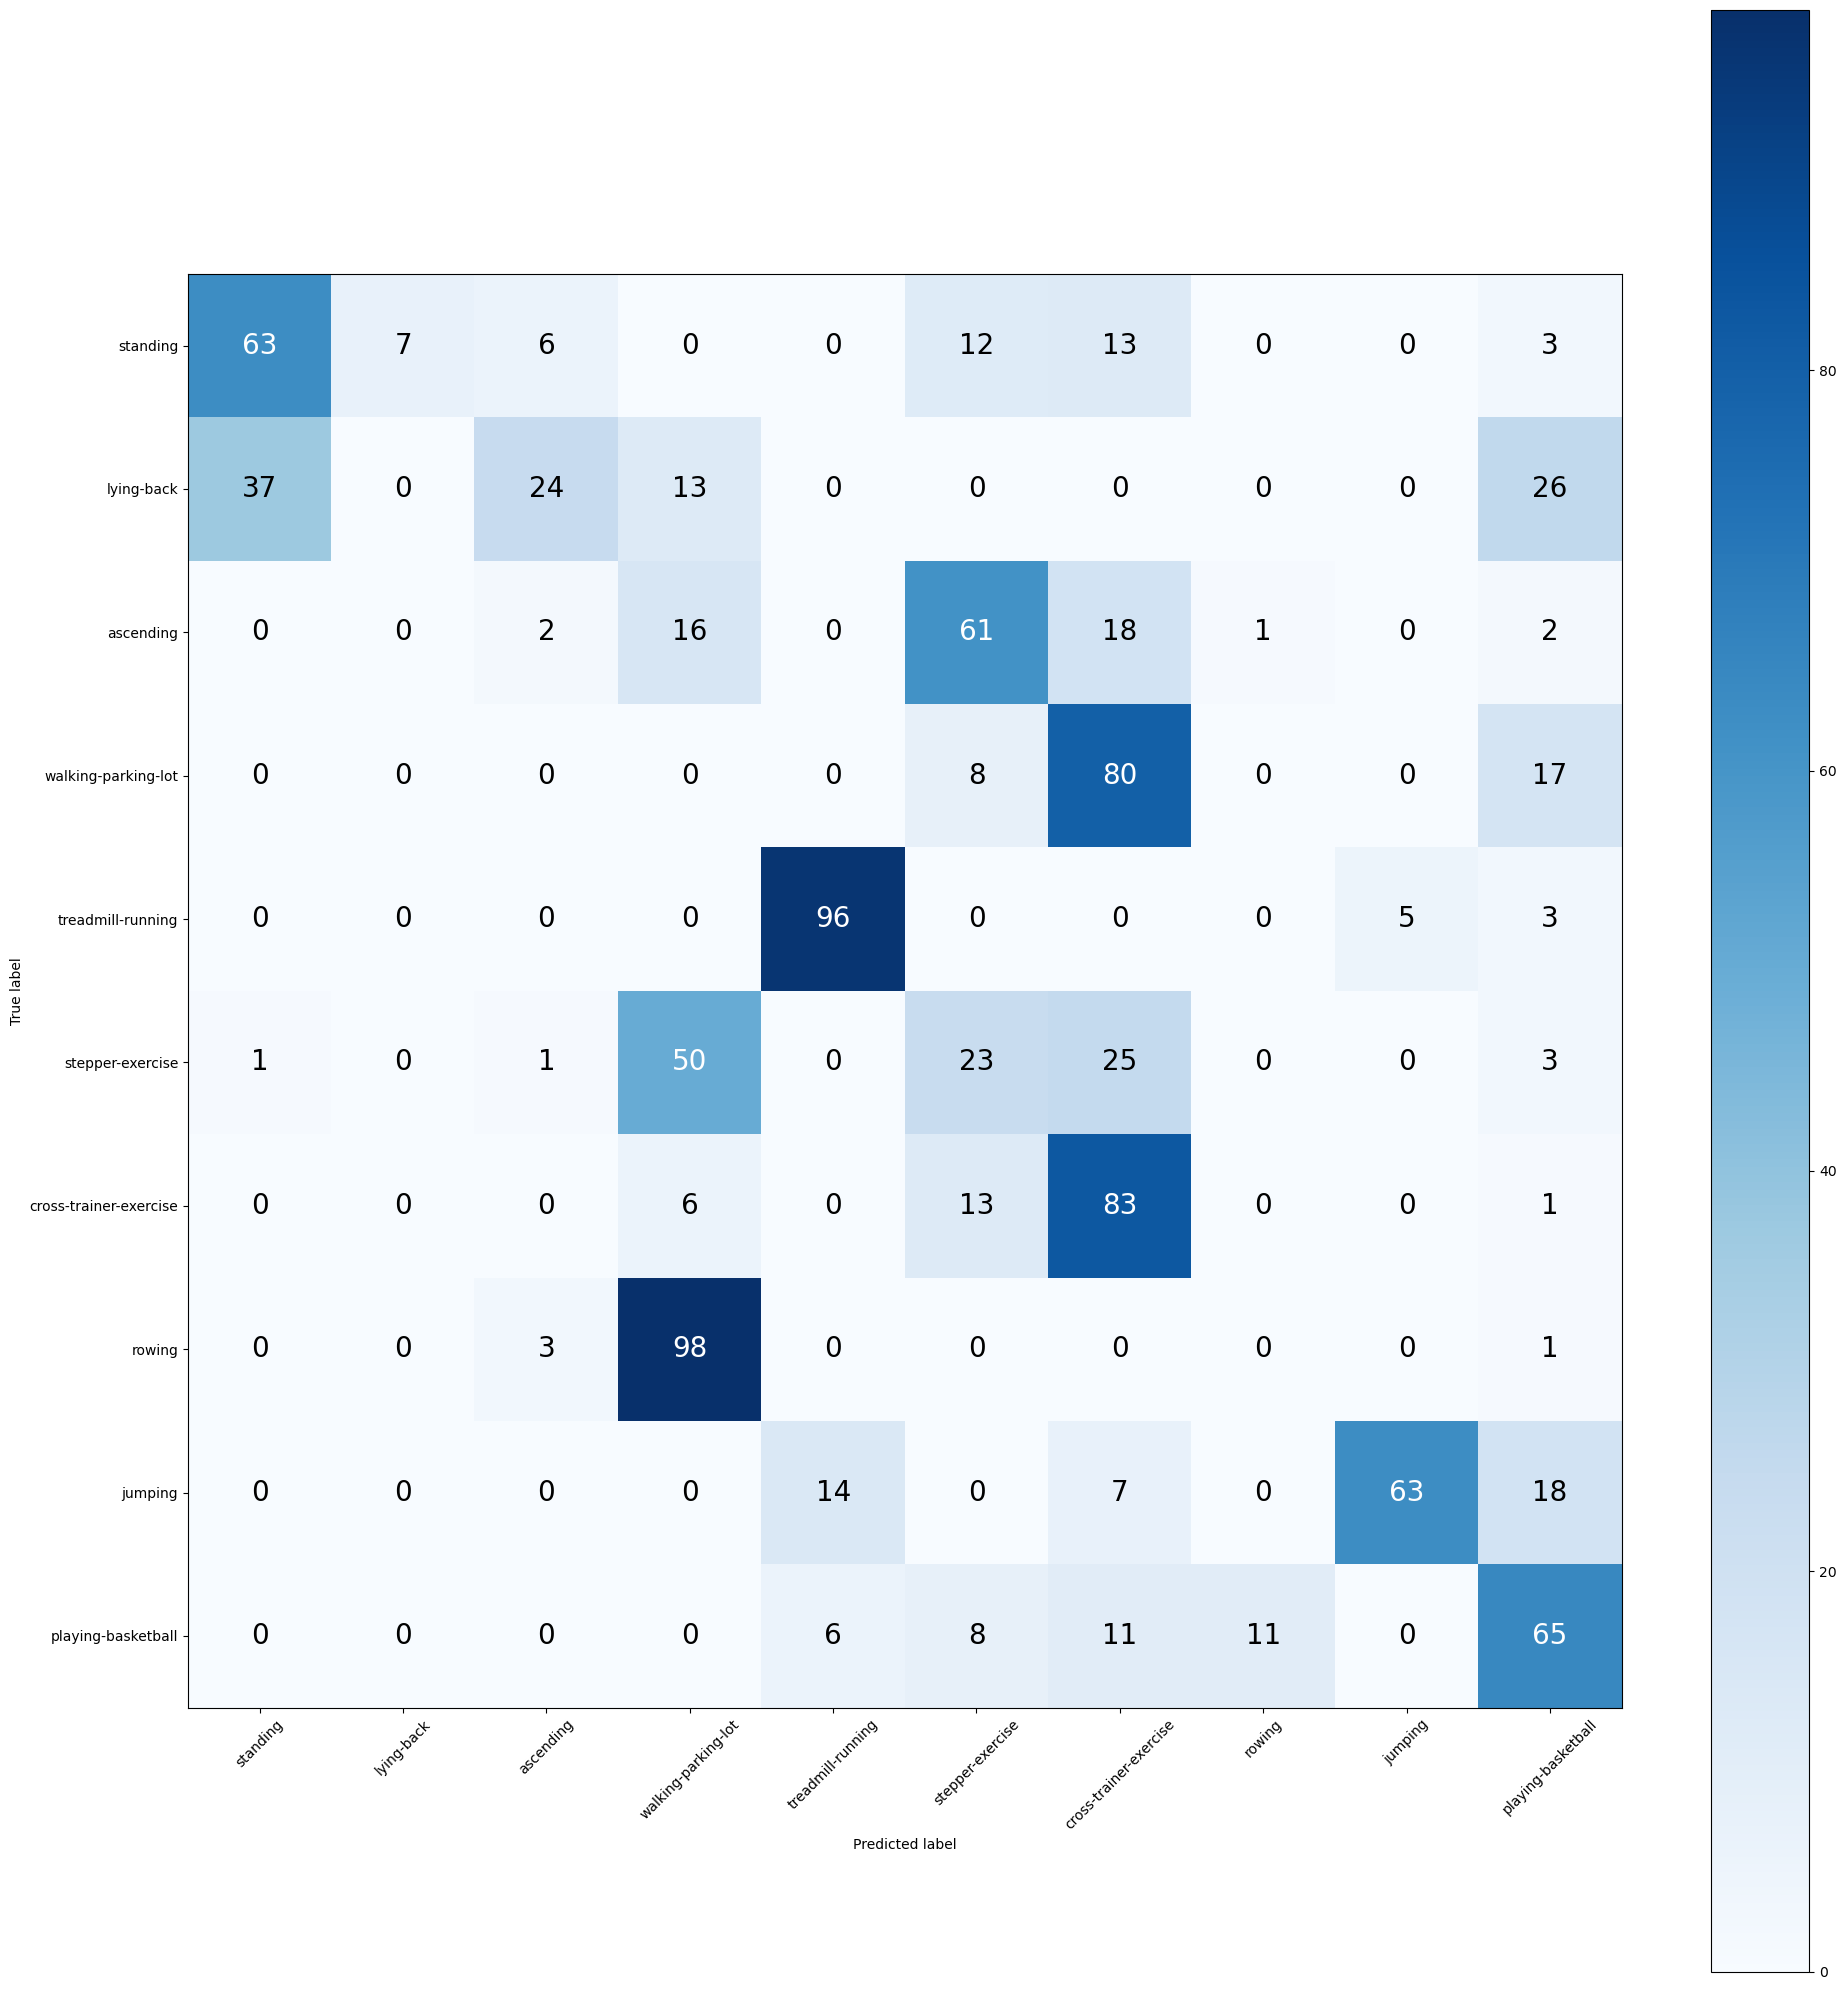

###Valid Source: Epoch: 14, avg_loss: 0.0335, Accuracy: 2903/4171 (69.60%)
###Valid Target: Epoch: 14, avg_loss: 0.0709, Accuracy: 395/1042 (37.91%)


Train Epoch: 15 [ 1/97]	Lambda: 0.7500, Class: 0.905165, CORAL: 0.324391, Total_Loss: 1.148458
Train Epoch: 15 [ 2/97]	Lambda: 0.7500, Class: 0.991336, CORAL: 0.378483, Total_Loss: 1.275199
Train Epoch: 15 [ 3/97]	Lambda: 0.7500, Class: 1.024297, CORAL: 0.098432, Total_Loss: 1.098121
Train Epoch: 15 [ 4/97]	Lambda: 0.7500, Class: 0.924097, CORAL: 0.199320, Total_Loss: 1.073588
Train Epoch: 15 [ 5/97]	Lambda: 0.7500, Class: 1.150141, CORAL: 0.143976, Total_Loss: 1.258124
Train Epoch: 15 [ 6/97]	Lambda: 0.7500, Class: 1.113251, CORAL: 0.247056, Total_Loss: 1.298543
Train Epoch: 15 [ 7/97]	Lambda: 0.7500, Class: 1.138327, CORAL: 0.131934, Total_Loss: 1.237278
Train Epoch: 15 [ 8/97]	Lambda: 0.7500, Class: 1.000701, CORAL: 0.159204, Total_Loss: 1.120103
Train Epoch: 15 [ 9/97]	Lambda: 0.7500, Class: 1.069182, CORAL: 0.148165, Total_Loss: 1.1

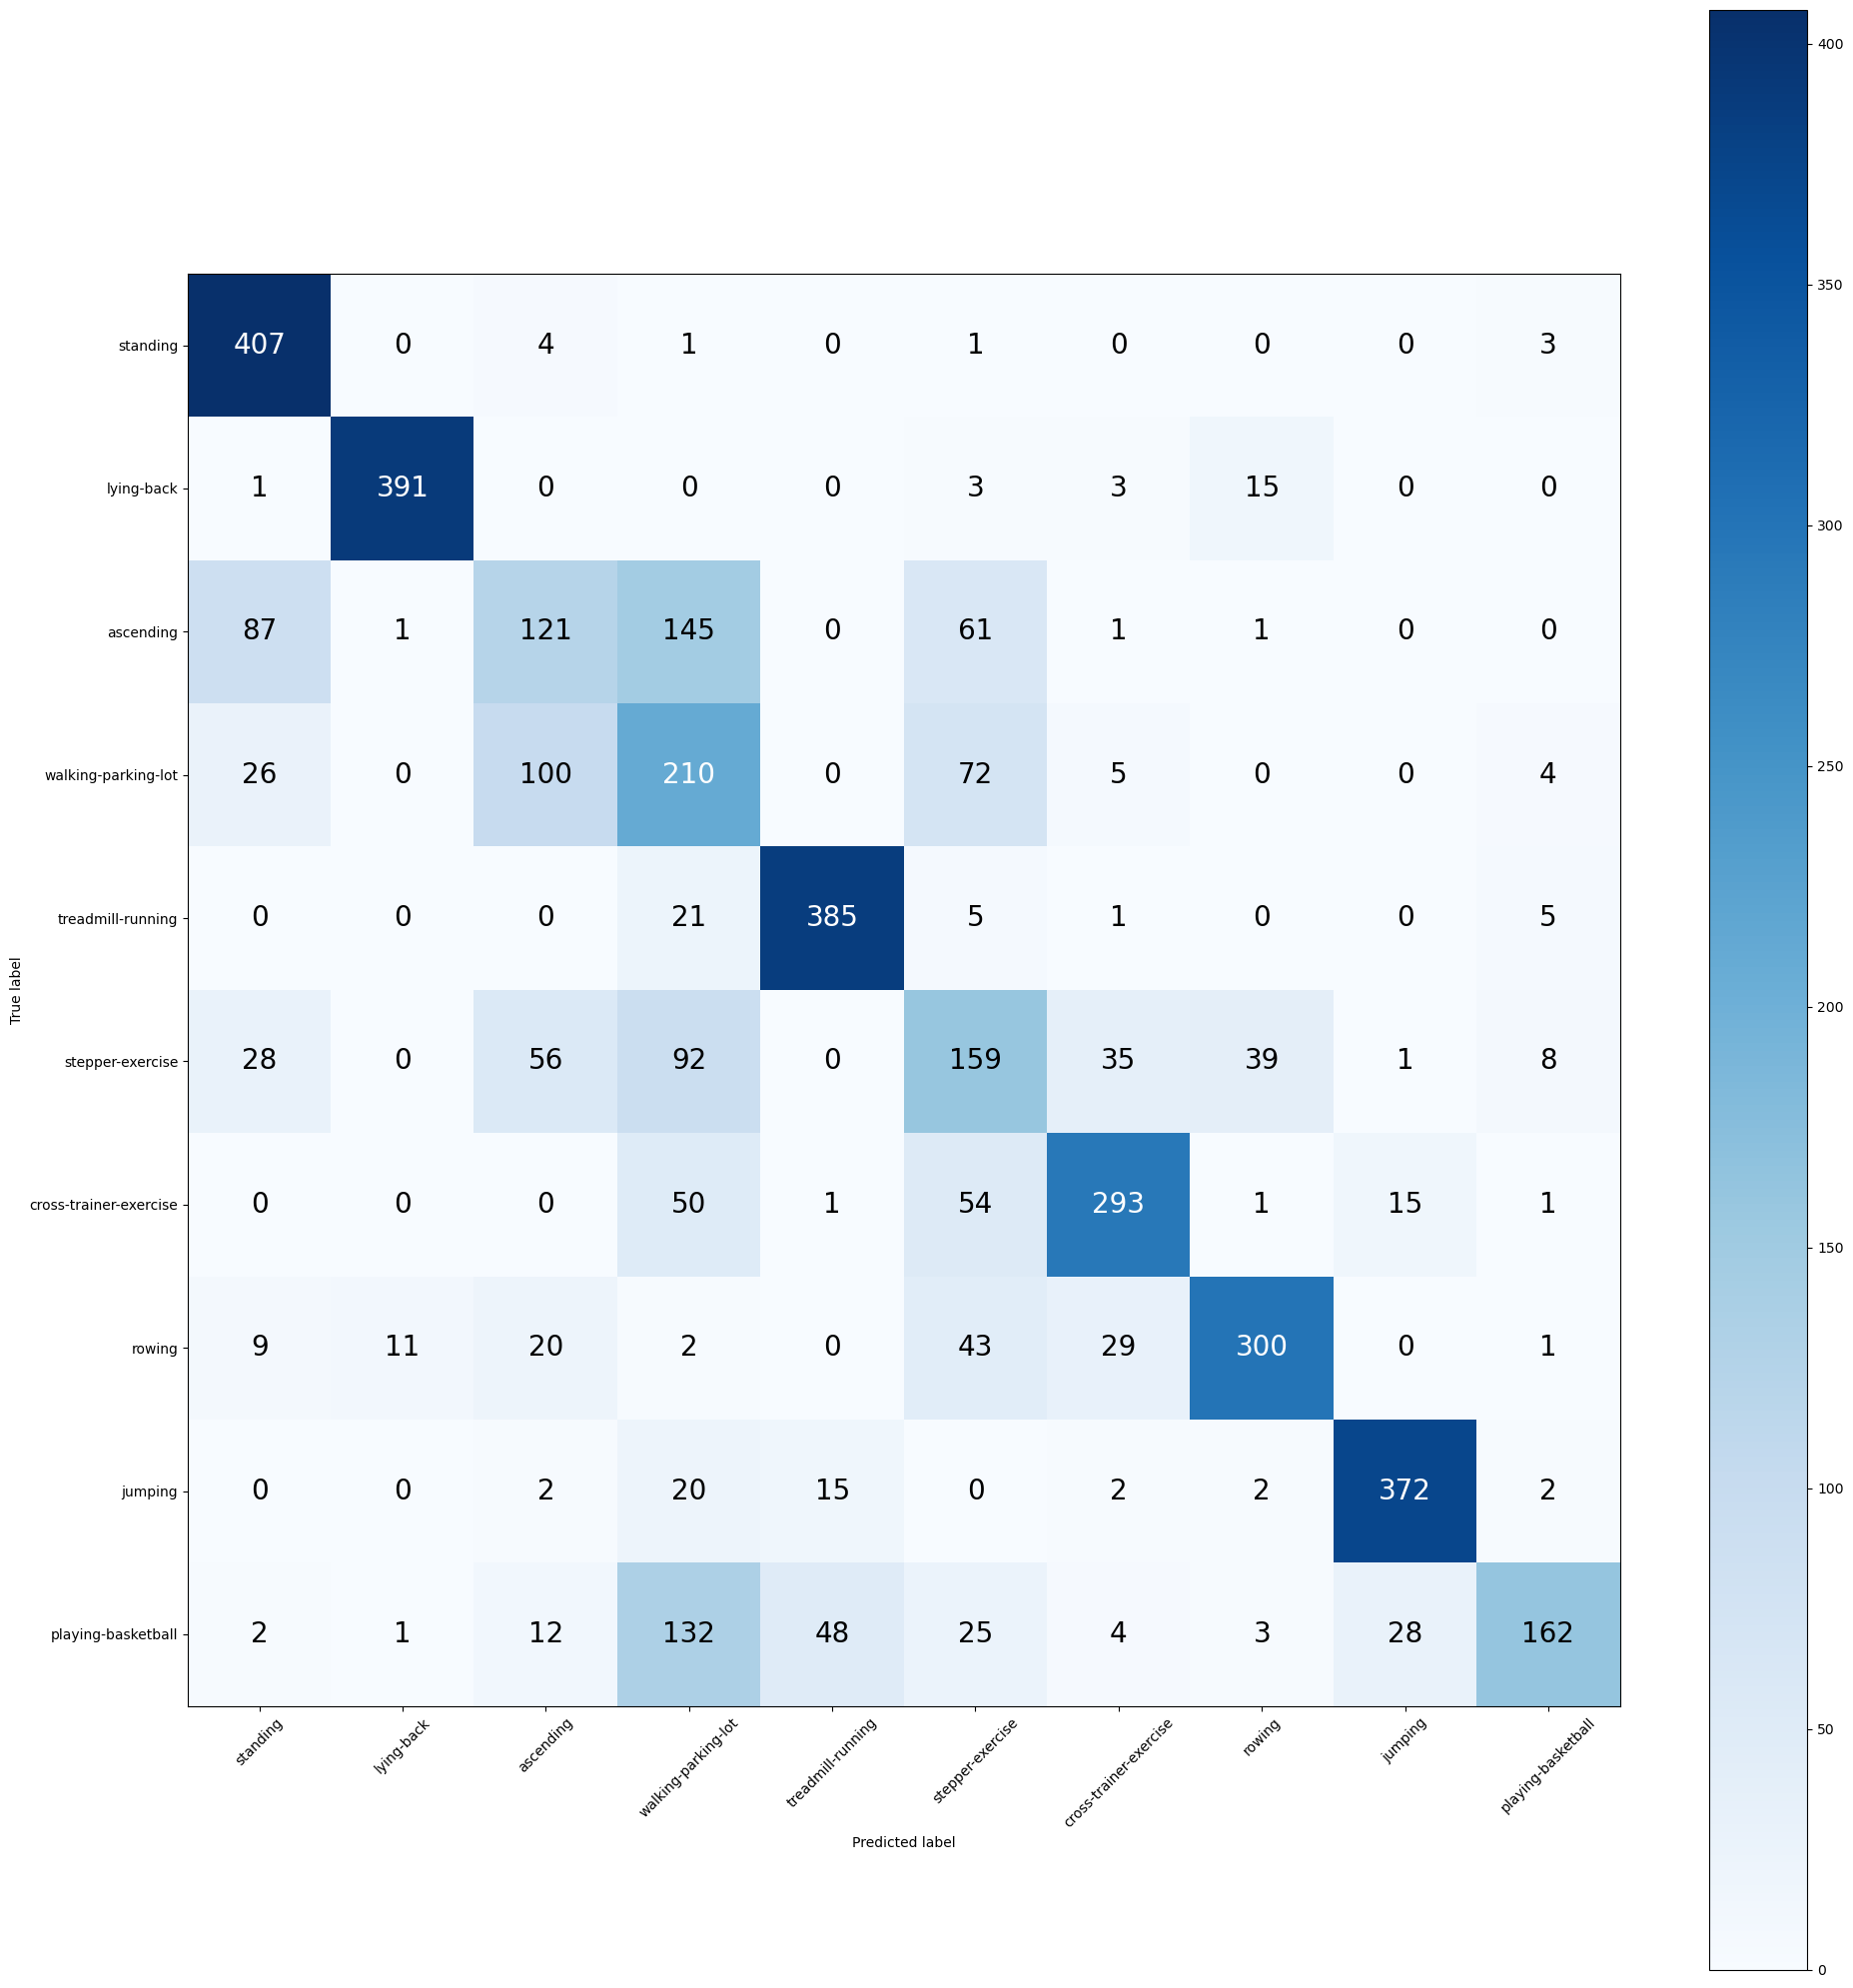

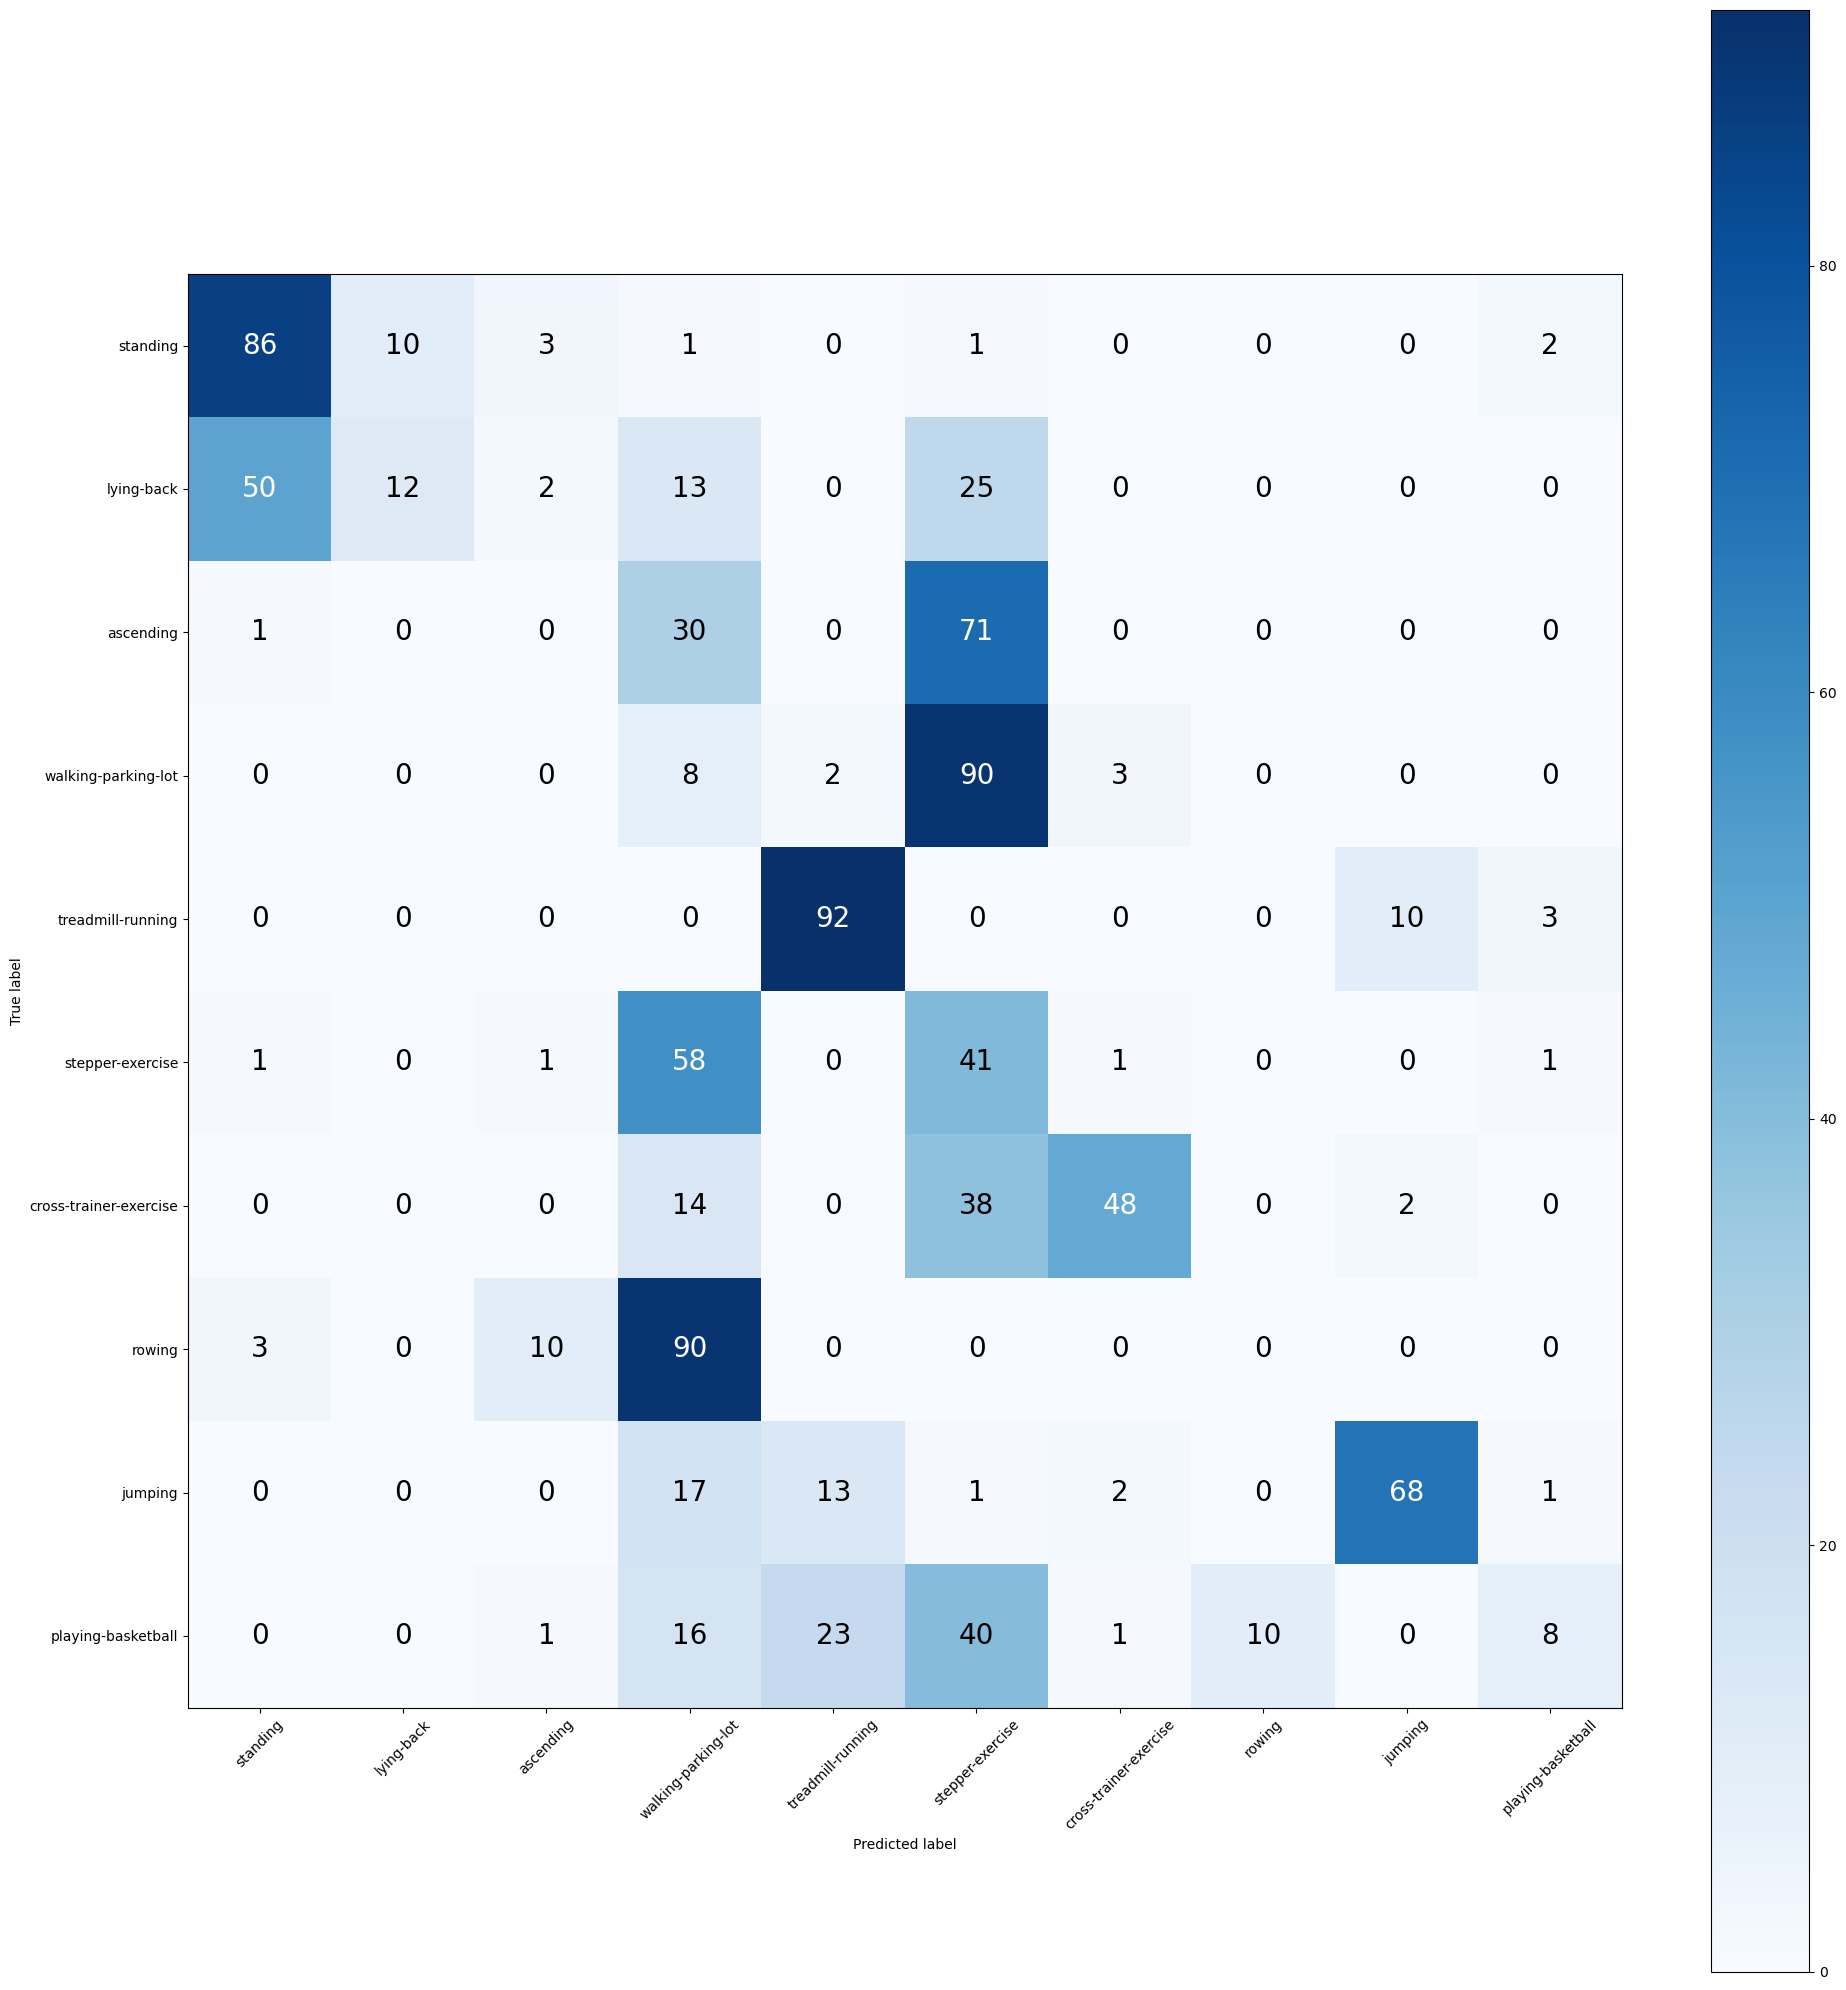

###Valid Source: Epoch: 15, avg_loss: 0.0353, Accuracy: 2800/4171 (67.13%)
###Valid Target: Epoch: 15, avg_loss: 0.0680, Accuracy: 363/1042 (34.84%)


Train Epoch: 16 [ 1/97]	Lambda: 0.8000, Class: 0.927118, CORAL: 0.088437, Total_Loss: 0.997868
Train Epoch: 16 [ 2/97]	Lambda: 0.8000, Class: 1.094112, CORAL: 0.090798, Total_Loss: 1.166751
Train Epoch: 16 [ 3/97]	Lambda: 0.8000, Class: 1.263969, CORAL: 0.070699, Total_Loss: 1.320529
Train Epoch: 16 [ 4/97]	Lambda: 0.8000, Class: 0.919545, CORAL: 0.336955, Total_Loss: 1.189109
Train Epoch: 16 [ 5/97]	Lambda: 0.8000, Class: 1.008934, CORAL: 0.077796, Total_Loss: 1.071171
Train Epoch: 16 [ 6/97]	Lambda: 0.8000, Class: 1.099084, CORAL: 0.088458, Total_Loss: 1.169850
Train Epoch: 16 [ 7/97]	Lambda: 0.8000, Class: 1.185183, CORAL: 0.118581, Total_Loss: 1.280048
Train Epoch: 16 [ 8/97]	Lambda: 0.8000, Class: 0.891711, CORAL: 0.140685, Total_Loss: 1.004258
Train Epoch: 16 [ 9/97]	Lambda: 0.8000, Class: 0.906879, CORAL: 0.120994, Total_Loss: 1.0

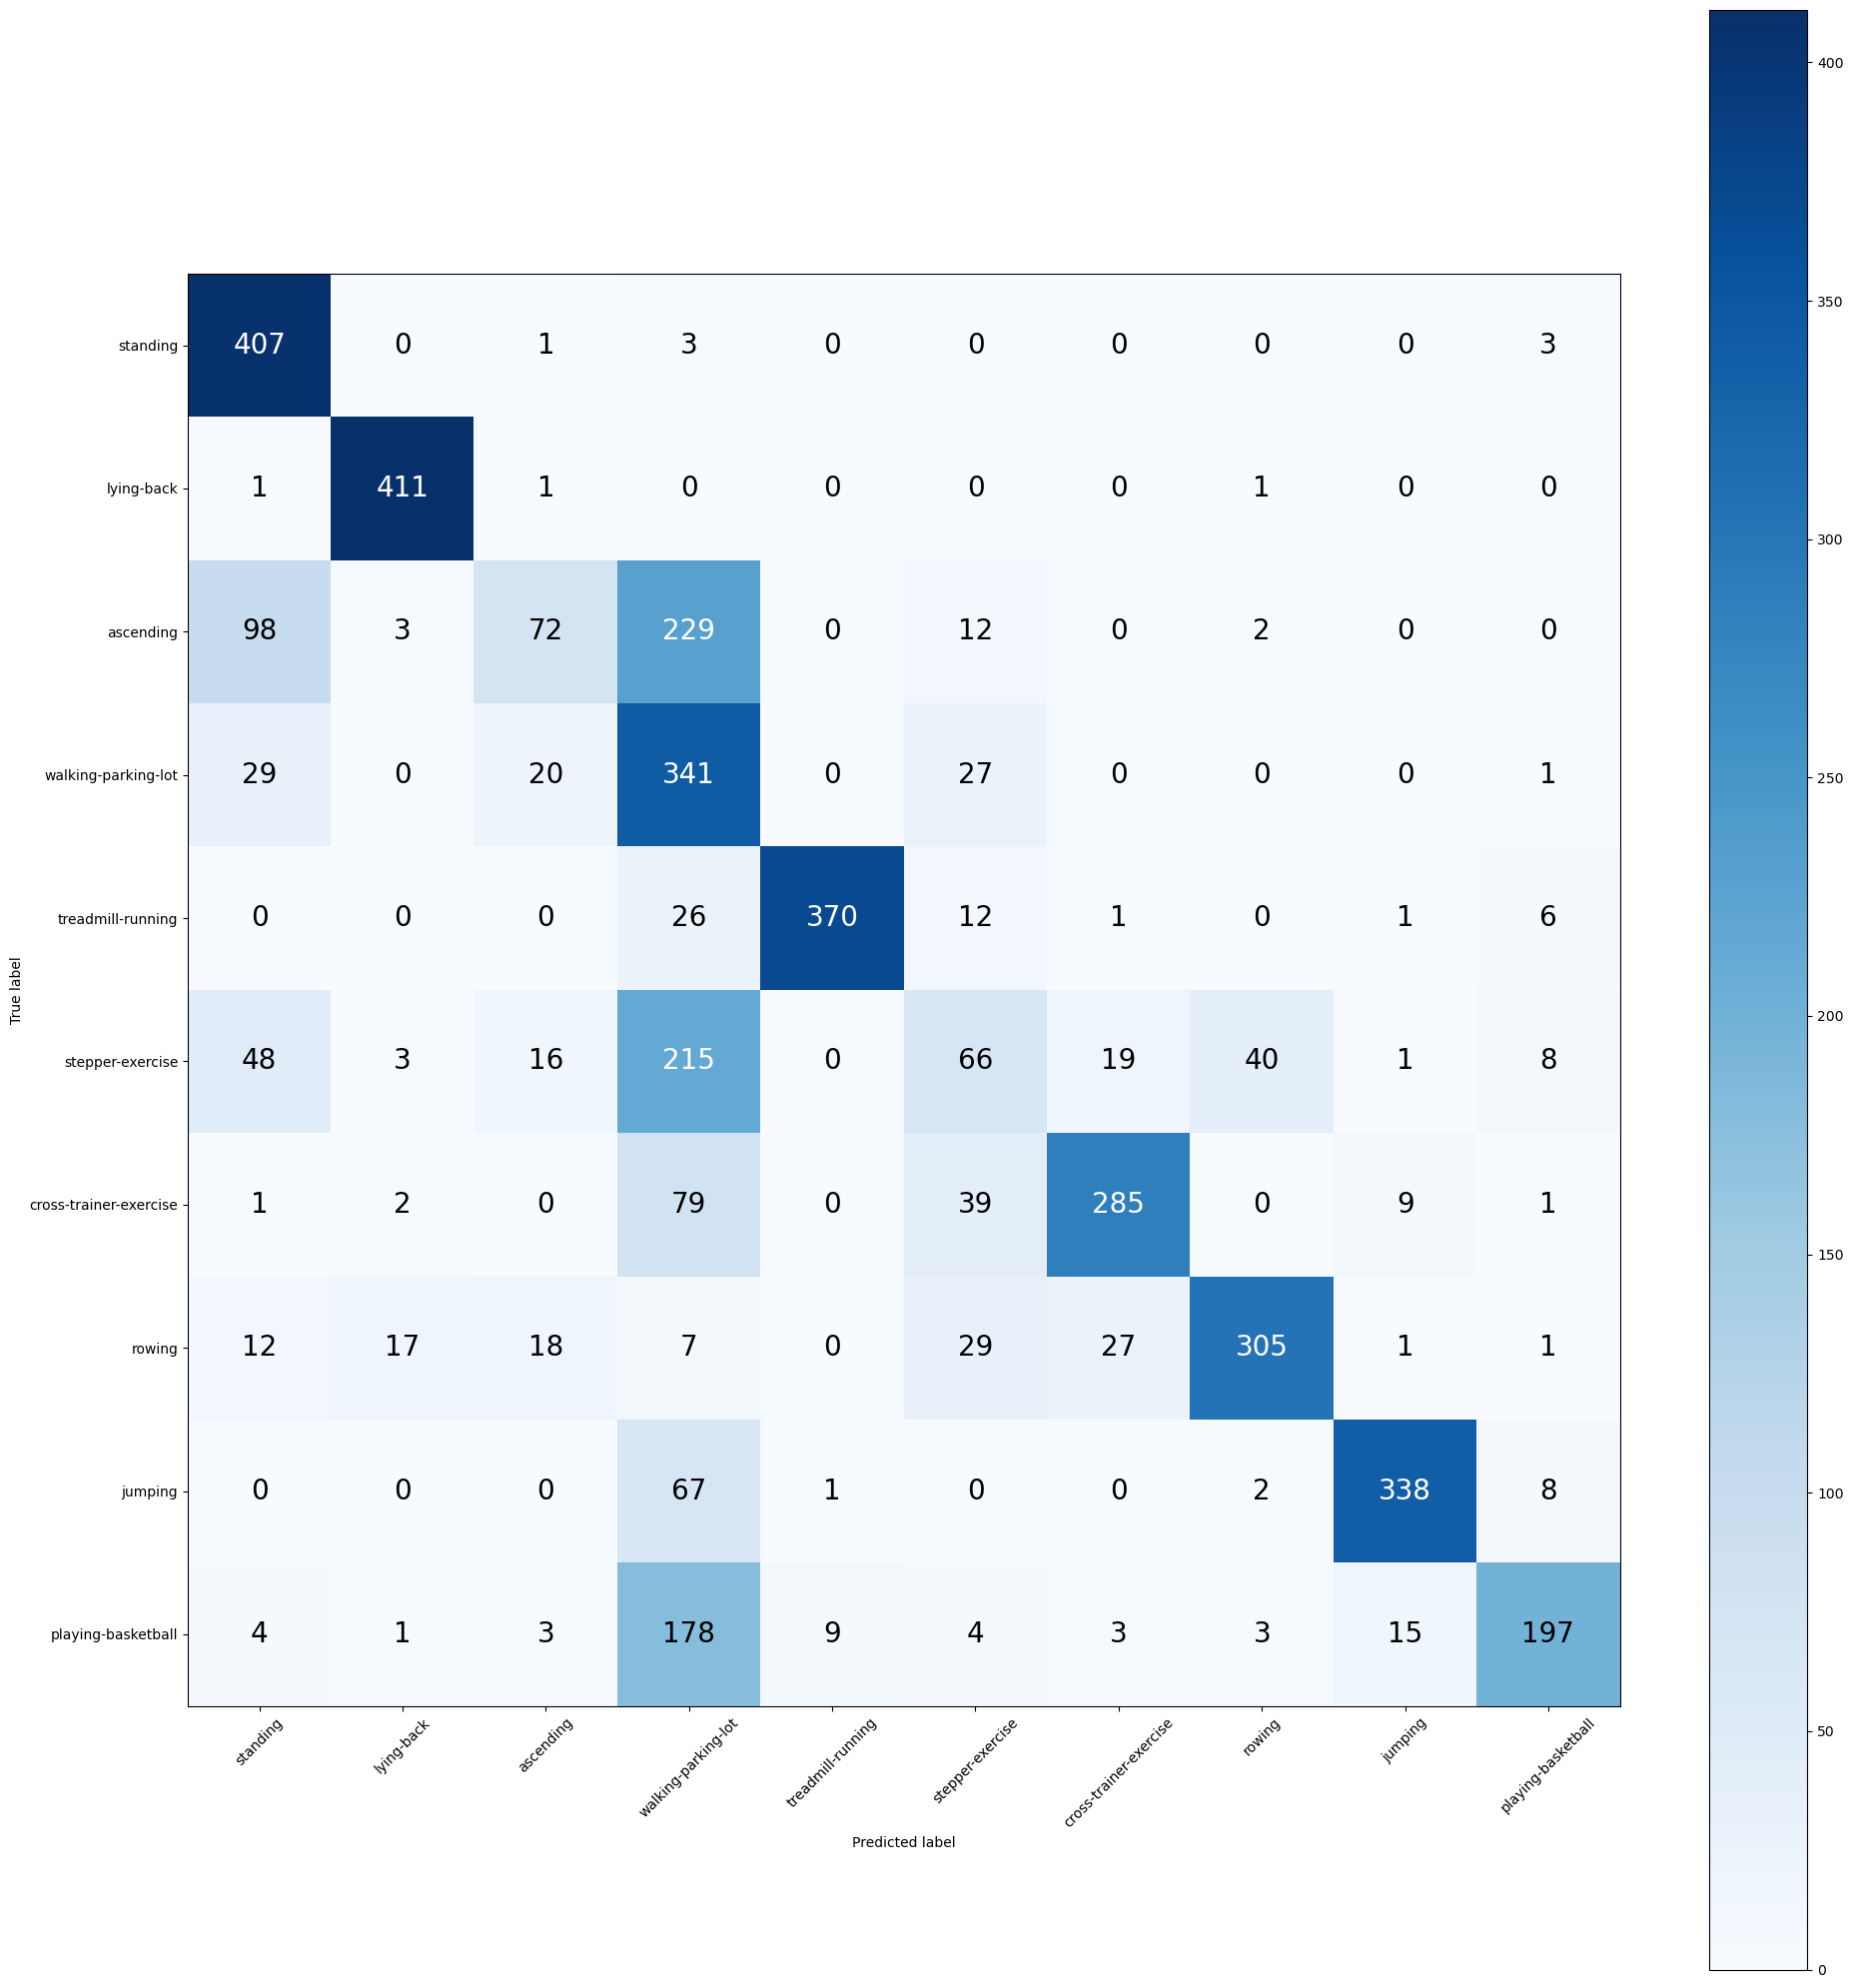

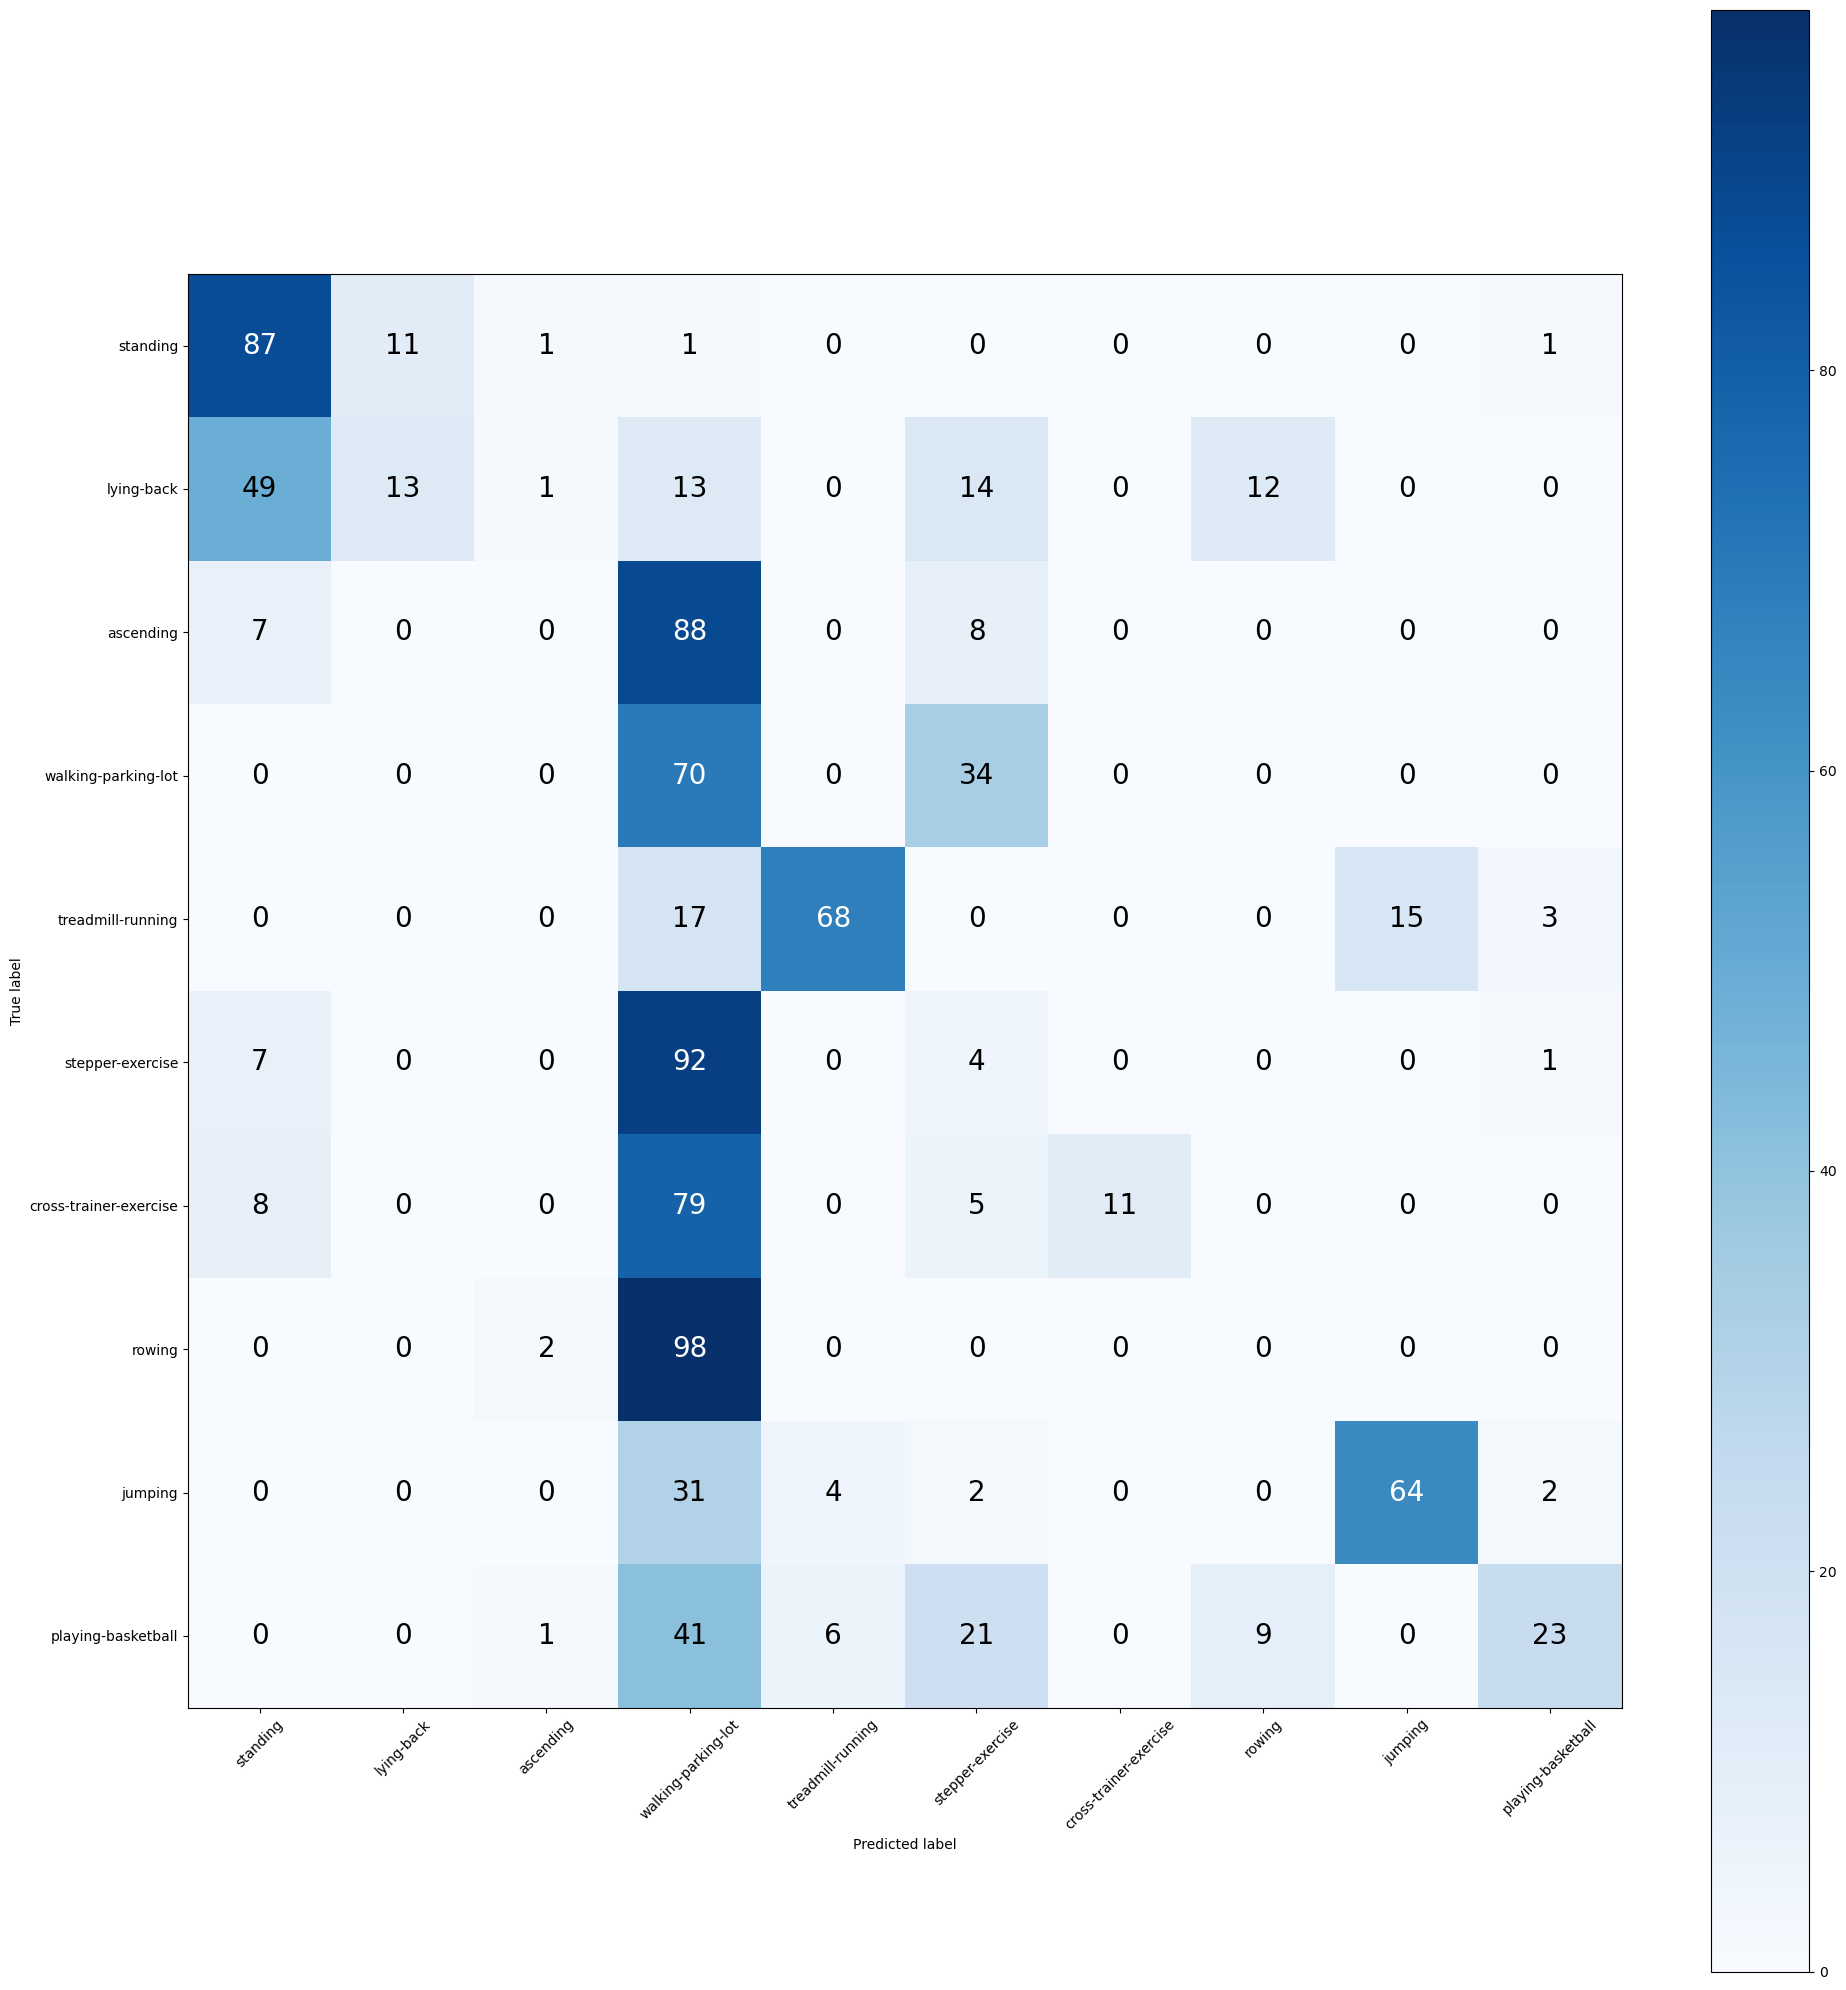

###Valid Source: Epoch: 16, avg_loss: 0.0338, Accuracy: 2792/4171 (66.94%)
###Valid Target: Epoch: 16, avg_loss: 0.0638, Accuracy: 340/1042 (32.63%)


Train Epoch: 17 [ 1/97]	Lambda: 0.8500, Class: 1.217478, CORAL: 0.092164, Total_Loss: 1.295817
Train Epoch: 17 [ 2/97]	Lambda: 0.8500, Class: 0.855370, CORAL: 0.238591, Total_Loss: 1.058172
Train Epoch: 17 [ 3/97]	Lambda: 0.8500, Class: 1.037550, CORAL: 0.087088, Total_Loss: 1.111575
Train Epoch: 17 [ 4/97]	Lambda: 0.8500, Class: 0.969635, CORAL: 0.100997, Total_Loss: 1.055483
Train Epoch: 17 [ 5/97]	Lambda: 0.8500, Class: 1.131396, CORAL: 0.122074, Total_Loss: 1.235159
Train Epoch: 17 [ 6/97]	Lambda: 0.8500, Class: 0.941624, CORAL: 0.173546, Total_Loss: 1.089138
Train Epoch: 17 [ 7/97]	Lambda: 0.8500, Class: 0.862158, CORAL: 0.087783, Total_Loss: 0.936773
Train Epoch: 17 [ 8/97]	Lambda: 0.8500, Class: 0.729656, CORAL: 0.301033, Total_Loss: 0.985534
Train Epoch: 17 [ 9/97]	Lambda: 0.8500, Class: 0.939822, CORAL: 0.142132, Total_Loss: 1.0

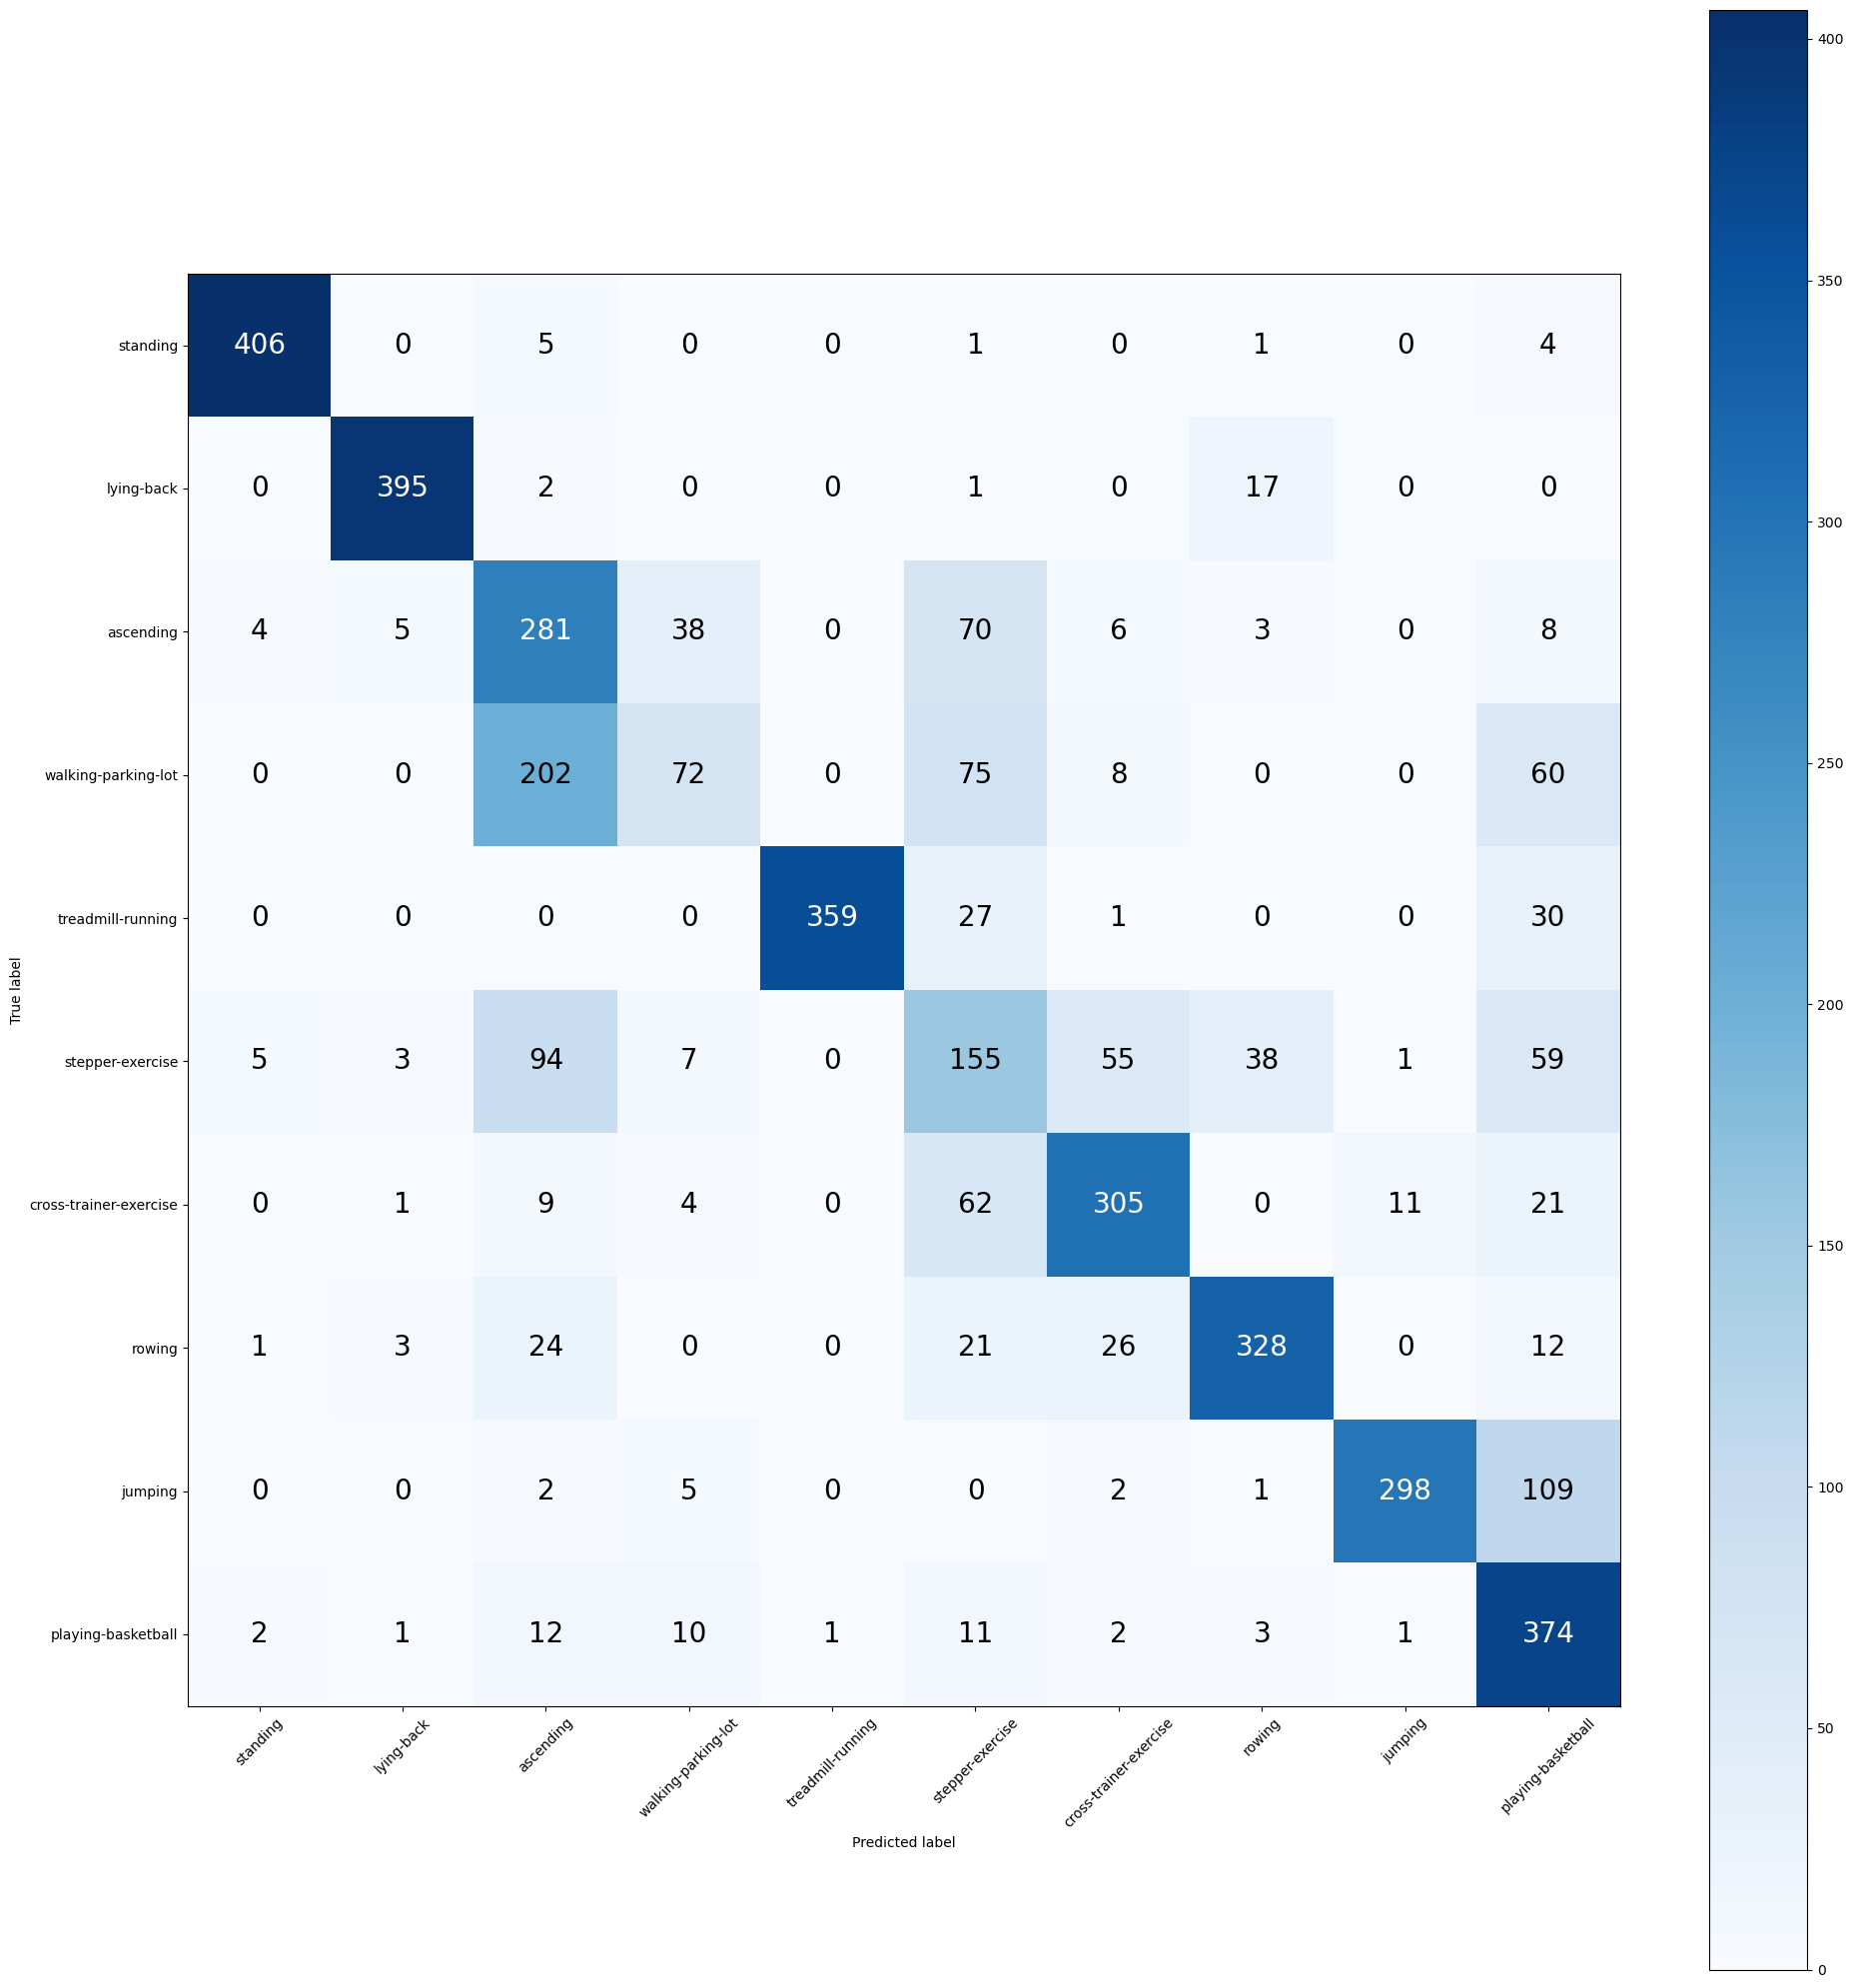

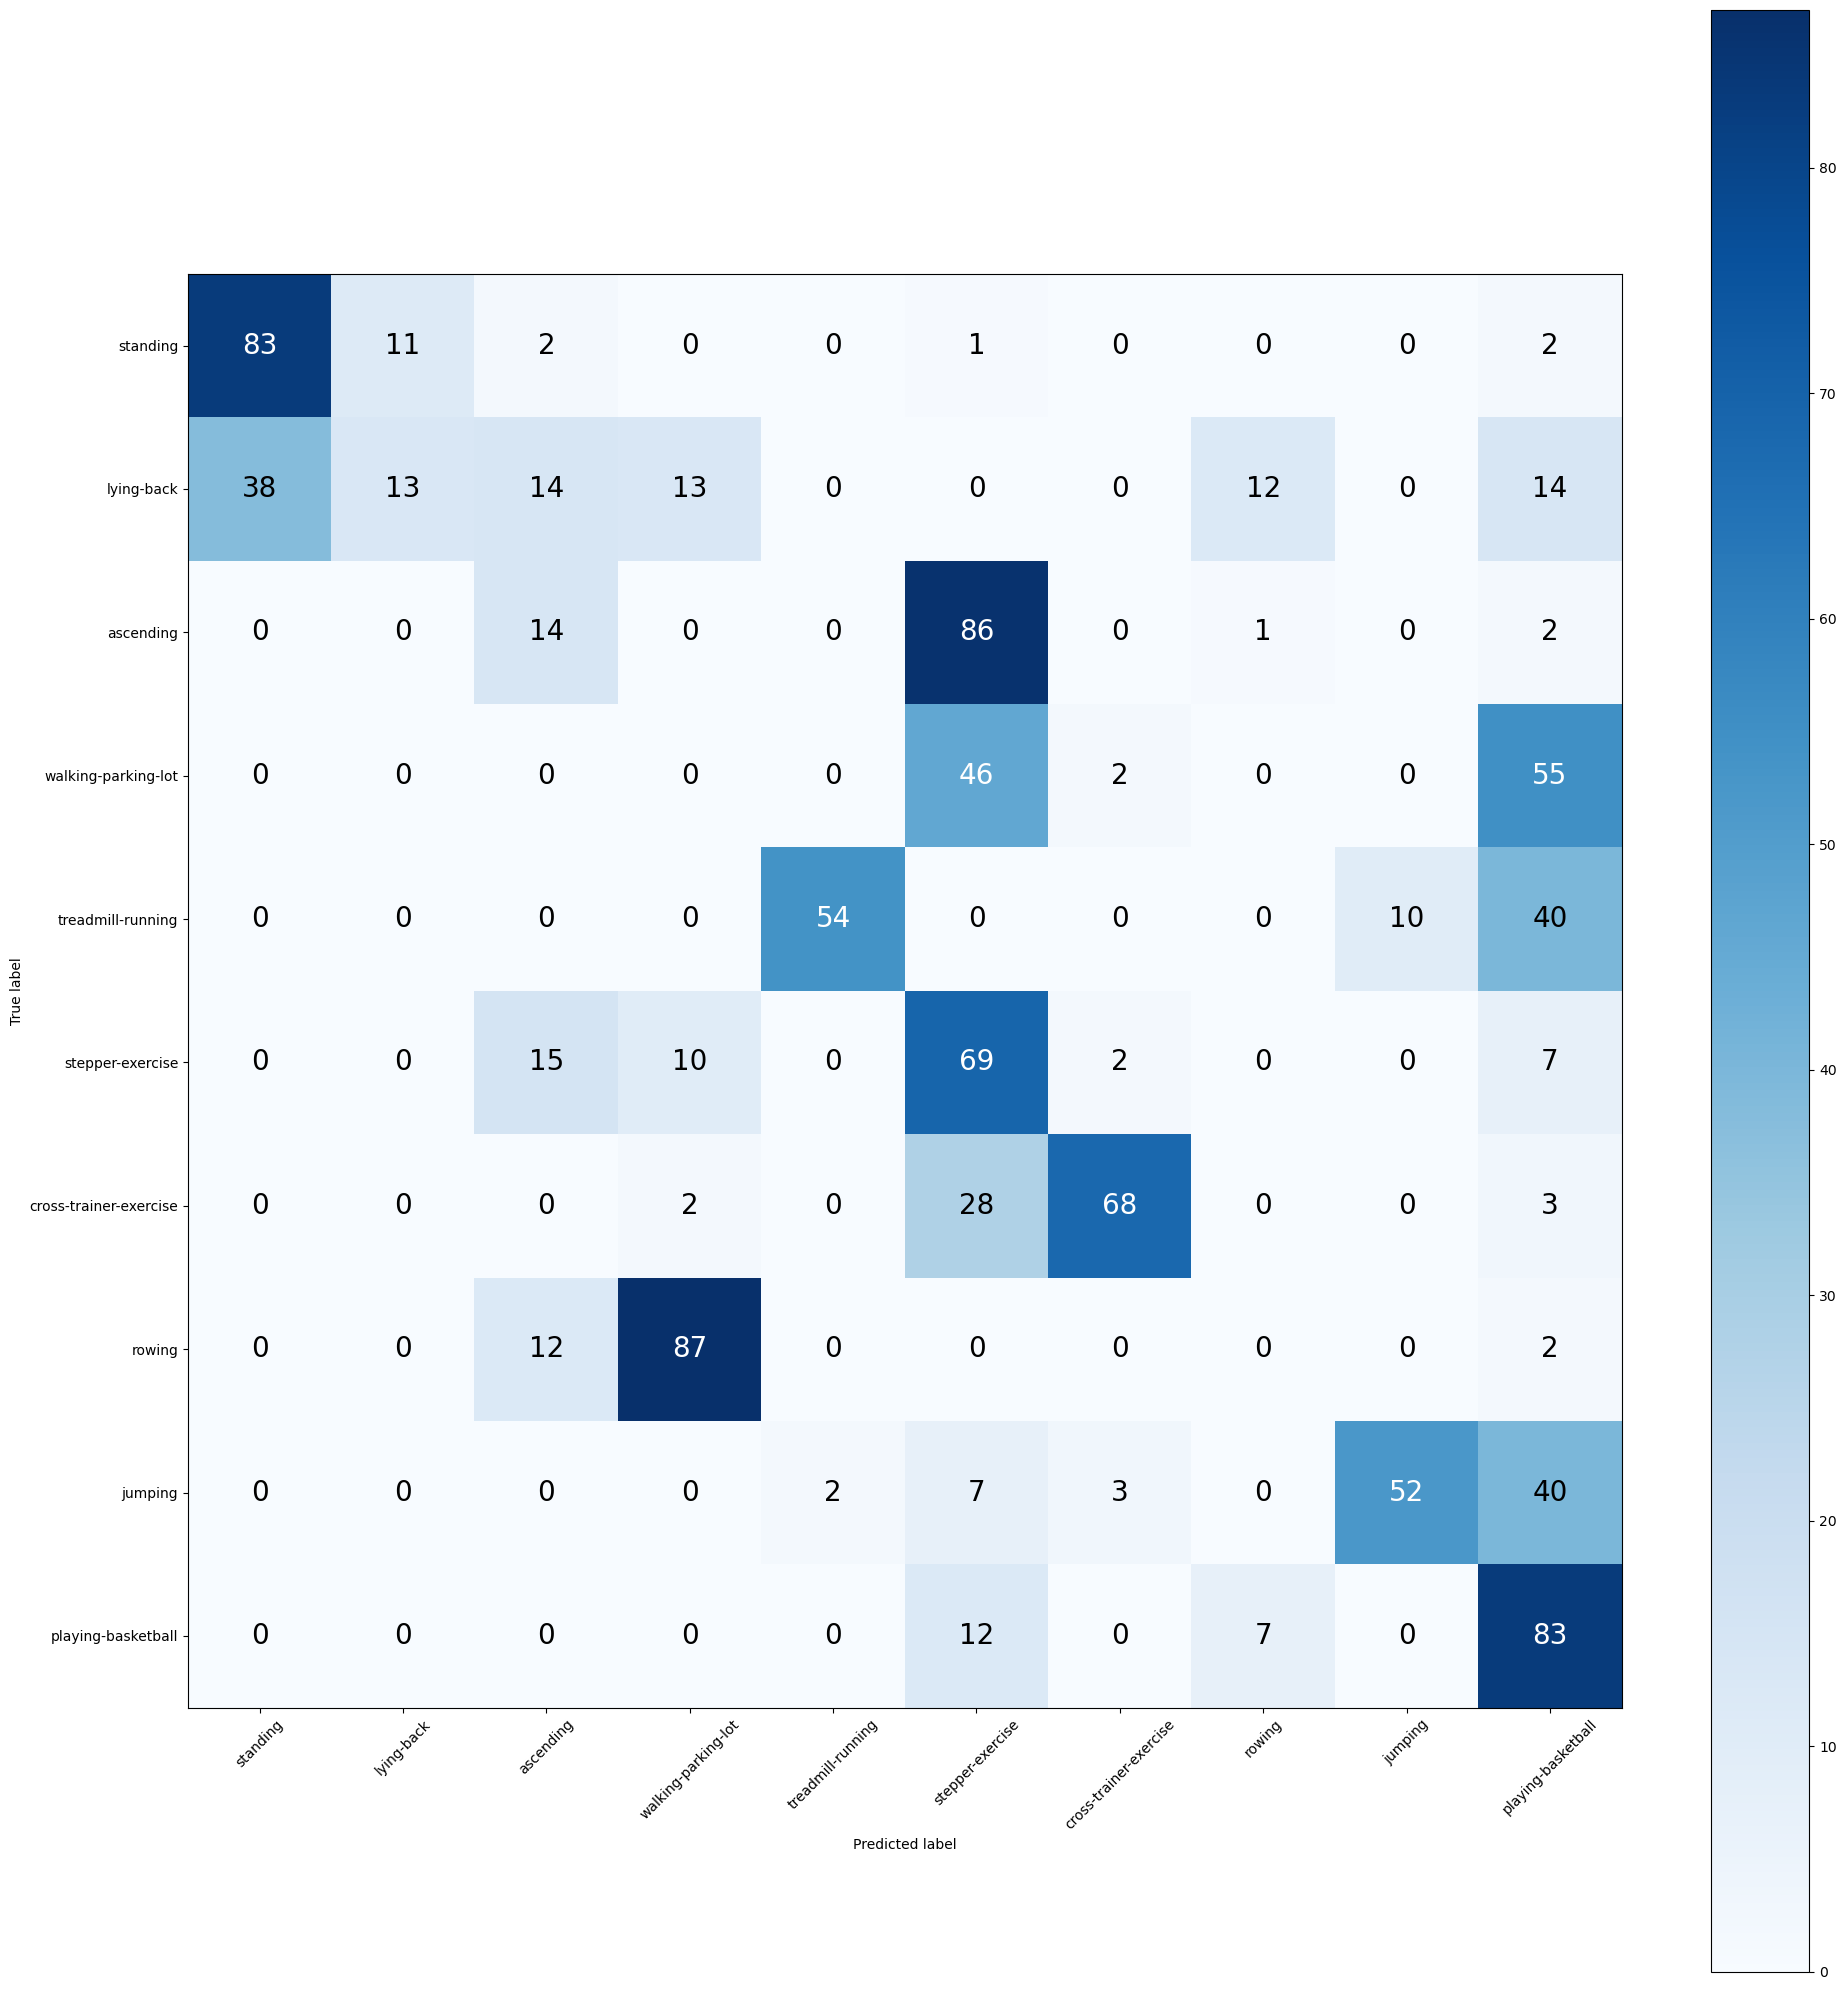

###Valid Source: Epoch: 17, avg_loss: 0.0310, Accuracy: 2973/4171 (71.28%)
###Valid Target: Epoch: 17, avg_loss: 0.0640, Accuracy: 436/1042 (41.84%)


Train Epoch: 18 [ 1/97]	Lambda: 0.9000, Class: 1.341918, CORAL: 0.060584, Total_Loss: 1.396444
Train Epoch: 18 [ 2/97]	Lambda: 0.9000, Class: 1.056860, CORAL: 0.129072, Total_Loss: 1.173025
Train Epoch: 18 [ 3/97]	Lambda: 0.9000, Class: 1.021928, CORAL: 0.084374, Total_Loss: 1.097864
Train Epoch: 18 [ 4/97]	Lambda: 0.9000, Class: 0.952091, CORAL: 0.099322, Total_Loss: 1.041480
Train Epoch: 18 [ 5/97]	Lambda: 0.9000, Class: 0.961711, CORAL: 0.157849, Total_Loss: 1.103775
Train Epoch: 18 [ 6/97]	Lambda: 0.9000, Class: 1.014894, CORAL: 0.212231, Total_Loss: 1.205902
Train Epoch: 18 [ 7/97]	Lambda: 0.9000, Class: 0.990331, CORAL: 0.139380, Total_Loss: 1.115773
Train Epoch: 18 [ 8/97]	Lambda: 0.9000, Class: 0.869018, CORAL: 0.116739, Total_Loss: 0.974083
Train Epoch: 18 [ 9/97]	Lambda: 0.9000, Class: 0.924050, CORAL: 0.214088, Total_Loss: 1.1

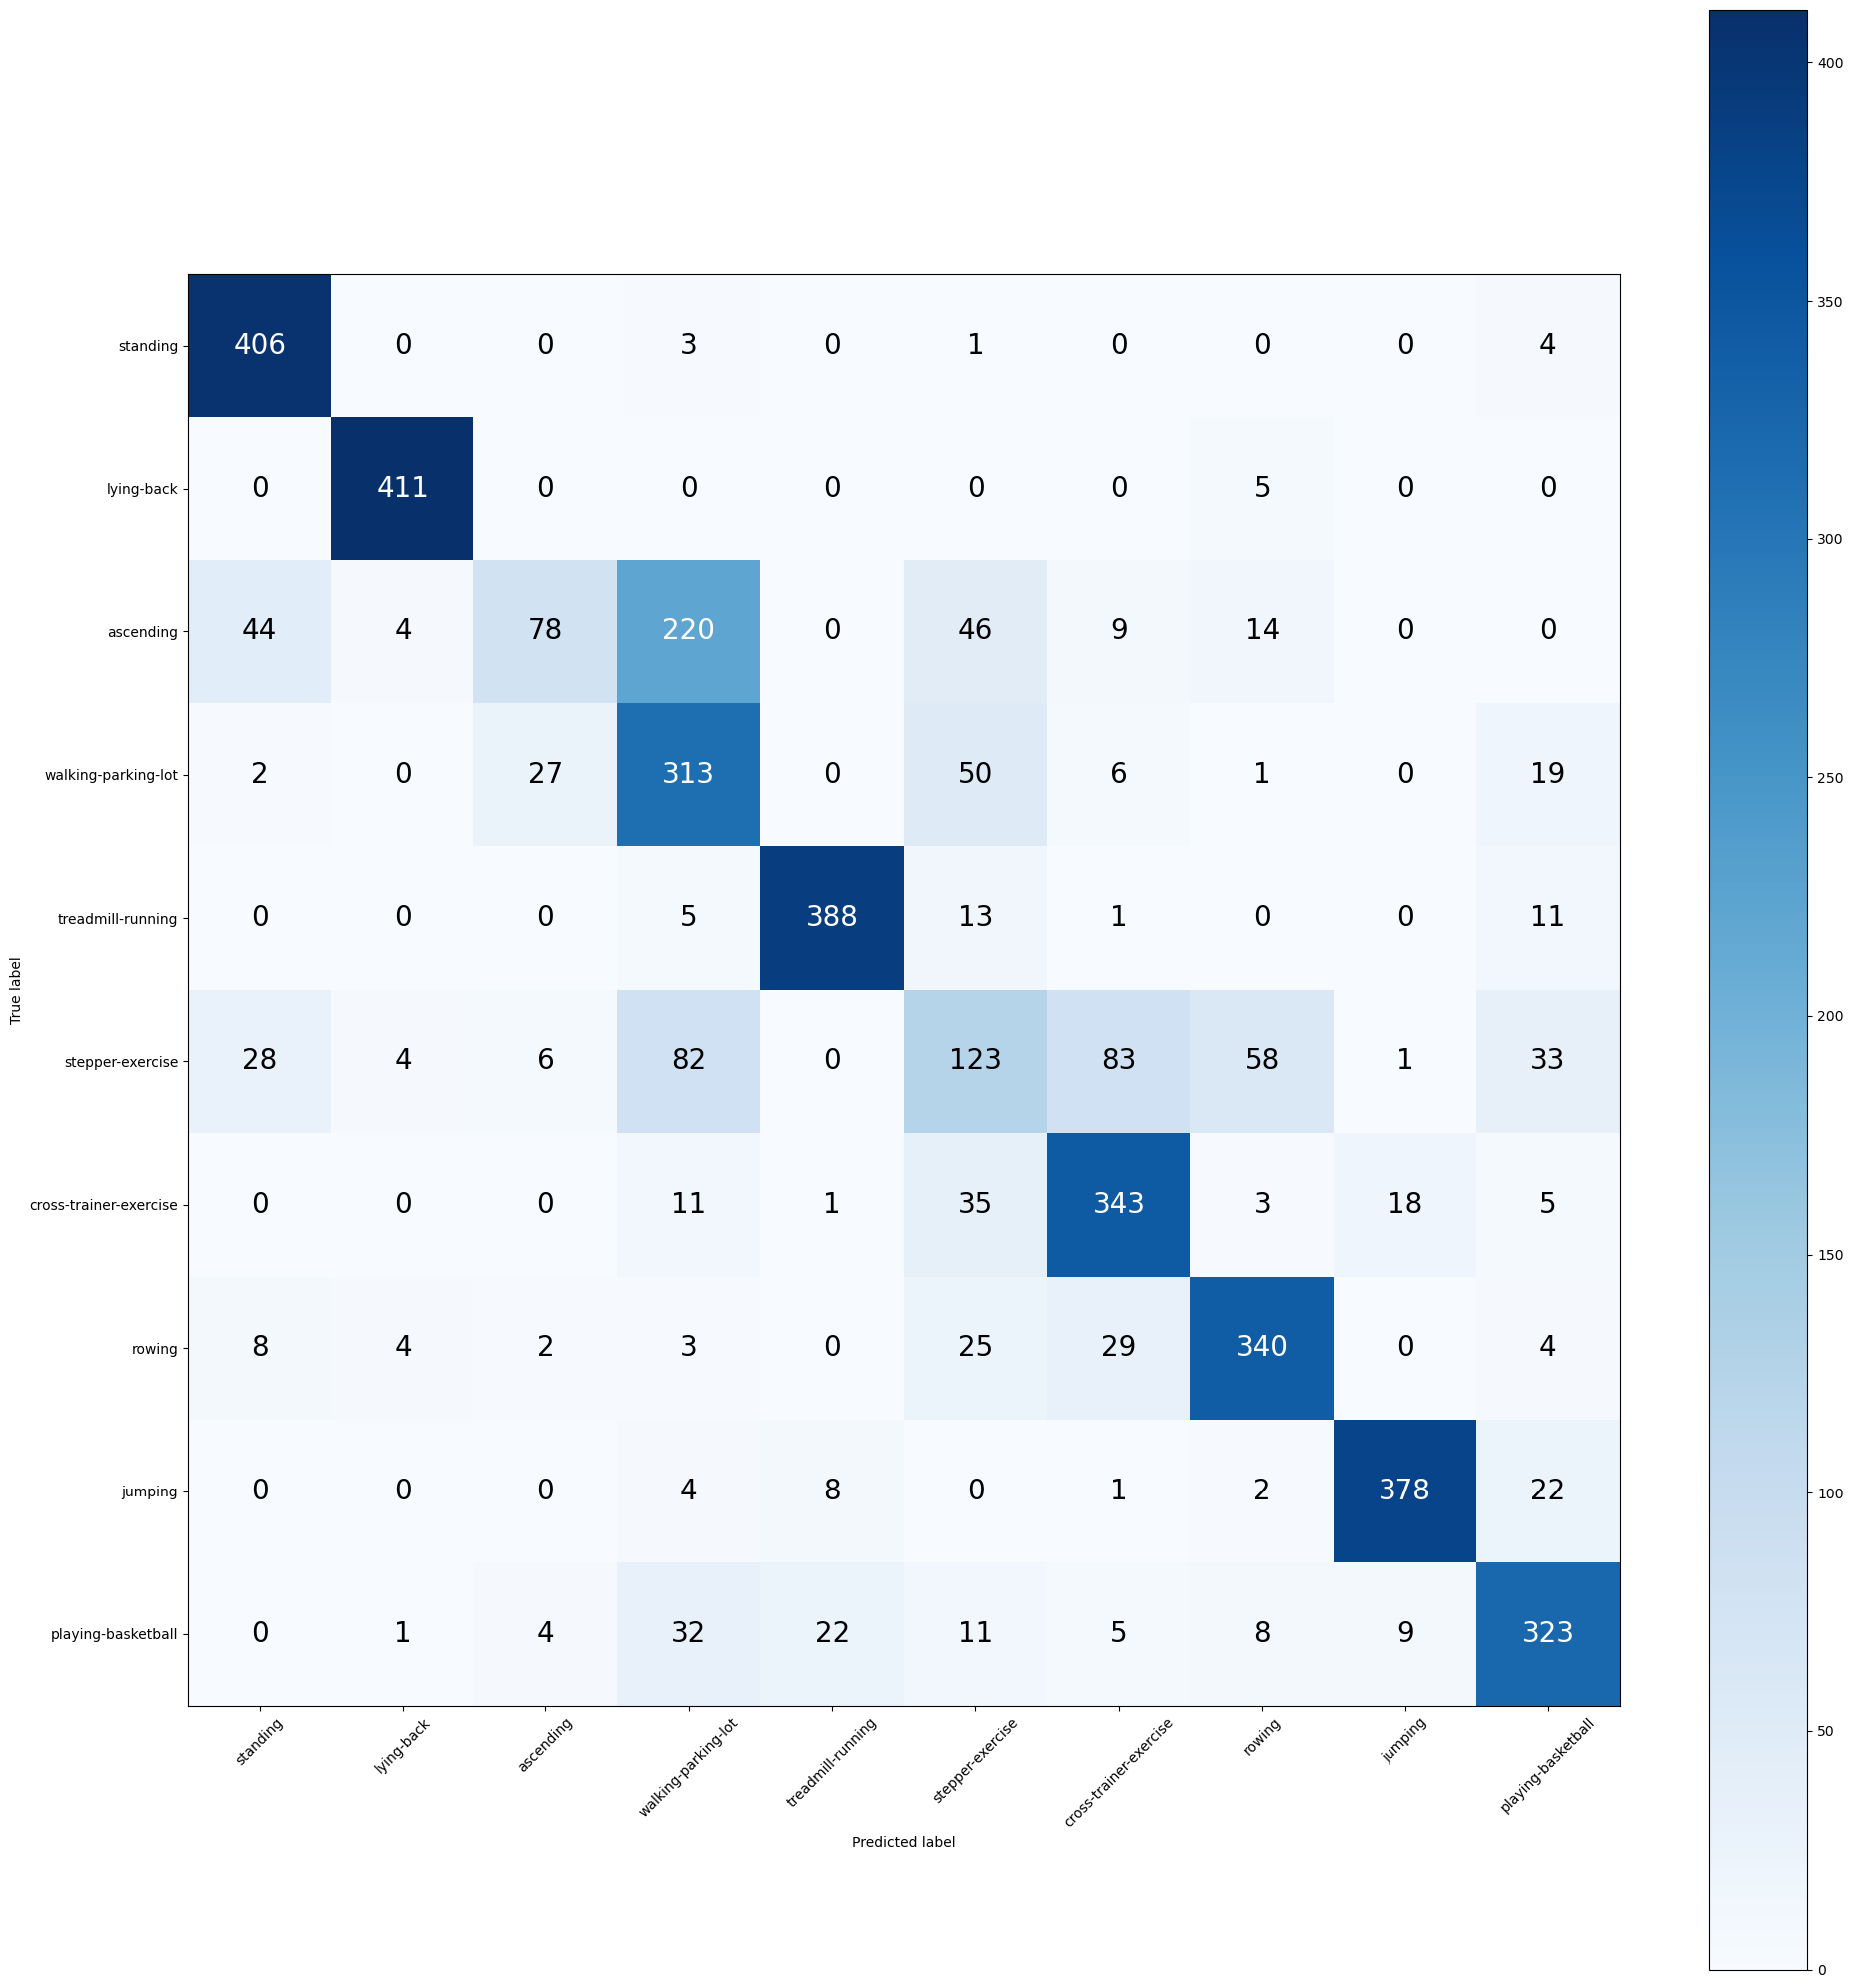

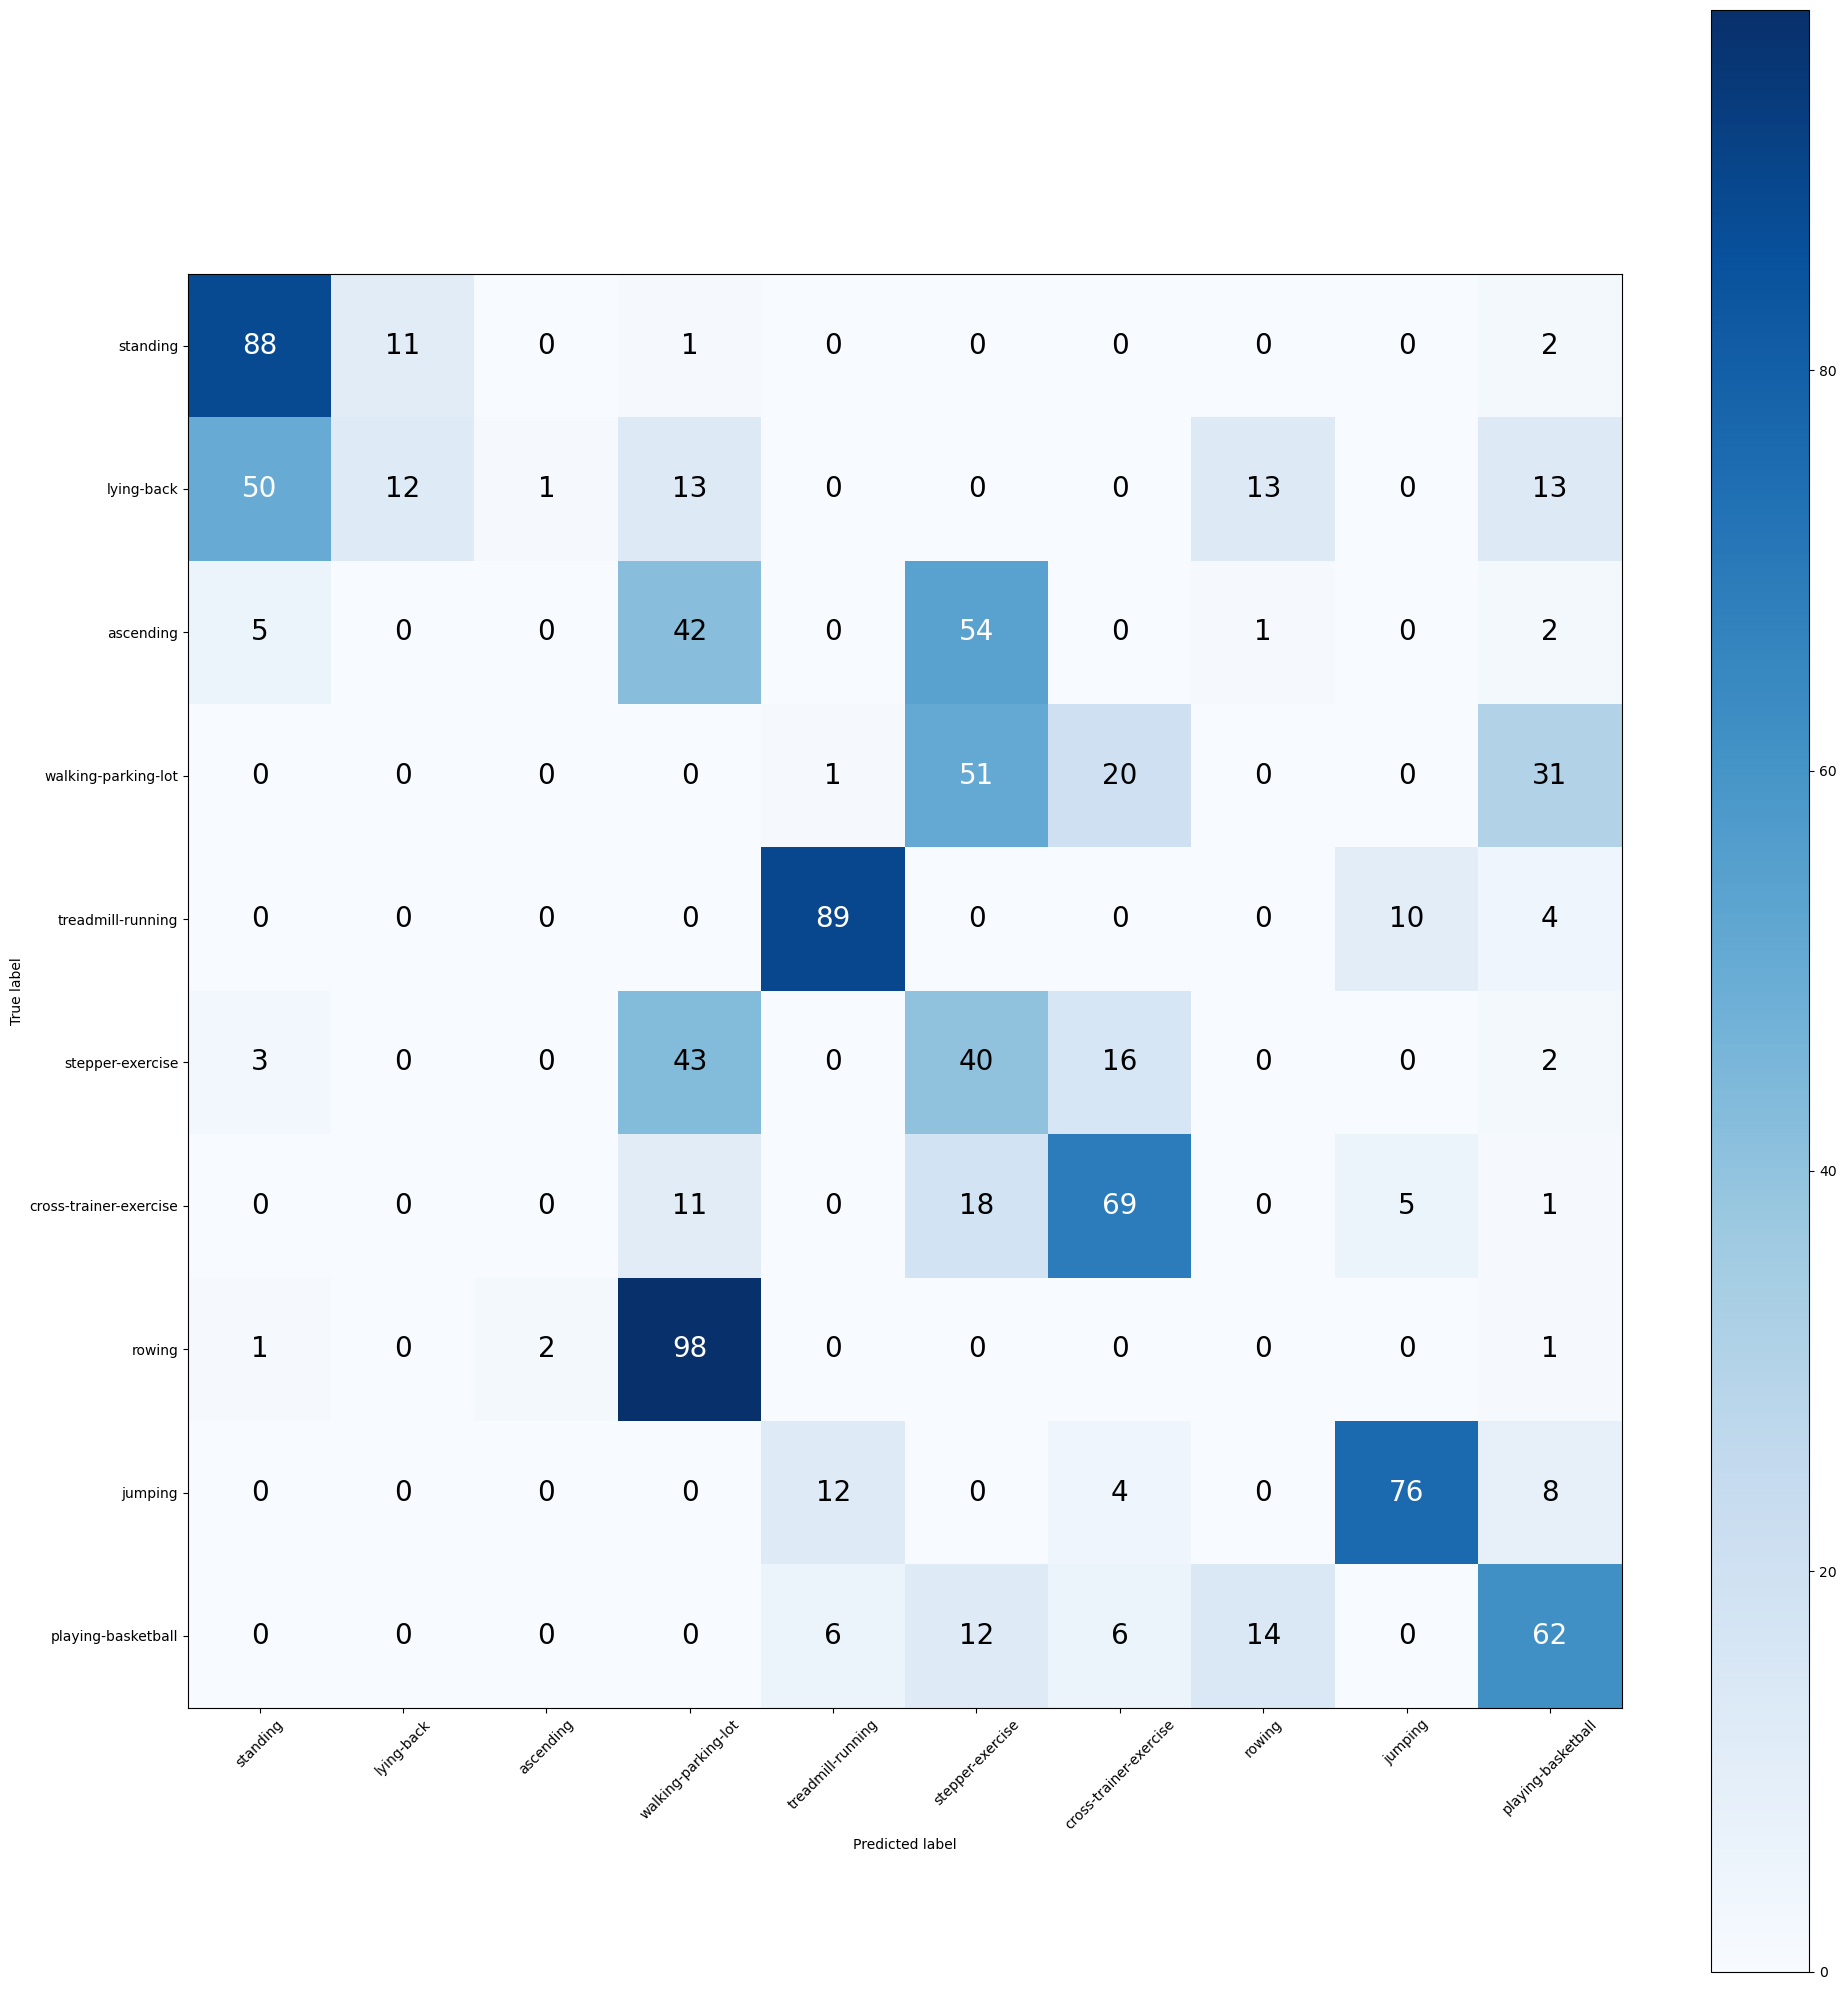

###Valid Source: Epoch: 18, avg_loss: 0.0287, Accuracy: 3103/4171 (74.39%)
###Valid Target: Epoch: 18, avg_loss: 0.0611, Accuracy: 436/1042 (41.84%)


Train Epoch: 19 [ 1/97]	Lambda: 0.9500, Class: 0.722845, CORAL: 0.123692, Total_Loss: 0.840353
Train Epoch: 19 [ 2/97]	Lambda: 0.9500, Class: 0.970702, CORAL: 0.262606, Total_Loss: 1.220177
Train Epoch: 19 [ 3/97]	Lambda: 0.9500, Class: 0.782346, CORAL: 0.217192, Total_Loss: 0.988679
Train Epoch: 19 [ 4/97]	Lambda: 0.9500, Class: 0.940125, CORAL: 0.340906, Total_Loss: 1.263986
Train Epoch: 19 [ 5/97]	Lambda: 0.9500, Class: 0.922168, CORAL: 0.204402, Total_Loss: 1.116350
Train Epoch: 19 [ 6/97]	Lambda: 0.9500, Class: 0.783909, CORAL: 0.145627, Total_Loss: 0.922255
Train Epoch: 19 [ 7/97]	Lambda: 0.9500, Class: 1.007028, CORAL: 0.104729, Total_Loss: 1.106521
Train Epoch: 19 [ 8/97]	Lambda: 0.9500, Class: 1.090850, CORAL: 0.067404, Total_Loss: 1.154884
Train Epoch: 19 [ 9/97]	Lambda: 0.9500, Class: 0.864806, CORAL: 0.149170, Total_Loss: 1.0

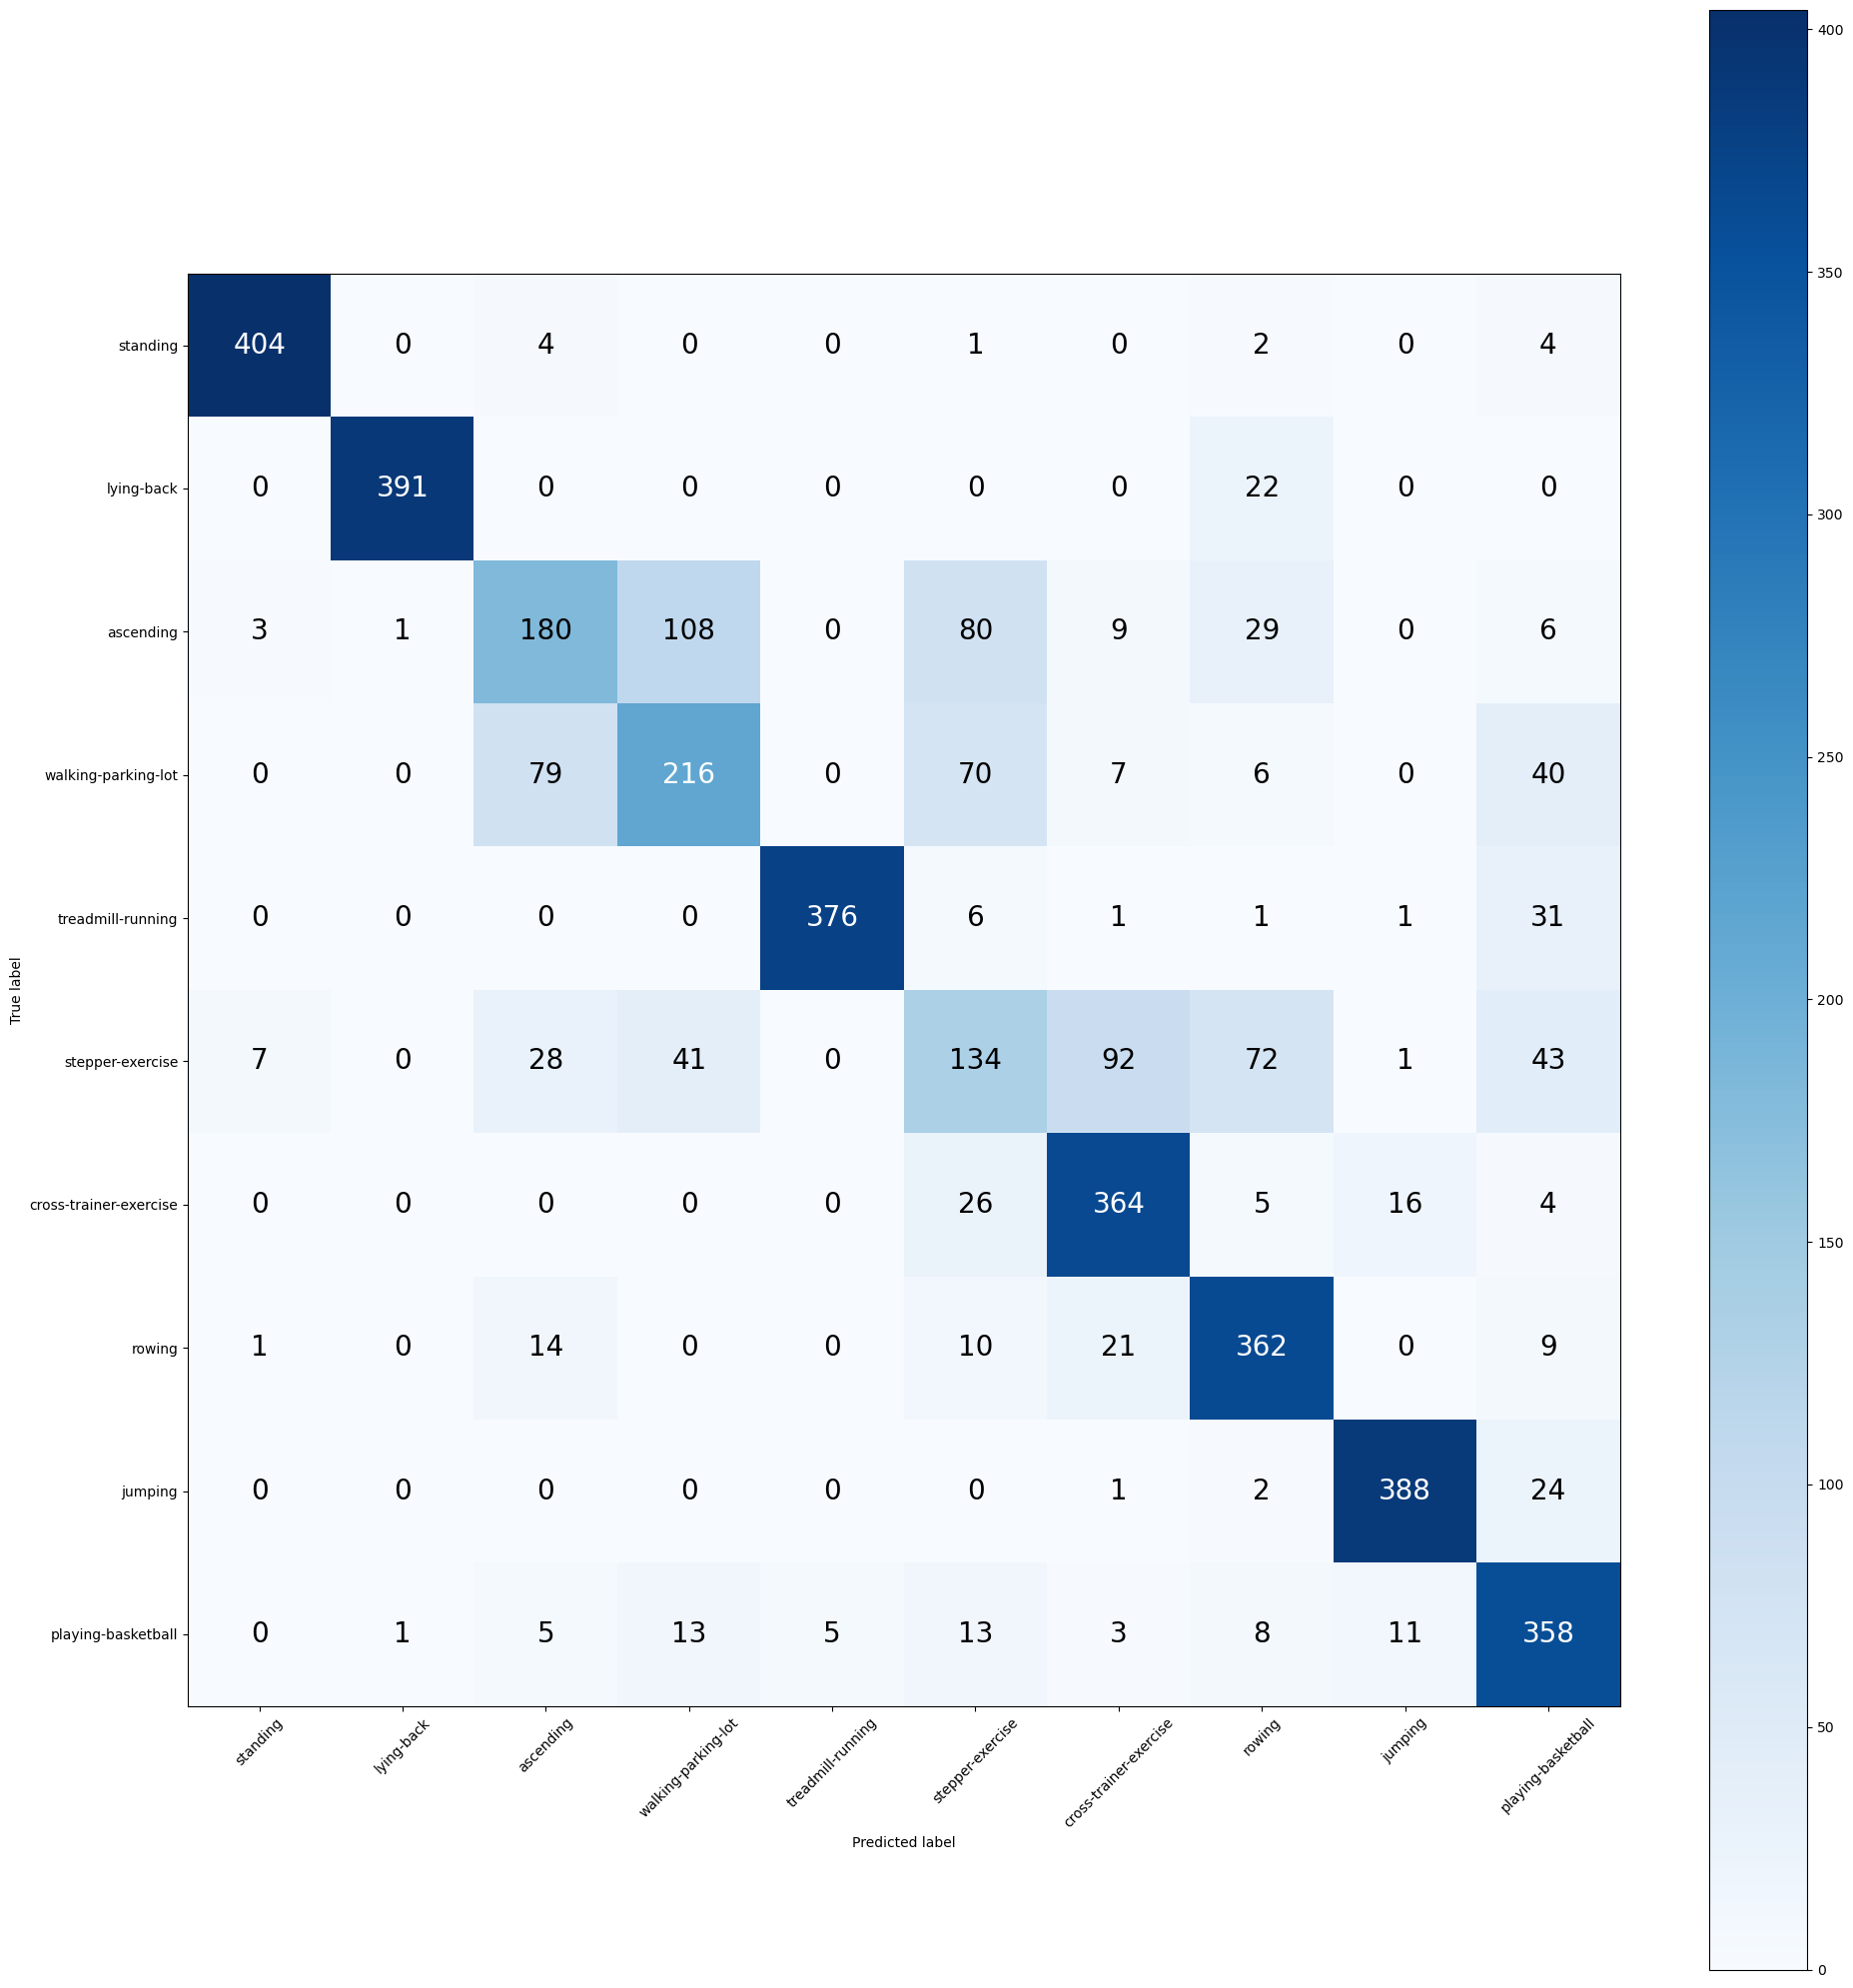

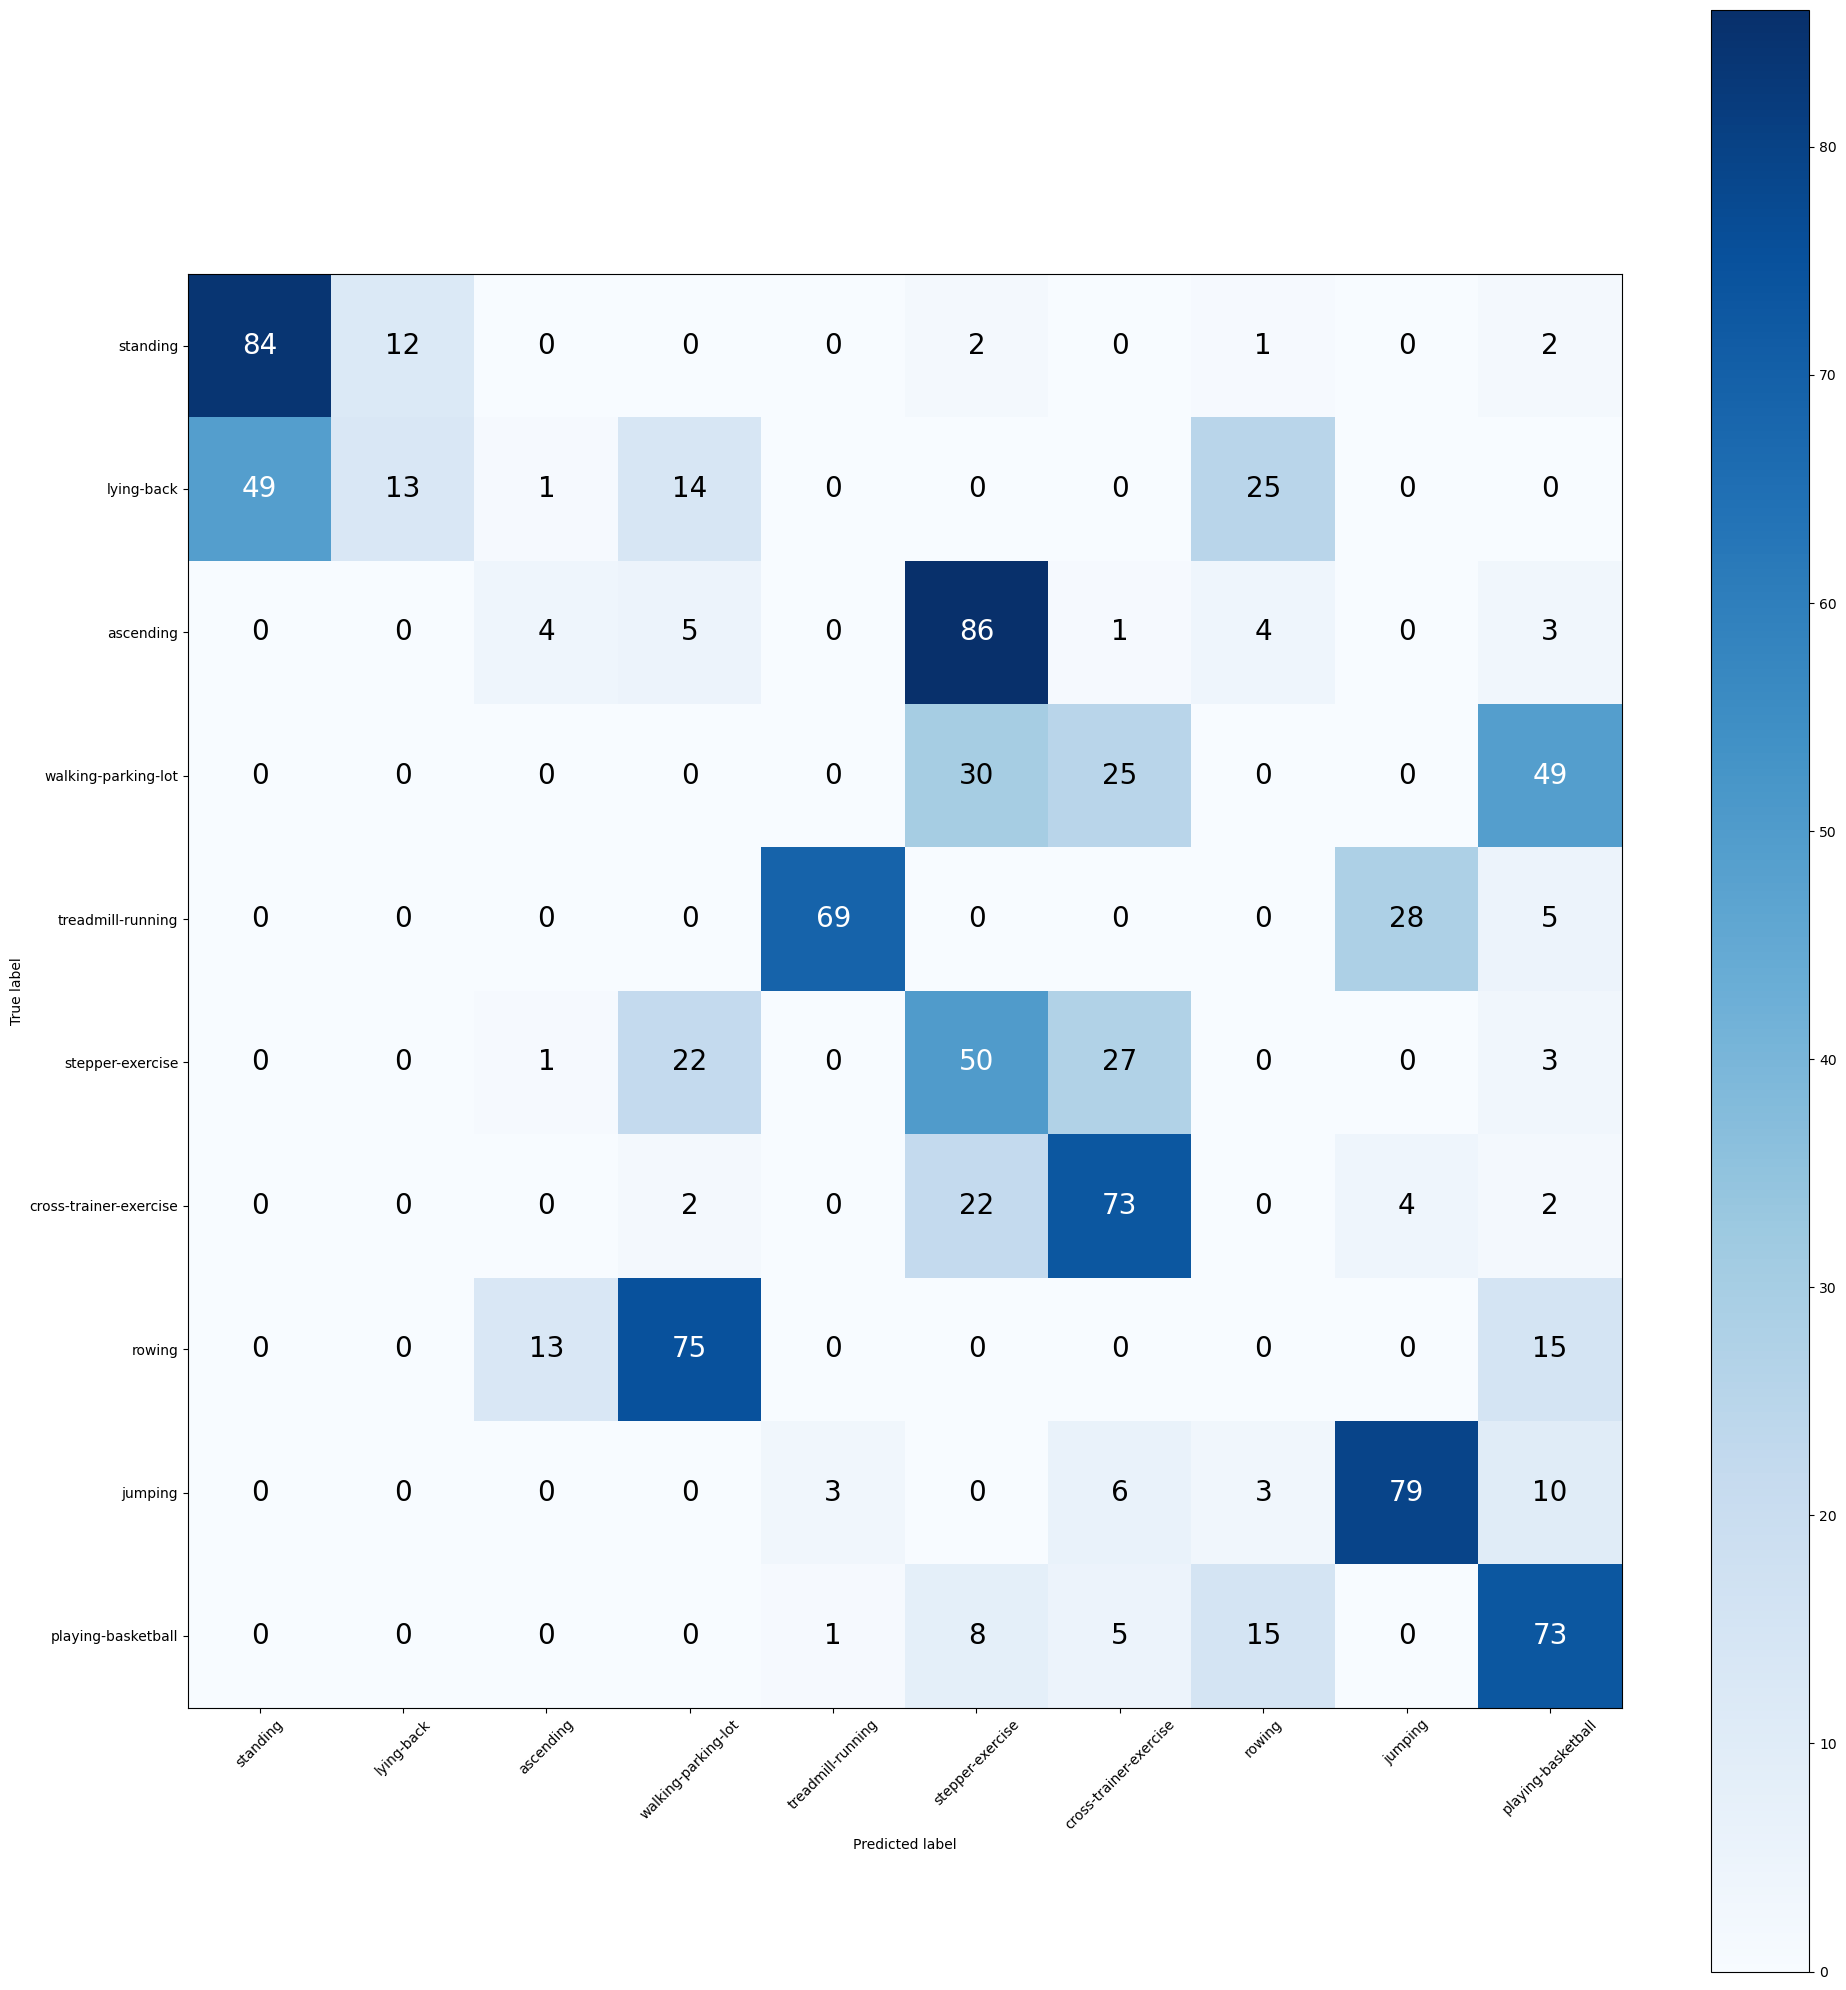

###Valid Source: Epoch: 19, avg_loss: 0.0298, Accuracy: 3173/4171 (76.07%)
###Valid Target: Epoch: 19, avg_loss: 0.0593, Accuracy: 445/1042 (42.71%)


Train Epoch: 20 [ 1/97]	Lambda: 1.0000, Class: 1.219792, CORAL: 0.163091, Total_Loss: 1.382883
Train Epoch: 20 [ 2/97]	Lambda: 1.0000, Class: 0.967725, CORAL: 0.137100, Total_Loss: 1.104825
Train Epoch: 20 [ 3/97]	Lambda: 1.0000, Class: 1.013345, CORAL: 0.154170, Total_Loss: 1.167515
Train Epoch: 20 [ 4/97]	Lambda: 1.0000, Class: 0.977873, CORAL: 0.052877, Total_Loss: 1.030750
Train Epoch: 20 [ 5/97]	Lambda: 1.0000, Class: 0.909881, CORAL: 0.059129, Total_Loss: 0.969009
Train Epoch: 20 [ 6/97]	Lambda: 1.0000, Class: 0.810319, CORAL: 0.084497, Total_Loss: 0.894817
Train Epoch: 20 [ 7/97]	Lambda: 1.0000, Class: 1.142851, CORAL: 0.111856, Total_Loss: 1.254707
Train Epoch: 20 [ 8/97]	Lambda: 1.0000, Class: 1.001566, CORAL: 0.078580, Total_Loss: 1.080146
Train Epoch: 20 [ 9/97]	Lambda: 1.0000, Class: 0.767233, CORAL: 0.107316, Total_Loss: 0.8

Train Epoch: 20 [91/97]	Lambda: 1.0000, Class: 0.986698, CORAL: 0.133241, Total_Loss: 1.119939
Train Epoch: 20 [92/97]	Lambda: 1.0000, Class: 1.072769, CORAL: 0.060625, Total_Loss: 1.133395
Train Epoch: 20 [93/97]	Lambda: 1.0000, Class: 0.987637, CORAL: 0.114539, Total_Loss: 1.102177
Train Epoch: 20 [94/97]	Lambda: 1.0000, Class: 0.791174, CORAL: 0.091455, Total_Loss: 0.882629
Train Epoch: 20 [95/97]	Lambda: 1.0000, Class: 1.002052, CORAL: 0.080275, Total_Loss: 1.082327
Train Epoch: 20 [96/97]	Lambda: 1.0000, Class: 0.960344, CORAL: 0.160697, Total_Loss: 1.121041
Train Epoch: 20 [97/97]	Lambda: 1.0000, Class: 0.815710, CORAL: 0.149251, Total_Loss: 0.964961
###EPOCH 20: Class: 0.882765, CORAL: 0.151368, Total_Loss: 1.034133


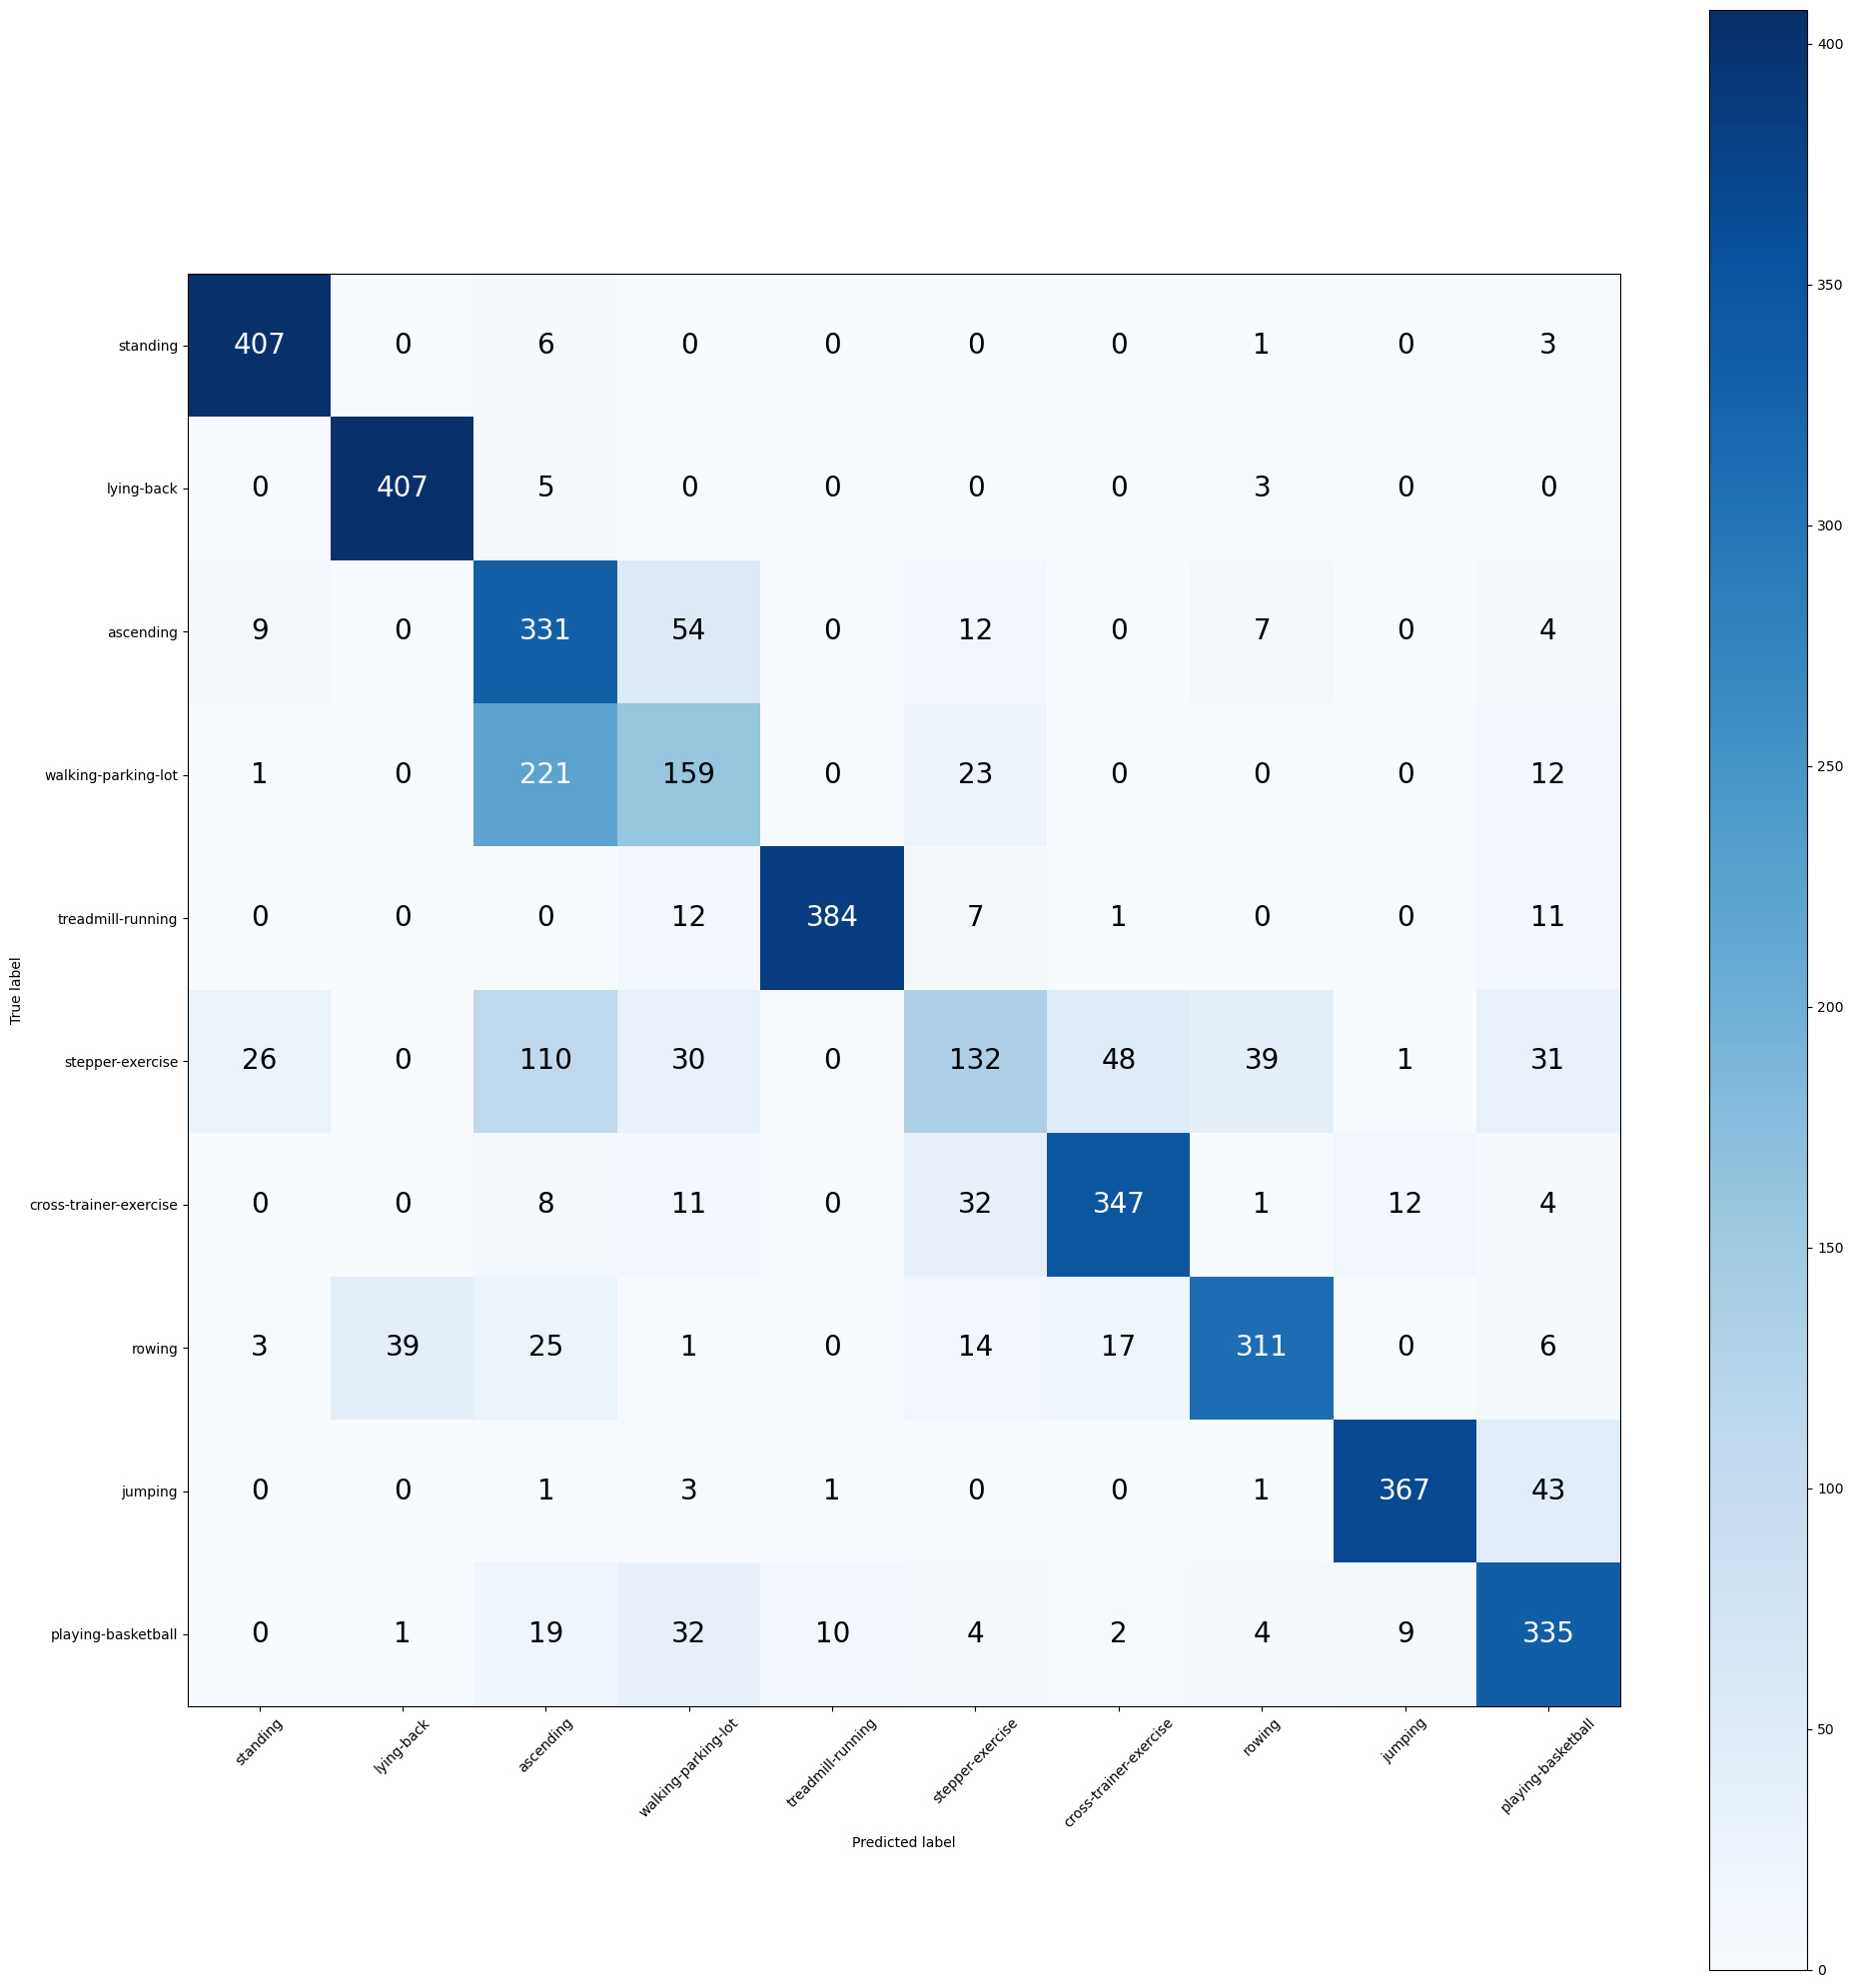

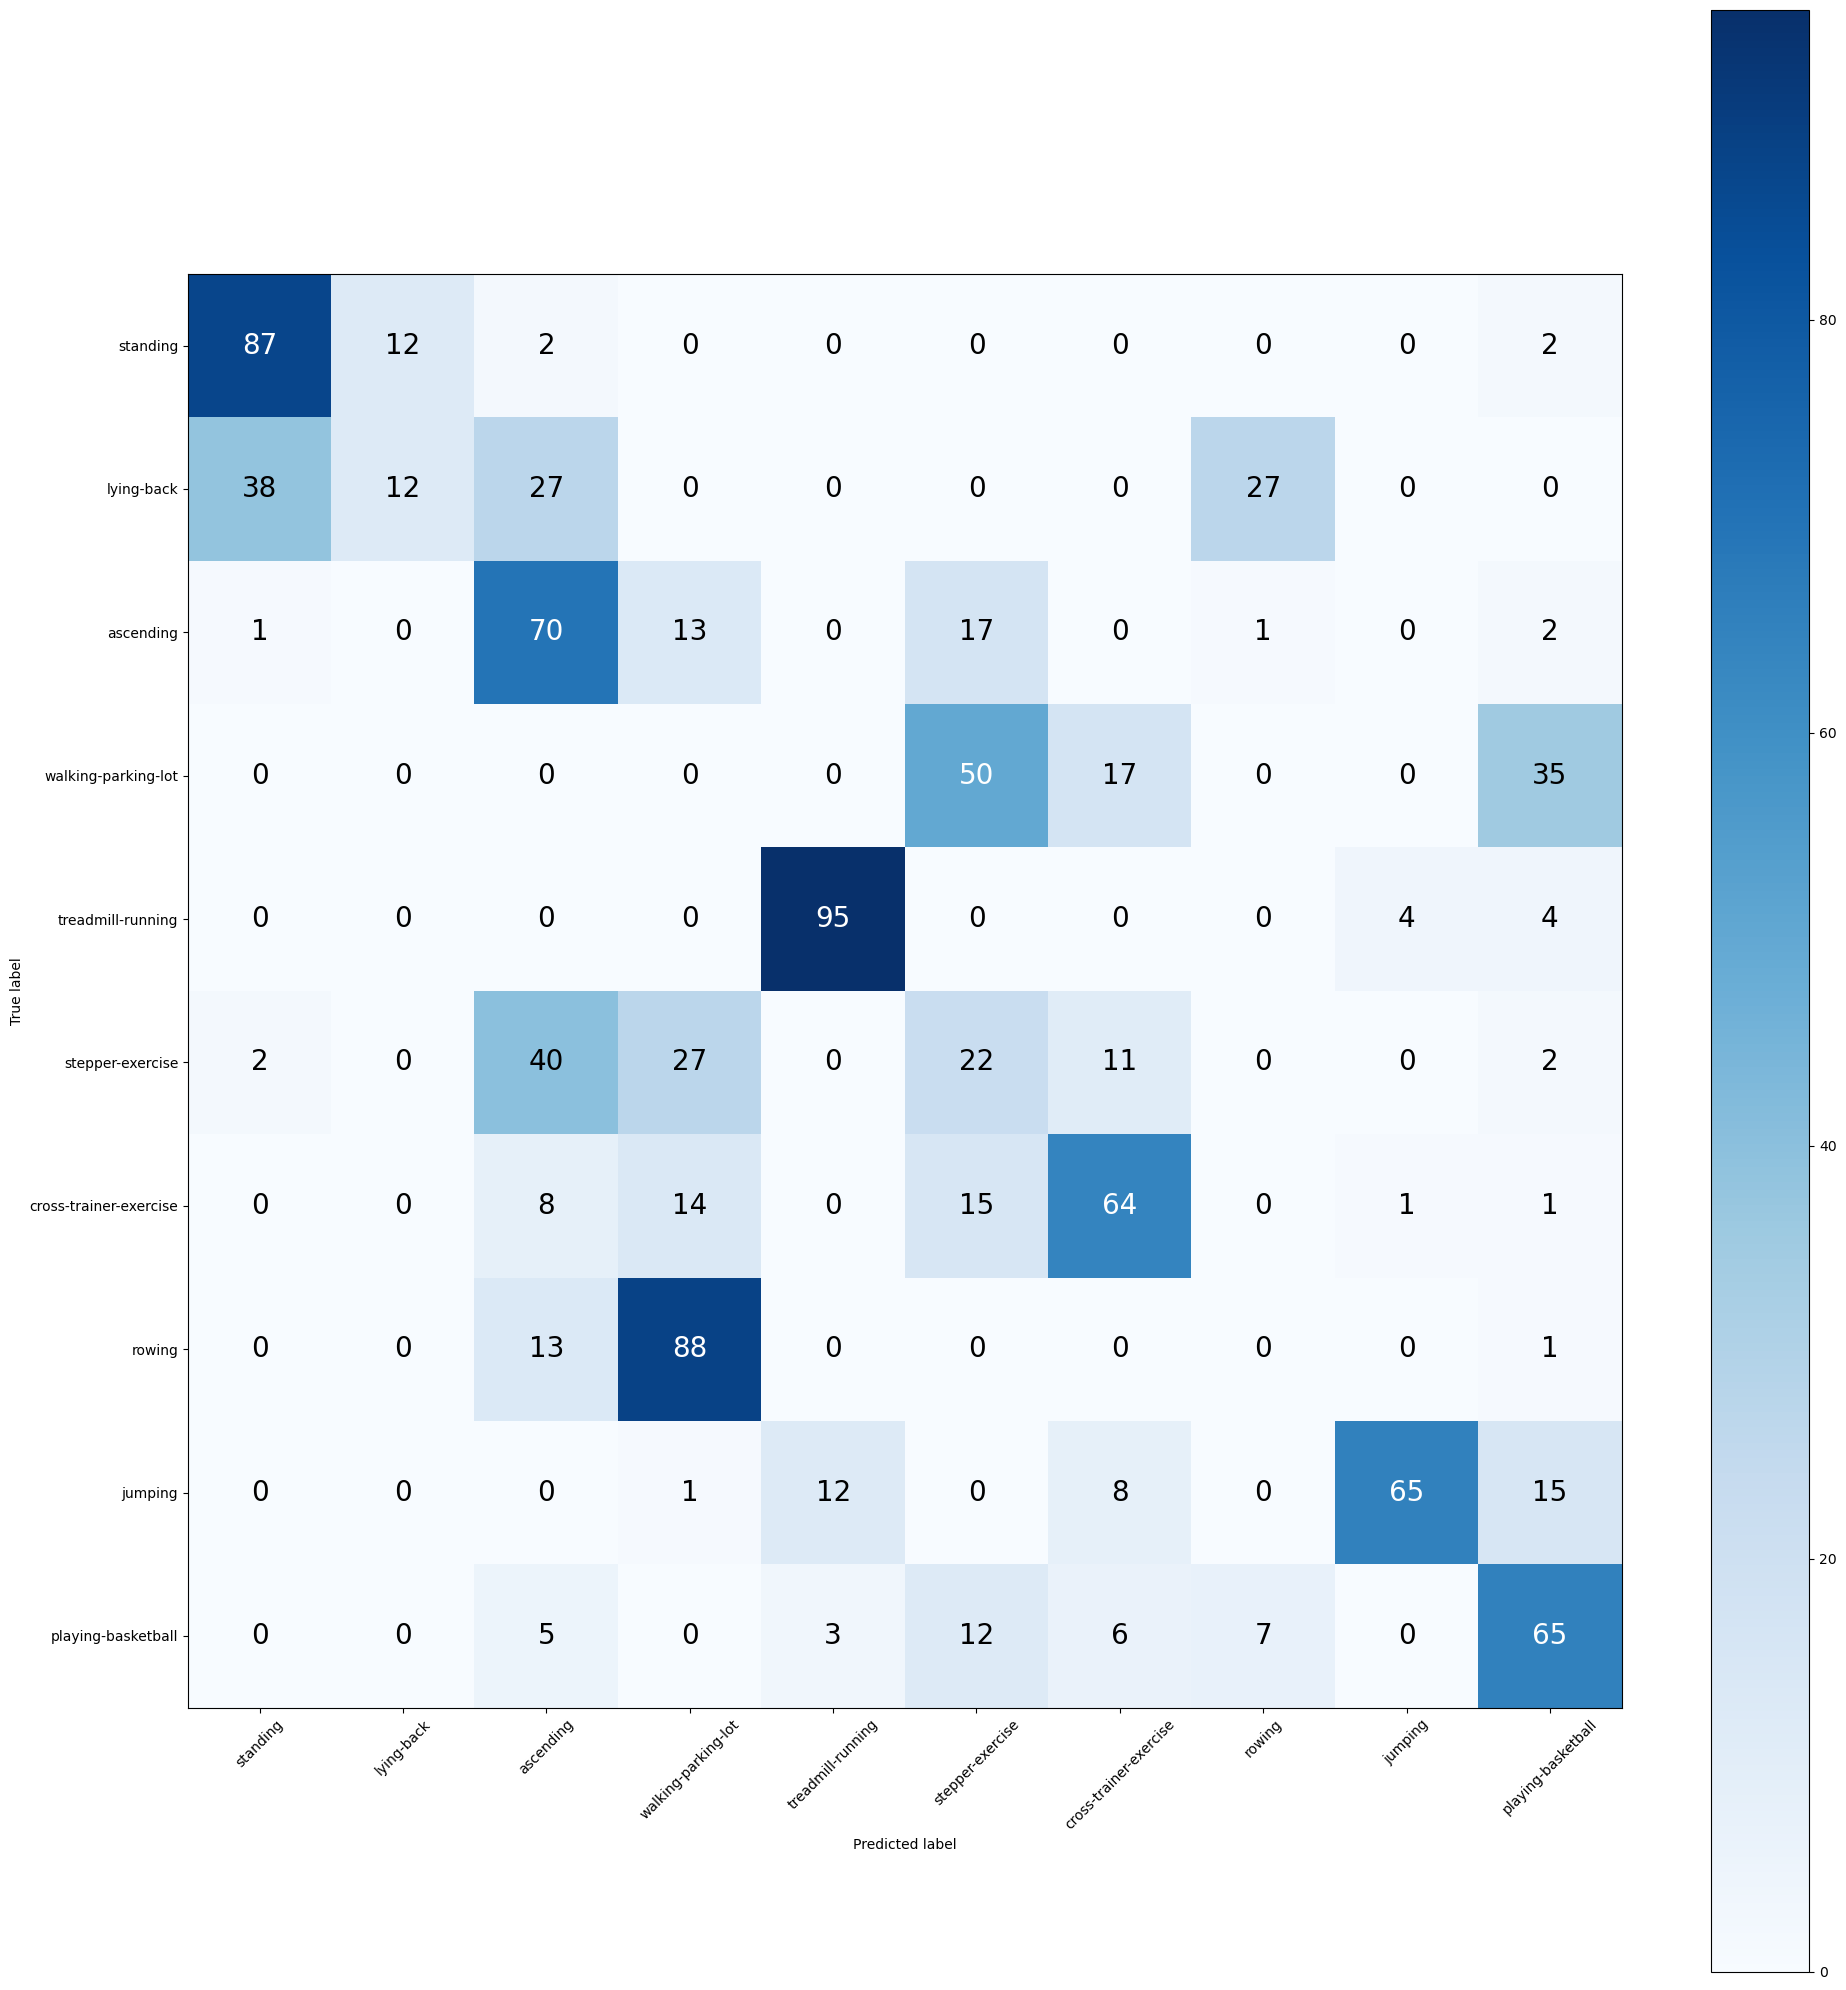

###Valid Source: Epoch: 20, avg_loss: 0.0283, Accuracy: 3180/4171 (76.24%)
###Valid Target: Epoch: 20, avg_loss: 0.0572, Accuracy: 480/1042 (46.07%)


[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DeepCORAL/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0//train_statistic.yaml
[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DeepCORAL/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0//valid_s_statistic.yaml
[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DeepCORAL/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0//valid_t_statistic.yaml
[INFO] Checkpoint saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DeepCORAL/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0/DeepCor

In [78]:
# ====================================================
# ================== MAIN TRAINING ===================
# ====================================================
stat_save_path = save_path
model = DeepCORAL(num_classes=len(activities)).to(DEVICE)

# support different learning rate according to CORAL paper
# i.e. 10 times learning rate for the last two fc layers.
optimizer = torch.optim.SGD([
    {'params': model.sharedNet.parameters()},
    {'params': model.fc.parameters(), 'lr': 10*LEARNING_RATE},
], lr=LEARNING_RATE, momentum=MOMENTUM)

train_statistic = []
valid_s_statistic = []
valid_t_statistic = []

for e in range(0, EPOCHS):
    _lambda = (e+1)/EPOCHS
    # _lambda = 0.0
    res = train(model, optimizer, e+1, _lambda, S_train, T_train, DEVICE)
    print('###EPOCH {}: Class: {:.6f}, CORAL: {:.6f}, Total_Loss: {:.6f}'.format(
        e+1,
        sum(row['classification_loss'] / row['total_steps'] for row in res),
        sum(row['coral_loss'] / row['total_steps'] for row in res),
        sum(row['total_loss'] / row['total_steps'] for row in res),
    ))

    train_statistic.append(res)
    
    valid_source = test(model, S_valid, e, DEVICE, save_path)
    valid_target = test(model, T_valid, e, DEVICE, save_path)
    valid_s_statistic.append(valid_source)
    valid_t_statistic.append(valid_target)

    print('###Valid Source: Epoch: {}, avg_loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        e+1,
        valid_source['average_loss'],
        valid_source['correct'],
        valid_source['total'],
        valid_source['accuracy'],
    ))
    print('###Valid Target: Epoch: {}, avg_loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        e+1,
        valid_target['average_loss'],
        valid_target['correct'],
        valid_target['total'],
        valid_target['accuracy'],
    ))
    print("\n")

# save and save_net functions are in the Util/utils.py

save(train_statistic, stat_save_path + '/train_statistic.yaml')
save(valid_s_statistic, stat_save_path + '/valid_s_statistic.yaml')
save(valid_t_statistic, stat_save_path + '/valid_t_statistic.yaml')
save_net(model, save_path + 'DeepCoral_model.pth')


if task == "Cross-Position":
        print(f"\nDataset: {dataset}, all persons")
        print(f"Target domain: {domains[target]}")
        
elif task == "Cross-Person":
        target_string = ", ".join([domains[i] for i in target])
        print(f"\nDataset: {dataset}, all Positions")
        print(f"Target domain: {target_string}")

# Testing on Target Domain

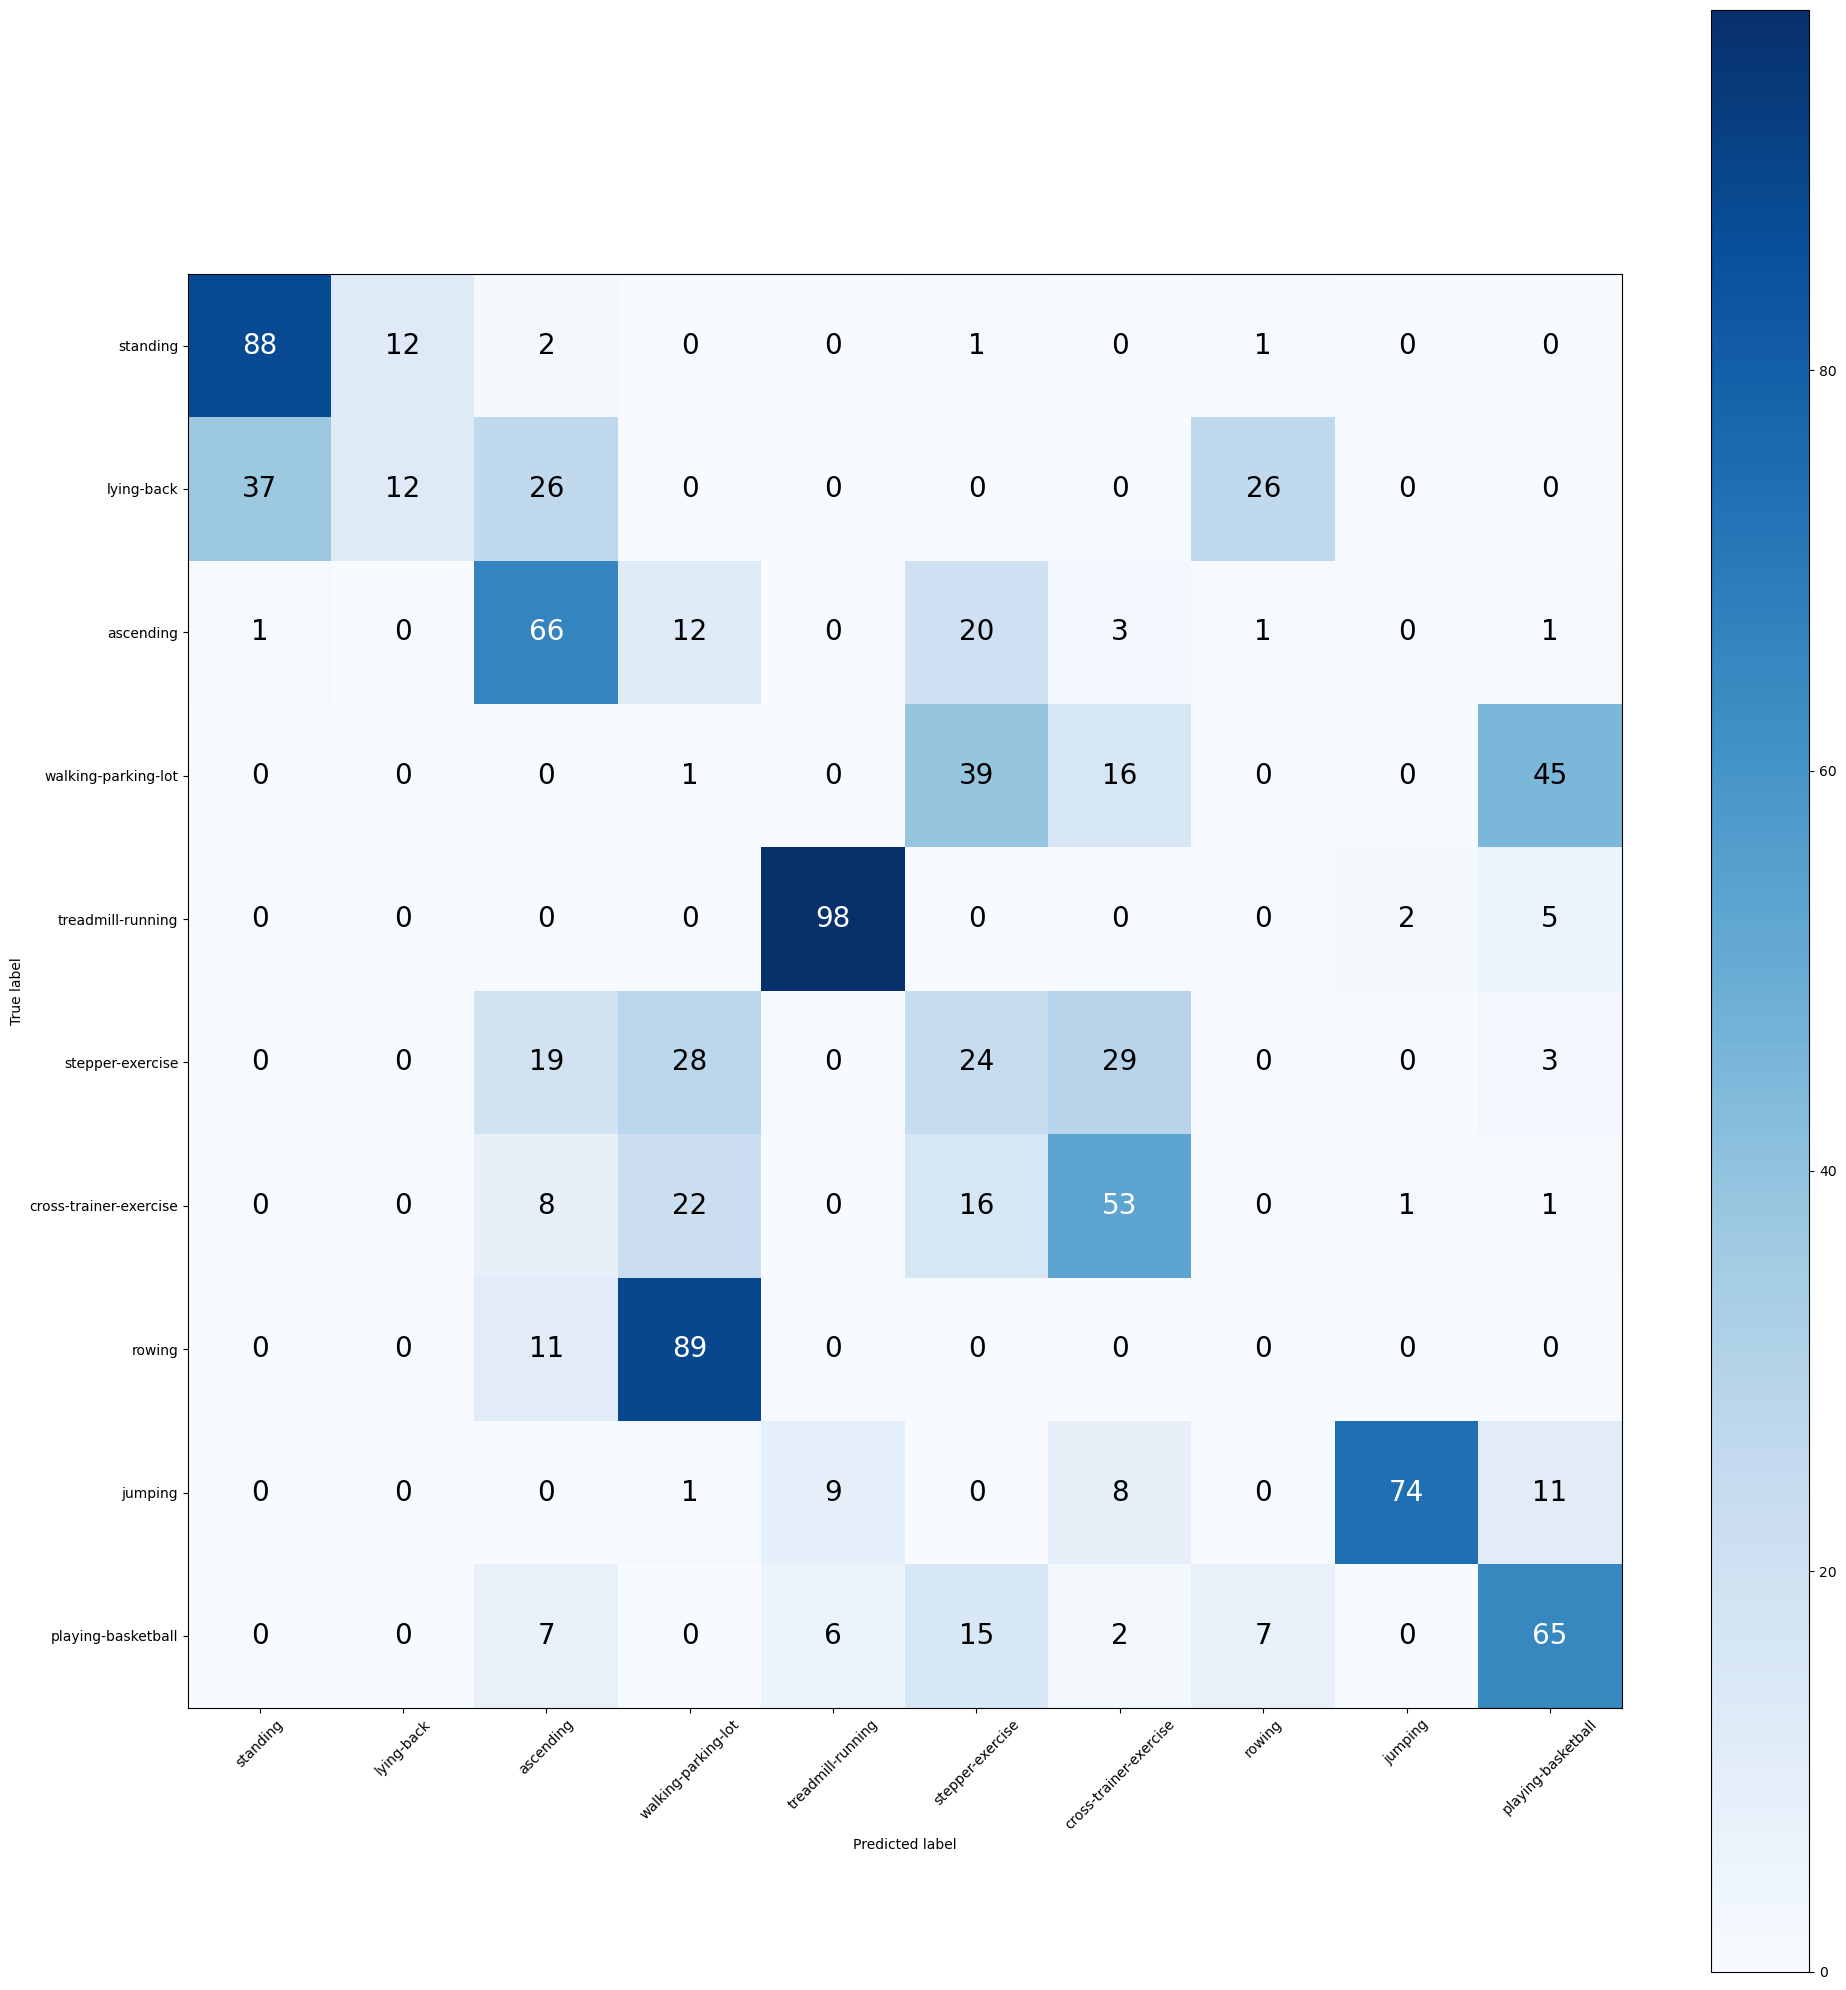

[INFO] Object saved to /media/soham/CorsairSSD/Research/Dr.AvijoyChakma/Project/DeepCORAL/Output/DSADS-Cross-Position-Heterogeneity/10_Activity_Window_128_Overlap_0.1/Target-Position-LL/seed0//result.yaml

Dataset: DSADS, all persons
Target domain: LL

###Test Target: avg_loss: 0.0573, Accuracy: 481/1042 (46.16%)


In [79]:
model = DeepCORAL(num_classes=len(activities)).to(DEVICE)
model.load_state_dict(torch.load(save_path + 'DeepCoral_model.pth'))

test_target = test(model, T_test, e=-1, DEVICE=DEVICE, save_path=save_path)
test_target.pop('epoch', None)

save(test_target, stat_save_path + '/result.yaml')

if task == "Cross-Position":
        print(f"\nDataset: {dataset}, all persons")
        print(f"Target domain: {domains[target]}\n")
        
elif task == "Cross-Person":
        target_string = ", ".join([domains[i] for i in target])
        print(f"\nDataset: {dataset}, all Positions")
        print(f"Target domain: {target_string}\n")

print('###Test Target: avg_loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_target['average_loss'],
        test_target['correct'],
        test_target['total'],
        test_target['accuracy'],
    ))

In [80]:
# print(torch.backends.cudnn.version())